# Evidencia 6 NoteBook de Limpieza, Tranforsmación y Modelos

# Documentación del Contexto y Datos (Entendimiento del Negocio)

### Problematica
CNH es el importador exclusivo en México de CNH Industrial, comercializador de las marcas New Holland y Case IH en maquinaria agrícola y de construcción. Actualmente, la empresa opera una red de 37 distribuidores y más de 200 puntos de venta, con aproximadamente 11.000 unidades en operación en el país.

A pesar de su infraestructura, su modelo de after-market sigue siendo reactivo, su sistema actual les dice qué pasó, cuántos servicios se cerraron, cuántos quedaron pendientes, qué distribuidores tuvieron más volumen. Pero no les dice qué va a pasar ni con quién actuar antes de que el problema ocurra.

Los datos que nos dieron nos muestran ese problema con 12,667 servicios en estatus Pendiente siendo el 53% del total, el 3.87% de los equipos se clasifican como fantasma sin OT registrada, y el 96.6% de los registros no tienen datos de contacto del cliente, lo que impide ejecutar cualquier intervención directa.

CNHMX necesita anticipar el momento exacto en que cada equipo necesita intervención y convertirlo en una acción comercial del distribuidor, antes de que el evento de pérdida ocurra.
Nuestra solución analítica tiene como objetivo incrementar la monetización after-market entre un 35% y 49%, pasando de un modelo reactivo a uno genuinamente predictivo.

### Preguntas de Hipótesis Estadística

Descriptivas
- ¿El grado de cumplimiento del esquema de mantenimiento es constante sin importar si es un servicio menor (50hrs) o mayor (1500hrs), o existe una variabilidad significativa en cómo se cumplen? (CEM)
- ¿En qué meses del año se acumula, en promedio, el mayor desfase entre el uso real y el servicio esperado, y qué tan uniforme es este comportamiento entre todas las unidades? (DMU)
- ¿Cómo se distribuye la dependencia operativa promedio y qué tanta heterogeneidad existe dentro de los equipos agrícolas versus los de construcción? (DOE)
- ¿Cuál es el valor económico (en puntos de servicio) que se está dejando de capturar en promedio entre los equipos agrícolas y los de construcción, y qué tan dispersa está esa pérdida? (MA potencial no capturado)
Descriptiva/Diagnóstica
- ¿La intensidad de uso operacional (DOE) tiene el mismo impacto sobre el desfase de mantenimiento (DMU) en todas las regiones, o existen zonas geográficas donde la exigencia operativa se traduce sistemáticamente en un mayor rompimiento del esquema de mantenimiento?

Diagnósticas
- ¿Qué variables operativas explican significativamente el bajo CEM  definido con una regla de negocio CEM < 0.5 o al menos 2 omisiones consecutivas, y cuál tiene mayor efecto sobre esa probabilidad?
- ¿Existe una relación no lineal entre horas de DMU y frecuencia de OT ejecutadas, y en qué umbral de DMU la conversión deja de aumentar?
- ¿La acumulación acelerada del DMU predice significativamente el riesgo de pérdida de clientes en el siguiente periodo?
- ¿Las variables de telemetría explican suficientemente el CEM, o agregar variables agregadas no redundantes del distribuidor mejora significativamente la explicación del cumplimiento?

Predictivas
- Un cliente que acaba de cumplir su servicio de 600 horas, ¿qué probabilidad tiene de incumplir la ventana de tolerancia en su próximo servicio de 900 horas?
- Considerando el historial de omisiones y la intensidad de uso actual, ¿cuál es la probabilidad de que un equipo "desaparezca" de la red de servicio (no genere ninguna orden de trabajo) en su próximo umbral de mantenimiento?

Prescriptiva
- ¿Cuál es el score de priorización de cada equipo combinando DMU y omisiones, y en qué orden deberían atenderse?


### Objetivo de la Modelación

#### Grupo A: Tests de Asociación y Distribución (Preguntas Descriptivas)
Para las preguntas descriptivas, ya que los constructos latentes (CEM, DMU, DOE y MA) tienen distribuciones sesgadas y varianzas no homogéneas, no se usaron métodos paramétricos clásicos como ANOVA, T-Test de Student y Regresión Lineal Múltiple tradicional. Y se decidió utilizar técnicas robustas no paramétricas.

* H1: CEM por intervalo de servicio: Se utilizó Kruskal-Wallis para evaluar si el porcentaje de error de cumplimiento presenta diferencias significativas entre los distintos niveles de servicio, evitando asumir normalidad y homogeneidad de varianzas.
* H2: DMU por mes del año: Se uso Kruskal-Wallis para identificar estacionalidad(Tendencia Temporal) en el desfase de mantenimiento, considerando la distribución no normal de los datos y la presencia de patrones cíclicos asociados al calendario agrícola.
* H3: DOE entre segmento agrícola y construcción: Se utilizó Mann-Whitney U para comparar la intensidad operativa promedio mensual entre los dos segmentos sin requerir supuestos paramétricos.
* H4: MA Potencial entre segmentos: Se uso Mann-Whitney U para cuantificar si la monetización perdida por equipo difiere significativamente entre agrícola y construcción.
* H5: DMU entre zonas geográficas: Se implementó Kruskal-Wallis para identificar regiones con mayor riesgo sistemático de desfase, filtrando únicamente zonas con representatividad estadística suficiente.

#### Grupo B: Modelos Diagnósticos (Preguntas Diagnosticas)
* H6: Variables que explican el bajo CEM: Se utilizó una Regresión Logística para estimar la probabilidad de que una unidad pertenezca al grupo de bajo cumplimiento operativo, definido por regla de negocio como CEM < 0.5 o al menos 2 omisiones consecutivas. Se eligió este modelo porque el objetivo no es explicar el valor continuo del CEM sino clasificar el riesgo operativo de cada equipo.
* H7: Relación no lineal entre DMU y frecuencia de OT: Se uso una Regresión Cuadrática incorporando el término DMU² para detectar el punto de inflexión donde el aumento del desfase deja de asociarse con mayor frecuencia de órdenes de trabajo y comienza a reducirla.
* H8: Aceleración del DMU como predictor de pérdida de cliente: Se uso una Regresión Logística para estimar la probabilidad de que una unidad pierda continuidad con la red oficial en el siguiente periodo. El modelo incorpora una variable temporal para capturar el crecimiento del desfase entre periodos y no únicamente su nivel absoluto.
* H9: Telemetría vs. variables del distribuidor para explicar el CEM: Se utilizó una comparación de modelos de Regresión Lineal Múltiple. El modelo base utiliza únicamente variables de telemetría (horas acumuladas, horómetro, odómetro, promedio mensual, meses activos). El modelo extendido agrega variables agregadas a nivel distribuidor. Se excluyeron explícitamente los componentes directos del CEM para evitar data leakage y garantizar interpretabilidad.



#### Grupo C: Modelos de Statistical Learning (Preguntas Predictivas y Prescriptivas)
Para las preguntas predictivas, ya que los datos tienen relaciones no lineales, presencia de outliers y desbalance de clases en las variables objetivo, por lo que se decidió utilizar Random Forest, ya que permiten capturar patrones complejos, manejar datos desbalanceados y determinar la importancia predictiva de cada constructo latente mediante técnicas de Feature Selection.
Para complementar la segunda predictiva se junto con un modelo de supervivencia (Kaplan-Meier + Cox Proportional Hazards), ya que permite modelar el tiempo hasta la fuga, estimar curvas de supervivencia por segmento y generar Hazard Ratios interpretables por variable. Para la pregunta prescriptiva, dado que el objetivo no es predecir un evento futuro sino establecer el orden óptimo de intervención comercial sobre la cartera actual, se implementó un score compuesto validado mediante prueba Chi-cuadrado contra el método tradicional de priorización por antigüedad, para calcular si se genera una tasa de conversión de órdenes de trabajo superior.


* H10: Predicción de incumplimiento del próximo servicio: Se utilizó un Random Forest Classifier para anticipar qué equipos no cumplirán su siguiente mantenimiento en la transición crítica del mantenimiento de 600 a 900 hrs. El modelo captura relaciones no lineales entre el CEM histórico, el DOE y la intensidad de uso, maneja el desbalance de clases y utiliza variables rezagadas para evitar data leakage.
* H11: Predicción de fuga operativa: Igual se utilizó un Random Forest Classifier que estima la probabilidad de que un equipo desaparezca de la red sin generar una orden de trabajo en su siguiente umbral de servicio. Este modelo fue seleccionado por su capacidad para detectar eventos raros y por permitir identificar la importancia predictiva de variables como el CEM histórico y el DOE.
* H11 2.0: Análisis de Supervivencia: Se utilizó Kaplan-Meier y Cox Proportional Hazards para estimar el tiempo hasta que un equipo deja de generar órdenes de trabajo. El km calcula las curvas de supervivencia por segmento (agrícola vs. construcción) y permite identificar la mediana de supervivencia, o sea, el punto en horas donde la mitad de los equipos que eventualmente fugan ya lo han hecho. Mientras que el Cox mide el efecto individual de cada variable sobre la velocidad de fuga mediante Hazard Ratios, sirve para complementar al Random Forest de H11 porque trata la fuga como un proceso temporal continuo, y porqué h11 no logró rechazar H0.
* H12: Score de priorización prescriptiva: Se implementó un score compuesto combinando el desfase acumulado (DMU) y los servicios omitidos estimados para ordenar los equipos según su probabilidad de generar una orden de trabajo si son contactados. El modelo no busca predecir un evento futuro sino establecer el orden óptimo de intervención comercial del distribuidor sobre los equipos actualmente en la cartera.

### Delimitación del Universo de Análisis y Selección de Fuentes de Datos
Para garantizar la integridad y validez de las hipótesis que planteamos, la arquitectura del dataset maestro se construyó a partir de las fuentes de Mantenimiento, Reporte de Unidades del Día Anterior y Horas 2024-2025

Los conjuntos de datos de Population View, Indicadores de Ruteo y Top 50 fueron excluidos del modelo predictivo y descriptivo, no por una falta de valor en sí mismos, sino por limitaciones de compatibilidad y alineación con el objetivo del estudio.

- Indicadores de Ruteo: fue descartado ya que solamente tiene dos columnas, lo que limita su capacidad explicativa y dificulta su integración con otras bases de datos para la construcción de modelos o pruebas de hipótesis más robustas. Además de no aportar variables operativas para la construcción de los constructos latentes (DOE, CEM, DMU).

- Population View: No pudo ser integrado ya que, de acuerdo con la estructura definida por el socio formador, corresponde a conjuntos de datos segmentados por equipos distintos, lo que impide realizar un merge consistente con las demás fuentes sin comprometer la integridad del análisis.

- Top 50: No fue incluido ya que es más orientada a ranking y priorización, sin variables directamente utilizables para el análisis de mantenimientos, por lo que su contribución sería marginal dentro del enfoque actual, salvo en casos específicos donde no se contara con variables geográficas como estado o ciudad, pero dado que las bases seleccionadas, ya contenían los campos de Estado y Ciudad con una cobertura superior al 95%, la integración del Top 50 se catalogó como redundante para los objetivos del estudio.

En contraste, los datasets seleccionados sí permiten una integración coherente entre variables clave del problema, facilitando nuestras pruebas de hipótesis y modelos explicativos, por lo que la selección final responde a criterios de relevancia, y contribución directa a las preguntas de investigación planteadas.

# Comprensión de los Datos

### Fuente 1: Telematrix (Mantenimientos)

**Fuente de datos**: Plataforma externa de telematrix, utilizada para el monitoreo de servicios preventivos.

**Obtención de datos**: Los datos fueron exportados manualmente desde la plataforma externa y se nos entregaron en formato Excel (.xlsx).

**Descripción**: Corresponde a un control de servicios
preventivos, permitiendo identificar equipos próximos a mantenimiento, servicios
atrasados y seguimiento de trabajos por distribuidor.

## Diccionario de Datos
| Columna | Tipo (pandas) | Descripción |
|---------|---------------|------------|
| no | float64 | Identificador numérico del registro. Actualmente no contiene datos. |
| alias | object | Nombre o identificador alternativo del equipo. |
| marca | object | Marca del equipo o maquinaria. |
| modelo | object | Modelo específico del equipo. |
| configuracion | object | Configuración técnica del equipo. |
| no_serie | object | Número de serie único del equipo. |
| distribuidor | object | Nombre del distribuidor asociado al equipo. |
| servicio | int64 | Intervalo de servicio programado del equipo, medido en horas. |
| hrmtro | float64 | Horas acumuladas de uso del equipo (horómetro). |
| actual | int64 | Horas actuales registradas del equipo. |
| tipo | object | Tipo de servicio realizado (por ejemplo, preventivo). |
| fecha | object datetime | Fecha y hora en que se realizó o registró el servicio. |
| ot | object | Número de orden de trabajo asociado al servicio (dato parcial). |
| estatus | object | Estado del servicio (ej. completado, pendiente). |
| editar | float64 | Columna de acción utilizada en la interfaz, actualmente sin datos relevantes. |

## Volumen de Datos

Total de registros: 23904

Total de columnas: 15

Tipos de datos: float64(3), int64(2), object(10)

Unidades únicas: 6775

Modelos de maquinarias únicos: 23

Distribuidores únicos: 32

Periodo cubierto: 01/01/2024 a 30/12/2025

Valores nulos: 62589
* No 23904 (100.00%)
* Editar 23904 (100.00%)
* O.T. 14420 (60.32%)
* DISTRIBUIDOR 303 (1.27%)
* NO SERIE 38 (0.16%)
* CONFIGURACION 4 (0.02%)
* MARCA 4 (0.02%)
* TIPO 4 (0.02%)
* MODELO 4 (0.02%)
* ESTATUS 4 (0.02%)

## EDA Inicial

In [ ]:
import pandas as pd
import missingno as msno

In [ ]:
df_Mantenimientos = pd.read_excel('Mantenimientos 2024-2025.xlsx')

In [ ]:
df_Mantenimientos.head(3)

,No,ALIAS,MARCA,MODELO,CONFIGURACION,NO SERIE,DISTRIBUIDOR,SERVICIO,HRMTRO,ACTUAL,TIPO,FECHA,O.T.,ESTATUS,Editar
0,NaN,DASSA - NH09655M,NEW HOLLAND AG,TS6.125,FWD 16X8 PS,NH09655M-001854359,DASSA,3900,"3,900.0000",6418,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN
1,NaN,ARBSA - S508144M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508144M-8105974,ARBSA,1500,"2,055.0000",2706,Preventivo,2024-05-01 10:23:00,68037,Cerrada,NaN
2,NaN,DASSA - S508370M,NEW HOLLAND AG,7610S HERENCIA,4WD,S508370M-8107452,DASSA,300,305.0000,1452,Preventivo,2024-05-01 10:23:00,4566,Cerrada,NaN


In [ ]:
df_Mantenimientos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23904 entries, 0 to 23903
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   No             0 non-null      float64
 1   ALIAS          23904 non-null  object 
 2   MARCA          23900 non-null  object 
 3   MODELO         23900 non-null  object 
 4   CONFIGURACION  23900 non-null  object 
 5   NO SERIE       23866 non-null  object 
 6   DISTRIBUIDOR   23601 non-null  object 
 7   SERVICIO       23904 non-null  int64  
 8   HRMTRO         23904 non-null  float64
 9   ACTUAL         23904 non-null  int64  
 10  TIPO           23900 non-null  object 
 11  FECHA          23904 non-null  object 
 12  O.T.           9484 non-null   object 
 13  ESTATUS        23900 non-null  object 
 14  Editar         0 non-null      float64
dtypes: float64(3), int64(2), object(10)
memory usage: 2.7+ MB


In [ ]:
df_Mantenimientos.isnull().sum().sum()

np.int64(62589)

In [ ]:
df_Mantenimientos.isnull().sum()

,0
No,23904
ALIAS,0
MARCA,4
MODELO,4
CONFIGURACION,4
NO SERIE,38
DISTRIBUIDOR,303
SERVICIO,0
HRMTRO,0
ACTUAL,0


<Axes: >

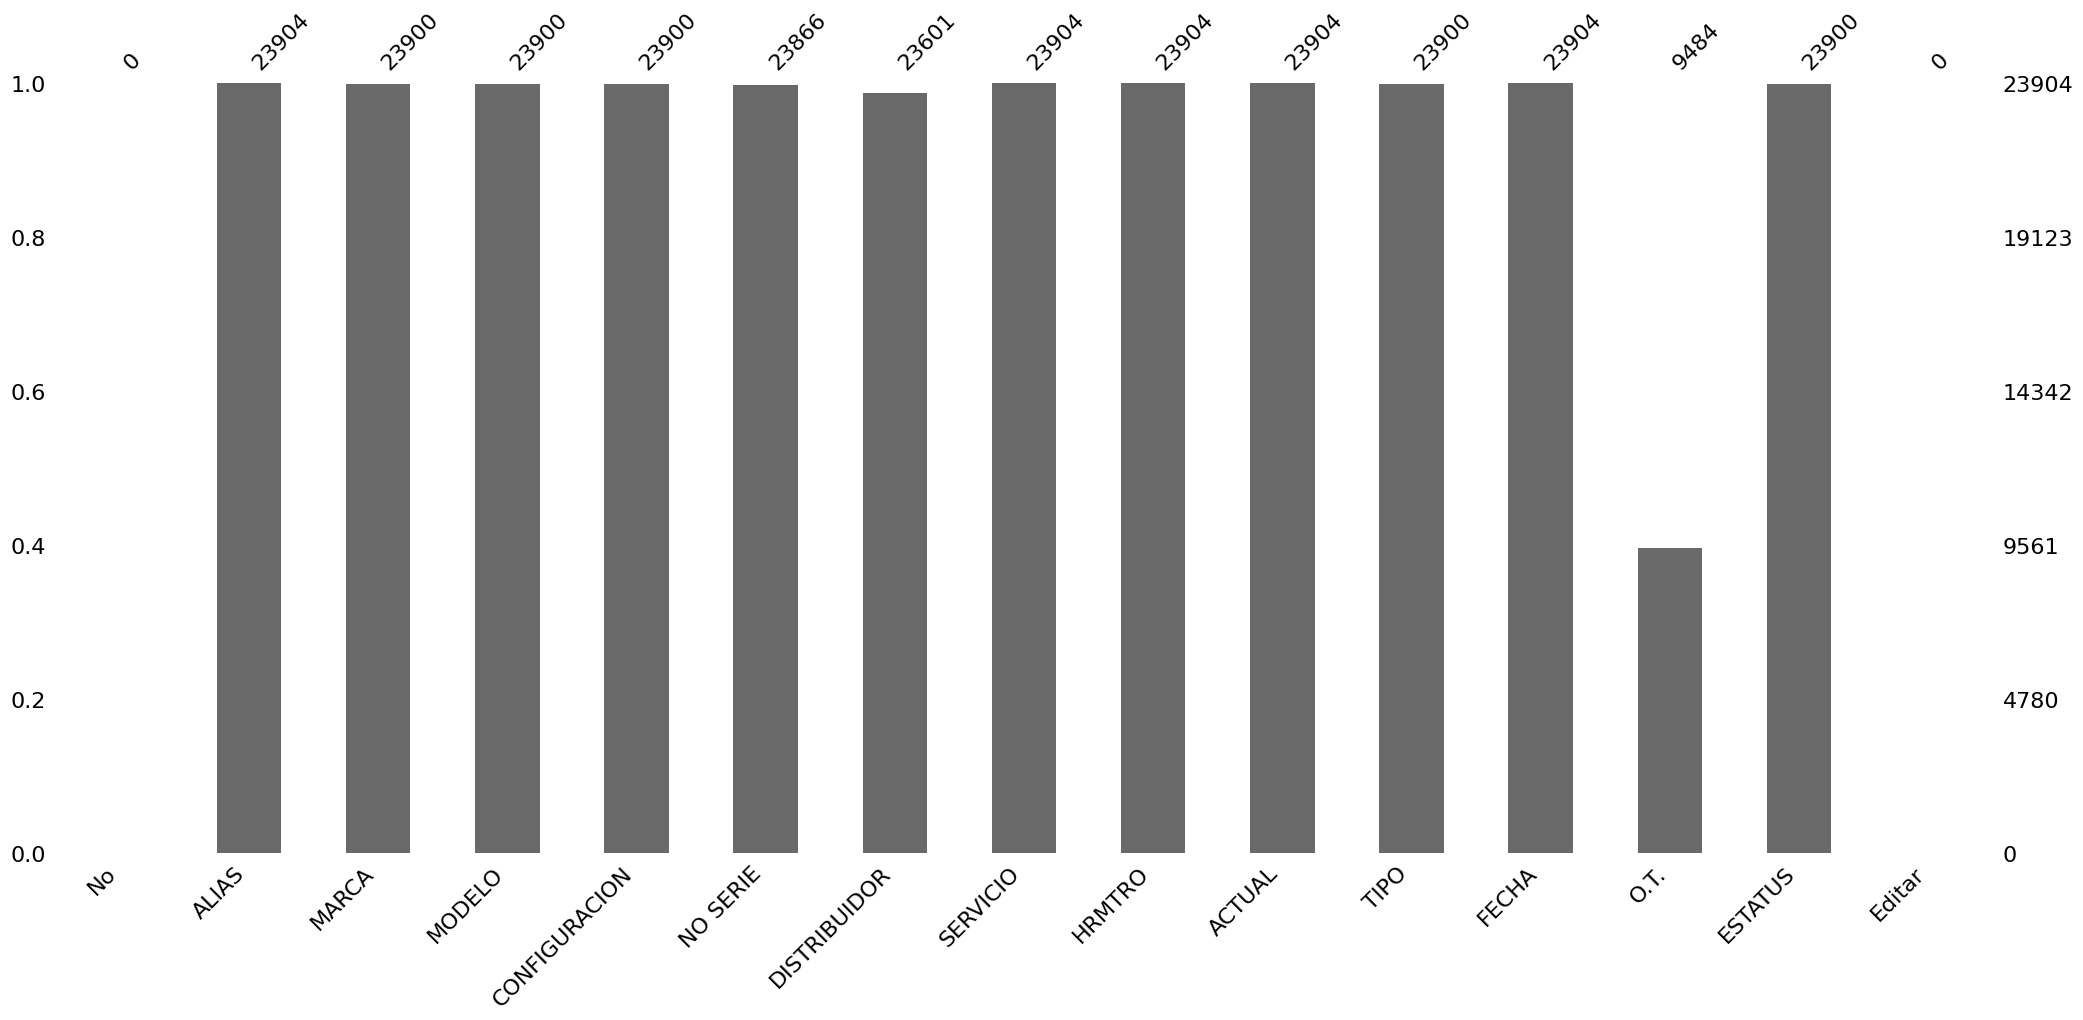

In [ ]:
msno.bar(df_Mantenimientos)

Podemos ver que las columnas No y Editar presentan un 100% de valores faltantes, lo que indica que no contienen información registrada dentro del dataset. Por otro lado, la columna O.T. tiene aproximadamente un 60% de valores nulos, lo que hay un registro incompleto o inconsistente de las órdenes de trabajo.

<Axes: >

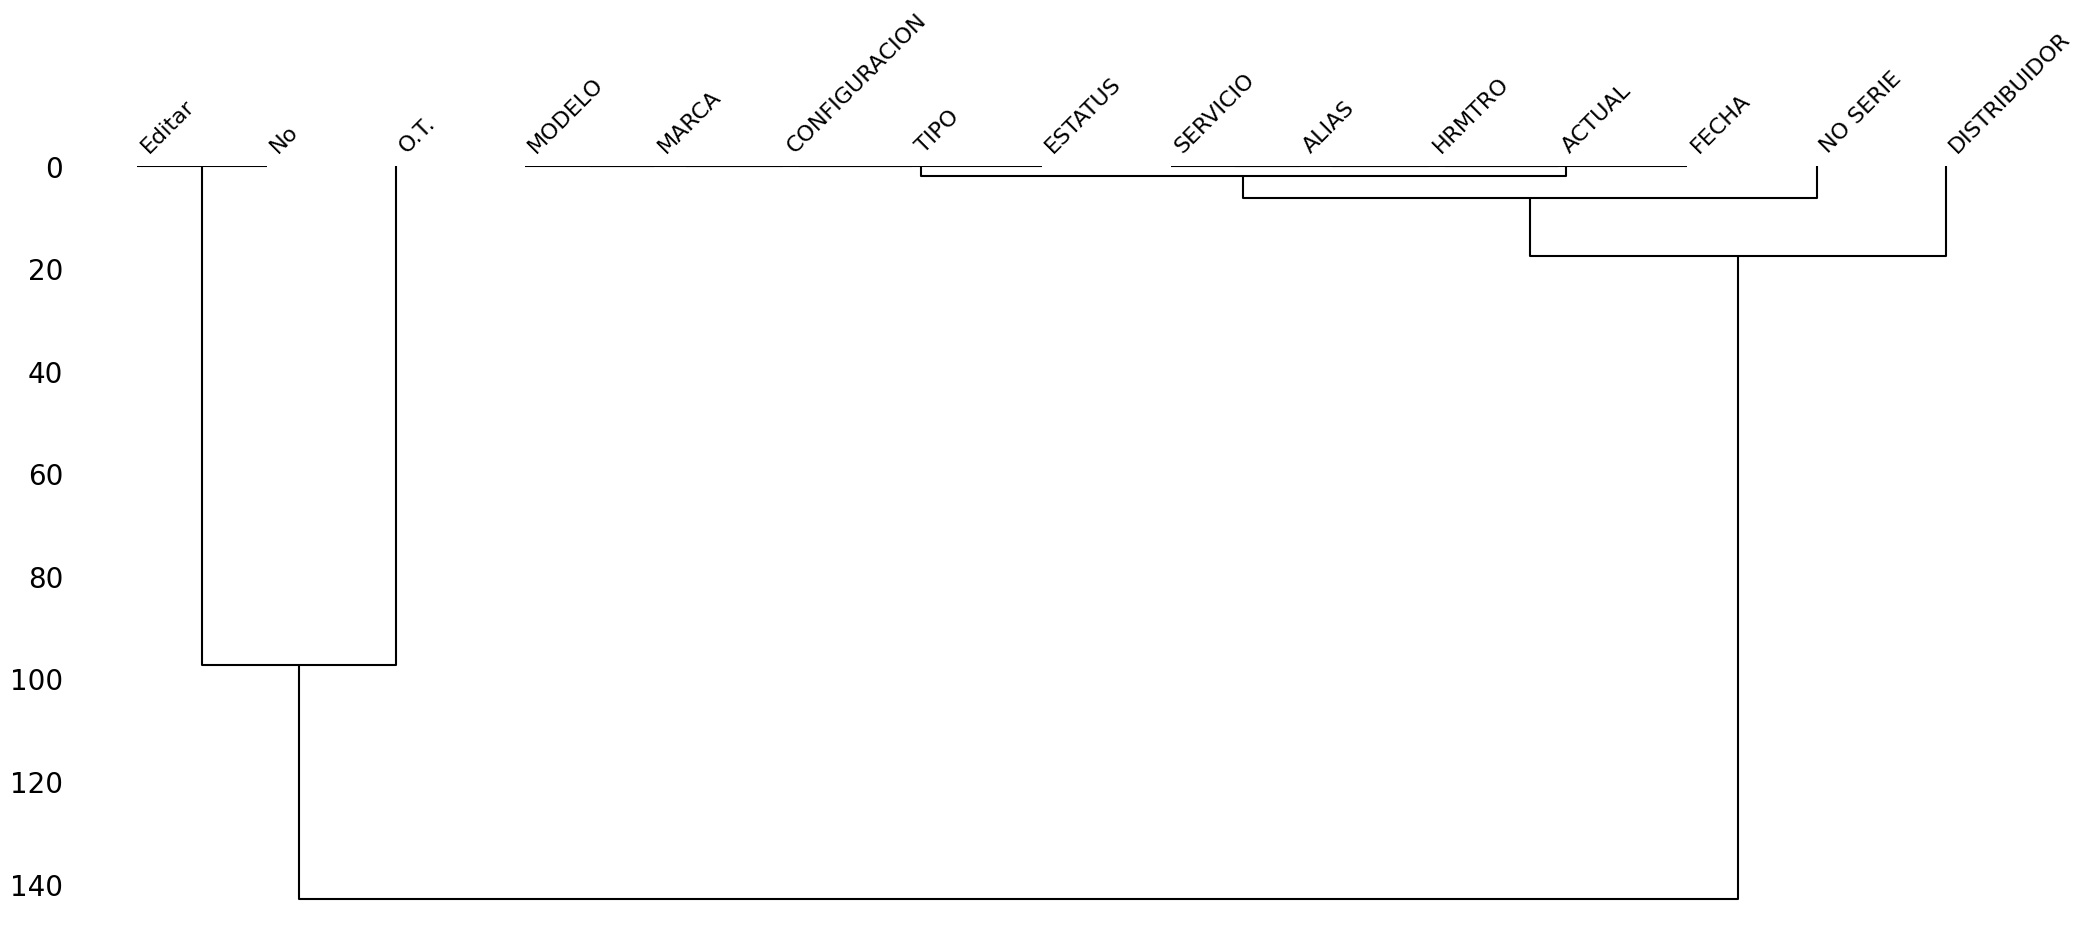

In [ ]:
msno.dendrogram(df_Mantenimientos)

En el dendrograma podemos ver que las columnas Editar, No y O.T. se agrupan dentro del mismo clúster, por lo que sus valores faltantes tienden a aparecer juntos, ya que son campos relacionados con el registro y control de órdenes de trabajo, por lo que cuando no se captura información de una orden, varios de estos atributos permanecen vacíos al mismo tiempo.

Por otro lado, variables como MODELO, MARCA, CONFIGURACIÓN, TIPO y ESTATUS se encuentran mucho más cercanas entre sí y presentan una mayor completitud, lo que sugiere que corresponden a información básica y esencial del equipo que normalmente sí se registra de manera consistente.

In [ ]:
# Porcentajes de nulos
NulosPorcentaje = df_Mantenimientos.isnull().mean() * 100
print(NulosPorcentaje.sort_values(ascending=False).round(2))

No              100.0000
Editar          100.0000
O.T.             60.3200
DISTRIBUIDOR      1.2700
NO SERIE          0.1600
CONFIGURACION     0.0200
MARCA             0.0200
TIPO              0.0200
MODELO            0.0200
ESTATUS           0.0200
ALIAS             0.0000
ACTUAL            0.0000
HRMTRO            0.0000
SERVICIO          0.0000
FECHA             0.0000
dtype: float64


In [ ]:
df_Mantenimientos["ALIAS"].nunique()

6775

In [ ]:
df_Mantenimientos["MODELO"].nunique()

23

In [ ]:
df_Mantenimientos["DISTRIBUIDOR"].nunique()

32

## Renombrar columnas, y tipos de datos

In [ ]:
# Cambiamos el nombre de las columnas para que tenga el nombre más óptimo y preferente de python
df_Mantenimientos.columns = df_Mantenimientos.columns.str.lower().str.replace(" ", "_").str.replace("(", "").str.replace(")", "")

In [ ]:
# Convertir fecha a datetime
df_Mantenimientos["fecha"] = pd.to_datetime(df_Mantenimientos["fecha"], errors="coerce")

In [ ]:
df_Mantenimientos["hrmtro"] = (pd.to_numeric(df_Mantenimientos["hrmtro"], errors="coerce").round().astype("int64"))

In [ ]:
# Comprobamos que si funciono.
df_Mantenimientos.sample(3)

,no,alias,marca,modelo,configuracion,no_serie,distribuidor,servicio,hrmtro,actual,tipo,fecha,o.t.,estatus,editar
19858,NaN,MADISA-5801104M-866392061533307,NEW HOLLAND AG,7810,4WD,5801104M-728351404,MADISA,1200,1160,2455,Preventivo,2025-10-01 13:39:00,NO APLICA,CerradaFuera,NaN
9443,NaN,TRACSA - S306723M,NEW HOLLAND AG,6610S HERENCIA,4WD,S306723M-8109015,AGTRAC,900,969,2238,Preventivo,2024-05-12 10:20:00,NaN,Pendiente,NaN
20762,NaN,866392068834955,NEW HOLLAND AG,TS6.125,FWD 8X8 MS CABINA,4100347M-002034695,ARBSA,600,560,765,Preventivo,2025-09-24 14:40:00,110913,Cerrada,NaN


In [ ]:
df_Mantenimientos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23904 entries, 0 to 23903
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   no             0 non-null      float64       
 1   alias          23904 non-null  object        
 2   marca          23900 non-null  object        
 3   modelo         23900 non-null  object        
 4   configuracion  23900 non-null  object        
 5   no_serie       23866 non-null  object        
 6   distribuidor   23601 non-null  object        
 7   servicio       23904 non-null  int64         
 8   hrmtro         23904 non-null  int64         
 9   actual         23904 non-null  int64         
 10  tipo           23900 non-null  object        
 11  fecha          23904 non-null  datetime64[ns]
 12  o.t.           9484 non-null   object        
 13  estatus        23900 non-null  object        
 14  editar         0 non-null      float64       
dtypes: datetime64[ns](1

Se renombraron las columnas para mejorar la legibilidad, consistencia y facilidad de manipulación en Python, ya que ahora tiene el estilo preferente.

Además se módifico el tipo de dato de dos columnas la de fecha se convirtió a formato datetime para permitir análisis temporal de los servicios de mantenimiento.

Y la columna de hrmtro se convirtió a tipo numérico entero, redondeando previamente los valores, ya que solo había dos instancias en las que tenía decimal. Esta transformación permite trabajar con valores discretos sin perder la interpretación del dato.

Las columnas categóricas se mantuvieron como tipo texto, ya que representan identificadores o categorías. Y Las columnas no y editar no contienen datos, por lo que no aportan valor analítico y pueden considerarse irrelevantes para el análisis. Y dado que hay duplicados y no está vacío el indice se queda igual.

## Exploración con descriptores estadísticos

In [ ]:
# Variables numéricas principales
df_Mantenimientos[["servicio", "hrmtro", "actual"]].describe()

,servicio,hrmtro,actual
count,"23,904.0000","23,904.0000","23,904.0000"
mean,"1,457.4883","1,458.9729","2,263.3255"
std,"1,398.0318","1,401.0968","1,713.1600"
min,0.0000,0.0000,0.0000
25%,600.0000,560.0000,"1,064.0000"
50%,"1,200.0000","1,160.0000","1,871.0000"
75%,"2,100.0000","2,060.0000","2,974.0000"
max,"13,200.0000","20,100.0000","13,256.0000"


In [ ]:
# Variable categórica principal
df_Mantenimientos["tipo"].value_counts(dropna=False)

,count
tipo,
Preventivo,23898
NaN,4
Correctivo,2


In [ ]:
df_Mantenimientos["distribuidor"].value_counts(dropna=False)

,count
distribuidor,
AGTRAC,4045
TEPSA,3140
MADISA,3017
ATN,2828
ATC,1673
ALTENOS,1466
AGROCISA,1392
ARBSA,1335
DASSA,1103


In [ ]:
df_Mantenimientos["estatus"].value_counts(dropna=False)

,count
estatus,
Pendiente,12667
CerradaFuera,5612
Cerrada,5037
PorVencer,493
EnProceso,79
Abierta,12
NaN,4


In [ ]:
df_Mantenimientos["fecha"].min()

Timestamp('2024-01-01 10:26:00')

In [ ]:
df_Mantenimientos["fecha"].max()

Timestamp('2025-12-30 19:00:00')

Hallazgos

Para las variables numéricas servicio, hrmtro y actual, que representan las horas relacionadas con mantenimiento y uso de los equipos, se cuenta con un total de 23,904 registros.

La variable servicio presenta un promedio de 1,457 horas, con un mínimo de 0 y un máximo de 13,200 horas. Por su parte, hrmtro tiene un comportamiento muy similar, con un promedio de 1,458 horas y un máximo de 20,100 horas, lo que indica que ambas variables están estrechamente relacionadas.

La variable actual muestra un promedio más alto (2,263 horas) y un máximo de 13,256 horas, lo que sugiere que en muchos casos el equipo ya ha superado el punto de servicio programado.

En los cuartiles, el 25% de los equipos se encuentran alrededor de 600 horas, el 50% cerca de 1,200 horas, lo que nos dice que la mayoría de los equipos estan en rangos medios de uso. Sin embargo, existen valores máximos significativamente altos, lo que evidencia alta dispersión y posibles valores atípicos.

La variable estatus presenta mayor variabilidad, destacando que la mayoría de los servicios están en estado Pendiente (12,667 registros), seguida de CerradaFuera (5,612) y Cerrada (5,037). También existen estados como PorVencer, EnProceso y Abierta, aunque en menor proporción. Esto sugiere que una gran parte de los mantenimientos aún no se han completado.

La base contiene información sobre mantenimiento preventivo, con una alta concentración de servicios pendientes y evidencia de equipos que podrían estar operando por encima de sus intervalos de servicio, lo que representa una oportunidad para mejorar la gestión del mantenimiento.

## Identificación de columnas para enlazar

Se tienen varias posibles columnas que podrían ser utilizadas para enlazar este dataset con otras fuentes de información, tales como:

no_serie (mantenimiento) con algún otro de los df ya que son el identificador único de las unidades.

La columna con mayor potencial para enlazar a los otros dataframes es la de division que podría representar la misma entidad (distribuidor/división). Estas columnas representan la misma entidad (distribuidor), por lo que tienen alto potencial para ser utilizadas como llaves de enlace, aunque pueden existir diferencias en formato, nomenclatura o escritura.

## Fuente 2: Telematrix (Reporte unidades dia anterior)

**Fuente de datos**: Plataforma externa de telematrix, que contiene la información operativa, geográfica y de mantenimiento de unidades

**Obtención de datos**: Los datos fueron exportados manualmente desde la plataforma externa y se nos entregaron en formato Excel (.xlsx).

**Descripción**: Concentra la información de cada unidad/equipo con telemetría,
su ubicación y sus métricas operativas.Incluye un bloque de servicios con conteos de trabajos cerrados, cerrados fuera y pendientes, y un bloque de estatus por intervalos de mantenimiento, que permite ver de forma inmediata el estado preventivo de cada unidad.

## Diccionario de Datos
| Columna | Tipo (pandas) | Descripción |
|---------|---------------|------------|
| no | int64 | Identificador del registro. |
| imei | object | Identificador único del dispositivo de telemetría. |
| alias | object | Nombre o identificador asignado al equipo. |
| marca | object | Marca del equipo. |
| modelo | object | Modelo del equipo. |
| configuracion | object | Configuración técnica del equipo. |
| fecha_alta | datetime64 | Fecha de alta del equipo en el sistema. |
| no_serie | object | Número de serie del equipo. |
| distribuidor | object | Distribuidor asociado al equipo. |
| ciudad | object | Ciudad donde se encuentra el equipo. |
| estado | object | Estado o región del equipo. |
| horometro | float64 | Horas acumuladas de uso del equipo. |
| odometro | float64 | Kilómetros acumulados del equipo. |
| total_servicios | int64 | Total de servicios del equipo. |
| cerrados | int64 | Número de servicios cerrados. |
| c_fuera | int64 | Número de servicios cerrados fuera de tiempo. |
| pendientes | int64 | Número de servicios pendientes. |
| 50 | object | Estado del mantenimiento a las 50 horas. |
| 300 | object | Estado del mantenimiento a las 300 horas. |
| 600 | object | Estado del mantenimiento a las 600 horas. |
| 900 | object | Estado del mantenimiento a las 900 horas. |
| 1200 | object | Estado del mantenimiento a las 1200 horas. |
| 1500 | object | Estado del mantenimiento a las 1500 horas. |
| 1800 | object | Estado del mantenimiento a las 1800 horas. |
| 2100 | object | Estado del mantenimiento a las 2100 horas. |
| 2400 | object | Estado del mantenimiento a las 2400 horas. |
| cliente | object | Nombre del cliente asociado al equipo (dato parcial). |
| telefono | object | Teléfono del cliente (dato parcial). |
| email | object | Correo electrónico del cliente (dato parcial). |
| latitud | float64 | Coordenada geográfica de latitud. |
| longitud | float64 | Coordenada geográfica de longitud. |
| pep | float64 | Código interno (sin datos relevantes). |
| combustible | float64 | Nivel o consumo de combustible del equipo. |
| distancia | float64 | Distancia recorrida por el equipo (km). |
| vel_maxima_kph | int64 | Velocidad máxima registrada (km/h). |
| vel_promedio_kph | float64 | Velocidad promedio registrada (km/h). |
| t_encendido_hrs | float64 | Tiempo total de encendido del equipo (horas). |
| t_apagado_hrs | float64 | Tiempo total de apagado del equipo (horas). |

## Volumen de Datos

Total de registros: 10846

Total de columnas: 38

Tipos de datos: datetime64(1), float64(10), int64(6), object(21)

Unidades únicas: 10106

Modelos de maquinarias únicos: 84

Distribuidores únicos: 35

Periodo cubierto: 01/01/1900 a 09/02/2026

Ciudades únicas: 627

Estados únicos: 33

Valores nulos: 116124
* PEP 10846 (100.00%)
* Telefono 10654 (98.23%)
* Email 10631 (98.02%)
* Cliente 10482 (96.64%)
* 2400 9644 (88.92%)
* 2100 9253 (85.31%)
* 1800 8775 (80.91%)
* 1500 8196 (75.57%)
* 1200 7538 (69.50%)
* 900 6743 (62.17%)
* 600 5905 (54.44%)
* 300 4932 (45.47%)
* 50 4016 (37.03%)
* Configuracion 1416 (13.06%)
* Estado 1203 (11.09%)
* Ciudad 1203 (11.09%)
* Distribuidor 1203 (11.09%)
* Modelo 939 (8.66%)
* Marca 717 (6.61%)
* No. Serie 710 (6.55%)
* Fecha Alta 642 (5.92%)
* Latitud 238 (2.19%)
* Longitud 238 (2.19%)

## EDA INicial

In [ ]:
df_UnidadesDiaAnt = pd.read_excel('Reporte_unidades_dia_anterior.xlsx')

In [ ]:
df_UnidadesDiaAnt.head(3)

,No,IMEI,Alias,Marca,Modelo,Configuracion,Fecha Alta,No. Serie,Distribuidor,Ciudad,Estado,Horometro,Odometro,Total,Cerrados,C.Fuera,Pendientes,50,300,600,900,1200,1500,1800,2100,2400,Cliente,Telefono,Email,Latitud,Longitud,PEP,Combustible,Distancia,Vel. Maxima (kph),Vel. Promedio (kph),T. Encendido (hrs),T. Apagado (hrs)
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.7091,-100.3653,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000
2,3,352556102529786,352556102529786,NEW HOLLAND AG,NaN,NaN,2024-02-09,ZEBG01193,TRACSAGRAL,San Pedro Tlaquepaque,Jalisco,"6,179.5600",0.0500,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.5777,-103.3423,NaN,0.0000,0.0000,0,0.0000,0.0000,24.0000


In [ ]:
df_UnidadesDiaAnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   No                   10846 non-null  int64         
 1   IMEI                 10846 non-null  object        
 2   Alias                10846 non-null  object        
 3   Marca                10129 non-null  object        
 4   Modelo               9907 non-null   object        
 5   Configuracion        9430 non-null   object        
 6   Fecha Alta           10204 non-null  datetime64[ns]
 7   No. Serie            10136 non-null  object        
 8   Distribuidor         9643 non-null   object        
 9   Ciudad               9643 non-null   object        
 10  Estado               9643 non-null   object        
 11  Horometro            10846 non-null  float64       
 12  Odometro             10846 non-null  float64       
 13  Total                10846 non-

In [ ]:
df_UnidadesDiaAnt.isnull().sum().sum()

np.int64(116124)

In [ ]:
df_UnidadesDiaAnt.isnull().sum()

,0
No,0
IMEI,0
Alias,0
Marca,717
Modelo,939
Configuracion,1416
Fecha Alta,642
No. Serie,710
Distribuidor,1203
Ciudad,1203


<Axes: >

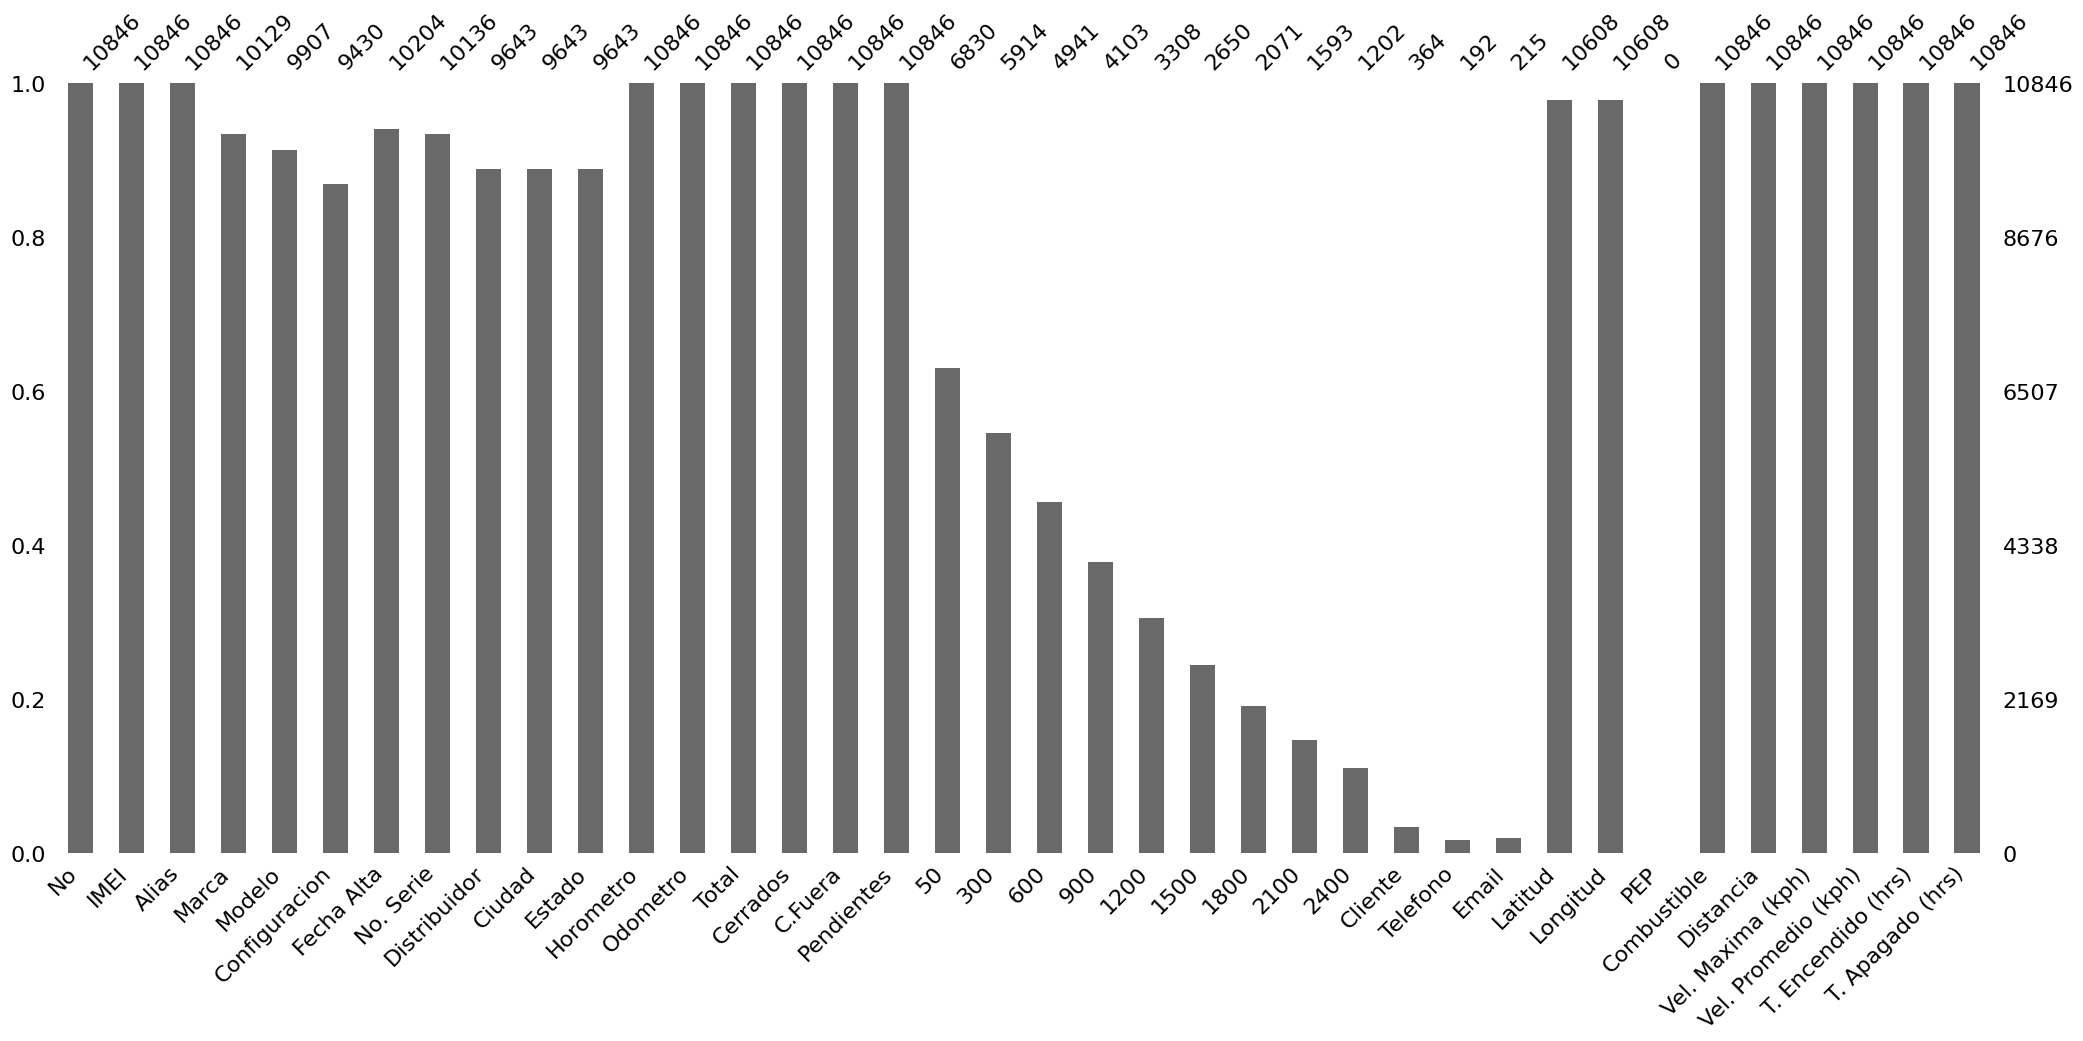

In [ ]:
msno.bar(df_UnidadesDiaAnt)

<Axes: >

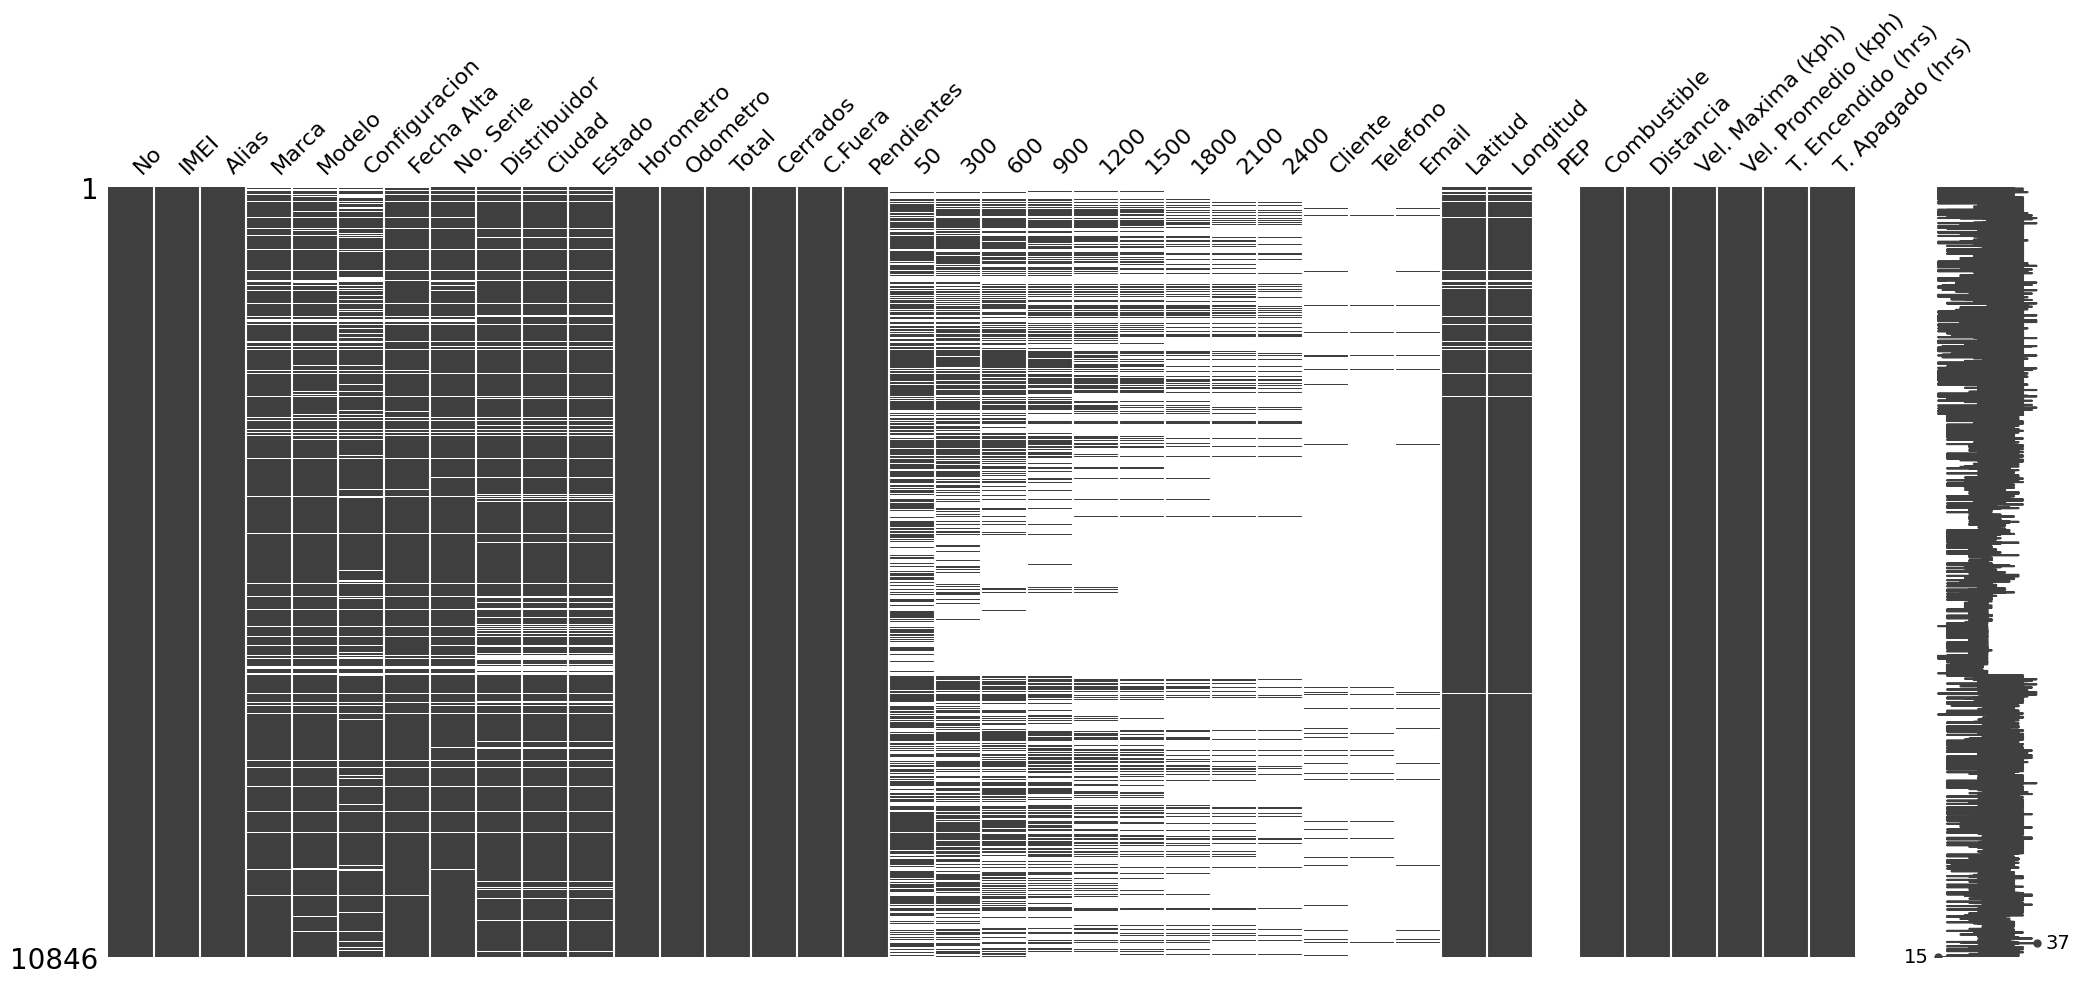

In [ ]:
msno.matrix(df_UnidadesDiaAnt)

Podemos ver que las columnas PEP, Telefono, Email y Cliente presentan los mayores porcentajes de valores faltantes, superando el 95% en todos los casos. Por lo que la información relacionada con contacto y perfil del cliente rara vez es registrada dentro del dataset.

De igual forma, las columnas 2400, 2100, 1800, 1500, 1200, 900, 600, 300 y 50 también presentan una gran cantidad de datos faltantes, por lo que podemos ver que muchos de los mantenimientos no se están haciendo o que no siempre son capturados de manera consistente.

Por otro lado, variables como Alias, IMEI, Odometro, Horometro, Combustible, Distancia y Vel. Maxima (kph) no tienen valores nulos.

<Axes: >

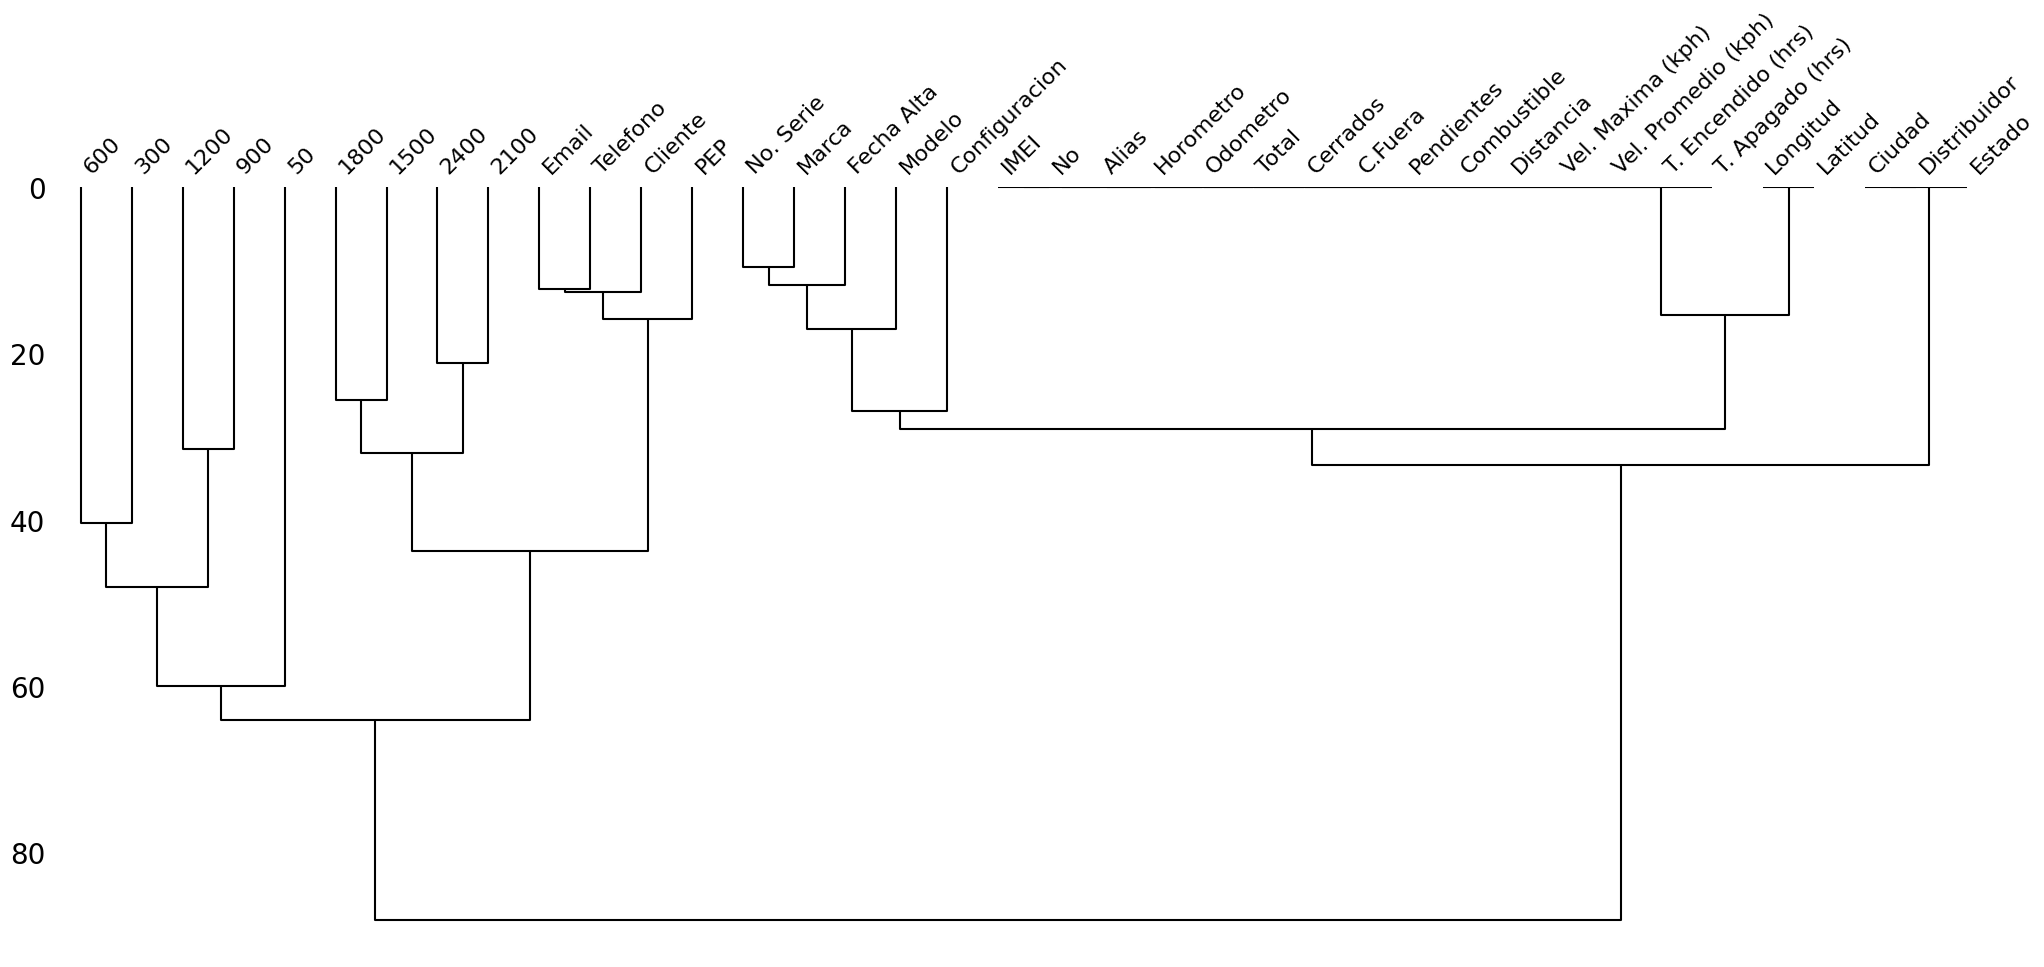

In [ ]:
msno.dendrogram(df_UnidadesDiaAnt)

En el dendrograma podemos ver que las columnas Email, Telefono, Cliente y PEP se agrupan dentro del mismo clúster, por lo que que sus valores faltantes tienden a presentarse juntos, fácil de entender ya que todas corresponden a información de contacto y perfil del cliente.

También podemos ver que las columnas 600, 300, 1200, 900, 50, 1800, 1500, 2400 y 2100 forman grupos cercanos entre sí, sugiriendo que comparten patrones similares de ausencia de datos, por lo que igual que dijimos en el de barras es probable que no se esten haciendo algunos mantenimeintos y que si salten un mantenimeinto probablemente se salten el siguiente o que no siempre son registrados.

Por otro lado, variables como IMEI, Horometro, Odometro, Combustible, Distancia y Vel. Promedio presentan una mayor completitud y se encuentran más alejadas de los grupos con altos niveles de nulos, por lo que la información operativa y telemática sí se captura de manera más consistente.

In [ ]:
#  Porcentajes de nulos
NulosPorcentaje = df_UnidadesDiaAnt.isnull().mean() * 100
print(NulosPorcentaje.sort_values(ascending=False).round(2))

PEP                   100.0000
Telefono               98.2300
Email                  98.0200
Cliente                96.6400
2400                   88.9200
2100                   85.3100
1800                   80.9100
1500                   75.5700
1200                   69.5000
900                    62.1700
600                    54.4400
300                    45.4700
50                     37.0300
Configuracion          13.0600
Estado                 11.0900
Ciudad                 11.0900
Distribuidor           11.0900
Modelo                  8.6600
Marca                   6.6100
No. Serie               6.5500
Fecha Alta              5.9200
Latitud                 2.1900
Longitud                2.1900
Alias                   0.0000
No                      0.0000
IMEI                    0.0000
Odometro                0.0000
Horometro               0.0000
Pendientes              0.0000
Total                   0.0000
C.Fuera                 0.0000
Cerrados                0.0000
Combusti

In [ ]:
df_UnidadesDiaAnt["No. Serie"].nunique()

10106

In [ ]:
df_UnidadesDiaAnt["Modelo"].nunique()

84

In [ ]:
df_UnidadesDiaAnt["Distribuidor"].nunique()

35

In [ ]:
df_UnidadesDiaAnt["Fecha Alta"].min()

Timestamp('1900-01-01 00:00:00')

In [ ]:
df_UnidadesDiaAnt["Fecha Alta"].max()

Timestamp('2026-02-09 00:00:00')

In [ ]:
df_UnidadesDiaAnt["Ciudad"].nunique()

627

In [ ]:
df_UnidadesDiaAnt["Estado"].nunique()

33

## Renombrar columnas, y tipos de datos

In [ ]:
# Cambiamos el nombre de las columnas para que tenga el nombre más óptimo y preferente de python
df_UnidadesDiaAnt.columns = (
    df_UnidadesDiaAnt.columns
    .astype(str)
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [ ]:
df_UnidadesDiaAnt = df_UnidadesDiaAnt.rename(columns={"total": "total_servicios"})

In [ ]:
df_UnidadesDiaAnt.head(3)

,no,imei,alias,marca,modelo,configuracion,fecha_alta,no._serie,distribuidor,ciudad,estado,horometro,odometro,total_servicios,cerrados,c.fuera,pendientes,50,300,600,900,1200,1500,1800,2100,2400,cliente,telefono,email,latitud,longitud,pep,combustible,distancia,vel._maxima_kph,vel._promedio_kph,t._encendido_hrs,t._apagado_hrs
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.7091,-100.3653,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000
2,3,352556102529786,352556102529786,NEW HOLLAND AG,NaN,NaN,2024-02-09,ZEBG01193,TRACSAGRAL,San Pedro Tlaquepaque,Jalisco,"6,179.5600",0.0500,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.5777,-103.3423,NaN,0.0000,0.0000,0,0.0000,0.0000,24.0000


In [ ]:
df_UnidadesDiaAnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   no                 10846 non-null  int64         
 1   imei               10846 non-null  object        
 2   alias              10846 non-null  object        
 3   marca              10129 non-null  object        
 4   modelo             9907 non-null   object        
 5   configuracion      9430 non-null   object        
 6   fecha_alta         10204 non-null  datetime64[ns]
 7   no._serie          10136 non-null  object        
 8   distribuidor       9643 non-null   object        
 9   ciudad             9643 non-null   object        
 10  estado             9643 non-null   object        
 11  horometro          10846 non-null  float64       
 12  odometro           10846 non-null  float64       
 13  total_servicios    10846 non-null  int64         
 14  cerrad

Se renombraron las columnas para mejorar la legibilidad, consistencia y facilidad de manipulación en Python, ya que ahora tiene el estilo preferente. Se renombraron las columnas para mejorar la legibilidady consistencia. Y no se cambio el tipo de datos ya que todos estaban en el tipo correcto. Además se dejo el indice como estaba

## Exploración con descriptores estadísticos

In [ ]:
# variables numéricas
df_UnidadesDiaAnt.describe()

,no,fecha_alta,horometro,odometro,total_servicios,cerrados,c.fuera,pendientes,latitud,longitud,pep,combustible,distancia,vel._maxima_kph,vel._promedio_kph,t._encendido_hrs,t._apagado_hrs
count,"10,846.0000",10204,"10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,608.0000","10,608.0000",0.0000,"10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000"
mean,"5,423.5000",2023-04-29 07:28:37.444139776,"1,137.2816",177.9915,5.7537,0.9966,0.7126,4.7571,21.3362,-101.0996,NaN,13.5737,5.1303,4.4540,1.0997,1.6330,19.7051
min,1.0000,1900-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-117.0176,NaN,-37.9600,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,712.2500",2022-09-14 00:00:00,115.1275,0.3600,0.0000,0.0000,0.0000,0.0000,19.2357,-103.1756,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,18.7400
50%,"5,423.5000",2023-06-19 00:00:00,690.5850,15.9600,3.0000,0.0000,0.0000,2.0000,20.5721,-101.0325,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,24.0000
75%,"8,134.7500",2024-07-29 00:00:00,"1,644.7675",76.2275,7.0000,1.0000,0.0000,5.0000,22.9500,-98.3805,NaN,4.3700,1.4375,7.0000,0.7500,1.4400,24.0000
max,"10,846.0000",2026-02-09 00:00:00,"77,300.6900","45,518.6600",166.0000,29.0000,29.0000,166.0000,32.6243,0.0000,NaN,263.8700,"1,552.5300",295.0000,100.9000,23.9300,24.0000
std,"3,131.1148",NaN,"1,610.8222","1,047.2730",10.3247,1.7291,2.0360,10.1657,3.0172,4.4081,NaN,31.7784,26.0770,9.9408,2.9147,3.3597,7.7071


In [ ]:
df_UnidadesDiaAnt[[
    "horometro", "odometro", "vel._promedio_kph",
    "vel._maxima_kph", "distancia", "t._encendido_hrs"
]].agg(["min", "max"])

,horometro,odometro,vel._promedio_kph,vel._maxima_kph,distancia,t._encendido_hrs
min,0.0000,0.0000,0.0000,0,0.0000,0.0000
max,"77,300.6900","45,518.6600",100.9000,295,"1,552.5300",23.9300


hallazgos

La variable horometro tien un promedio de 1,137 horas, con un mínimo de 0 y un máximo de 77,300 horas, por lo que hya mucha diferencia en el uso de las unidades. Por su parte, el odometro tiene un promedio de 177 km y un máximo de 45,518 km, mostrando un comportamiento similar en cuanto a variabilidad.

La distancia recorrida tiene un promedio de 5.13 km, con un máximo de 1,552 km, mientras que la velocidad máxima alcanza hasta 295 km/h, que sugiere posibles errores en la captura de datos. La velocidad promedio es considerablemente baja (1.09 km/h), lo cual es consistente con maquinaria operativa.

En cuanto a los tiempos de uso, el tiempo_encendido_hrs presenta un promedio de 1.63 horas, mientras que el tiempo_apagado_hrs tiene un promedio de 19.70 horas, por lo que los equipos permanecen la mayor parte del tiempo sin operación.

En las variables de servicios, el total_servicios presenta un promedio de 5.75, con un máximo de 166 servicios. La mayoría de los registros se concentran en valores bajos, ya que el 50% de los equipos tiene 3 servicios o menos.

En cuanto al estatus de los servicios, la variable pendientes tiene un promedio de 4.75, superior a cerrados (0.99) y c_fuera (0.71), lo que indica que una gran parte de los servicios aún no han sido atendidos.

Adicionalmente, se identifican inconsistencias en los datos, como valores negativos en la variable combustible (-37.96) y fechas que comienzan en 1900, lo cual no es coherente con la operación real y sugiere errores en la captura de información.

## Identificación de columnas para enlazar

Se tienen varias posibles columnas que podrían ser utilizadas para enlazar este dataset con otras fuentes de información, tales como:

no_serie, ya que representa el identificador único de las unidades, por lo que tiene alto potencial para relacionarse con otros dataframes que contengan información de mantenimiento, telemetría o historial de uso.

cliente, la cual puede permitir enlazar con bases de datos comerciales o de gestión de clientes, facilitando el análisis por tipo de usuario o segmento.

distribuidor, que puede coincidir con columnas como division en otros dataframes, representando la misma entidad (distribuidor), aunque pueden existir diferencias en nomenclatura o formato.

La columna con mayor potencial para enlazar los diferentes dataframes es no_serie, ya que funciona como identificador único de cada unidad. Sin embargo, columnas como distribuidor y cliente también pueden ser utilizadas como llaves secundarias, considerando posibles problemas de calidad en los datos.

## Fuente 3: Telematrix (Horas 2024-2025)
**Fuente de datos**: Plataforma interna de la empresa denfocada en horas de los agroequipos.

**Obtención de datos**: Los datos fueron exportados manualmente desde la plataforma interna y se nos entregaron en formato Excel (.xlsx).

**Descripción**: Esta hoja contiene información de identificación y características de equipos, además de las horas mensuales registradas durante 2024. Cada registro corresponde a un equipo individual.

## Diccionario de Datos
##Hoja del 2024
| Columna      | Tipo (pandas) | Descripción                                                   |
| ------------ | ------------- | ------------------------------------------------------------- |
| Num          | int64         | Número consecutivo del registro.                              |
| Distribuidor | object        | Nombre del distribuidor asociado al equipo o tractor.         |
| IMEI         | int64         | Identificador numérico del equipo, tractor o dispositivo.     |
| Alias        | object        | Nombre alterno o identificador corto del equipo.              |
| Marca        | object        | Marca del tractor o equipo.                                   |
| Modelo       | object        | Modelo del tractor o equipo.                                  |
| Ciudad       | object        | Ciudad en la que se ubica el equipo.                          |
| Estado       | object        | Estado en el que se ubica el equipo.                          |
| Latitud      | float64       | Coordenada geográfica de latitud de la ubicación del equipo.  |
| Longitud     | float64       | Coordenada geográfica de longitud de la ubicación del equipo. |
| 2024-01      | int64         | Horas registradas del equipo en enero de 2024.                |
| 2024-02      | int64         | Horas registradas del equipo en febrero de 2024.              |
| 2024-03      | int64         | Horas registradas del equipo en marzo de 2024.                |
| 2024-04      | int64         | Horas registradas del equipo en abril de 2024.                |
| 2024-05      | int64         | Horas registradas del equipo en mayo de 2024.                 |
| 2024-06      | int64         | Horas registradas del equipo en junio de 2024.                |
| 2024-07      | int64         | Horas registradas del equipo en julio de 2024.                |
| 2024-08      | int64         | Horas registradas del equipo en agosto de 2024.               |
| 2024-09      | int64         | Horas registradas del equipo en septiembre de 2024.           |
| 2024-10      | int64         | Horas registradas del equipo en octubre de 2024.              |
| 2024-11      | int64         | Horas registradas del equipo en noviembre de 2024.            |
| 2024-12      | int64         | Horas registradas del equipo en diciembre de 2024.            |


## Hoja 2024
| Columna      | Tipo (pandas) | Descripción                                                   |
| ------------ | ------------- | ------------------------------------------------------------- |
| Num          | int64         | Número consecutivo del registro.                              |
| Distribuidor | object        | Nombre del distribuidor asociado al equipo o tractor.         |
| IMEI         | int64         | Identificador numérico del equipo, tractor o dispositivo.     |
| Alias        | object        | Nombre alterno o identificador corto del equipo.              |
| Marca        | object        | Marca del tractor o equipo.                                   |
| Modelo       | object        | Modelo del tractor o equipo.                                  |
| Ciudad       | object        | Ciudad en la que se ubica el equipo.                          |
| Estado       | object        | Estado en el que se ubica el equipo.                          |
| Latitud      | float64       | Coordenada geográfica de latitud de la ubicación del equipo.  |
| Longitud     | float64       | Coordenada geográfica de longitud de la ubicación del equipo. |
| 2024-01      | int64         | Horas registradas del equipo en enero de 2024.                |
| 2024-02      | int64         | Horas registradas del equipo en febrero de 2024.              |
| 2024-03      | int64         | Horas registradas del equipo en marzo de 2024.                |
| 2024-04      | int64         | Horas registradas del equipo en abril de 2024.                |
| 2024-05      | int64         | Horas registradas del equipo en mayo de 2024.                 |
| 2024-06      | int64         | Horas registradas del equipo en junio de 2024.                |
| 2024-07      | int64         | Horas registradas del equipo en julio de 2024.                |
| 2024-08      | int64         | Horas registradas del equipo en agosto de 2024.               |
| 2024-09      | int64         | Horas registradas del equipo en septiembre de 2024.           |
| 2024-10      | int64         | Horas registradas del equipo en octubre de 2024.              |
| 2024-11      | int64         | Horas registradas del equipo en noviembre de 2024.            |
| 2024-12      | int64         | Horas registradas del equipo en diciembre de 2024.            |


##Volumen de datos

Hoja 2024

Total de registros: 9405

Total de columnas: 22

Tipos de datos: int64(14), object(6) y float64(2).

Unidades únicas: 8907

Distribuidores únicos: 29

País donde se encuentran las unidades: México

Período cubierto de las horas: 2024-01 a 2024-12

Valores nulos: 12586

Modelo 6263

Estado 6263

Longitud 15

Latitud 15

Ciudad 15

Marca 15

Hoja 2025

Total de registros: 10157

Total de columnas: 16

Tipos de datos: int64(14) y object(2).

Unidades únicas: 9633

Distribuidores únicos: 30

País donde se encuentran las unidades: México

Período cubierto de las horas: 2025-01 a 2025-12

Valores nulos: 0

##EDA inicial

In [ ]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

In [ ]:
columnas_2024 = ["Num", "Distribuidor", "IMEI", "Alias", "Marca", "Modelo", "Ciudad", "Estado",
                 "Latitud", "Longitud", "2024-01", "2024-02", "2024-03", "2024-04",
                 "2024-05", "2024-06", "2024-07", "2024-08", "2024-09", "2024-10",
                 "2024-11", "2024-12"]

In [ ]:
df_horas_2024 = pd.read_excel("Horas 2024-2025.xlsx", sheet_name="2024", usecols=columnas_2024)

In [ ]:
df_horas_2024.head(5)

,Num,Distribuidor,IMEI,Alias,Marca,Modelo,Ciudad,Estado,Latitud,Longitud,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,NEW HOLLAND CE,B80C,Cintalapa,Chiapas,16.6905,-93.7476,0,0,0,0,0,0,0,0,0,0,0,0
1,2,AGROEQUIPOS,353738101216677,353738101216677,NEW HOLLAND AG,7610S HERENCIA,Chahuites,Oaxaca,16.2810,-94.1989,4,30,0,0,10,0,23,14,10,1,45,0
2,3,AGROEQUIPOS,353738101232583,353738101232583,NEW HOLLAND AG,6810,Chahuites,Oaxaca,16.3099,-94.1876,0,0,0,0,0,0,0,0,76,87,108,67
3,4,AGROEQUIPOS,353738101280137,353738101280137,NEW HOLLAND AG,7610S HERENCIA,0,0,16.3024,-94.1908,79,38,23,27,24,10,2,59,8,48,48,29
4,5,AGROEQUIPOS,353738102813829,353738102813829,NEW HOLLAND AG,6810,0,0,16.2818,-94.1989,43,16,26,0,0,0,0,0,0,0,0,0


In [ ]:
df_horas_2024.shape[0]

9405

In [ ]:
df_horas_2024.shape[1]


22

In [ ]:
df_horas_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9405 entries, 0 to 9404
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Num           9405 non-null   int64  
 1   Distribuidor  9405 non-null   object 
 2   IMEI          9405 non-null   int64  
 3   Alias         9405 non-null   object 
 4   Marca         9390 non-null   object 
 5   Modelo        3142 non-null   object 
 6   Ciudad        9390 non-null   object 
 7   Estado        3142 non-null   object 
 8   Latitud       9390 non-null   float64
 9   Longitud      9390 non-null   float64
 10  2024-01       9405 non-null   int64  
 11  2024-02       9405 non-null   int64  
 12  2024-03       9405 non-null   int64  
 13  2024-04       9405 non-null   int64  
 14  2024-05       9405 non-null   int64  
 15  2024-06       9405 non-null   int64  
 16  2024-07       9405 non-null   int64  
 17  2024-08       9405 non-null   int64  
 18  2024-09       9405 non-null 

In [ ]:
df_horas_2024.isnull().sum().sum()

np.int64(12586)

In [ ]:
df_horas_2024.isnull().sum()

,0
Num,0
Distribuidor,0
IMEI,0
Alias,0
Marca,15
Modelo,6263
Ciudad,15
Estado,6263
Latitud,15
Longitud,15


<Axes: >

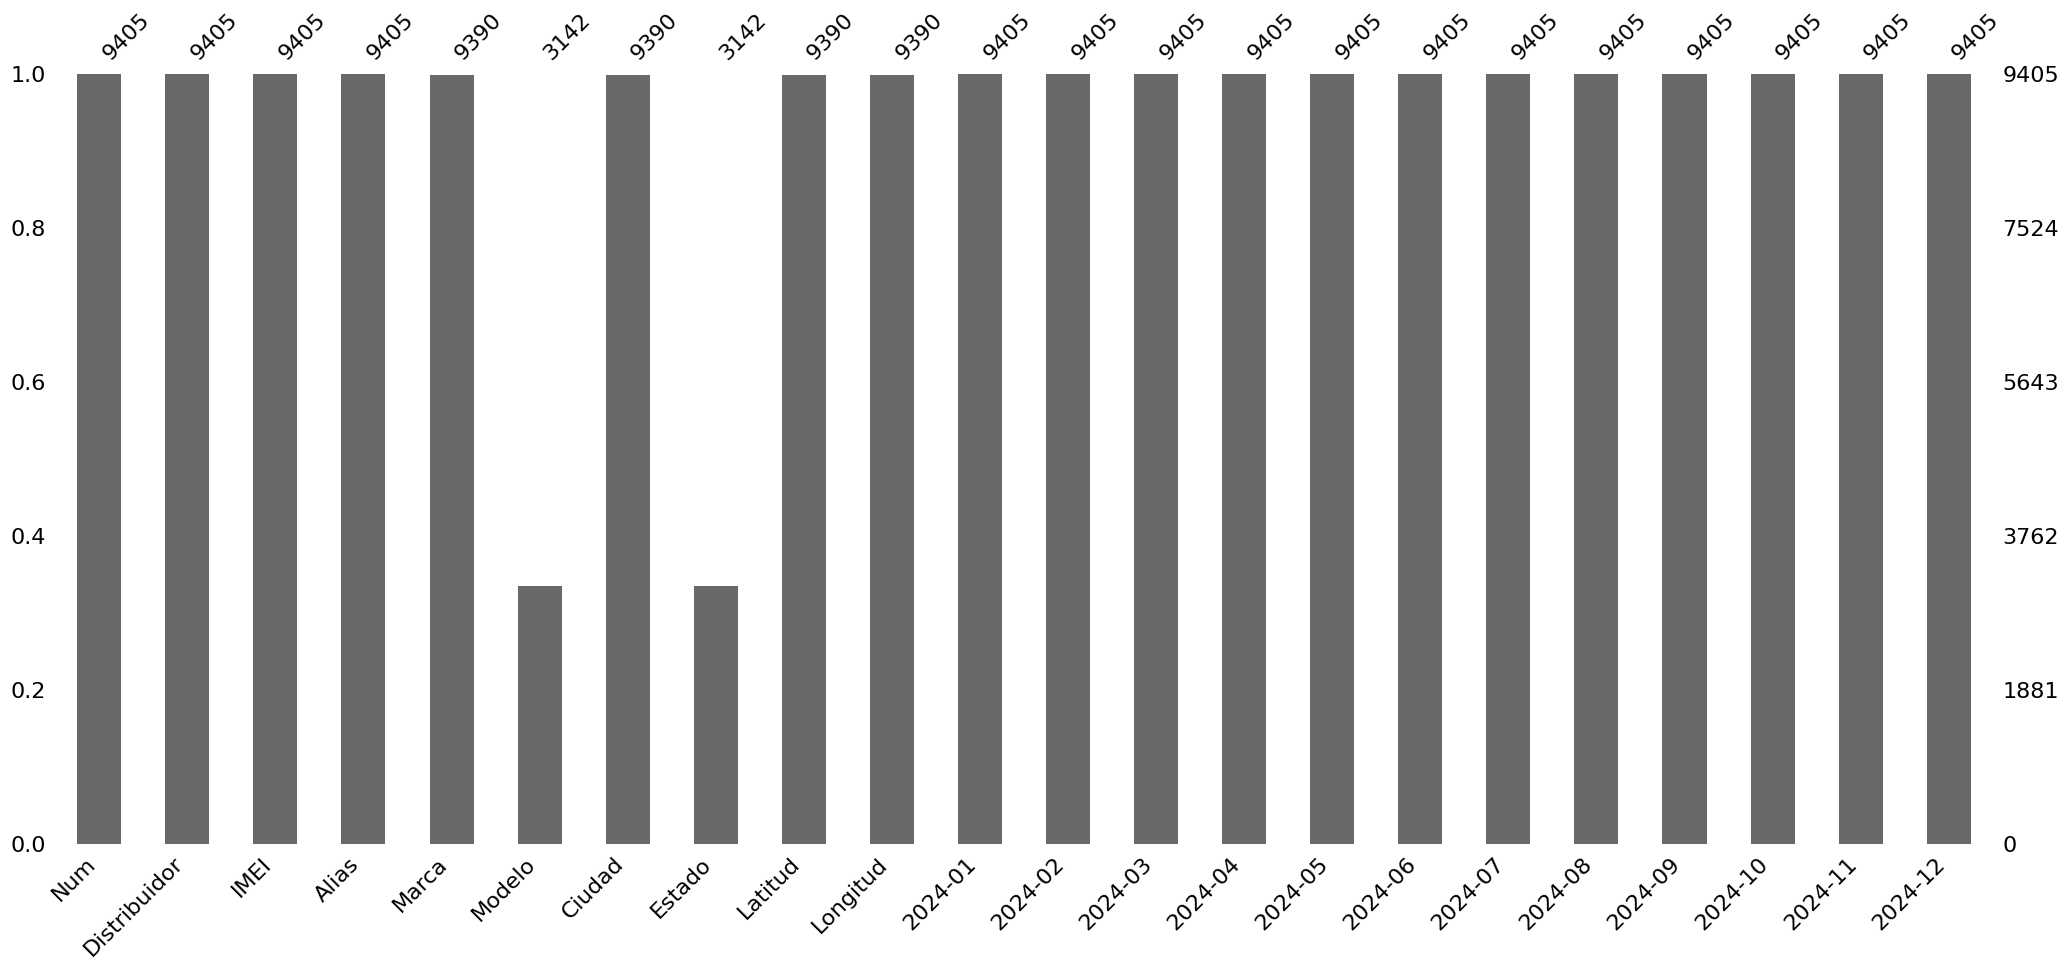

In [ ]:
msno.bar(df_horas_2024)

Podemos ver que las columnas Modelo y Estado presentan los mayores porcentajes de valores faltantes, con aproximadamente un 66% de datos nulos en ambos casos, por lo que gran parte de los registros no cuentan con información completa sobre las características generales o ubicación administrativa de los equipos.

Por otro lado, las columnas Longitud, Latitud, Ciudad y Marca presentan únicamente alrededor de un 0.16% de valores faltantes, por que lo esta información se registra de manera casi completa dentro del dataset.

Finalmente, variables como IMEI, Alias, Num, Distribuidor y todas las columnas correspondientes a los meses de 2024 no presentan valores nulos.

In [ ]:
# NULOS
NulosPorcentaje_2024 = df_horas_2024.isnull().mean() * 100
print(NulosPorcentaje_2024.sort_values(ascending=False).round(2))

Modelo         66.5900
Estado         66.5900
Longitud        0.1600
Latitud         0.1600
Ciudad          0.1600
Marca           0.1600
IMEI            0.0000
Alias           0.0000
Num             0.0000
Distribuidor    0.0000
2024-01         0.0000
2024-02         0.0000
2024-03         0.0000
2024-04         0.0000
2024-05         0.0000
2024-06         0.0000
2024-07         0.0000
2024-08         0.0000
2024-09         0.0000
2024-10         0.0000
2024-11         0.0000
2024-12         0.0000
dtype: float64


In [ ]:
df_horas_2024["IMEI"].nunique()

8907

In [ ]:
df_horas_2024["Distribuidor"].nunique()

29

In [ ]:
df_horas_2024["Marca"].nunique()

11

In [ ]:
df_horas_2024["Modelo"].nunique()

63

In [ ]:
df_horas_2024["Estado"].nunique()

19

In [ ]:
df_horas_2024["Ciudad"].nunique()

260

In [ ]:
df_horas_2024["Latitud"].min()

0.0

In [ ]:
df_horas_2024["Latitud"].max()

32.6312356

In [ ]:
df_horas_2024["Longitud"].min()

-117.018395

In [ ]:
df_horas_2024["Longitud"].max()

0.0

Total de registros: 9405

Total de columnas: 22

Tipos de datos: int64, float64 y object.

Unidades únicas (IMEI): se calculan con `nunique()`.

Distribuidores únicos: se calculan con `nunique()`.

Marcas y modelos únicos: permiten conocer la diversidad del parque de maquinaria.

Ubicación geográfica: se cuenta con información de ciudad, estado, latitud y longitud.

Valores nulos: se revisan con `isnull().sum()` y con su porcentaje correspondiente.

In [ ]:
df_horas_2024.describe()

,Num,IMEI,Latitud,Longitud,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
count,"9,405.0000","9,405.0000","9,390.0000","9,390.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000"
mean,"4,703.0000","711,628,249,608,985.6250",21.2008,-100.5634,31.2998,25.0078,24.5003,25.0180,29.8399,25.0641,25.0410,22.5942,20.5836,26.0108,23.4958,22.5763
std,"2,715.1340","233,974,257,092,514.7188",3.4384,9.0504,50.6328,42.0050,41.6204,39.6021,45.9913,37.7454,38.1009,36.6047,33.8051,38.7178,33.9291,33.4517
min,1.0000,"352,556,102,513,822.0000",0.0000,-117.0184,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,352.0000","353,738,103,090,260.0000",19.2102,-103.3257,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"4,703.0000","862,407,062,166,420.0000",20.5226,-101.5475,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,4.0000,2.0000,2.0000,5.0000,6.0000,6.0000
75%,"7,054.0000","866,392,061,524,421.0000",22.9588,-98.3409,47.0000,35.0000,33.0000,37.0000,45.0000,39.0000,38.0000,32.0000,29.0000,41.0000,37.0000,34.0000
max,"9,405.0000","866,392,069,198,814.0000",32.6312,0.0000,397.0000,344.0000,431.0000,295.0000,391.0000,358.0000,285.0000,390.0000,282.0000,367.0000,310.0000,333.0000


In [ ]:
df_horas_2024.describe(include="all")

,Num,Distribuidor,IMEI,Alias,Marca,Modelo,Ciudad,Estado,Latitud,Longitud,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
count,"9,405.0000",9405,"9,405.0000",9405,9390,3142,"9,390.0000","3,142.0000","9,390.0000","9,390.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000"
unique,NaN,29,NaN,9108,11,63,260.0000,19.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,TRACSA,NaN,DASSA - S508019M,NEW HOLLAND AG,7610S HERENCIA,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1502,NaN,3,7888,1099,"8,783.0000","3,101.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"4,703.0000",NaN,"711,628,249,608,985.6250",NaN,NaN,NaN,NaN,NaN,21.2008,-100.5634,31.2998,25.0078,24.5003,25.0180,29.8399,25.0641,25.0410,22.5942,20.5836,26.0108,23.4958,22.5763
std,"2,715.1340",NaN,"233,974,257,092,514.7188",NaN,NaN,NaN,NaN,NaN,3.4384,9.0504,50.6328,42.0050,41.6204,39.6021,45.9913,37.7454,38.1009,36.6047,33.8051,38.7178,33.9291,33.4517
min,1.0000,NaN,"352,556,102,513,822.0000",NaN,NaN,NaN,NaN,NaN,0.0000,-117.0184,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,352.0000",NaN,"353,738,103,090,260.0000",NaN,NaN,NaN,NaN,NaN,19.2102,-103.3257,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"4,703.0000",NaN,"862,407,062,166,420.0000",NaN,NaN,NaN,NaN,NaN,20.5226,-101.5475,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,4.0000,2.0000,2.0000,5.0000,6.0000,6.0000
75%,"7,054.0000",NaN,"866,392,061,524,421.0000",NaN,NaN,NaN,NaN,NaN,22.9588,-98.3409,47.0000,35.0000,33.0000,37.0000,45.0000,39.0000,38.0000,32.0000,29.0000,41.0000,37.0000,34.0000


In [ ]:
df_horas_2024["Distribuidor"].value_counts(dropna=False)

,count
Distribuidor,
TRACSA,1502
MADISA,1364
TEPSA,1161
ATN,873
AGROCISA,749
ATC,725
ALTEÑOS,674
ARBSA,483
DASSA,409


In [ ]:
df_horas_2024["Marca"].value_counts(dropna=False)

,count
Marca,
NEW HOLLAND AG,7888
CASE IH,1099
NEW HOLLAND CE,150
0,142
CASE CE,65
JOHN DEERE,31
NaN,15
CAT,7
John Deere,3


In [ ]:
df_horas_2024["Estado"].value_counts(dropna=False)

,count
Estado,
NaN,6263
0,3101
Jalisco,8
San Luis PotosÃ­,4
Puebla,3
Oaxaca,3
MÃ©xico,3
Guanajuato,3
Sonora,3


In [ ]:
df_horas_2024[["2024-01", "2024-02", "2024-03", "2024-04", "2024-05", "2024-06",
               "2024-07", "2024-08", "2024-09", "2024-10", "2024-11", "2024-12"]].describe()

,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
count,"9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000"
mean,31.2998,25.0078,24.5003,25.0180,29.8399,25.0641,25.0410,22.5942,20.5836,26.0108,23.4958,22.5763
std,50.6328,42.0050,41.6204,39.6021,45.9913,37.7454,38.1009,36.6047,33.8051,38.7178,33.9291,33.4517
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,4.0000,2.0000,2.0000,5.0000,6.0000,6.0000
75%,47.0000,35.0000,33.0000,37.0000,45.0000,39.0000,38.0000,32.0000,29.0000,41.0000,37.0000,34.0000
max,397.0000,344.0000,431.0000,295.0000,391.0000,358.0000,285.0000,390.0000,282.0000,367.0000,310.0000,333.0000


## Hallazgos

La hoja 2024 contiene información de 9405 registros y 22 columnas. Además de las horas mensuales, esta fuente incluye variables descriptivas importantes como distribuidor, marca, modelo y ubicación de la unidad, por lo que resulta útil para contextualizar el uso del equipo.

Las columnas mensuales de horas permiten identificar el comportamiento operativo por unidad a lo largo del año 2024, así como detectar registros con cero horas o con actividad más alta.

También se observa que esta hoja tiene una estructura más completa que la de 2025, ya que incluye atributos técnicos y geográficos adicionales.

## Identificación de columnas para enlazar

Se tienen varias columnas que podrían ser utilizadas en una fase posterior para relacionar esta fuente con otras:

* IMEI: identificador principal de la unidad.
* Alias: nombre o identificador alterno del equipo.
* Distribuidor: permite segmentar o relacionar por organización.
* Marca y Modelo: sirven como variables descriptivas complementarias.

La columna más importante para una posible integración posterior es `IMEI`, ya que funciona como identificador único de la unidad.

## HOJA 2025

**Fuente de datos**: Archivo de Excel proporcionado para el proyecto con información de horas registradas por unidad durante 2025.

**Obtención de datos**: Los datos fueron entregados en formato Excel (.xlsx) y se cargan directamente desde la hoja `2025` del archivo `Horas 2024-2025.xlsx`.

**Descripción**: Esta hoja contiene información de distribuidor, identificador del tractor, alias y las horas registradas por mes durante el año 2025. Cada registro representa una unidad individual.

## Diccionario de Datos
| Columna | Tipo (pandas) | Descripción |
|--------|--------------|------------|
| Num | int64 | Número consecutivo del registro. |
| Distribuidor | object | Nombre del distribuidor asociado a la unidad. |
| ID Tractor | int64 | Identificador del tractor o unidad. |
| Alias | int64 / object | Alias o nombre identificador de la unidad. |
| 2025-01 | int64 | Horas registradas en enero de 2025. |
| 2025-02 | int64 | Horas registradas en febrero de 2025. |
| 2025-03 | int64 | Horas registradas en marzo de 2025. |
| 2025-04 | int64 | Horas registradas en abril de 2025. |
| 2025-05 | int64 | Horas registradas en mayo de 2025. |
| 2025-06 | int64 | Horas registradas en junio de 2025. |
| 2025-07 | int64 | Horas registradas en julio de 2025. |
| 2025-08 | int64 | Horas registradas en agosto de 2025. |
| 2025-09 | int64 | Horas registradas en septiembre de 2025. |
| 2025-10 | int64 | Horas registradas en octubre de 2025. |
| 2025-11 | int64 | Horas registradas en noviembre de 2025. |
| 2025-12 | int64 | Horas registradas en diciembre de 2025. |

##**VOLUMEN DE DATOS 2025**

In [ ]:
columnas_2025 = ["Num", "Distribuidor", "ID Tractor", "Alias",
                 "2025-01", "2025-02", "2025-03", "2025-04",
                 "2025-05", "2025-06", "2025-07", "2025-08",
                 "2025-09", "2025-10", "2025-11", "2025-12"]

In [ ]:
df_horas_2025 = pd.read_excel("Horas 2024-2025.xlsx", sheet_name="2025", usecols=columnas_2025)

In [ ]:
df_horas_2025.head(5)

,Num,Distribuidor,ID Tractor,Alias,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,0,0,0,0,0,0,0,0,0,0,0,56
1,2,AGROEQUIPOS,353738101216677,353738101216677,4,1,10,33,40,27,34,65,9,54,109,20
2,3,AGROEQUIPOS,353738101232583,353738101232583,68,79,59,64,113,28,35,71,85,75,137,1
3,4,AGROEQUIPOS,353738101280137,353738101280137,24,18,80,101,52,68,96,25,44,82,0,0
4,5,AGROEQUIPOS,353738102813829,353738102813829,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_horas_2025.shape[0]

10157

In [ ]:
df_horas_2025.shape[1]

16

In [ ]:
df_horas_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Num           10157 non-null  int64 
 1   Distribuidor  10157 non-null  object
 2   ID Tractor    10157 non-null  int64 
 3   Alias         10157 non-null  object
 4   2025-01       10157 non-null  int64 
 5   2025-02       10157 non-null  int64 
 6   2025-03       10157 non-null  int64 
 7   2025-04       10157 non-null  int64 
 8   2025-05       10157 non-null  int64 
 9   2025-06       10157 non-null  int64 
 10  2025-07       10157 non-null  int64 
 11  2025-08       10157 non-null  int64 
 12  2025-09       10157 non-null  int64 
 13  2025-10       10157 non-null  int64 
 14  2025-11       10157 non-null  int64 
 15  2025-12       10157 non-null  int64 
dtypes: int64(14), object(2)
memory usage: 1.2+ MB


In [ ]:
df_horas_2025.isnull().sum().sum()

np.int64(0)

In [ ]:
df_horas_2025.isnull().sum()

,0
Num,0
Distribuidor,0
ID Tractor,0
Alias,0
2025-01,0
2025-02,0
2025-03,0
2025-04,0
2025-05,0
2025-06,0


<Axes: >

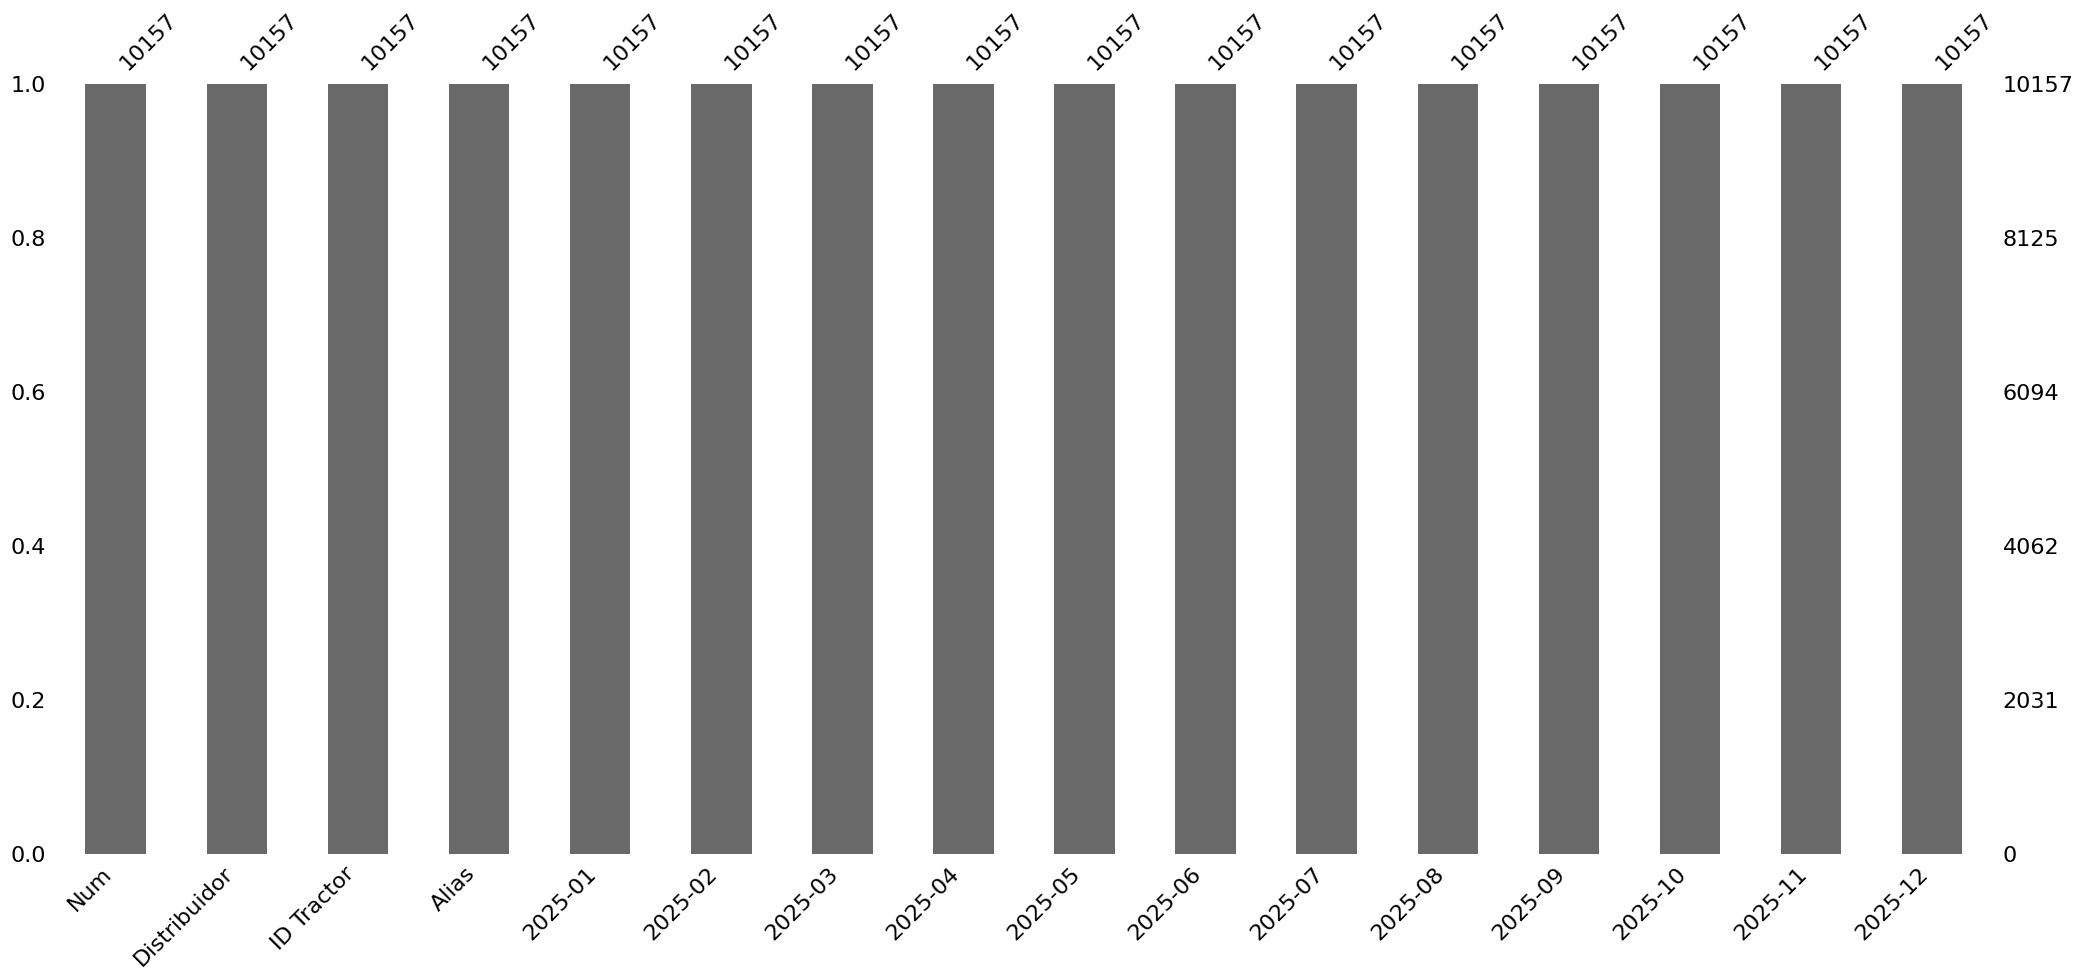

In [ ]:
msno.bar(df_horas_2025)

Aquí podemos ver que en el año 2025 no hubo ningun tipo de nulo en la base de datos.

In [ ]:
NulosPorcentaje_2025 = df_horas_2025.isnull().mean() * 100
print(NulosPorcentaje_2025.sort_values(ascending=False).round(2))

Num            0.0000
Distribuidor   0.0000
ID Tractor     0.0000
Alias          0.0000
2025-01        0.0000
2025-02        0.0000
2025-03        0.0000
2025-04        0.0000
2025-05        0.0000
2025-06        0.0000
2025-07        0.0000
2025-08        0.0000
2025-09        0.0000
2025-10        0.0000
2025-11        0.0000
2025-12        0.0000
dtype: float64


In [ ]:
df_horas_2025["ID Tractor"].nunique()

9633

In [ ]:
df_horas_2025["Distribuidor"].nunique()

30

Total de registros: 10157

Total de columnas: 16

Tipos de datos: int64 y object.

Unidades únicas: se calculan con `nunique()` sobre la columna `ID Tractor`.

Distribuidores únicos: se calculan con `nunique()`.

Valores nulos: se revisan con `isnull().sum()` y con su porcentaje correspondiente.

In [ ]:
df_horas_2025.describe()

,Num,ID Tractor,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
count,"10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000"
mean,"5,079.0000","722,297,500,054,546.6250",35.4259,33.1568,32.2082,32.5441,36.3339,31.2310,25.3989,17.1096,20.8574,20.7092,21.7034,19.8314
std,"2,932.2177","228,833,746,275,528.5312",51.4411,47.2850,45.1145,46.4292,46.9628,42.0369,37.5365,30.7158,39.6918,35.6363,34.8642,33.0326
min,1.0000,"352,556,102,513,822.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,540.0000","356,052,101,068,840.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"5,079.0000","862,407,062,807,478.0000",10.0000,9.0000,10.0000,11.0000,16.0000,14.0000,8.0000,2.0000,1.0000,1.0000,2.0000,2.0000
75%,"7,618.0000","866,392,061,515,288.0000",54.0000,52.0000,52.0000,50.0000,59.0000,50.0000,38.0000,22.0000,25.0000,29.0000,32.0000,29.0000
max,"10,157.0000","866,392,069,198,814.0000",484.0000,425.0000,325.0000,374.0000,364.0000,338.0000,323.0000,301.0000,365.0000,315.0000,292.0000,279.0000


In [ ]:
df_horas_2025.describe(include="all")

,Num,Distribuidor,ID Tractor,Alias,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
count,"10,157.0000",10157,"10,157.0000",10157,"10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000"
unique,NaN,30,NaN,9835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,TRACSA,NaN,DASSA - S508019M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1594,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"5,079.0000",NaN,"722,297,500,054,546.6250",NaN,35.4259,33.1568,32.2082,32.5441,36.3339,31.2310,25.3989,17.1096,20.8574,20.7092,21.7034,19.8314
std,"2,932.2177",NaN,"228,833,746,275,528.5312",NaN,51.4411,47.2850,45.1145,46.4292,46.9628,42.0369,37.5365,30.7158,39.6918,35.6363,34.8642,33.0326
min,1.0000,NaN,"352,556,102,513,822.0000",NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,540.0000",NaN,"356,052,101,068,840.0000",NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"5,079.0000",NaN,"862,407,062,807,478.0000",NaN,10.0000,9.0000,10.0000,11.0000,16.0000,14.0000,8.0000,2.0000,1.0000,1.0000,2.0000,2.0000
75%,"7,618.0000",NaN,"866,392,061,515,288.0000",NaN,54.0000,52.0000,52.0000,50.0000,59.0000,50.0000,38.0000,22.0000,25.0000,29.0000,32.0000,29.0000


In [ ]:
df_horas_2025["Distribuidor"].value_counts(dropna=False)

,count
Distribuidor,
TRACSA,1594
MADISA,1482
TEPSA,1271
ATN,931
AGROCISA,776
ATC,768
ALTEÑOS,753
ARBSA,509
DASSA,428


In [ ]:
df_horas_2025[["2025-01", "2025-02", "2025-03", "2025-04", "2025-05", "2025-06",
               "2025-07", "2025-08", "2025-09", "2025-10", "2025-11", "2025-12"]].describe()

,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
count,"10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000"
mean,35.4259,33.1568,32.2082,32.5441,36.3339,31.2310,25.3989,17.1096,20.8574,20.7092,21.7034,19.8314
std,51.4411,47.2850,45.1145,46.4292,46.9628,42.0369,37.5365,30.7158,39.6918,35.6363,34.8642,33.0326
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,10.0000,9.0000,10.0000,11.0000,16.0000,14.0000,8.0000,2.0000,1.0000,1.0000,2.0000,2.0000
75%,54.0000,52.0000,52.0000,50.0000,59.0000,50.0000,38.0000,22.0000,25.0000,29.0000,32.0000,29.0000
max,484.0000,425.0000,325.0000,374.0000,364.0000,338.0000,323.0000,301.0000,365.0000,315.0000,292.0000,279.0000


## Hallazgos

La hoja 2025 contiene 10157 registros y 16 columnas. Su estructura es más compacta que la de 2024, ya que se enfoca principalmente en el identificador del tractor, el distribuidor, el alias y las horas mensuales.

Esta fuente resulta útil para dar continuidad temporal al análisis de uso de las unidades durante 2025. Las columnas mensuales permiten detectar variaciones de actividad, meses con baja operación y posibles patrones de uso.

## Identificación de columnas para enlazar

Se tienen varias columnas que podrían utilizarse en una fase posterior para relacionar esta hoja con la de 2024:

* ID Tractor: identificador principal de la unidad.
* Alias: identificador alterno.
* Distribuidor: referencia organizacional.
* Num: consecutivo del registro.

Existe además una correspondencia importante entre `IMEI` en la hoja 2024 y `ID Tractor` en la hoja 2025, ya que ambos parecen funcionar como identificadores de la misma unidad.

## Renombrar columnas, y tipos de datos

In [ ]:
df_horas_2024.columns = df_horas_2024.columns.str.lower().str.replace(" ", "_")
df_horas_2025.columns = df_horas_2025.columns.str.lower().str.replace(" ", "_")

In [ ]:
df_horas_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9405 entries, 0 to 9404
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num           9405 non-null   int64  
 1   distribuidor  9405 non-null   object 
 2   imei          9405 non-null   int64  
 3   alias         9405 non-null   object 
 4   marca         9390 non-null   object 
 5   modelo        3142 non-null   object 
 6   ciudad        9390 non-null   object 
 7   estado        3142 non-null   object 
 8   latitud       9390 non-null   float64
 9   longitud      9390 non-null   float64
 10  2024-01       9405 non-null   int64  
 11  2024-02       9405 non-null   int64  
 12  2024-03       9405 non-null   int64  
 13  2024-04       9405 non-null   int64  
 14  2024-05       9405 non-null   int64  
 15  2024-06       9405 non-null   int64  
 16  2024-07       9405 non-null   int64  
 17  2024-08       9405 non-null   int64  
 18  2024-09       9405 non-null 

In [ ]:
df_horas_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   num           10157 non-null  int64 
 1   distribuidor  10157 non-null  object
 2   id_tractor    10157 non-null  int64 
 3   alias         10157 non-null  object
 4   2025-01       10157 non-null  int64 
 5   2025-02       10157 non-null  int64 
 6   2025-03       10157 non-null  int64 
 7   2025-04       10157 non-null  int64 
 8   2025-05       10157 non-null  int64 
 9   2025-06       10157 non-null  int64 
 10  2025-07       10157 non-null  int64 
 11  2025-08       10157 non-null  int64 
 12  2025-09       10157 non-null  int64 
 13  2025-10       10157 non-null  int64 
 14  2025-11       10157 non-null  int64 
 15  2025-12       10157 non-null  int64 
dtypes: int64(14), object(2)
memory usage: 1.2+ MB


Se renombraron las columnas para mejorar la legibilidad, mantener consistencia en el estilo de nombres y facilitar su manipulación en Python. Además, se homologó el nombre del identificador principal como `id_equipo` en ambas hojas, con el fin de que en una fase posterior pueda analizarse una posible relación entre los registros de 2024 y 2025. También se convirtió esta columna a tipo texto, ya que funciona como identificador y no como una variable numérica para cálculo.

## Exploración con descriptores estadísticos

In [ ]:
df_horas_2024.describe()

,num,imei,latitud,longitud,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
count,"9,405.0000","9,405.0000","9,390.0000","9,390.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000"
mean,"4,703.0000","711,628,249,608,985.6250",21.2008,-100.5634,31.2998,25.0078,24.5003,25.0180,29.8399,25.0641,25.0410,22.5942,20.5836,26.0108,23.4958,22.5763
std,"2,715.1340","233,974,257,092,514.7188",3.4384,9.0504,50.6328,42.0050,41.6204,39.6021,45.9913,37.7454,38.1009,36.6047,33.8051,38.7178,33.9291,33.4517
min,1.0000,"352,556,102,513,822.0000",0.0000,-117.0184,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,352.0000","353,738,103,090,260.0000",19.2102,-103.3257,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"4,703.0000","862,407,062,166,420.0000",20.5226,-101.5475,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,4.0000,2.0000,2.0000,5.0000,6.0000,6.0000
75%,"7,054.0000","866,392,061,524,421.0000",22.9588,-98.3409,47.0000,35.0000,33.0000,37.0000,45.0000,39.0000,38.0000,32.0000,29.0000,41.0000,37.0000,34.0000
max,"9,405.0000","866,392,069,198,814.0000",32.6312,0.0000,397.0000,344.0000,431.0000,295.0000,391.0000,358.0000,285.0000,390.0000,282.0000,367.0000,310.0000,333.0000


In [ ]:
df_horas_2025.describe()

,num,id_tractor,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
count,"10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000"
mean,"5,079.0000","722,297,500,054,546.6250",35.4259,33.1568,32.2082,32.5441,36.3339,31.2310,25.3989,17.1096,20.8574,20.7092,21.7034,19.8314
std,"2,932.2177","228,833,746,275,528.5312",51.4411,47.2850,45.1145,46.4292,46.9628,42.0369,37.5365,30.7158,39.6918,35.6363,34.8642,33.0326
min,1.0000,"352,556,102,513,822.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,"2,540.0000","356,052,101,068,840.0000",0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,"5,079.0000","862,407,062,807,478.0000",10.0000,9.0000,10.0000,11.0000,16.0000,14.0000,8.0000,2.0000,1.0000,1.0000,2.0000,2.0000
75%,"7,618.0000","866,392,061,515,288.0000",54.0000,52.0000,52.0000,50.0000,59.0000,50.0000,38.0000,22.0000,25.0000,29.0000,32.0000,29.0000
max,"10,157.0000","866,392,069,198,814.0000",484.0000,425.0000,325.0000,374.0000,364.0000,338.0000,323.0000,301.0000,365.0000,315.0000,292.0000,279.0000


In [ ]:
df_horas_2024["distribuidor"].value_counts(dropna=False)

,count
distribuidor,
TRACSA,1502
MADISA,1364
TEPSA,1161
ATN,873
AGROCISA,749
ATC,725
ALTEÑOS,674
ARBSA,483
DASSA,409


In [ ]:
df_horas_2025["distribuidor"].value_counts(dropna=False)

,count
distribuidor,
TRACSA,1594
MADISA,1482
TEPSA,1271
ATN,931
AGROCISA,776
ATC,768
ALTEÑOS,753
ARBSA,509
DASSA,428


## Identificación de columnas para enlazar

Después de homologar los nombres, se observa que existen columnas comunes entre ambos dataframes como:

* `num`
* `distribuidor`
* `alias`
* `id_equipo`

Estas columnas nos podrán servir como equipo para en una etapa posterior poder explorar relaciones o posibles enlaces entre la información del 2024 y 2025.

## Análisis estadístico
Gran parte del análisis exploratorio estadístico de las variables se realizó en entregas previas, por lo que en esta ocasión no se incluye de forma detallada. Esto se debe a que su incorporación completa haría el documento más extenso y pesado, sin aportar valor adicional al objetivo actual del análisis, ya que ya se tenía una idea de como estaban los DataSets y que se debía de corregir, además de que se hace uno pequeño pero de las variables más importantes. Por esta razón, en esta entrega se parte directamente de las etapas de selección y limpieza de los datasets, enfocándose en la preparación de la información para el modelado y las pruebas de hipótesis.

# Preparación de los Datos


## Fuente 1: Telematrix (Mantenimientos)

In [ ]:
df_Mantenimientos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23904 entries, 0 to 23903
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   no             0 non-null      float64       
 1   alias          23904 non-null  object        
 2   marca          23900 non-null  object        
 3   modelo         23900 non-null  object        
 4   configuracion  23900 non-null  object        
 5   no_serie       23866 non-null  object        
 6   distribuidor   23601 non-null  object        
 7   servicio       23904 non-null  int64         
 8   hrmtro         23904 non-null  int64         
 9   actual         23904 non-null  int64         
 10  tipo           23900 non-null  object        
 11  fecha          23904 non-null  datetime64[ns]
 12  o.t.           9484 non-null   object        
 13  estatus        23900 non-null  object        
 14  editar         0 non-null      float64       
dtypes: datetime64[ns](1

In [ ]:
df_Mantenimientos.head(1)

,no,alias,marca,modelo,configuracion,no_serie,distribuidor,servicio,hrmtro,actual,tipo,fecha,o.t.,estatus,editar
0,NaN,DASSA - NH09655M,NEW HOLLAND AG,TS6.125,FWD 16X8 PS,NH09655M-001854359,DASSA,3900,3900,6418,Preventivo,2024-05-01 10:23:00,NaN,Pendiente,NaN


In [ ]:
# Eliminamos las columnas 100% nulas que sabemos son nulas porque faltan los datos y no son insights y sobreescribimos el dataframe
df_Mantenimientos = df_Mantenimientos.drop(columns=['no', 'editar'])

In [ ]:
# Verificamos que si se borraran y que ahora nuestras columnas sean las correctas
print(df_Mantenimientos.columns.tolist())

['alias', 'marca', 'modelo', 'configuracion', 'no_serie', 'distribuidor', 'servicio', 'hrmtro', 'actual', 'tipo', 'fecha', 'o.t.', 'estatus']


In [ ]:
# Seleccionamos solo las columnas de tipo texto, por cualquier error de captura de los datos, (espacios, mayusculas, minusculas)
columnas_texto = df_Mantenimientos.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_Mantenimientos[col] = df_Mantenimientos[col].apply(
        lambda x: str(x).strip() if pd.notna(x) else x
    )
    if col == 'estatus':
        df_Mantenimientos[col] = df_Mantenimientos[col].str.upper()

# Utilizamps el .str.strip() para quitar los espacios al inicio y al final
# y .str.upper() para estandarizar todo a mayúsculas por si acaso.
for col in columnas_texto:
    df_Mantenimientos[col] = df_Mantenimientos[col].str.strip()
    # Estandarizamos 'estatus' a mayúsculas igual por si acaso no sabemos si hay errores, y porque la vamos a utilizar para el CEM
    if col == 'estatus':
        df_Mantenimientos[col] = df_Mantenimientos[col].str.upper()

In [ ]:
# Revisamos las estadísticas de las 3 columnas numéricas clave para nuestros pruebas
print("SERVICIO, HRMTRO Y ACTUAL")
display(df_Mantenimientos[['servicio', 'hrmtro', 'actual']].describe().round(2))

SERVICIO, HRMTRO Y ACTUAL


,servicio,hrmtro,actual
count,"23,904.0000","23,904.0000","23,904.0000"
mean,"1,457.4900","1,458.9700","2,263.3300"
std,"1,398.0300","1,401.1000","1,713.1600"
min,0.0000,0.0000,0.0000
25%,600.0000,560.0000,"1,064.0000"
50%,"1,200.0000","1,160.0000","1,871.0000"
75%,"2,100.0000","2,060.0000","2,974.0000"
max,"13,200.0000","20,100.0000","13,256.0000"


In [ ]:
print("ERRORES DETECTADOS")

# Error 1: Servicios que no existen en el catálogo (mayores a 2400)
error_servicio = df_Mantenimientos[df_Mantenimientos['servicio'] > 2400]
print(f"1. Servicios imposibles (>2400 hrs): {len(error_servicio)} registros")
if len(error_servicio) > 0:
    display(error_servicio[['alias', 'servicio', 'hrmtro', 'actual']])

# Error 2: Horómetros demasiado altos (vamos a usar 10,000 como umbral seguro para investigar)
error_hrmtro = df_Mantenimientos[df_Mantenimientos['hrmtro'] > 10000]
print(f"\n2. Horómetros anómalos (>10,000 hrs): {len(error_hrmtro)} registros")
if len(error_hrmtro) > 0:
    display(error_hrmtro[['alias', 'servicio', 'hrmtro', 'actual']])

# Error 3: Por si por ejemplo hay un horometro actual menor al Horómetro del servicio)
error_logico = df_Mantenimientos[df_Mantenimientos['actual'] < df_Mantenimientos['hrmtro']]
print(f"\n3. Inconsistencia lógica (Actual < Horómetro Servicio): {len(error_logico)} registros")
if len(error_logico) > 0:
    display(error_logico[['alias', 'servicio', 'hrmtro', 'actual']].head(10))

ERRORES DETECTADOS
1. Servicios imposibles (>2400 hrs): 3855 registros


,alias,servicio,hrmtro,actual
0,DASSA - NH09655M,3900,3900,6418
3,MADISA-S204600M,3300,3302,6271
6,TEPSA - S507965M,3000,3010,6861
10,MADISA - NH09748M,2700,2702,4800
16,TS6 140 ELITE - 4100033M-353738101247318,2700,2720,8466
...,...,...,...,...
23877,TRACSA - S508004M,4200,4160,4266
23884,ATN - 866392068953151,3300,3275,3765
23888,ENAGRI - NKJ0B80CANKH30823,4800,4760,7889
23892,TRACSA - 5801309M,3900,3860,4164



2. Horómetros anómalos (>10,000 hrs): 21 registros


,alias,servicio,hrmtro,actual
3361,CE NH L230,11100,11060,12179
4677,866392061522912,10800,10761,11585
5173,866392061522912,10500,10604,11585
7016,CE NH L230,10800,10760,12179
8062,CE NH L230,11400,11491,12179
8487,ATC - S306764M,2100,20100,5083
9029,866392061522912,11100,11139,11585
9465,ATN - S507498M,9900,10086,11258
10409,CE NH L230,11700,11660,12179
10825,ATN - S507498M,10200,10162,11258



3. Inconsistencia lógica (Actual < Horómetro Servicio): 47 registros


,alias,servicio,hrmtro,actual
284,ENAGRI - 353738103072821,4200,4188,598
393,ATC - HFJ182900,2100,2100,2089
406,MADISA - 353738103088173,900,860,0
1566,353738102832928,300,300,164
2006,DASSA - NH09868M,300,600,276
2780,ATC - 862407060152042,50,66,65
6210,ATN - S508515M-8108172,900,640,639
6211,ATC-S508430M-8107430,1200,929,928
6212,ATC -S508522M,600,479,478
6213,ATC - S508561M,600,600,2


In [ ]:
# Vamos a comenzar por intentar corregir el posible error de capgtura de >10,000 hrs, aquí solo hay uno incorrecto que es S306764M con hrmtro=20100
# Ya que los demás registros con su servicio y hrmtro y actual tienen sentido entre si, ese es el único que no tienen sentido entre si.
# Dividiremos entre 10 SOLO a esa fila, para que haga sentido con servicion, porque es probablemente un error de captura que le pusieron un cero de más

mascara_error_tipografico = (df_Mantenimientos['alias'] == 'ATC - S306764M') & (df_Mantenimientos['hrmtro'] == 20100)
df_Mantenimientos.loc[mascara_error_tipografico, 'hrmtro'] = df_Mantenimientos.loc[mascara_error_tipografico, 'hrmtro'] / 10

In [ ]:
# Despues hay 47 registros donde el horometro actual es menor que el hrmtro de servicip
# Ns quise poner algo que no existiera o inventarme el dato, por lo que cuandp calcule DMU esos equipos quedan en 0 en lugar de negativo.
contador_correcciones = 0
for indice, fila in df_Mantenimientos.iterrows():
    if fila['actual'] < fila['hrmtro']:
        df_Mantenimientos.at[indice, 'actual'] = fila['hrmtro']
        contador_correcciones += 1

print(f"Corrección 2 aplicada: Se igualó el 'actual' al 'hrmtro' en {contador_correcciones}")

Corrección 2 aplicada: Se igualó el 'actual' al 'hrmtro' en 46


In [ ]:
# Verificamos cuál registro quedó sin corregir, pero quede clown porque lo que hizo es empezar desde 0, por eso el 46
restantes = df_Mantenimientos[df_Mantenimientos['actual'] < df_Mantenimientos['hrmtro']]
print(f"Registros sin corregir: {len(restantes)}")
display(restantes[['alias', 'servicio', 'hrmtro', 'actual']])

Registros sin corregir: 0


,alias,servicio,hrmtro,actual


In [ ]:
# Verificamos que ya no existen los horómetros negativos para confirmar el paso anterior
inconsistencias_restantes = len(df_Mantenimientos[df_Mantenimientos['actual'] < df_Mantenimientos['hrmtro']])
print(f"Inconsistencias lógicas restantes: {inconsistencias_restantes}")

# Volvemos a ver los máximos para confirmar que el 20,100 desapareció
print("\nNuevos máximos:")
print(df_Mantenimientos[['servicio', 'hrmtro', 'actual']].max())

Inconsistencias lógicas restantes: 0

Nuevos máximos:
servicio    13200
hrmtro      13162
actual      13256
dtype: int64


In [ ]:
# Limpiamos no_serie para cuando hagamos el merge por si acaso
df_Mantenimientos['no_serie'] = df_Mantenimientos['no_serie'].str.strip().str.upper()

# Checamos lo nulos que hay, ya que salieron en info y en análisis del principio con msno.
nulos_llave = df_Mantenimientos['no_serie'].isnull().sum()
print(f"Registros sin No. Serie (Llave Maestra): {nulos_llave}")

if nulos_llave > 0:
    print("\nEstos son los registros que no tienen No. Serie:")
    display(df_Mantenimientos[df_Mantenimientos['no_serie'].isnull()][['alias', 'marca', 'servicio', 'estatus']])

Registros sin No. Serie (Llave Maestra): 38

Estos son los registros que no tienen No. Serie:


,alias,marca,servicio,estatus
279,7610S 2WD-5,NEW HOLLAND AG,5400,PENDIENTE
1249,866016064473639,NEW HOLLAND AG,50,PENDIENTE
1358,7610S 2WD-5,NEW HOLLAND AG,5700,PENDIENTE
1534,AGRICOLA 76,NEW HOLLAND AG,3600,CERRADAFUERA
1812,TAPSAR-H20358M-353738103189443,NEW HOLLAND AG,7800,CERRADA
1969,866016064473639,NEW HOLLAND AG,300,PENDIENTE
2856,866016064473639,NEW HOLLAND AG,600,PENDIENTE
3037,ENAGRI-865640063372327,NEW HOLLAND AG,2400,PENDIENTE
3069,7610S 2WD-5,NEW HOLLAND AG,6000,PENDIENTE
4565,AGROEQUIPOS - 866392061514919,NEW HOLLAND CE,300,PENDIENTE


In [ ]:
# YA que son pocos aka 39 y no se pueden recuperar los vpy a eliminar porque no nos sirven para el merge, e igual el alias en este caso no nos sirve para asumir.
df_Mantenimientos = df_Mantenimientos.dropna(subset=['no_serie'])

# Reseteamos el índice por si acaso
df_Mantenimientos = df_Mantenimientos.reset_index(drop=True)

In [ ]:
print(f"Total de registros limpios: {len(df_Mantenimientos)}")
print(f"Columnas disponibles: {df_Mantenimientos.columns.tolist()}\n")

# Verificamos que si funciono nuestro paso anterior
print("Nulos en no_serie:", df_Mantenimientos['no_serie'].isnull().sum())

Total de registros limpios: 23866
Columnas disponibles: ['alias', 'marca', 'modelo', 'configuracion', 'no_serie', 'distribuidor', 'servicio', 'hrmtro', 'actual', 'tipo', 'fecha', 'o.t.', 'estatus']

Nulos en no_serie: 0


In [ ]:
# Definimos prioridad de estatus para quedarnos con el más relevante y que no sea con el más reciente o uno al azar
prioridad_estatus = {'CERRADA': 1, 'CERRADAFUERA': 2, 'ENPROCESO': 3, 'PORVENCER': 4, 'PENDIENTE': 5, 'ABIERTA': 6}

df_Mantenimientos['prioridad'] = df_Mantenimientos['estatus'].map(prioridad_estatus).fillna(99)

df_Mantenimientos = (df_Mantenimientos
                     .sort_values(['no_serie', 'fecha', 'servicio', 'prioridad'])
                     .drop_duplicates(subset=['no_serie', 'fecha', 'servicio'], keep='first')
                     .drop(columns='prioridad')
                     .reset_index(drop=True))

print(f"Registros después de limpiar duplicados: {len(df_Mantenimientos):,}")

Registros después de limpiar duplicados: 23,831


In [ ]:
df_Mantenimientos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23831 entries, 0 to 23830
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   alias          23831 non-null  object        
 1   marca          23827 non-null  object        
 2   modelo         23827 non-null  object        
 3   configuracion  23827 non-null  object        
 4   no_serie       23831 non-null  object        
 5   distribuidor   23549 non-null  object        
 6   servicio       23831 non-null  int64         
 7   hrmtro         23831 non-null  int64         
 8   actual         23831 non-null  int64         
 9   tipo           23827 non-null  object        
 10  fecha          23831 non-null  datetime64[ns]
 11  o.t.           9476 non-null   object        
 12  estatus        23827 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 2.4+ MB


Considero que la limpieza del dataset de Mantenimientos fue un paso necesario para dejar la base lista para el análisis. Se eliminaron las columnas no y editar por tener 100% de valores nulos, así como 39 registros sin número de serie, ya que al ser la llave del merge no eran recuperables ni utilizables para la integración con las demás fuentes.

Se corrigió un error en el horómetro del equipo ATC - S306764M, donde el hrmtro era superior al mantenimiento/servicio era de 20100 fue ajustado a 2010. Los demás 20 registros con horómetros superiores a 10,000 hrs se conservaron sin modificación por corresponder a equipos legítimos de alta antigüedad con valores consistentes.

En los 47 registros donde el horómetro actual era menor al del servicio se igualó actual a hrmtro para evitar valores negativos en el cálculo del DMU, dejando el desfase en cero en lugar de inventar un dato.

Para la eliminación de duplicados se definió por no_serie + fecha + servicio y se estableció un orden de prioridad por estatus (CERRADA > CERRADAFUERA > ENPROCESO > PORVENCER > PENDIENTE > ABIERTA) para garantizar que en caso de registros duplicados se conservara el de mayor relevancia operativa en lugar de uno aleatorio.

Los 3,855 registros con servicio > 2400 se conservaron en el dataset pendientes de decisión sobre normalización al ciclo base, ya que corresponden a equipos en segundo o tercer ciclo de mantenimiento y su eliminación representaría perder el 16% del dataset.

## Fuente 2: Telematrix (Reporte unidades dia anterior)

In [ ]:
df_UnidadesDiaAnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   no                 10846 non-null  int64         
 1   imei               10846 non-null  object        
 2   alias              10846 non-null  object        
 3   marca              10129 non-null  object        
 4   modelo             9907 non-null   object        
 5   configuracion      9430 non-null   object        
 6   fecha_alta         10204 non-null  datetime64[ns]
 7   no._serie          10136 non-null  object        
 8   distribuidor       9643 non-null   object        
 9   ciudad             9643 non-null   object        
 10  estado             9643 non-null   object        
 11  horometro          10846 non-null  float64       
 12  odometro           10846 non-null  float64       
 13  total_servicios    10846 non-null  int64         
 14  cerrad

In [ ]:
df_UnidadesDiaAnt.head(2)

,no,imei,alias,marca,modelo,configuracion,fecha_alta,no._serie,distribuidor,ciudad,estado,horometro,odometro,total_servicios,cerrados,c.fuera,pendientes,50,300,600,900,1200,1500,1800,2100,2400,cliente,telefono,email,latitud,longitud,pep,combustible,distancia,vel._maxima_kph,vel._promedio_kph,t._encendido_hrs,t._apagado_hrs
0,1,16397000062879,16397000062879,CASE CE,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.7091,-100.3653,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000
1,2,352556102049694,352556102049694,NEW HOLLAND AG,TS6.120,FWD 8X8 PS,2022-06-02,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0,0.0000,0.0000,0.0000


In [ ]:
# Columnas a eliminar, ya que tienen demasiados nulos como para poder imputar y no tendría lógica con los datos del cliente, además de que no tenían información que necesitamos en nuestras hipotesis
df_UnidadesDiaAnt = df_UnidadesDiaAnt.drop(columns=['no', 'cliente', 'telefono', 'email', 'pep'])

In [ ]:
# Checamos que funciono
print(df_UnidadesDiaAnt.columns.tolist())
print(f"Shape actual: {df_UnidadesDiaAnt.shape}")

['imei', 'alias', 'marca', 'modelo', 'configuracion', 'fecha_alta', 'no._serie', 'distribuidor', 'ciudad', 'estado', 'horometro', 'odometro', 'total_servicios', 'cerrados', 'c.fuera', 'pendientes', '50', '300', '600', '900', '1200', '1500', '1800', '2100', '2400', 'latitud', 'longitud', 'combustible', 'distancia', 'vel._maxima_kph', 'vel._promedio_kph', 't._encendido_hrs', 't._apagado_hrs']
Shape actual: (10846, 33)


In [ ]:
# Lo mismo que en la base de datos anterior por si hay errores de espacio mayusculas etc.
columnas_texto_limpiar = ['no._serie', 'estado', 'distribuidor', 'ciudad', 'marca']

for col in columnas_texto_limpiar:
    df_UnidadesDiaAnt[col] = df_UnidadesDiaAnt[col].astype(str).str.strip().str.upper()
    df_UnidadesDiaAnt[col] = df_UnidadesDiaAnt[col].replace('NAN', np.nan)

In [ ]:
# Revisamos las estadísticas de las variables operativas que vamos a usar
columnas_telemetria = ['horometro', 'odometro', 'combustible', 'distancia',
                       'vel._maxima_kph', 'vel._promedio_kph',
                       't._encendido_hrs', 't._apagado_hrs']

print("ESTADÍSTICAS DE TELEMETRÍA")
display(df_UnidadesDiaAnt[columnas_telemetria].describe().round(2))

ESTADÍSTICAS DE TELEMETRÍA


,horometro,odometro,combustible,distancia,vel._maxima_kph,vel._promedio_kph,t._encendido_hrs,t._apagado_hrs
count,"10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000","10,846.0000"
mean,"1,137.2800",177.9900,13.5700,5.1300,4.4500,1.1000,1.6300,19.7100
std,"1,610.8200","1,047.2700",31.7800,26.0800,9.9400,2.9100,3.3600,7.7100
min,0.0000,0.0000,-37.9600,0.0000,0.0000,0.0000,0.0000,0.0000
25%,115.1300,0.3600,0.0000,0.0000,0.0000,0.0000,0.0000,18.7400
50%,690.5800,15.9600,0.0000,0.0000,0.0000,0.0000,0.0000,24.0000
75%,"1,644.7700",76.2300,4.3700,1.4400,7.0000,0.7500,1.4400,24.0000
max,"77,300.6900","45,518.6600",263.8700,"1,552.5300",295.0000,100.9000,23.9300,24.0000


In [ ]:
# En el paso anterior había combustible negativo lo que es raro, por lo que probablemente sea un error de captura. lo cambie por 0
df_UnidadesDiaAnt.loc[df_UnidadesDiaAnt['combustible'] < 0, 'combustible'] = 0

In [ ]:
print("VELOCIDADES Y DISTANCIAS EXTREMAS")

# Igual en el paso penultimo había cosas raras en distancia y velocidad por lo que lo vamos a filtarr
sospechosos = df_UnidadesDiaAnt[(df_UnidadesDiaAnt['vel._maxima_kph'] > 80) |
                                (df_UnidadesDiaAnt['distancia'] > 500)]

print(f"Total de registros raros: {len(sospechosos)} de {len(df_UnidadesDiaAnt)}")

display(sospechosos[['alias', 'horometro', 't._encendido_hrs', 'distancia', 'vel._maxima_kph', 'combustible']])

VELOCIDADES Y DISTANCIAS EXTREMAS
Total de registros raros: 12 de 10846


,alias,horometro,t._encendido_hrs,distancia,vel._maxima_kph,combustible
6,352556102921207,253.2000,9.3600,324.3700,89,0.0000
838,ATS - S306498M,"2,285.0100",12.0400,52.0900,127,93.8200
2192,ARBSA - S507967M,"2,216.1800",9.8900,16.8800,82,47.6700
3096,ALTENOS - S508412M,"1,905.9300",0.2100,16.2500,109,10.1200
3493,862407060163718,"5,128.0200",0.0000,39.5900,88,0.0000
3709,862407061478784,"2,835.5900",7.4300,"1,078.8700",295,63.8800
3749,862407061485318,563.0600,2.8900,33.3100,288,0.0000
3815,862407061497107,"2,503.7000",10.4300,870.3100,291,53.9900
3818,862407061498618,212.5100,10.3300,81.3000,103,100.9600
4522,862407061777649,"2,543.5500",7.7000,"1,552.5300",289,84.6400


Por ejemplo viendo esta table hay cosas muy raras
- En la fila 3709: El GPS dice que el tractor estuvo a 295 km/h y recorrió 1,078 km, pero el motor dice que estuvo encendido 7.4 horas y quemó 63.8 litros de combustible, lo que viendo datos normales no sería muy posible.
- En la fila 5775: Recorrió 1,242 km, pero su velocidad máxima marca 0 km/h y estuvo encendido 0.08 hrs, igual de imposibles, conjetura estaba siendo transportad, o sea encima de otro camión?
- En la fila 838: Estuvo trabajando 12 horas y quemó 93 litros, pero llego hasta 127 km/h, es igual probablemente un error de captura.

Ya que estos registro atipicos son solo 12 y la base tiene más de 10,800, o sea son el 0.11%. Considero que cambiarlo manualmente o con normalización sería asumir valores distancia o velocidad, que no tienen sentido con combustible o entre si, y afectaría directamente el cálculo del DOE (Dependencia Operacional), generando resultados potencialmente sesgados y poco confiables.

Decidi eliminarlos y tratarlos como datos no confiables dentro del análisis.

In [ ]:
# los filtramos donde velocidad sea de 80 que es por lo que investigue a lo máximo y con sentido que puedan llegar, y 500 en distancia porque hacer más diario igual sería muy atipico
mascara_sanos = (df_UnidadesDiaAnt['vel._maxima_kph'] <= 80) & (df_UnidadesDiaAnt['distancia'] <= 500)
df_UnidadesDiaAnt = df_UnidadesDiaAnt[mascara_sanos].copy()

# Reseteamos índice por si acaso
df_UnidadesDiaAnt = df_UnidadesDiaAnt.reset_index(drop=True)
print(f"Registros eliminados por atipicos o dtoas raros quedan: {len(df_UnidadesDiaAnt)}")

Registros eliminados por atipicos o dtoas raros quedan: 10834


In [ ]:
# Igual que en la base de datos anterior checamos que no haya nulos en no._serie
nulos_serie_telemetria = df_UnidadesDiaAnt['no._serie'].isnull().sum()
print(f"Equipos en Telemetría SIN No. Serie: {nulos_serie_telemetria}")

if nulos_serie_telemetria > 0:
    print("\nMuestra de equipos telemetría sin No. Serie:")
    display(df_UnidadesDiaAnt[df_UnidadesDiaAnt['no._serie'].isnull()][['alias', 'no._serie', 'marca']].head())

Equipos en Telemetría SIN No. Serie: 709

Muestra de equipos telemetría sin No. Serie:


,alias,no._serie,marca
0,16397000062879,NaN,CASE CE
1,352556102049694,NaN,NEW HOLLAND AG
4,352556102805988,NaN,NaN
5,ATN - 352556102809907,NaN,NaN
12,353538100950664,NaN,NaN


Igual en este contexto hay mcuhas unidades y 709 de más de 10,000 son muy pocas, que no se pueden recuperar con el alias ya que no coinciden

In [ ]:
# Eliminamos los que no tienen No. Serie
df_UnidadesDiaAnt = df_UnidadesDiaAnt.dropna(subset=['no._serie'])

# Reseteamos índice por si acaso
df_UnidadesDiaAnt = df_UnidadesDiaAnt.reset_index(drop=True)

print(f"Total de equipos telemetría: {len(df_UnidadesDiaAnt)}")
print("Nulos en No. Serie:", df_UnidadesDiaAnt['no._serie'].isnull().sum())

Total de equipos telemetría: 10125
Nulos en No. Serie: 0


In [ ]:
# Lista de las columnas de umbrales
umbrales = ['50', '300', '600', '900', '1200', '1500', '1800', '2100', '2400']

umbrales_existentes = [col for col in umbrales if col in df_UnidadesDiaAnt.columns]

# Limpiamos el texto: quitamos espacios y ponemos mayúsculas
for col in umbrales_existentes:
    df_UnidadesDiaAnt[col] = df_UnidadesDiaAnt[col].astype(str).str.strip().str.upper()
    df_UnidadesDiaAnt[col] = df_UnidadesDiaAnt[col].replace('NAN', np.nan)

print(f"Columnas de umbrales limpiadas: {umbrales_existentes}")


print("Valores únicos:")
for col in umbrales_existentes:
    print(f"Columna {col}:", df_UnidadesDiaAnt[col].unique())

Columnas de umbrales limpiadas: ['50', '300', '600', '900', '1200', '1500', '1800', '2100', '2400']
Valores únicos:
Columna 50: [nan 'PENDIENTE' 'CERRADA' 'PORVENCER' 'ENPROCESO' 'CERRADAFUERA']
Columna 300: [nan 'PENDIENTE' 'CERRADAFUERA' 'CERRADA' 'ENPROCESO' 'PORVENCER'
 'ABIERTA']
Columna 600: [nan 'CERRADA' 'PENDIENTE' 'CERRADAFUERA' 'PORVENCER' 'ENPROCESO'
 'ABIERTA']
Columna 900: [nan 'CERRADA' 'PENDIENTE' 'CERRADAFUERA' 'ENPROCESO' 'PORVENCER'
 'ABIERTA']
Columna 1200: [nan 'PENDIENTE' 'CERRADAFUERA' 'CERRADA' 'PORVENCER' 'ENPROCESO']
Columna 1500: [nan 'PENDIENTE' 'CERRADAFUERA' 'CERRADA' 'PORVENCER' 'ENPROCESO'
 'ABIERTA']
Columna 1800: [nan 'PENDIENTE' 'CERRADA' 'CERRADAFUERA' 'ENPROCESO' 'PORVENCER']
Columna 2100: [nan 'PENDIENTE' 'CERRADAFUERA' 'CERRADA' 'PORVENCER' 'ENPROCESO']
Columna 2400: [nan 'PENDIENTE' 'CERRADA' 'CERRADAFUERA' 'ENPROCESO' 'PORVENCER']


In [ ]:
df_UnidadesDiaAnt['fecha_alta'].max()

Timestamp('2026-02-09 00:00:00')

In [ ]:
df_UnidadesDiaAnt['fecha_alta'].min()

Timestamp('1900-01-01 00:00:00')

In [ ]:
# Eliminamos la fecha de alta, ya que me causaba ruido en el corazón
df_UnidadesDiaAnt = df_UnidadesDiaAnt.drop(columns=['fecha_alta'])

In [ ]:
df_UnidadesDiaAnt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10125 entries, 0 to 10124
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   imei               10125 non-null  object 
 1   alias              10125 non-null  object 
 2   marca              10076 non-null  object 
 3   modelo             9859 non-null   object 
 4   configuracion      9401 non-null   object 
 5   no._serie          10125 non-null  object 
 6   distribuidor       9516 non-null   object 
 7   ciudad             9516 non-null   object 
 8   estado             9516 non-null   object 
 9   horometro          10125 non-null  float64
 10  odometro           10125 non-null  float64
 11  total_servicios    10125 non-null  int64  
 12  cerrados           10125 non-null  int64  
 13  c.fuera            10125 non-null  int64  
 14  pendientes         10125 non-null  int64  
 15  50                 6819 non-null   object 
 16  300                590

In [ ]:
total_uda = len(df_UnidadesDiaAnt)
duplicados_uda = df_UnidadesDiaAnt[df_UnidadesDiaAnt.duplicated(subset=['no._serie'], keep=False)]

print(f"Total registros          : {total_uda:,}")
print(f"No. Serie duplicados     : {len(duplicados_uda):,}")
print(f"% del total              : {len(duplicados_uda)/total_uda*100:.2f}%")

if len(duplicados_uda) > 0:
    print("\nMuestra de duplicados:")
    display(duplicados_uda.sort_values('no._serie')[['no._serie', 'alias', 'marca',
                                                      'distribuidor', 'horometro']].head(10))

    # Para el merge necesitamos 1 fila por equipo, nos quedamos con el de mayor horometro
    # (la lectura más reciente / confiable)
    df_UnidadesDiaAnt = (
        df_UnidadesDiaAnt
        .sort_values('horometro', ascending=False)
        .drop_duplicates(subset=['no._serie'], keep='first')
        .reset_index(drop=True)
    )
    print(f"\nRegistros después de limpiar duplicados: {len(df_UnidadesDiaAnt):,}")
else:
    print("No se encontraron duplicados exactos.")

Total registros          : 10,125
No. Serie duplicados     : 59
% del total              : 0.58%

Muestra de duplicados:


,no._serie,alias,marca,distribuidor,horometro
7062,5801305M-727387902,C.AGROEQUIPOS - 5801305M,NEW HOLLAND AG,NaN,0.0000
462,5801305M-727387902,AGROEQUIPOS - 353738101232583,NEW HOLLAND AG,AGROEQUIPOS,"1,581.6800"
7638,5801313M-727366679,C. AGROEQUIPOS - 5801313M-727366679,NEW HOLLAND AG,NaN,0.0000
1263,5801313M-727366679,353738102813829,NEW HOLLAND AG,AGROEQUIPOS,323.8700
5613,5802012M-728483651,862407066115407,NEW HOLLAND AG,NaN,0.0000
5526,5802012M-728483651,862407066095005,NEW HOLLAND AG,MADISAGRAL,197.8900
1194,DAC080K3NJS3B7450,MAQUIRENT-353738102798897,CASE CE,MAQUIRENT,37.3200
1378,DAC080K3NJS3B7450,MAQUIRENT-353738102831235,CASE IH,NaN,0.0000
3501,DHC02486,862407061507020,CAT,MADISAGRAL,"17,925.1800"
7982,DHC02486,866392061532044,CAT,MADISAGRAL,118.3200



Registros después de limpiar duplicados: 10,095


Se hizo algo similar que en la base de datos anterior, se eliminaron las columnas no, cliente, telefono**, email y pep, ya que tenían muchos valores nulos o no aportaban información relevante para las hipótesis planteadas.

Despúes se estandarizaron los campos de texto no._serie, estado, distribuidor, ciudad y marca , eliminando espacios en blanco, convirtiendo los valores a mayúsculas y homologando los valores nulos para evitar inconsistencias durante los procesos de integración y análisis.

Durante la revisión de las variables de telemetría vimos registros con valores negativos en combustible, los cuales fueron ajustados a cero al considerarse errores de captura o transmisión de datos.

Igual, se detectaron 12 registros con combinaciones atípicas de distancia recorrida y velocidad máxima, específicamente equipos con velocidades superiores a 80 km/h o recorridos mayores a 500 km en un solo día. Algunos de estos casos presentaban inconsistencias evidentes entre velocidad, combustible consumido y horas de operación, sugiriendo fallas de GPS, errores de transmisión o situaciones excepcionales que no podían validarse con la información disponible. Debido a que estos registros representaban únicamente el 0.11% de la base, se decidió eliminarlos en lugar de corregirlos mediante imputación o normalización, evitando introducir supuestos que pudieran sesgar el cálculo de indicadores operativos. Después de este filtro, el dataset pasó de 10,846 a 10,834 registros.

Se identificaron además 709 equipos sin número de serie, equivalentes al 6.5% de la base original. Debido a que el número de serie constituye la llave principal para la integración con las demás fuentes de información y que dichos registros no podían recuperarse de manera confiable a partir del alias u otros campos disponibles, fueron eliminados del análisis. Como resultado, la base quedó con 10,125 equipos con número de serie válido.

También se estandarizaron las nueve columnas de umbrales de mantenimiento (50, 300, 600, 900, 1200, 1500, 1800, 2100 y 2400 horas), homologando formatos de texto y valores nulos para asegurar consistencia en la interpretación de los estatus de servicio.

Finalmente, se identificaron 59 registros con número de serie duplicado, equivalentes al 0.58% del total. La inspección mostró que varios de estos casos correspondían a equipos registrados con distintos dispositivos IMEI o registros de telemetría incompletos con horómetro igual a cero. Para evitar duplicidades en el nivel de unidad y mantener una única observación por equipo, se realizó un proceso de depuración que redujo la base de 10,125 a 10,095 registros finales.


Esto es igual de la misma base de datos.

Ya que pudimos ver en la matrix de msno las columnas de umbrales de mantenimiento tenían un patrón de nulos creciente y sistemático a partir del umbral de 300 hrs. La columna de 50 hrs tenía 37% de nulos, la de 300 hrs sube a 45.5%, y el porcentaje continúa aumentando hasta llegar a 88.9% en el umbral de 2,400 hrs. El dendrograma de missingno agrupa estas columnas en un clúster, lo que indica que los nulos no son aleatorios sino que tienden a aparecer juntos: si un equipo no tiene registro en 300 hrs, probablemente tampoco lo tiene en 600 ni en 900 hrs. Esto sugiere que los equipos que saltan un mantenimiento tienden a saltar los siguientes también, o bien que el registro de estos campos no se captura de forma consistente, o las unidades no han llegado a las horas.

Igual con el resultado anterior se investigó ese chunk con valores faltantes y nos dimos cuenta de que la mayoría de esas unidades no tenían el horometro suficiente para llegar a los mantenimientos de esas horas. Pero se detectó un bloque de 371 registros aprox. 3.7% con horómetros muy altos aprox. 4,000 hrs, pero con cero o casi cero mantenimientos registrados. A diferencia de los registros normales donde a mayor horómetro corresponde mayor número de mantenimientos, estos equipos rompen esa relación lógica. El scatter plot de horómetro vs el número de mantenimientos muestra que el bloque anormal no es disperso sino continuo en el dataset, lo que descarta que sea ruido aleatorio.

           horometro                                   n_mantenimientos       
               count       mean     median         max             mean median
tipo_chunk                                                                    
ANORMAL          370 3,961.7649 2,851.9000 77,300.6900           0.4054 0.0000
NORMAL          9725 1,099.3901   732.4600 19,734.9200           3.3272 3.0000


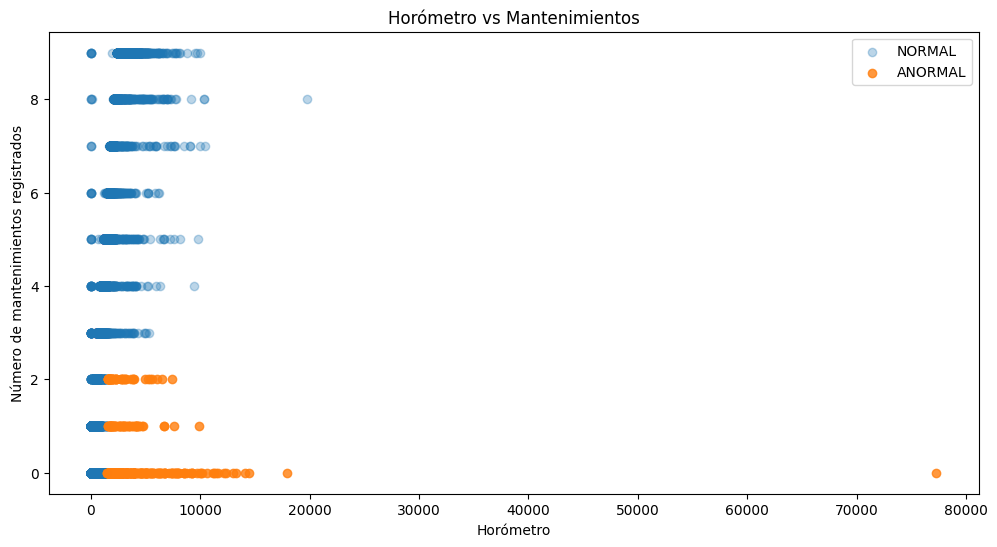

     horometro  n_mantenimientos   50  300  600  900 1200 1500 1800 2100  \
0  77,300.6900                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2  17,925.1800                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
3  14,426.1700                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
4  14,065.2500                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
5  13,254.0100                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
6  12,955.0400                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
7  12,318.0700                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
8  12,179.8200                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
9  11,585.2000                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
10 11,478.1800                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
11 11,258.3800                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
12 11,198.6800                 0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
13 10,611.36

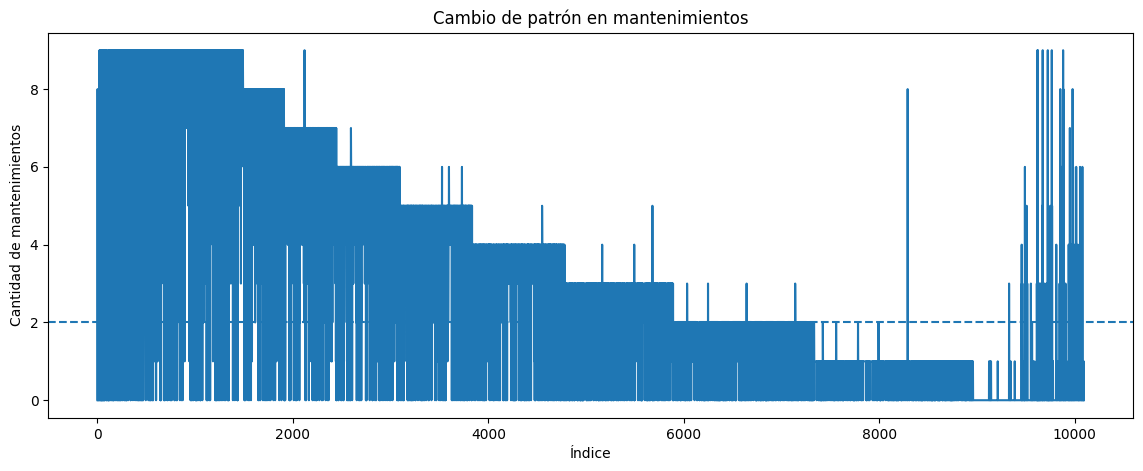

In [ ]:
cols_mantenimiento = ['50', '300', '600', '900', '1200',
                      '1500', '1800', '2100', '2400']

cols_mantenimiento = [c for c in cols_mantenimiento if c in df_UnidadesDiaAnt.columns]


df_temp = df_UnidadesDiaAnt.copy()

df_temp['n_mantenimientos'] = (
    df_temp[cols_mantenimiento]
    .notna()
    .sum(axis=1)
)

HOROMETRO_ALTO = 1500

df_temp['tipo_chunk'] = np.where(
    (df_temp['horometro'] >= HOROMETRO_ALTO) &
    (df_temp['n_mantenimientos'] <= 2),
    'ANORMAL',
    'NORMAL'
)


resumen = (
    df_temp
    .groupby('tipo_chunk')
    .agg({
        'horometro': ['count', 'mean', 'median', 'max'],
        'n_mantenimientos': ['mean', 'median']
    })
)

print(resumen)


plt.figure(figsize=(12,6))

# Normal
normal = df_temp[df_temp['tipo_chunk'] == 'NORMAL']
plt.scatter(
    normal['horometro'],
    normal['n_mantenimientos'],
    alpha=0.3,
    label='NORMAL'
)

anormal = df_temp[df_temp['tipo_chunk'] == 'ANORMAL']
plt.scatter(
    anormal['horometro'],
    anormal['n_mantenimientos'],
    alpha=0.8,
    label='ANORMAL'
)

plt.xlabel('Horómetro')
plt.ylabel('Número de mantenimientos registrados')
plt.title('Horómetro vs Mantenimientos')
plt.legend()

plt.show()


df_chunk_anormal = df_temp[df_temp['tipo_chunk'] == 'ANORMAL']

print(df_chunk_anormal[
    ['horometro', 'n_mantenimientos'] + cols_mantenimiento
].head(20))

plt.figure(figsize=(14,5))

plt.plot(
    df_temp.index,
    df_temp['n_mantenimientos'],)

plt.axhline(2, linestyle='--')

plt.xlabel('Índice')
plt.ylabel('Cantidad de mantenimientos')
plt.title('Cambio de patrón en mantenimientos')

plt.show()

Los resultados muestran que sí existe un grupo de datos con comportamiento anormal dentro del dataset. En total se detectaron 371 registros anormales de 10,125 registros, o sea aproximadamente el 3.7% de todo el dataset.

Lo raro de estos registros es que tienen horómetros muy altos, con un promedio cercano a las 4,000 horas e incluso casos extremos de más de 77,000 horas, pero casi no tienen mantenimientos registrados. De hecho, la mediana de mantenimientos es 0, lo que significa que más de la mitad de esas unidades no tienen ningún mantenimiento registrado aunque ya tienen muchas horas de uso.

En cambio, los registros normales sí siguen un comportamiento más lógico: conforme aumenta el horómetro también aumenta la cantidad de mantenimientos. Ahí el promedio es de 3.3 mantenimientos por unidad y el horómetro promedio ronda las 1,100 horas.

En el primer gráfico se puede ver claramente esta diferencia. Los puntos azules representan el comportamiento normal, donde las unidades con más horas suelen tener más mantenimientos. Los puntos naranjas son los anormales y muestran unidades con muchísimas horas pero con 0, 1 o 2 mantenimientos, algo que operativamente no tiene mucho sentido.

El segundo gráfico ayuda todavía más porque muestra que el problema no aparece de forma aleatoria. Hay una parte completa del dataset donde la cantidad de mantenimientos cae muchísimo y se mantiene baja durante muchas filas seguidas. Luego el patrón vuelve a la normalidad. Eso sugiere que probablemente no es un problema real de las máquinas, sino un problema en los datos, como historial incompleto, errores de merge, otra fuente de información o mantenimientos faltantes en cierto bloque del dataset.


## Fuente 3: Telematrix (Horas 2024-2025)

In [ ]:
df_horas_2024

,num,distribuidor,imei,alias,marca,modelo,ciudad,estado,latitud,longitud,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,NEW HOLLAND CE,B80C,Cintalapa,Chiapas,16.6905,-93.7476,0,0,0,0,0,0,0,0,0,0,0,0
1,2,AGROEQUIPOS,353738101216677,353738101216677,NEW HOLLAND AG,7610S HERENCIA,Chahuites,Oaxaca,16.2810,-94.1989,4,30,0,0,10,0,23,14,10,1,45,0
2,3,AGROEQUIPOS,353738101232583,353738101232583,NEW HOLLAND AG,6810,Chahuites,Oaxaca,16.3099,-94.1876,0,0,0,0,0,0,0,0,76,87,108,67
3,4,AGROEQUIPOS,353738101280137,353738101280137,NEW HOLLAND AG,7610S HERENCIA,0,0,16.3024,-94.1908,79,38,23,27,24,10,2,59,8,48,48,29
4,5,AGROEQUIPOS,353738102813829,353738102813829,NEW HOLLAND AG,6810,0,0,16.2818,-94.1989,43,16,26,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9400,9401,TRIOSA,353738102962543,TRIOSA-HFJ182702,CASE IH,NaN,0,NaN,16.8481,-96.7849,31,14,9,18,35,79,9,5,2,16,30,59
9401,9402,TRIOSA,353738101277216,TRIOSA-HFJ182768,CASE IH,NaN,0,NaN,16.6157,-96.7159,115,50,28,60,42,112,0,0,0,0,17,16
9402,9403,TRIOSA,353738101257440,TRIOSA-HFJ182783,CASE IH,NaN,OcotlÃ¡n de Morelos,NaN,16.7701,-96.4879,4,0,3,7,5,12,21,0,0,13,0,0
9403,9404,TRIOSA,353738101292439,TRIOSA-HFJ183038-567265,CASE IH,NaN,0,NaN,16.8643,-96.6971,45,37,11,19,23,65,52,56,30,18,36,20


In [ ]:
df_horas_2025

,num,distribuidor,id_tractor,alias,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,1,AGROEQUIPOS,353738101215364,353738101215364,0,0,0,0,0,0,0,0,0,0,0,56
1,2,AGROEQUIPOS,353738101216677,353738101216677,4,1,10,33,40,27,34,65,9,54,109,20
2,3,AGROEQUIPOS,353738101232583,353738101232583,68,79,59,64,113,28,35,71,85,75,137,1
3,4,AGROEQUIPOS,353738101280137,353738101280137,24,18,80,101,52,68,96,25,44,82,0,0
4,5,AGROEQUIPOS,353738102813829,353738102813829,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10152,10153,MTM,866392068777949,MTM-866392068777949,78,111,116,71,95,99,86,73,85,64,18,54
10153,10154,MTM,353738100790227,MTM-EXC ZOOMLION-MOD ZE215E-353738100790227,58,163,134,57,70,0,0,0,0,0,0,0
10154,10155,MTM,353738100823374,MTM-NH1623279-353738100823374,56,20,24,28,64,138,21,0,3,5,20,0
10155,10156,MTM,353738100823366,MTM-R-N7AF04414-353738100823366,70,80,24,60,49,55,0,0,0,0,0,0


In [ ]:
df_horas_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9405 entries, 0 to 9404
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num           9405 non-null   int64  
 1   distribuidor  9405 non-null   object 
 2   imei          9405 non-null   int64  
 3   alias         9405 non-null   object 
 4   marca         9390 non-null   object 
 5   modelo        3142 non-null   object 
 6   ciudad        9390 non-null   object 
 7   estado        3142 non-null   object 
 8   latitud       9390 non-null   float64
 9   longitud      9390 non-null   float64
 10  2024-01       9405 non-null   int64  
 11  2024-02       9405 non-null   int64  
 12  2024-03       9405 non-null   int64  
 13  2024-04       9405 non-null   int64  
 14  2024-05       9405 non-null   int64  
 15  2024-06       9405 non-null   int64  
 16  2024-07       9405 non-null   int64  
 17  2024-08       9405 non-null   int64  
 18  2024-09       9405 non-null 

In [ ]:
df_horas_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10157 entries, 0 to 10156
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   num           10157 non-null  int64 
 1   distribuidor  10157 non-null  object
 2   id_tractor    10157 non-null  int64 
 3   alias         10157 non-null  object
 4   2025-01       10157 non-null  int64 
 5   2025-02       10157 non-null  int64 
 6   2025-03       10157 non-null  int64 
 7   2025-04       10157 non-null  int64 
 8   2025-05       10157 non-null  int64 
 9   2025-06       10157 non-null  int64 
 10  2025-07       10157 non-null  int64 
 11  2025-08       10157 non-null  int64 
 12  2025-09       10157 non-null  int64 
 13  2025-10       10157 non-null  int64 
 14  2025-11       10157 non-null  int64 
 15  2025-12       10157 non-null  int64 
dtypes: int64(14), object(2)
memory usage: 1.2+ MB


In [ ]:
# paso un poco innecesario pero por si acaso
df_horas_2024 = df_horas_2024.rename(columns={'imei': 'imei'})

# Eliminamos columnas geo/demográficas , ya que se tienen en los otros datasets y se elimaron en 2025
columnas_a_borrar_2024 = ['num', 'marca', 'modelo', 'ciudad', 'estado', 'latitud', 'longitud']
df_horas_2024 = df_horas_2024.drop(columns=columnas_a_borrar_2024)

df_horas_2024['alias'] = df_horas_2024['alias'].astype(str).str.strip().str.upper()
df_horas_2024['distribuidor'] = df_horas_2024['distribuidor'].astype(str).str.strip().str.upper()


# lo mismo pero con la de 2025
df_horas_2025 = df_horas_2025.rename(columns={'id_tractor': 'imei'})

df_horas_2025 = df_horas_2025.drop(columns=['num'])

df_horas_2025['alias'] = df_horas_2025['alias'].astype(str).str.strip().str.upper()
df_horas_2025['distribuidor'] = df_horas_2025['distribuidor'].astype(str).str.strip().str.upper()

In [ ]:
# Checamos si hay algo raro en horas mensuales
meses_2024 = [f'2024-{str(i).zfill(2)}' for i in range(1, 13)]
meses_2025 = [f'2025-{str(i).zfill(2)}' for i in range(1, 13)]

print("HORAS MENSUALES 2024")
display(df_horas_2024[meses_2024].describe().round(2))

print("\nHORAS MENSUALES 2025")
display(df_horas_2025[meses_2025].describe().round(2))

HORAS MENSUALES 2024


,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12
count,"9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000","9,405.0000"
mean,31.3000,25.0100,24.5000,25.0200,29.8400,25.0600,25.0400,22.5900,20.5800,26.0100,23.5000,22.5800
std,50.6300,42.0100,41.6200,39.6000,45.9900,37.7500,38.1000,36.6000,33.8100,38.7200,33.9300,33.4500
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,2.0000,1.0000,1.0000,2.0000,4.0000,5.0000,4.0000,2.0000,2.0000,5.0000,6.0000,6.0000
75%,47.0000,35.0000,33.0000,37.0000,45.0000,39.0000,38.0000,32.0000,29.0000,41.0000,37.0000,34.0000
max,397.0000,344.0000,431.0000,295.0000,391.0000,358.0000,285.0000,390.0000,282.0000,367.0000,310.0000,333.0000



HORAS MENSUALES 2025


,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
count,"10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000","10,157.0000"
mean,35.4300,33.1600,32.2100,32.5400,36.3300,31.2300,25.4000,17.1100,20.8600,20.7100,21.7000,19.8300
std,51.4400,47.2900,45.1100,46.4300,46.9600,42.0400,37.5400,30.7200,39.6900,35.6400,34.8600,33.0300
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
50%,10.0000,9.0000,10.0000,11.0000,16.0000,14.0000,8.0000,2.0000,1.0000,1.0000,2.0000,2.0000
75%,54.0000,52.0000,52.0000,50.0000,59.0000,50.0000,38.0000,22.0000,25.0000,29.0000,32.0000,29.0000
max,484.0000,425.0000,325.0000,374.0000,364.0000,338.0000,323.0000,301.0000,365.0000,315.0000,292.0000,279.0000


In [ ]:
# Le quitamos a 2025 las columnas de texto que ya tiene 2024
df_horas_2025_temp = df_horas_2025.drop(columns=['alias', 'distribuidor'])

# Las junte con el IMEI como llave principal, y con outer porque quiero todos los equipos de ambas tablas
df_horas_completo = pd.merge(df_horas_2024, df_horas_2025_temp, on='imei', how='outer')

# acomodamos las columnas cronológicamente o sea 2024 a 2025
cols_texto = ['imei', 'alias', 'distribuidor']
cols_2024 = [f'2024-{str(i).zfill(2)}' for i in range(1, 13)]
cols_2025 = [f'2025-{str(i).zfill(2)}' for i in range(1, 13)]

df_horas_completo = df_horas_completo[cols_texto + cols_2024 + cols_2025]

In [ ]:
# Vemos si salio bien el junatdo de las bases y como quedo imei
print(f"Equipos únicos en 2024: {df_horas_2024['imei'].nunique()}")
print(f"Equipos únicos en 2025: {df_horas_2025['imei'].nunique()}")
print(f"Total de equipos en el historial unificado: {df_horas_completo['imei'].nunique()}")

# Verificamos si hay equipos que solo están en un año
solo_2024 = df_horas_completo[df_horas_completo['2025-01'].isna()]['imei'].nunique()
solo_2025 = df_horas_completo[df_horas_completo['2024-01'].isna()]['imei'].nunique()

print(f"\nDe ese total:")
print(f"- {solo_2024} equipos solo aparecen en 2024.")
print(f"- {solo_2025} equipos solo aparecen en 2025.")

Equipos únicos en 2024: 8907
Equipos únicos en 2025: 9633
Total de equipos en el historial unificado: 9640

De ese total:
- 7 equipos solo aparecen en 2024.
- 733 equipos solo aparecen en 2025.


Hay 7 equipos solo aparecen en 2024 por lo que ya no están en 2025.
Y 733 equipos son nuevos y solo aparecen en 2025.
Para no perdelos ahora los 7 equipos que solo estaban en 2024 van a estar pero con nan en 2025 y los 733 nuevos en 2025 van a parecer con nan en 2024

In [ ]:
print("MUESTRA DEL DATASET JUNTO")
display(df_horas_completo.head(3))

MUESTRA DEL DATASET JUNTO


,imei,alias,distribuidor,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
0,352556102513822,352556102513822,TRACSA,0.0000,0.0000,0.0000,17.0000,131.0000,0.0000,4.0000,15.0000,6.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,352556102529786,352556102529786,TRACSA,0.0000,26.0000,52.0000,22.0000,27.0000,18.0000,3.0000,1.0000,2.0000,0.0000,0.0000,107.0000,2.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,352556102532012,352556102532012,TRACSA,82.0000,51.0000,50.0000,14.0000,32.0000,31.0000,40.0000,25.0000,14.0000,14.0000,30.0000,17.0000,30.0000,55.0000,36.0000,48.0000,30.0000,74.0000,26.0000,14.0000,20.0000,0.0000,0.0000,0.0000


In [ ]:
# Por accidente se duplicaron algunos por lo que se corrige así:
print(f"Filas en historial de horas ANTES de desclonar: {len(df_horas_completo)}")
# Mantenemos la primera aparición del IMEI y borramos las réplicas exactas
df_horas_completo = df_horas_completo.drop_duplicates(subset=['imei'], keep='first')
print(f"Filas en historial de horas DESPUÉS de desduplicar: {len(df_horas_completo)}")

Filas en historial de horas ANTES de desclonar: 11327
Filas en historial de horas DESPUÉS de desduplicar: 9640


In [ ]:
# Juntamos dia anterior con horas

# el IMEI debe ser de texto en ambas bases por si acaso
df_UnidadesDiaAnt['imei'] = df_UnidadesDiaAnt['imei'].astype(str)
df_horas_completo['imei'] = df_horas_completo['imei'].astype(str)

# Seleccionamos SOLO las columnas que nos interesan de la tabla de horas
columnas_meses = cols_2024 + cols_2025
df_horas_para_pegar = df_horas_completo[['imei'] + columnas_meses]

# Aqui es la parte del merge con left
df_con_horas = pd.merge(
    df_UnidadesDiaAnt,
    df_horas_para_pegar,
    left_on='imei',
    right_on='imei',
    how='left'
)

df_con_horas = df_con_horas.drop(columns=['imei'])

In [ ]:
# verificación 100% Chat
print(f"Equipos en Telemetría (Base Maestra): {len(df_UnidadesDiaAnt)}")
print(f"Equipos después de pegarles las horas: {len(df_con_horas)}")

# Validación: los números DEBEN ser idénticos
if len(df_UnidadesDiaAnt) == len(df_con_horas):
    print("\n✅ ¡ÉXITO TOTAL! No hubo explosión de filas. El cruce es perfecto.")
else:
    print("\n❌ Alerta: Los números no coinciden. Revisar.")

Equipos en Telemetría (Base Maestra): 10095
Equipos después de pegarles las horas: 10095

✅ ¡ÉXITO TOTAL! No hubo explosión de filas. El cruce es perfecto.


In [ ]:
# JUntar ahora si las 3 otra vez chat

# 1. Seleccionamos solo las columnas que nos importan de Mantenimientos
# (No traemos 'alias', 'marca', ni 'distribuidor' porque ya las tenemos limpias en Telemetría)
cols_mant = ['no_serie', 'servicio', 'hrmtro', 'actual', 'fecha', 'estatus', 'o.t.', 'tipo']
df_mant_listo = df_Mantenimientos[cols_mant]

# 2. Hacemos el cruce usando el No. de Serie
df_MASTER = pd.merge(
    df_con_horas,       # Tu base maestra (1 fila por equipo)
    df_mant_listo,      # Los servicios (varias filas por equipo)
    left_on='no._serie',
    right_on='no_serie',
    how='left'          # 'left' para NO perder los equipos que nunca han tenido servicio
)

# 3. Limpiamos la llave que sobró
df_MASTER = df_MASTER.drop(columns=['no_serie'])

# ---------------------------------------------------------
# VERIFICACIÓN FINAL DEL MASTER
# ---------------------------------------------------------
print(f"Equipos base (Telemetría): {len(df_con_horas):,}")
print(f"Filas totales en el MASTER (Eventos de servicio): {len(df_MASTER):,}")
print(f"Proporción de crecimiento: {len(df_MASTER) / len(df_con_horas):.1f}x (Promedio de servicios por equipo registrados)")

# Verificamos nulos críticos
nulos_serie_master = df_MASTER['no._serie'].isnull().sum()
nulos_servicio_master = df_MASTER['servicio'].isnull().sum()

print(f"\nRegistros en MASTER sin No. Serie: {nulos_serie_master}")
print(f"Registros en MASTER sin Servicio (Equipos que nunca han ido a taller): {nulos_servicio_master}")

display(df_MASTER.head(5))

Equipos base (Telemetría): 10,095
Filas totales en el MASTER (Eventos de servicio): 27,130
Proporción de crecimiento: 2.7x (Promedio de servicios por equipo registrados)

Registros en MASTER sin No. Serie: 0
Registros en MASTER sin Servicio (Equipos que nunca han ido a taller): 3341


,alias,marca,modelo,configuracion,no._serie,distribuidor,ciudad,estado,horometro,odometro,total_servicios,cerrados,c.fuera,pendientes,50,300,600,900,1200,1500,1800,2100,2400,latitud,longitud,combustible,distancia,vel._maxima_kph,vel._promedio_kph,t._encendido_hrs,t._apagado_hrs,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,servicio,hrmtro,actual,fecha,estatus,o.t.,tipo
0,866392067939003,CAT,NaN,NaN,5YN04314,MTM,CUAUTLA,MORELOS,"77,300.6900",52.0700,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.8446,-98.9660,0.0000,0.0000,0,0.0000,0.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,0.0000,0.0000,5.0000,0.0000,56.0000,38.0000,52.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaT,NaN,NaN,NaN
1,356052106961056,NEW HOLLAND AG,TS6.110,"FOUR WHEEL DRIVE (FWD ï¿½ 4WD), 8X8 PS CAB",H101180M-8080021,TEPSA,JUAN RODRIGUEZ CLARA,VERACRUZ DE IGNACIO DE LA LLAVE,"19,734.9200","5,332.6700",27,19,8,8,NaN,CERRADA,CERRADA,CERRADA,CERRADA,CERRADA,CERRADA,CERRADA,CERRADA,18.0672,-95.6115,0.0000,0.0000,0,0.0000,0.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,862407061507020,CAT,930H,NaN,DHC02486,MADISAGRAL,ATITALAQUIA,HIDALGO,"17,925.1800",22.1100,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.0728,-99.2015,0.0000,0.0000,0,0.0000,0.0000,24.0000,0.0000,10.0000,49.0000,34.0000,58.0000,34.0000,54.0000,87.0000,109.0000,102.0000,86.0000,54.0000,118.0000,62.0000,65.0000,80.0000,64.0000,60.0000,0.0000,45.0000,138.0000,91.0000,0.0000,0.0000,NaN,NaN,NaN,NaT,NaN,NaN,NaN
3,353738100943479,JOHN DEERE,NaN,NaN,1T83520WAB0100974,ATC,TONAYA,JALISCO,"14,426.1700","6,055.2100",0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.7471,-104.1963,0.0000,0.0000,0,0.0000,0.0000,24.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaT,NaN,NaN,NaN
4,JOHN DEERE- ATC,JOHN DEERE,6155J,NaN,HFJ32145610,ATC,SAN JOSE ITURBIDE,GUANAJUATO,"14,065.2500",511.6900,30,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.0881,-100.5882,0.0000,0.0000,0,0.0000,0.0000,24.0000,66.0000,57.0000,132.0000,122.0000,170.0000,79.0000,43.0000,123.0000,78.0000,146.0000,111.0000,89.0000,142.0000,137.0000,153.0000,127.0000,148.0000,58.0000,33.0000,30.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [ ]:
display(df_MASTER.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27130 entries, 0 to 27129
Data columns (total 62 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   alias              27130 non-null  object        
 1   marca              27081 non-null  object        
 2   modelo             26852 non-null  object        
 3   configuracion      26332 non-null  object        
 4   no._serie          27130 non-null  object        
 5   distribuidor       26346 non-null  object        
 6   ciudad             26346 non-null  object        
 7   estado             26346 non-null  object        
 8   horometro          27130 non-null  float64       
 9   odometro           27130 non-null  float64       
 10  total_servicios    27130 non-null  int64         
 11  cerrados           27130 non-null  int64         
 12  c.fuera            27130 non-null  int64         
 13  pendientes         27130 non-null  int64         
 14  50    

None

In [ ]:
df_MASTER.to_csv('df_MASTER.csv', index=False)

from google.colab import files
files.download('df_MASTER.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Lógica del DATASET QUE SE HIZO
Para entender como esta hecho el Df_master es que junta la información de telemetría y horasa nivel de equipo que es una sola medición del día, pero los servicios son de nivel evento o sea hay muchos por equipo.

Por lo que cuando se hizo el merge, se pegaron los datos de telemetría a cada fila de mantenimiento por lo que sí un equipo tuvo 4 servicios, sus datos de telemetría se copiaron 4 veces en la tabla final para acompañar cada evento.

Por lo que es un dataset orientado a eventos de servicio, no a equipos únicos. Por lo que si se intenta calcular promedios con horometro o t._encendido_hrs, etc, no se puede hacer directamente sobre todo el df_master, ya que se inflarian los resultados reales de la flota.

Por lo que para métrica de unidades o flota se debe agrupar primero por equipo o hacerlo sobre el dataframe de telemetría original antes del cruce.

# Modelado y Contruccion para las pruebas/modelos

### CEM (Cumplimiento del esquema de mantenimiento)

In [ ]:
# Calculamos las horas de desfase absoluto (positivo o negativo)
df_MASTER['CEM_Despase_Horas'] = df_MASTER['hrmtro'] - df_MASTER['servicio']

# Calculamos el porcentaje de error respecto al servicio (para normalizar entre un 50hrs y un 2400hrs)
# Usamos abs() para que un servicio hecho antes de tiempo no aplaste el promedio negativamente
df_MASTER['CEM_Porcentaje_Error'] = (df_MASTER['CEM_Despase_Horas'].abs() / df_MASTER['servicio']) * 100

# Filtramos solo los servicios reales (los que no son nulos)
df_cem_analysis = df_MASTER[df_MASTER['servicio'].notnull()]

print("¿Cómo se comporta el error promedio por nivel de servicio?")
display(df_cem_analysis.groupby('servicio')['CEM_Porcentaje_Error'].mean().round(2))

¿Cómo se comporta el error promedio por nivel de servicio?


,CEM_Porcentaje_Error
servicio,
0.0000,inf
50.0000,86.7100
300.0000,14.3400
600.0000,6.7900
900.0000,4.5200
"1,200.0000",3.4700
"1,500.0000",2.7600
"1,800.0000",2.4700
"2,100.0000",2.1400


In [ ]:
# Esta es otra forma de verlo
# Reemplazamos el infinito por un nulo (NaN) para que no arruine los promedios
df_MASTER['CEM_Porcentaje_Error'] = df_MASTER['CEM_Porcentaje_Error'].replace([np.inf, -np.inf], np.nan)

# Volvemos a calcular la tabla limpi
tabla_cem_limpia = df_MASTER[df_MASTER['servicio'] > 0].groupby('servicio')['CEM_Porcentaje_Error'].agg(['mean', 'std', 'count']).round(2)
print("TABLA CEM con Servicios > 0 ")
display(tabla_cem_limpia.head(10))

TABLA CEM con Servicios > 0 


,mean,std,count
servicio,,,
50.0000,86.7100,116.0300,2702
300.0000,14.3400,16.3000,3042
600.0000,6.7900,7.7200,2959
900.0000,4.5200,7.9000,2774
"1,200.0000",3.4700,4.1400,2433
"1,500.0000",2.7600,3.0700,2066
"1,800.0000",2.4700,3.7400,1662
"2,100.0000",2.1400,2.8700,1322
"2,400.0000",1.9900,2.7400,997


Estos son creados para las pruebas, además de ser acercamientos al comportamiento de los datos por ejemplo aqui podemos ver cómo cambia el incumplimiento a medida que el equipo avanza en su vida útil.

En la primer tabla están todos los registros, por lo que aparecieron valores infinitos generados por servicios registrados como 0. Aun así, se puedee ver que el porcentaje de error disminuye conforme aumenta el nivel de servicio. Por ejemplo, en los servicios de 50 horas el error promedio es de 86.71%, mientras que en los servicios de 1,500 horas baja a 2.76% y en los servicios más altos se mantiene cerca del 1%.

En la segunda tabla se eliminaron los servicios iguales a 0 y se reemplazaron los valores infinitos para obtener resultados más confiables. Además del promedio, ahora también se puede ver la desviación estándar. Esto muestra que los servicios de 50 horas tienen una variabilidad muy alta (116.03%), mientras que en servicios más avanzados la dispersión disminuye. o sea los clientes son mucho más inconsistentes al inicio de la vida del equipo y se vuelven más homogéneos conforme acumulan más mantenimientos.

### DMU (Desfase entre Mantenimiento Esperado y Uso Real)

In [ ]:
# El desfase es Horómetro es el real de ayer - Horómetro cuando se cerró el último servicio
df_MASTER['DMU_Actual'] = df_MASTER['horometro'] - df_MASTER['hrmtro']

df_MASTER['DMU_Actual'] = df_MASTER['DMU_Actual'].clip(lower=0)

df_MASTER['DMU_Servicio'] = df_MASTER['CEM_Despase_Horas'].clip(lower=0)

df_dmu_actual = (df_MASTER[df_MASTER['servicio'].notnull()]
                 .sort_values('fecha')
                 .groupby('no._serie')
                 .last()
                 .reset_index())

df_dmu_analysis = df_MASTER[df_MASTER['servicio'].notnull()]

print("Estadísticas del Desfase Actual por equipo:")
display(df_dmu_actual['DMU_Actual'].describe().round(2))

print("\n¿Cómo se ve la dispersión (Varianza) del desfase por Estatus del servicio?")
display(df_dmu_actual.groupby('estatus')['DMU_Actual'].agg(['mean', 'var', 'count']).round(2))

print("\nEstadísticas del Desfase por Evento de Servicio (DMU_Servicio):")
display(df_dmu_analysis['DMU_Servicio'].describe().round(2))

Estadísticas del Desfase Actual por equipo:


,DMU_Actual
count,"6,754.0000"
mean,235.5600
std,273.2500
min,0.0000
25%,94.8700
50%,180.5600
75%,282.9500
max,"8,180.4600"



¿Cómo se ve la dispersión (Varianza) del desfase por Estatus del servicio?


,mean,var,count
estatus,,,
ABIERTA,290.8800,"7,770.0600",2
CERRADA,256.0600,"72,881.1900",1211
CERRADAFUERA,282.9700,"119,725.3100",1384
ENPROCESO,180.1900,"13,444.7100",17
PENDIENTE,231.2300,"55,324.1100",3749
PORVENCER,47.8900,"65,048.0000",391



Estadísticas del Desfase por Evento de Servicio (DMU_Servicio):


,DMU_Servicio
count,"23,789.0000"
mean,22.5500
std,61.3000
min,0.0000
25%,0.0000
50%,0.0000
75%,10.0000
max,"2,947.0000"


Podemos ver que el desfase actual no se comporta de manera uniforme entre los distintos estatus del servicio,en general, los equipos presentan un desfase promedio de 235.56 horas, con una desviación estándar de 273.25 horas, por lo que hay dispersión entre las unidades

Por ejemplo, los estatus ABIERTA (290.88 horas), CERRADAFUERA (282.97 horas) y CERRADA (256.06 horas) son los que presentan los mayores desfases promedio, por lo que estos equipos suelen acumular más horas antes de recibir atención. En cambio, los equipos PORVENCER tienen un desfase promedio mucho menor (47.89 horas), por lo que su comportamiento parece estar más controlado.

También la dispersión sigue siendo alta dentro de casi todos los estatus. Por ejemplo, CERRADAFUERA y CERRADA tienen las mayores variaciones, mientras que PENDIENTE, además de ser el grupo más grande con 3,749 registros, sigue teniendo una variabilidad considerable. Esto sugiere que el estatus por sí solo no explica completamente el nivel de desfase que tiene cada equipo.

Cuando analizamos el desfase por evento de servicio (DMU_Servicio), el promedio es de solo 22.55 horas y la mediana es de 0 horas, lo que significa que más de la mitad de los servicios se realizaron prácticamente en el momento esperado. Sin embargo, también existen algunos casos con retrasos muy altos, llegando hasta 2,947 horas, que son los que elevan el promedio y muestran que todavía hay eventos puntuales con incumplimientos importantes.

### Tendencia Temporal

In [ ]:
# Creamos una columna nueva que solo tenga el número de mes (1 a 12)
df_MASTER['Mes_Servicio'] = df_MASTER['fecha'].dt.month

# Agrupamos para ver en qué mes se concentraron los servicios (proxy de estacionalidad)
print("Servivios x mes")
display(df_MASTER.groupby('Mes_Servicio')['servicio'].count())

Servivios x mes


,servicio
Mes_Servicio,
1.0000,2201
2.0000,1341
3.0000,1877
4.0000,3532
5.0000,3994
6.0000,3429
7.0000,1126
8.0000,1412
9.0000,692


Podemos ver que de Enero a Marzo hay tendencia temporal baja.

En Abril a Junio, están más del 45% de los servicios del año, algunas conjeturas podrían ser que es porque se avecinan las temporadas de siembra o de lluvias, por lo que el cliente va a utilizar más sus unidades entonces preventivamente lleva sus unidades al taller.

De Julio a Septiembre, otra vez baja, ya que ahora si es la temporada de campo,y no la puede/quiere parar.

De Noviembre a Diciembre otra ves sube pero poco, chance es la preparación para cosecha de finales de año.

### DMU por mes

In [ ]:
# DMU x mes
df_MASTER['DMU_Servicio'] = df_MASTER['CEM_Despase_Horas'].clip(lower=0)

# Calculamos el mean y la varianza del desfase por mes
tabla_dmu_mensual = df_MASTER.groupby('Mes_Servicio')['DMU_Servicio'].agg(['mean', 'var', 'count']).round(2)

tabla_dmu_mensual.columns = ['E[DMU] Promedio', 'Var(DMU) Dispersión', 'N Servicios']

print("Desfase promedio y dispersión pr mes")
display(tabla_dmu_mensual)

Desfase promedio y dispersión pr mes


,E[DMU] Promedio,Var(DMU) Dispersión,N Servicios
Mes_Servicio,,,
1.0000,10.6200,"5,632.8100",2201
2.0000,9.4500,"3,073.3400",1341
3.0000,8.8700,"1,614.9600",1877
4.0000,31.6000,"3,367.5000",3532
5.0000,35.7500,"4,292.6800",3994
6.0000,46.6400,"7,098.3600",3429
7.0000,8.3700,"2,247.9000",1126
8.0000,10.8900,"1,405.9200",1412
9.0000,5.2100,945.3800,692


Se puede ver que entre abril y junio es cuando los clientes llegan con mayor retraso a los servicios.

En Junio es especifico Var(DMU) es de 7,089, por lo que los clientes aquí varian mucho o llegan a tiempo o con muchas horas de desfase.

De Julio a Octubre, posiblemenete estan trabajando, pero los que lo llevan a mantenimiento es a tiempo y la varianza es muy baja, pero hay pocos servicios.

Desde aquí ya se puede rechazar la hipotesis nula, ya que el desfase no es uniforme, y si hay una tendencia temporal.

### Segmentación Agro/Construcción

In [ ]:
print(df_MASTER['marca'].value_counts())

marca
NEW HOLLAND AG    23625
CASE IH            2755
NEW HOLLAND CE      574
CASE CE              89
JOHN DEERE           30
CAT                   4
CLASS                 2
NEW HOLLAND           2
Name: count, dtype: int64


In [ ]:
# Aquí investigue y se su pone que con base a las marcas que hay así se dividen
marcas_agricola = ['NEW HOLLAND AG', 'CASE IH', 'JOHN DEERE', 'CLASS', 'NEW HOLLAND']
marcas_construccion = ['NEW HOLLAND CE', 'CASE CE', 'CAT']

def clasificar_segmento(marca):
    marca_str = str(marca).upper().strip()
    if any(m in marca_str for m in marcas_construccion):
        return 'CONSTRUCCION'
    elif any(m in marca_str for m in marcas_agricola):
        return 'AGRICOLA'
    else:
        return 'OTRO'

df_MASTER['Segmento'] = df_MASTER['marca'].apply(clasificar_segmento)
print(df_MASTER['Segmento'].value_counts())

if 'OTRO' in df_MASTER['Segmento'].values:
    print(df_MASTER[df_MASTER['Segmento'] == 'OTRO']['marca'].value_counts().head(5))

Segmento
AGRICOLA        26414
CONSTRUCCION      667
OTRO               49
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


### Segmentos sin duplicados

In [ ]:
print("--- VERDADEROS EQUIPOS ÚNICOS POR MARCA ---")
equipos_por_marca = df_MASTER.groupby('marca')['no._serie'].nunique().sort_values(ascending=False)
display(equipos_por_marca)

print("\n--- VERDADEROS EQUIPOS ÚNICOS POR SEGMENTO ---")
equipos_por_segmento = df_MASTER.groupby('Segmento')['no._serie'].nunique()
display(equipos_por_segmento)

print("\n--- TOTAL DE EQUIPOS ÚNICOS EN EL MASTER ---")
print(f"Total real de máquinas físicas analizadas: {df_MASTER['no._serie'].nunique():,}")

--- VERDADEROS EQUIPOS ÚNICOS POR MARCA ---


,no._serie
marca,
NEW HOLLAND AG,8564
CASE IH,1212
NEW HOLLAND CE,158
CASE CE,74
JOHN DEERE,30
CAT,4
CLASS,2
NEW HOLLAND,2



--- VERDADEROS EQUIPOS ÚNICOS POR SEGMENTO ---


,no._serie
Segmento,
AGRICOLA,9810
CONSTRUCCION,236
OTRO,49



--- TOTAL DE EQUIPOS ÚNICOS EN EL MASTER ---
Total real de máquinas físicas analizadas: 10,095


Hay mucha diferencia en la cantidad de agricolas y las unidades de construccion por lo que en los análisis posteriores probablemente haya un sesgo muy grande

### DOE y MA (Dependencia Operacional del Equipo y Monetización After-Market)

In [ ]:
# DOE
meses = [f'2024-{str(i).zfill(2)}' for i in range(1, 13)] + [f'2025-{str(i).zfill(2)}' for i in range(1, 13)]

df_MASTER['DOE_Prom_Mensual'] = df_MASTER[meses].mean(axis=1)

# MA
umbrales = ['50', '300', '600', '900', '1200', '1500', '1800', '2100', '2400']

def calcular_ma_potencial(row):
    puntos_perdidos = 0
    for umb in umbrales:
        estado = row[umb]
        if pd.notna(estado) and estado in ['PENDIENTE', 'PORVENCER']:
            puntos_perdidos += float(umb)
    return puntos_perdidos

df_MASTER['MA_Potencial_Perdido'] = df_MASTER.apply(calcular_ma_potencial, axis=1)

df_segmentos = (df_MASTER
                .sort_values('fecha', ascending=False)
                .drop_duplicates(subset=['no._serie'])
                .query("Segmento != 'OTRO'"))

tabla_constructos_segmento = df_segmentos.groupby('Segmento').agg(
    E_DOE=('DOE_Prom_Mensual', 'mean'),
    Var_DOE=('DOE_Prom_Mensual', 'var'),
    E_MA=('MA_Potencial_Perdido', 'mean'),
    Var_MA=('MA_Potencial_Perdido', 'var'),
    N_Equipos_Unicos=('no._serie', 'nunique')
).round(2)

print("CONSTRUCTOS DE ENTRADA Y RESULTADO POR SEGMENTO")
display(tabla_constructos_segmento)

CONSTRUCTOS DE ENTRADA Y RESULTADO POR SEGMENTO


,E_DOE,Var_DOE,E_MA,Var_MA,N_Equipos_Unicos
Segmento,,,,,
AGRICOLA,25.5200,700.9000,"1,435.1200","7,087,428.4900",9810
CONSTRUCCION,35.6900,"1,026.3900","1,643.6400","7,208,065.8100",236


Igual desde aquí se pueden rechazar las hipotesis nulos de las preguntas 3 y 4.
Ya que en agrícola el E[DOE] es 25.52 vs el 35.69 de construcción, por lo que construcción tienen una mayor dependencia operativa promedio, o sea trabajan ligeramente más horas en promedio que las agrícolas.

En cuanto al E[MA], el agrícola tiene 1435.12 mientras que construcción tiene 1643.64, por lo que el segmento de construcción tiene mayor potencial de monetización no capturada en promedio, aka el valor acumulado de oportunidades perdidas es más alto en construcción.

La varianza en DOE es muy alta en ambos casos, por lo que hay heterogeneidad en los dos segmentos.

En MA ocurre algo similar, con varianzas altas de 7,073,084.76 en agrícola y de 7,218,596.11 en construcción, por lo que el potencial de monetización no está distribuido de forma uniforme.

# Pruebas

### Horizonte de Predicción

El horizonte de predicción operativo definido para este análisis es de 30 días.

El DataSet de Reporte de Unidades del Día Anterior actualiza el horómetro diariamente, lo que hace válida la proyección a 30 días usando el ritmo de uso actual. Horizontes más largos (90 días o más) fueron descartados porque la
variabilidad del DMU entre meses es alta (varianza de 7,098 en junio)
y acumularían error suficiente para generar alertas no accionables.

### Justificación del Enfoque

El modelo trabaja sobre demanda desagregada a nivel de equipo individual,
no sobre demanda total agregada por distribuidor o por mes. Esta decisión
se justifica por tres razones:

El dataset maestro (df_MASTER) es orientado a eventos de servicio con
27,130 registros y 10,095 equipos únicos identificados por número de serie. Cada equipo tiene su propio horómetro, su propio historial de servicios y su propio ritmo de uso, por lo que los datos son suficientes para trabajar a nivel individual sin necesidad de agregar.


Además una alerta predictiva a nivel de distribuidor ("TRACSAGRAL tiene alto
desfase este mes") no es accionable. Una alerta a nivel de equipo
("el número de serie ZEJL08724 de MADISAGRAL va a cruzar su umbral
en 12 días") sí lo es. El distribuidor necesita saber a quién llamar,
no solo que hay un problema.

Y por último el DMU promedio por distribuidor oculta la heterogeneidad interna de la cartera. TRACSAGRAL tiene equipos con DMU de 6,650 hrs y equipos
con DMU de 0 hrs en el mismo mes. Un modelo agregado trataría ese
distribuidor como homogéneo cuando en realidad tiene una distribución
muy dispersa.

## Pruebas H1-H4
- ¿El grado de cumplimiento del esquema de mantenimiento es constante sin importar si es un servicio menor (50hrs) o mayor (1500hrs), o existe una variabilidad significativa en cómo se cumplen? (CEM)

- ¿En qué meses del año se acumula, en promedio, el mayor desfase entre el uso real y el servicio esperado, y qué tan uniforme es este comportamiento entre todas las unidades? (DMU)

- ¿Cómo se distribuye la dependencia operativa promedio y qué tanta heterogeneidad existe dentro de los equipos agrícolas versus los de construcción? (DOE)

- ¿Cuál es el valor económico (en puntos de servicio) que se está dejando de capturar en promedio entre los equipos agrícolas y los de construcción, y qué tan dispersa está esa pérdida? (MA potencial no capturado)


In [ ]:
import scipy.stats as stats

def eta_squared_kw(H, k, N):
    """Tamaño del efecto η² para Kruskal-Wallis"""
    return (H - k + 1) / (N - k)

def rank_biserial(U, n1, n2):
    """Correlación rank-biserial para Mann-Whitney U"""
    return 1 - (2 * U) / (n1 * n2)

def bootstrap_eta_ci(grupos, n_boot=500, ci=0.95, random_state=42):
    """IC95% para η² via bootstrap"""
    rng = np.random.RandomState(random_state)
    boot_etas = []
    k = len(grupos)
    N = sum(len(g) for g in grupos)
    for _ in range(n_boot):
        boot_grupos = [rng.choice(g, size=len(g), replace=True) for g in grupos]
        H_boot, _ = stats.kruskal(*boot_grupos)
        boot_etas.append(eta_squared_kw(H_boot, k, N))
    a = (1 - ci) / 2
    return np.percentile(boot_etas, [a * 100, (1 - a) * 100])

def bootstrap_rbc_ci(x, y, n_boot=1000, ci=0.95, random_state=42):
    """IC95% para rank-biserial via bootstrap"""
    rng = np.random.RandomState(random_state)
    boot_rbcs = []
    for _ in range(n_boot):
        s1 = rng.choice(x, size=len(x), replace=True)
        s2 = rng.choice(y, size=len(y), replace=True)
        U_boot, _ = stats.mannwhitneyu(s1, s2, alternative='two-sided')
        boot_rbcs.append(rank_biserial(U_boot, len(x), len(y)))
    a = (1 - ci) / 2
    return np.percentile(boot_rbcs, [a * 100, (1 - a) * 100])

def interpretar_eta(eta):
    if eta < 0.01:   return "Negligible"
    elif eta < 0.06: return "Pequeño"
    elif eta < 0.14: return "Mediano"
    else:            return "Grande"

def interpretar_rbc(r):
    r_abs = abs(r)
    if r_abs < 0.10:  return "Negligible"
    elif r_abs < 0.30: return "Pequeño"
    elif r_abs < 0.50: return "Mediano"
    else:              return "Grande"
# ALPHA
alpha = 0.05

print("="*70)
print("   PRUEBAS ESTADÍSTICAS FORMALES PARA CONSTRUCTOS LATENTES")
print("   (Con Tamaño del Efecto e Intervalos de Confianza 95%)")
print("="*70)

# H1: CEM por Nivel de Servicio (Kruskal-Wallis)

print("\n1. CONSTRUCTO CEM (¿El error es igual sin importar el servicio?)")
intervalos_estandar = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]
df_cem_test = df_MASTER[
    (df_MASTER['CEM_Porcentaje_Error'].notna()) &
    (df_MASTER['servicio'].isin(intervalos_estandar))
]
grupos_cem = [grupo['CEM_Porcentaje_Error'].values
              for _, grupo in df_cem_test.groupby('servicio')]

stat_cem, p_cem = stats.kruskal(*grupos_cem)
k_cem = len(grupos_cem)
N_cem = sum(len(g) for g in grupos_cem)
eta_cem = eta_squared_kw(stat_cem, k_cem, N_cem)
ci_cem  = bootstrap_eta_ci(grupos_cem)

print(f"   Estadístico H : {stat_cem:.4f}")
print(f"   Valor-p       : {p_cem:.2e}")
print(f"   η² (eta²)     : {eta_cem:.4f}  → Efecto {interpretar_eta(eta_cem)}")
print(f"   IC95% η²      : [{ci_cem[0]:.4f}, {ci_cem[1]:.4f}]")
if p_cem < alpha:
    print("   >>> CONCLUSIÓN: Se RECHAZA H0. Existe diferencia estadísticamente significativa.")
else:
    print("   >>> CONCLUSIÓN: No se rechaza H0.")

# H2: DMU por Mes de Servicio (Kruskal-Wallis)
print("\n2. CONSTRUCTO DMU (¿El desfase es igual sin importar el mes?)")
grupos_dmu = [grupo['DMU_Servicio'].dropna().values
              for _, grupo in df_MASTER.groupby('Mes_Servicio')]

stat_dmu, p_dmu = stats.kruskal(*grupos_dmu)
k_dmu = len(grupos_dmu)
N_dmu = sum(len(g) for g in grupos_dmu)
eta_dmu = eta_squared_kw(stat_dmu, k_dmu, N_dmu)
ci_dmu  = bootstrap_eta_ci(grupos_dmu)

print(f"   Estadístico H : {stat_dmu:.4f}")
print(f"   Valor-p       : {p_dmu:.2e}")
print(f"   η² (eta²)     : {eta_dmu:.4f}  → Efecto {interpretar_eta(eta_dmu)}")
print(f"   IC95% η²      : [{ci_dmu[0]:.4f}, {ci_dmu[1]:.4f}]")
if p_dmu < alpha:
    print("   >>> CONCLUSIÓN: Se RECHAZA H0. La estacionalidad (Tendencia Temporal) afecta significativamente el desfase.")
else:
    print("   >>> CONCLUSIÓN: No se rechaza H0.")


df_unicos = (
    df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset=['no._serie'])
    .query("Segmento != 'OTRO'")
    [['no._serie', 'Segmento', 'DOE_Prom_Mensual', 'MA_Potencial_Perdido']]
    .copy()
)

print(f"Equipos únicos para H3/H4 → {len(df_unicos):,}")
print(df_unicos['Segmento'].value_counts().to_string())


# H3 DOE por Segmento  (Mann-Whitney U)
print("\n" + "="*70)
print("3. CONSTRUCTO DOE  (¿La exigencia operativa es igual en ambos segmentos?)")
print("   Unidad de análisis: EQUIPO ÚNICO  (no evento de servicio)")
print("="*70)

agro_doe  = df_unicos[df_unicos['Segmento'] == 'AGRICOLA']['DOE_Prom_Mensual'].dropna().values
const_doe = df_unicos[df_unicos['Segmento'] == 'CONSTRUCCION']['DOE_Prom_Mensual'].dropna().values

print(f"\n   N Agrícola    : {len(agro_doe):,} equipos únicos")
print(f"   N Construcción: {len(const_doe):,} equipos únicos")

stat_doe, p_doe = stats.mannwhitneyu(agro_doe, const_doe, alternative='two-sided')
rbc_doe         = rank_biserial(stat_doe, len(agro_doe), len(const_doe))
ci_doe          = bootstrap_rbc_ci(agro_doe, const_doe)

print(f"\n   Estadístico U      : {stat_doe:.4f}")
print(f"   Valor-p            : {p_doe:.2e}")
print(f"   Rank-Biserial (r)  : {rbc_doe:.4f}  → Efecto {interpretar_rbc(rbc_doe)}")
print(f"   IC95% r            : [{ci_doe[0]:.4f}, {ci_doe[1]:.4f}]")
print(f"   Mediana Agro       : {np.median(agro_doe):.2f} hrs/mes")
print(f"   Mediana Construcción: {np.median(const_doe):.2f} hrs/mes")

if p_doe < alpha:
    print("\n   >>> CONCLUSIÓN: Se RECHAZA H0.")
    print("       La dependencia operativa es significativamente distinta entre segmentos.")
else:
    print("\n   >>> CONCLUSIÓN: No se rechaza H0.")


# H4 MA Potencial por Segmento  (Mann-Whitney U)
print("\n" + "="*70)
print("4. CONSTRUCTO MA POTENCIAL  (¿La pérdida económica es igual en ambos segmentos?)")
print("   Unidad de análisis: EQUIPO ÚNICO  (no evento de servicio)")
print("="*70)

agro_ma  = df_unicos[df_unicos['Segmento'] == 'AGRICOLA']['MA_Potencial_Perdido'].dropna().values
const_ma = df_unicos[df_unicos['Segmento'] == 'CONSTRUCCION']['MA_Potencial_Perdido'].dropna().values

print(f"\n   N Agrícola    : {len(agro_ma):,} equipos únicos")
print(f"   N Construcción: {len(const_ma):,} equipos únicos")

stat_ma, p_ma = stats.mannwhitneyu(agro_ma, const_ma, alternative='two-sided')
rbc_ma        = rank_biserial(stat_ma, len(agro_ma), len(const_ma))
ci_ma         = bootstrap_rbc_ci(agro_ma, const_ma)

print(f"\n   Estadístico U      : {stat_ma:.4f}")
print(f"   Valor-p            : {p_ma:.2e}")
print(f"   Rank-Biserial (r)  : {rbc_ma:.4f}  → Efecto {interpretar_rbc(rbc_ma)}")
print(f"   IC95% r            : [{ci_ma[0]:.4f}, {ci_ma[1]:.4f}]")
print(f"   Mediana Agro       : {np.median(agro_ma):.1f} pts")
print(f"   Mediana Construcción: {np.median(const_ma):.1f} pts")

if p_ma < alpha:
    print("\n   >>> CONCLUSIÓN: Se RECHAZA H0.")
    print("       La pérdida de monetización es significativamente distinta entre segmentos.")
else:
    print("\n   >>> CONCLUSIÓN: No se rechaza H0.")

   PRUEBAS ESTADÍSTICAS FORMALES PARA CONSTRUCTOS LATENTES
   (Con Tamaño del Efecto e Intervalos de Confianza 95%)

1. CONSTRUCTO CEM (¿El error es igual sin importar el servicio?)
   Estadístico H : 6836.1196
   Valor-p       : 0.00e+00
   η² (eta²)     : 0.3423  → Efecto Grande
   IC95% η²      : [0.3288, 0.3567]
   >>> CONCLUSIÓN: Se RECHAZA H0. Existe diferencia estadísticamente significativa.

2. CONSTRUCTO DMU (¿El desfase es igual sin importar el mes?)
   Estadístico H : 3462.9599
   Valor-p       : 0.00e+00
   η² (eta²)     : 0.1452  → Efecto Grande
   IC95% η²      : [0.1366, 0.1532]
   >>> CONCLUSIÓN: Se RECHAZA H0. La estacionalidad (Tendencia Temporal) afecta significativamente el desfase.
Equipos únicos para H3/H4 → 10,046
Segmento
AGRICOLA        9810
CONSTRUCCION     236

3. CONSTRUCTO DOE  (¿La exigencia operativa es igual en ambos segmentos?)
   Unidad de análisis: EQUIPO ÚNICO  (no evento de servicio)

   N Agrícola    : 9,202 equipos únicos
   N Construcción: 220 eq

Estas ya son las pruebas formales Descriptivas

Hipótesis 1: Se aplicó una prueba de Kruskal-Wallis para evaluar si el error de mantenimiento (CEM) era igual entre los distintos niveles de servicio.

Estadístico H: 6836.1196
Valor p: < 0.001
IC95%: [0.3288, 0.3567]
Tamaño del efecto: 0.3423, por lo que el efecto es grande.

Por lo que podemos concluir que se rechaza la hipótesis nula que era lo que buscábamos. La interpretación operativa sería que el cumplimiento del esquema de mantenimiento no se comporta igual en todos los servicios. Algunos niveles presentan mayores desfases y errores acumulados, por lo que podría haber una sobrecarga operativa o falta de seguimiento preventivo. De la seguridad operativa, esto podría incrementar el riesgo de fallas mecánicas y mantenimientos fuera de tiempo.

Hipótesis 2: Igualmente se aplicó una prueba de Kruskal-Wallis para determinar si el desfase de mantenimiento (DMU) cambia dependiendo del mes.

Estadístico H: 3462.9599
Valor-p: < 0.001
IC95%: [0.1366, 0.1532]
Tamaño del efecto: 0.1453, por lo que el efecto es grande.

Por lo que podemos concluir que se rechaza la hipótesis nula que era lo que buscábamos.
La interpretación operativa sería que sí hay evidencia de estacionalidad (tendencia temporal) en los desfases de mantenimiento, ya que algunos meses tienen mayores retrasos operativos, esto podría deberse a que los equipos no se detienen por incrementos en la carga de trabajo, menor disponibilidad de talleres o de personal técnico, provocando que los mantenimientos sean pospuestos para no afectar la operación. En cuanto a la seguridad operativa, esto puede provocar acumulación de mantenimientos pendientes y mayor exposición a riesgos de operación.

Hipótesis 3: En este caso se aplicó la prueba de Mann-Whitney U para comparar la dependencia operativa (DOE) entre los segmentos agrícola y de construcción.

Estadístico U: 836,332.0000
Valor-p: 1.02 × 10⁻⁵
IC95%: [0.0909, 0.2629]
Tamaño del efecto: 0.1738, por lo que el efecto es pequeño

Diferencia de las medianas: La mediana de dependencia operativa en el segmento agrícola es de 18.12 hrs/mes, mientras que en construcción es de 29.96 hrs/mes, lo que indica que los equipos de construcción presentan una mayor intensidad de uso mensual.
Por lo que podemos concluir que se rechaza la hipótesis nula que era lo que buscábamos, pero debe de tomarse en cuenta que el tamaño del efecto, ya que aunque la diferencia es estadísticamente significativa, existe variabilidad dentro de cada segmento, haciendo que parte de los comportamientos operativos se traslapen entre ambos grupos.
La interpretación operativa sería que la exigencia operativa de los equipos cambia entre agricultura y construcción, por lo que ambos segmentos tienen patrones distintos de uso, desgaste y dependencia de disponibilidad mecánica, por lo que las estrategias de mantenimiento no deben ser homogéneas entre segmentos. En seguridad pública una exigencia mayor puede incrementar la probabilidad de fallas mecánicas, accidentes en campo o interrupciones de operación.

Hipótesis 4: Se aplicó una prueba de Mann-Whitney U para comparar la pérdida económica potencial (MA) entre los segmentos agrícola y de construcción.

Estadístico U: 1,204,268.0000
Valor-p: 0.262
IC95%: [-0.1096, 0.0362]
Tamaño del efecto: -0.0403  → Efecto Negligible

Por lo que no se rechaza la hipótesis nula. No existe evidencia estadísticamente suficiente para afirmar que la pérdida económica potencial (MA) sea diferente entre los segmentos agrícola y de construcción. Además, el tamaño del efecto es prácticamente nulo (r = -0.0403) y el intervalo de confianza incluye valores cercanos a cero, lo que refuerza que las diferencias observadas entre segmentos son mínimas y podrían atribuirse al azar muestral. Aunque las medianas observadas son distintas (50.0 vs 0.0), el análisis estadístico no encuentra evidencia suficiente para afirmar que esta diferencia es generalizable (p=0.26, efecto negligible). La alta variabilidad o la distribución de los datos impide rechazar la hipótesis nula. No se puede concluir que los segmentos difieran en pérdida económica potencial basándose en esta prueba

## Prueba H5
- ¿La intensidad de uso operacional (DOE) tiene el mismo impacto sobre el desfase de mantenimiento (DMU) en todas las regiones, o existen zonas geográficas donde la exigencia operativa se traduce sistemáticamente en un mayor rompimiento del esquema de mantenimiento?

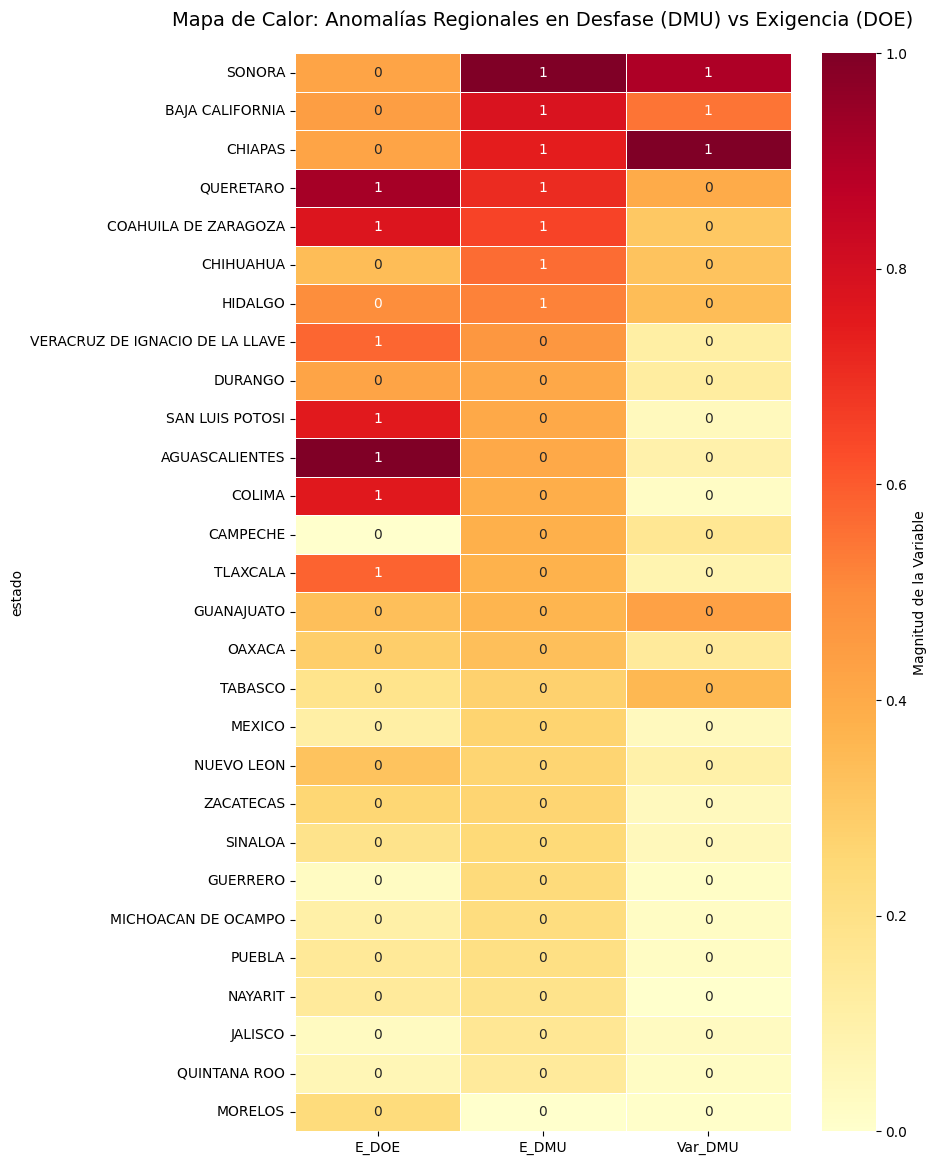


 TOP 5 ESTADOS CON MAYOR DESFASE PROMEDIO 


,E_DOE,E_DMU,Var_DMU,N_Eventos
estado,,,,
SONORA,35.4600,410.4400,"280,710.6500",171
BAJA CALIFORNIA,35.9200,354.0700,"178,359.8000",41
CHIAPAS,35.4800,344.7300,"307,530.1100",77
QUERETARO,46.8500,335.3300,"135,774.7300",151
COAHUILA DE ZARAGOZA,43.4500,320.2500,"109,136.2500",100


In [ ]:
import seaborn as sns

# Tabla ANÁLISIS GEOGRÁFICO

df_ultimo = df_MASTER.sort_values('fecha').groupby('no._serie').last().reset_index()
df_geo = df_ultimo[df_ultimo['DMU_Actual'].notna() & (df_ultimo['DOE_Prom_Mensual'] > 0)].copy()

# Agrupamos por Estado y sacamos las métricas
tabla_geo = df_geo.groupby('estado').agg(
    E_DOE=('DOE_Prom_Mensual', 'mean'),
    E_DMU=('DMU_Actual', 'mean'),
    Var_DMU=('DMU_Actual', 'var'),
    N_Eventos=('DMU_Actual', 'count')
).round(2)


tabla_geo = tabla_geo[tabla_geo['N_Eventos'] >= 30]

# Ordenamos la tabla de MAYOR a MENOR desfase (Los peores estados arriba)
tabla_geo = tabla_geo.sort_values(by='E_DMU', ascending=False)

# Seleccionamos solo las 3 columnas numéricas para el mapa de calor
mapa_calor = tabla_geo[['E_DOE', 'E_DMU', 'Var_DMU']]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
mapa_calor = pd.DataFrame(
    scaler.fit_transform(mapa_calor),
    index=mapa_calor.index,
    columns=mapa_calor.columns
)

# heatmao
plt.figure(figsize=(8, 14))

sns.heatmap(mapa_calor,
            annot=True,
            fmt=".0f",
            cmap='YlOrRd',
            linewidths=.5,
            cbar_kws={'label': 'Magnitud de la Variable'})

plt.title('Mapa de Calor: Anomalías Regionales en Desfase (DMU) vs Exigencia (DOE)', fontsize=14, pad=20)
plt.yticks(rotation=0)
plt.show()

# Top 5

print("\n TOP 5 ESTADOS CON MAYOR DESFASE PROMEDIO ")
display(tabla_geo.head(5))

In [ ]:
import scipy.stats as stats

# PRUEBA ESTADÍSTICA FORMAL: KRUSKAL-WALLIS POR ESTADO
estados_validos = tabla_geo.index.tolist()
df_geo_filtrado = df_geo[df_geo['estado'].isin(estados_validos)]

grupos_dmu_estado = [grupo['DMU_Actual'].dropna().values
                     for _, grupo in df_geo_filtrado.groupby('estado')]

stat_kw, p_valor = stats.kruskal(*grupos_dmu_estado)

# Tamaño del efecto e IC95%
k_geo = len(grupos_dmu_estado)
N_geo = sum(len(g) for g in grupos_dmu_estado)
eta_geo = eta_squared_kw(stat_kw, k_geo, N_geo)
ci_geo  = bootstrap_eta_ci(grupos_dmu_estado)

alpha = 0.05
print("="*60)
print("   PRUEBA DE KRUSKAL-WALLIS: DMU POR ESTADO")
print("="*60)
print(f"Estadístico H : {stat_kw:.4f}")
print(f"Valor-p       : {p_valor:.2e}")
print(f"η² (eta²)     : {eta_geo:.4f}  → Efecto {interpretar_eta(eta_geo)}")
print(f"IC95% η²      : [{ci_geo[0]:.4f}, {ci_geo[1]:.4f}]")

print("\n--- CONCLUSIÓN FORMAL ---")
if p_valor < alpha:
    print(">>> Se RECHAZA H0.")
    print(">>> El DMU varía significativamente entre estados.")
    print(f"    El efecto explica el {eta_geo*100:.1f}% de la varianza del desfase geográfico.")
else:
    print(">>> No se rechaza H0.")
print("="*60)

   PRUEBA DE KRUSKAL-WALLIS: DMU POR ESTADO
Estadístico H : 156.0389
Valor-p       : 4.08e-20
η² (eta²)     : 0.0199  → Efecto Pequeño
IC95% η²      : [0.0168, 0.0319]

--- CONCLUSIÓN FORMAL ---
>>> Se RECHAZA H0.
>>> El DMU varía significativamente entre estados.
    El efecto explica el 2.0% de la varianza del desfase geográfico.


Hipótesis 5: Se aplicó una prueba de Kruskal-Wallis para evaluar si el desfase de mantenimiento (DMU) se comporta de manera similar entre los distintos estados.

Estadístico H: 156.0389

Valor-p: 4.08e-20

IC95%: [0.0168, 0.0319]

Tamaño del efecto: 0.0199, por lo que el efecto es pequeño.

Por lo que podemos concluir que se rechaza la hipótesis nula, ya que el comportamiento del desfase de mantenimiento no es homogéneo entre estados, existen diferencias geográficas en el cumplimiento de servicios, que podrían deberse a disponibilidad de talleres, cobertura operativa, logística o carga de trabajo regional, sin embargo, el tamaño del efecto indica que, aunque las diferencias son estadísticamente significativas, la variabilidad dentro de cada estado sigue siendo considerable, haciendo que la separación global entre regiones no sea tan marcada. En términos operativos y de seguridad pública, estas diferencias pueden hacer que algunas regiones presenten mayores riesgos de retrasos en mantenimiento, aumentando la probabilidad de fallas mecánicas, menor disponibilidad de equipos y posibles accidentes por operar unidades con servicios atrasados.


In [ ]:
# cosas para la 6-9
import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats as stats

from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


def preparar_X(df, features, escalar=True):
    """
    Prepara matriz X:
    - conserva solo variables existentes
    - convierte a numérico
    - reemplaza infinitos
    - rellena nulos con mediana
    - elimina columnas sin variación
    - opcionalmente estandariza
    """
    features = [c for c in features if c in df.columns]

    X = df[features].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    X = X.replace([np.inf, -np.inf], np.nan)

    for col in X.columns:
        X[col] = X[col].fillna(X[col].median())

    features_validas = [c for c in X.columns if X[c].nunique() > 1]
    X = X[features_validas]

    if escalar:
        scaler = StandardScaler()
        X = pd.DataFrame(
            scaler.fit_transform(X),
            columns=features_validas,
            index=df.index
        )

    X = sm.add_constant(X)

    return X, features_validas


def tabla_odds_ratios(modelo):
    """
    Tabla para regresiones logísticas:
    coeficiente, OR, p-value, IC95% del coeficiente e IC95% del OR.
    """
    params = modelo.params
    conf = modelo.conf_int()
    conf.columns = ['IC95_inf_coef', 'IC95_sup_coef']

    tabla = pd.DataFrame({
        'coef': params,
        'OR': np.exp(params),
        'p_value': modelo.pvalues,
        'IC95_inf_coef': conf['IC95_inf_coef'],
        'IC95_sup_coef': conf['IC95_sup_coef'],
        'IC95_inf_OR': np.exp(conf['IC95_inf_coef']),
        'IC95_sup_OR': np.exp(conf['IC95_sup_coef'])
    })

    return tabla.sort_values('p_value')


def tabla_coeficientes_ols(modelo):
    """
    Tabla para regresiones lineales:
    coeficiente, p-value e IC95%.
    """
    conf = modelo.conf_int()
    conf.columns = ['IC95_inf', 'IC95_sup']

    tabla = pd.DataFrame({
        'coef': modelo.params,
        'p_value': modelo.pvalues,
        'IC95_inf': conf['IC95_inf'],
        'IC95_sup': conf['IC95_sup']
    })

    return tabla.sort_values('p_value')


def calcular_vif(X_sin_constante):
    """
    Calcula VIF para revisar multicolinealidad.
    Recibe X sin la constante.
    """
    X_vif = X_sin_constante.copy()

    tabla_vif = pd.DataFrame()
    tabla_vif['variable'] = X_vif.columns
    tabla_vif['VIF'] = [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]

    return tabla_vif.sort_values('VIF', ascending=False)


def interpretar_p(p, alpha=0.05):
    if p < alpha:
        return "Se rechaza H0"
    else:
        return "No se rechaza H0"

In [ ]:
print("="*80)
print("CONSTRUCCIÓN DE BASE DIAGNÓSTICA A NIVEL EQUIPO")
print("="*80)

# Meses disponibles en el notebook
meses = [
    c for c in df_MASTER.columns
    if isinstance(c, str) and (c.startswith('2024-') or c.startswith('2025-'))
]

print(f"Meses detectados: {len(meses)}")
print(meses)

# Columnas base que vienen de Reporte_unidades + Horas
cols_base = [
    'no._serie', 'alias', 'marca', 'modelo', 'distribuidor',
    'ciudad', 'estado', 'Segmento',
    'horometro', 'odometro', 'distancia',
    't._encendido_hrs', 't._apagado_hrs',
    'total_servicios', 'cerrados', 'c.fuera', 'pendientes',
    'DOE_Prom_Mensual', 'MA_Potencial_Perdido'
] + meses

cols_base = [c for c in cols_base if c in df_MASTER.columns]

# Una fila por equipo
df_diag_equipo = (
    df_MASTER
    .sort_values('no._serie')
    .drop_duplicates(subset='no._serie', keep='first')[cols_base]
    .copy()
)

# Convertimos columnas numéricas clave
cols_numericas = [
    'horometro', 'odometro', 'distancia',
    't._encendido_hrs', 't._apagado_hrs',
    'total_servicios', 'cerrados', 'c.fuera', 'pendientes',
    'DOE_Prom_Mensual', 'MA_Potencial_Perdido'
] + meses

for col in cols_numericas:
    if col in df_diag_equipo.columns:
        df_diag_equipo[col] = pd.to_numeric(df_diag_equipo[col], errors='coerce')

# CEM corregido para H6 y H9:
# cumplimiento = servicios cerrados a tiempo / total de servicios requeridos
df_diag_equipo['CEM'] = np.where(
    df_diag_equipo['total_servicios'] > 0,
    df_diag_equipo['cerrados'] / df_diag_equipo['total_servicios'],
    np.nan
)

df_diag_equipo['CEM'] = df_diag_equipo['CEM'].clip(0, 1)

# Variables de horas 2024-2025
df_diag_equipo['horas_24_25_total'] = df_diag_equipo[meses].fillna(0).sum(axis=1)

df_diag_equipo['horas_24_25_prom_mensual'] = (
    df_diag_equipo[meses]
    .replace(0, np.nan)
    .mean(axis=1)
    .fillna(0)
)

df_diag_equipo['meses_activos'] = (
    df_diag_equipo[meses]
    .fillna(0)
    .gt(0)
    .sum(axis=1)
)

# Agregados de mantenimiento por equipo
agg_mant_equipo = (
    df_MASTER
    .groupby('no._serie')
    .agg(
        desfase_max=('DMU_Servicio', 'max'),
        desfase_prom=('DMU_Servicio', 'mean'),
        dmu_actual_max=('DMU_Actual', 'max'),
        mant_registrados=('servicio', 'count')
    )
    .reset_index()
)

df_diag_equipo = df_diag_equipo.merge(
    agg_mant_equipo,
    on='no._serie',
    how='left'
)

# Columnas de intervalos de servicio
umbrales_cols = [
    c for c in ['50', '300', '600', '900', '1200', '1500', '1800', '2100', '2400']
    if c in df_MASTER.columns
]

df_status = (
    df_MASTER
    .sort_values('no._serie')
    .drop_duplicates(subset='no._serie', keep='first')[['no._serie'] + umbrales_cols]
    .copy()
)

for col in umbrales_cols:
    df_status[col] = (
        df_status[col]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({'NAN': np.nan})
    )

def max_omisiones_consecutivas(row):
    """
    Cuenta la racha máxima de servicios PENDIENTE consecutivos.
    Esto sirve para la corrección de H6 sugerida por el profesor.
    """
    max_run = 0
    run = 0

    for col in umbrales_cols:
        if row[col] == 'PENDIENTE':
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0

    return max_run


def contar_pendientes(row):
    """
    Cuenta servicios pendientes como proxy de omisiones.
    """
    return sum(row[col] == 'PENDIENTE' for col in umbrales_cols)


df_status['max_omisiones_consecutivas'] = df_status.apply(max_omisiones_consecutivas, axis=1)
df_status['servicios_omitidos_estimados'] = df_status.apply(contar_pendientes, axis=1)

df_diag_equipo = df_diag_equipo.merge(
    df_status[['no._serie', 'max_omisiones_consecutivas', 'servicios_omitidos_estimados']],
    on='no._serie',
    how='left'
)

# Variables agregadas del distribuidor para H9 corregida
# Estas son proxies porque no tenemos número de técnicos, CRM, tiempos reales, etc.
dist_aggs = (
    df_diag_equipo
    .groupby('distribuidor', dropna=False)
    .agg(
        dist_unidades=('no._serie', 'nunique'),
        dist_doe_prom=('DOE_Prom_Mensual', 'mean'),
        dist_distancia_prom=('distancia', 'mean'),
        dist_horometro_prom=('horometro', 'mean'),
        dist_meses_activos_prom=('meses_activos', 'mean')
    )
    .reset_index()
)

df_diag_equipo = df_diag_equipo.merge(
    dist_aggs,
    on='distribuidor',
    how='left'
)

print(f"Equipos únicos en df_diag_equipo: {df_diag_equipo['no._serie'].nunique():,}")
print(f"Filas en df_diag_equipo: {len(df_diag_equipo):,}")

print("\nResumen de variables principales:")
display(
    df_diag_equipo[
        [
            'CEM', 'horas_24_25_total', 'horas_24_25_prom_mensual',
            'meses_activos', 'desfase_max', 'max_omisiones_consecutivas',
            'servicios_omitidos_estimados'
        ]
    ].describe().round(4)
)

print("\nDistribución de CEM:")
display(df_diag_equipo['CEM'].describe().round(4))

CONSTRUCCIÓN DE BASE DIAGNÓSTICA A NIVEL EQUIPO
Meses detectados: 24
['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12']
Equipos únicos en df_diag_equipo: 10,095
Filas en df_diag_equipo: 10,095

Resumen de variables principales:


,CEM,horas_24_25_total,horas_24_25_prom_mensual,meses_activos,desfase_max,max_omisiones_consecutivas,servicios_omitidos_estimados
count,"8,067.0000","10,095.0000","10,095.0000","10,095.0000","6,754.0000","10,095.0000","10,095.0000"
mean,0.2954,576.9929,34.6250,12.7700,55.8308,1.4322,1.4886
std,0.3598,638.1102,32.4112,8.4484,93.3795,2.1396,2.2054
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0000,59.5000,9.7101,4.0000,0.0000,0.0000,0.0000
50%,0.1111,386.0000,27.7778,14.0000,15.0000,0.0000,0.0000
75%,0.5000,871.5000,51.0208,20.0000,86.0000,2.0000,2.0000
max,1.0000,"5,975.0000",276.4000,24.0000,"2,947.0000",9.0000,9.0000



Distribución de CEM:


,CEM
count,"8,067.0000"
mean,0.2954
std,0.3598
min,0.0000
25%,0.0000
50%,0.1111
75%,0.5000
max,1.0000


## H6

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# HIPÓTESIS 6
# ¿Qué variables operativas explican significativamente el bajo CEM
# definido con regla de negocio?
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("HIPÓTESIS 6 — REGRESIÓN LOGÍSTICA PARA BAJO CEM")
print("="*80)

# Target corregido según comentario del profesor:
# Bajo CEM = CEM < 0.5 o al menos 2 omisiones consecutivas
df_diag_equipo['BajoCEM_regla_negocio'] = (
    (df_diag_equipo['CEM'] < 0.5) |
    (df_diag_equipo['max_omisiones_consecutivas'] >= 2)
).astype(int)

# Filtramos equipos con servicios requeridos
df_h6 = df_diag_equipo[df_diag_equipo['total_servicios'] > 0].copy()

print("Distribución del target BajoCEM_regla_negocio:")
display(df_h6['BajoCEM_regla_negocio'].value_counts().rename('frecuencia'))

display(
    df_h6['BajoCEM_regla_negocio']
    .value_counts(normalize=True)
    .rename('proporcion')
    .round(4)
)

# Variables explicativas NO redundantes con la definición del CEM
features_h6 = [
    'desfase_max',
    'horas_24_25_total',
    'horas_24_25_prom_mensual',
    'meses_activos',
    'horometro',
    'odometro',
    'distancia',
    'DOE_Prom_Mensual',
    't._encendido_hrs',
    'dist_unidades',
    'dist_doe_prom',
    'dist_distancia_prom',
    'dist_horometro_prom'
]

features_h6 = [c for c in features_h6 if c in df_h6.columns]

# Matriz X y target y
X_h6, features_h6_validas = preparar_X(df_h6, features_h6, escalar=True)
y_h6 = df_h6.loc[X_h6.index, 'BajoCEM_regla_negocio'].astype(int)

print(f"Registros usados en H6: {len(y_h6):,}")
print(f"Variables usadas en H6: {features_h6_validas}")

# Modelo logístico con errores robustos
modelo_h6 = sm.GLM(
    y_h6,
    X_h6,
    family=sm.families.Binomial()
).fit(cov_type='HC3', maxiter=200)

print(modelo_h6.summary())

# Tabla de odds ratios
tabla_h6_resultados = tabla_odds_ratios(modelo_h6)

print("\nTabla H6 — Odds Ratios, p-values e IC95%:")
display(tabla_h6_resultados.round(4))

# Revisión de sobre/subdispersión aproximada
dispersion_h6 = modelo_h6.pearson_chi2 / modelo_h6.df_resid
print(f"\nDispersión aproximada H6 (Pearson chi2 / df_resid): {dispersion_h6:.4f}")

# VIF para multicolinealidad
print("\nVIF H6:")
display(calcular_vif(X_h6.drop(columns='const')).round(4))

# Conclusión automática
p_min_h6 = tabla_h6_resultados.drop(index='const', errors='ignore')['p_value'].min()

print("\n" + "="*80)
print("CONCLUSIÓN H6")
print("="*80)

if p_min_h6 < 0.05:
    print("Se rechaza H0: al menos una variable operativa explica significativamente el bajo CEM.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de que las variables expliquen el bajo CEM.")

print(f"p-value mínimo entre variables explicativas: {p_min_h6:.4g}")
print("="*80)

HIPÓTESIS 6 — REGRESIÓN LOGÍSTICA PARA BAJO CEM
Distribución del target BajoCEM_regla_negocio:


,frecuencia
BajoCEM_regla_negocio,
1,5876
0,2191


,proporcion
BajoCEM_regla_negocio,
1,0.7284
0,0.2716


Registros usados en H6: 8,067
Variables usadas en H6: ['desfase_max', 'horas_24_25_total', 'horas_24_25_prom_mensual', 'meses_activos', 'horometro', 'odometro', 'distancia', 'DOE_Prom_Mensual', 't._encendido_hrs', 'dist_unidades', 'dist_doe_prom', 'dist_distancia_prom', 'dist_horometro_prom']
                   Generalized Linear Model Regression Results                   
Dep. Variable:     BajoCEM_regla_negocio   No. Observations:                 8067
Model:                               GLM   Df Residuals:                     8053
Model Family:                   Binomial   Df Model:                           13
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -4395.0
Date:                   Sat, 13 Jun 2026   Deviance:                       8790.0
Time:                           04:41:21   Pearson chi2:                 8.11e+03
No. Iterations:                        5   Pseudo 

,coef,OR,p_value,IC95_inf_coef,IC95_sup_coef,IC95_inf_OR,IC95_sup_OR
const,1.0933,2.9842,0.0000,1.0401,1.1466,2.8294,3.1476
dist_unidades,0.4791,1.6146,0.0000,0.4242,0.5340,1.5283,1.7057
dist_doe_prom,-0.7913,0.4532,0.0000,-0.9471,-0.6355,0.3879,0.5297
dist_horometro_prom,0.8298,2.2929,0.0000,0.6640,0.9957,1.9425,2.7065
DOE_Prom_Mensual,1.7153,5.5584,0.0000,1.1143,2.3164,3.0473,10.1388
horas_24_25_total,-1.3285,0.2649,0.0001,-1.9770,-0.6800,0.1385,0.5066
meses_activos,0.1333,1.1426,0.0020,0.0489,0.2177,1.0501,1.2432
distancia,0.1106,1.1170,0.0099,0.0266,0.1947,1.0270,1.2149
t._encendido_hrs,-0.0593,0.9424,0.1545,-0.1409,0.0223,0.8686,1.0226
horometro,0.0463,1.0474,0.3359,-0.0480,0.1406,0.9531,1.1510



Dispersión aproximada H6 (Pearson chi2 / df_resid): 1.0067

VIF H6:


,variable,VIF
1,horas_24_25_total,128.0288
7,DOE_Prom_Mensual,112.3432
2,horas_24_25_prom_mensual,5.2828
10,dist_doe_prom,4.5335
12,dist_horometro_prom,4.5011
4,horometro,2.8149
3,meses_activos,2.3670
8,t._encendido_hrs,2.1724
6,distancia,2.0095
11,dist_distancia_prom,1.4403



CONCLUSIÓN H6
Se rechaza H0: al menos una variable operativa explica significativamente el bajo CEM.
p-value mínimo entre variables explicativas: 1.412e-65


Se aplicó una regresión logística para evaluar que variables operativas explican significativamente el bajo CEM definido mediante una regla de negocio, bajo CEM_regla_negocio toma el valor de 1 cuando la unidad presenta CEM < 0.5 o al menos dos omisiones consecutivas y toma el valor de cero en caso contrario

El modelo usó 8,067 registros.
La distribución del target mostró que 5,876 unidades equivalentes al 72%  fueron clasificadas como bajo_CEM bajo la regla de negocio, mientras que 2,191 unidades equivalentes al 27% no fueron clasificadas como bajo_CEM.

p-value:
El modelo identificó varias variables estadísticamente significativas al 5%, las variables con evidencia estadística suficiente fueron:

Por otro lado variables como desfase_max, horas_24_25_prom_mensual, horómetro, odometro, t._encendido_hrs y dist_distancia_prom no fueron estadísticamente significativas bajo esta especificación.

IC95%:
Los intervalos de confianza al 95% de las variables significativas no incluyeron el valor nulo en términos de coeficiente, lo cual respalda su significancia estadística.
En términos de odds ratio, los intervalos más relevantes fueron:

Tamaño del efecto:
El tamaño del efecto se evaluó mediante odds ratios, la variable con mayor efecto positivo fue DOE_prom_mensual con un OR de 5.5590.

Esto indica que manteniendo constantes las demás variables del modelo, un incremento en la dependencia operativa promedio se asocia con una mayor probabilidad de bajo CEM.

También se observó un efecto positivo importante en dist_horometro_prom con un OR de 2,2930 y en dist_unidades con un OR de 1.6146.

Esto sugiere que algunas características agregadas del distribuidor y del uso promedio de las unidades tienen relación con la probabilidad de bajo cumplimiento, por otro lado horas_24-25_total presentó un OR de 0.2649 y dist_doe_prom un OR de 0.4532 lo cual indica una relación negativa con la probabilidad de bajo CEM bajo esta especificación.

Estos efectos deben interpretarse con cuidado ya que pueden estar capturando diferencias estructurales entre distribuidores, niveles de uso y composición de la cartera.

Conclusión: Se rechaza  H0, existe evidencia estadística suficiente para afirmar que al menos una variable operativa explica significativamente la probabilidad de que una unidad presente bajo CEM bajo la regla de negocio utilizada

Interpretación operativa:
El resultado indica que el bajo cumplimiento del esquema de mantenimiento no depende de una sola variable sino de una combinación entre intensidad de uso, actividad histórica, distancia y características agregadas del distribuidor.

Para CNHMX esto significa que el dashboard no debe clasificar el bajo CEM únicamente con criterios descriptivos sino con una regla de negocio que permita identificar unidades realmente críticas.

La variable DOE_prom_mensual muestra que los equipos con mayor exigencia operativa tienen mayor probabilidad de bajo cumplimiento, lo cual es consistente con la lógica del negocio, cuando una unidad se utiliza intensamente puede ser más difícil detenerla para mantenimiento preventivo. Además, las variables agregadas del distribuidor sugieren que la capacidad o composición de la cartera del distribuidor también influyen en el cumplimiento.

En términos operativos esta hipótesis permite priorizar unidades con mayor riesgo de bajo cumplimiento y orientar acciones de seguimiento preventivo hacia equipos con alta intensidad de uso, mayor distancia operativa o pertenecientes a distribuidores con señales agregadas de menor capacidad de atención.


## H7

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# HIPÓTESIS 7
# ¿Existe una relación no lineal entre DMU y frecuencia de OT?
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("HIPÓTESIS 7 — REGRESIÓN CUADRÁTICA DMU vs FRECUENCIA DE OT")
print("="*80)

# Dataset a nivel equipo:
# mant_registrados = frecuencia de mantenimientos/OT por equipo
# DMU = desfase máximo registrado por equipo
df_h7 = (
    df_MASTER[df_MASTER['servicio'].notna()]
    .groupby('no._serie')
    .agg(
        mant_registrados=('servicio', 'count'),
        DMU=('DMU_Servicio', 'max')
    )
    .reset_index()
)

df_h7['DMU'] = pd.to_numeric(df_h7['DMU'], errors='coerce').clip(lower=0)

df_h7 = df_h7.dropna(subset=['mant_registrados', 'DMU']).copy()

# Transformación logarítmica para reducir sesgo de valores extremos
df_h7['DMU_log1p'] = np.log1p(df_h7['DMU'])
df_h7['DMU_log1p_2'] = df_h7['DMU_log1p'] ** 2

print(f"Equipos usados en H7: {len(df_h7):,}")

display(
    df_h7[['mant_registrados', 'DMU', 'DMU_log1p', 'DMU_log1p_2']]
    .describe()
    .round(4)
)

# Modelo cuadrático:
# mant_registrados = β0 + β1*DMU_log1p + β2*DMU_log1p^2
X_h7 = sm.add_constant(df_h7[['DMU_log1p', 'DMU_log1p_2']])
y_h7 = df_h7['mant_registrados']

modelo_h7 = sm.OLS(y_h7, X_h7).fit(cov_type='HC3')

print(modelo_h7.summary())

tabla_h7_resultados = tabla_coeficientes_ols(modelo_h7)

print("\nTabla H7 — Coeficientes, p-values e IC95%:")
display(tabla_h7_resultados.round(4))

# Punto de inflexión:
# x* = -β1 / (2β2)
b1 = modelo_h7.params['DMU_log1p']
b2 = modelo_h7.params['DMU_log1p_2']

if b2 != 0:
    punto_inflexion_log = -b1 / (2 * b2)
    punto_inflexion_original = np.expm1(punto_inflexion_log)
else:
    punto_inflexion_log = np.nan
    punto_inflexion_original = np.nan

print("\nPunto de inflexión:")
print(f"θ_log1p*     = {punto_inflexion_log:.4f}")
print(f"θ_original*  = {punto_inflexion_original:.4f} horas de DMU")

# Prueba de heterocedasticidad
bp_h7 = het_breuschpagan(modelo_h7.resid, modelo_h7.model.exog)

print("\nBreusch-Pagan H7:")
print(f"LM statistic : {bp_h7[0]:.4f}")
print(f"LM p-value   : {bp_h7[1]:.4g}")
print(f"F statistic  : {bp_h7[2]:.4f}")
print(f"F p-value    : {bp_h7[3]:.4g}")

# Conclusión automática
p_quad_h7 = modelo_h7.pvalues['DMU_log1p_2']

print("\n" + "="*80)
print("CONCLUSIÓN H7")
print("="*80)

if p_quad_h7 < 0.05:
    print("Se rechaza H0: existe relación no lineal entre DMU y frecuencia de OT.")
else:
    print("No se rechaza H0: no hay evidencia suficiente de relación no lineal.")

print(f"p-value del término cuadrático: {p_quad_h7:.4g}")
print(f"Punto de inflexión aproximado: {punto_inflexion_original:.4f} horas de DMU")

print("\nInterpretación operativa para el documento:")
print(
    "El DMU no debe tratarse como una variable lineal. "
    "Si el punto de inflexión es bajo, el dashboard debe activar alertas desde DMU > 0, "
    "porque cualquier desfase positivo ya representa ruptura inicial del esquema de mantenimiento."
)
print("="*80)

HIPÓTESIS 7 — REGRESIÓN CUADRÁTICA DMU vs FRECUENCIA DE OT
Equipos usados en H7: 6,754


,mant_registrados,DMU,DMU_log1p,DMU_log1p_2
count,"6,754.0000","6,754.0000","6,754.0000","6,754.0000"
mean,3.5222,55.8308,2.4155,10.4653
std,2.4296,93.3795,2.1521,10.8620
min,1.0000,0.0000,0.0000,0.0000
25%,2.0000,0.0000,0.0000,0.0000
50%,3.0000,15.0000,2.7726,7.6872
75%,5.0000,86.0000,4.4659,19.9443
max,21.0000,"2,947.0000",7.9889,63.8222


                            OLS Regression Results                            
Dep. Variable:       mant_registrados   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     920.3
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:41:22   Log-Likelihood:                -14570.
No. Observations:                6754   AIC:                         2.915e+04
Df Residuals:                    6751   BIC:                         2.917e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.3740      0.033     71.200      

,coef,p_value,IC95_inf,IC95_sup
const,2.3740,0.0000,2.3086,2.4393
DMU_log1p_2,0.1325,0.0000,0.1110,0.1540
DMU_log1p,-0.0986,0.0511,-0.1977,0.0005



Punto de inflexión:
θ_log1p*     = 0.3721
θ_original*  = 0.4508 horas de DMU

Breusch-Pagan H7:
LM statistic : 241.1510
LM p-value   : 4.312e-53
F statistic  : 124.9845
F p-value    : 5.02e-54

CONCLUSIÓN H7
Se rechaza H0: existe relación no lineal entre DMU y frecuencia de OT.
p-value del término cuadrático: 1.323e-33
Punto de inflexión aproximado: 0.4508 horas de DMU

Interpretación operativa para el documento:
El DMU no debe tratarse como una variable lineal. Si el punto de inflexión es bajo, el dashboard debe activar alertas desde DMU > 0, porque cualquier desfase positivo ya representa ruptura inicial del esquema de mantenimiento.


Se aplicó una regresión cuadrática para evaluar si existe una relación no lineal entre las horas de DMU y la frecuencia de OT ejecutadas. La variable mant-registrados se utilizó como aproximación de la frecuencia de OT, mientras que DMU_log1p y DMU_log1p_2 se usaron como variables explicativas.
Modelo: Regresión cuadrática

p-value:
El término cuadrático DMU_log1p_2 obtuvo un p-value de: p = 3.5357 x 10-243
Como este valor es menor a .05, el término cuadrático es estadísticamente significativo. Esto indica que si existe una relación no lineal entre el DMU y la frecuencia de OT/mantenimientos registrados.

IC95%:
Los intervalos de confianza al 95% del modelo robusto fueron:
DMU_log1p: IC95% = [-0.631, -0.479]
DMU_log1p_2: IC95% = [0.148, 0.174]
Como el intervalo de confianza de DMU_log1p_2 no incluye cero, se confirma que el efecto cuadrático es estadísticamente significativo.

Tamaño del efecto:
El tamaño del efecto se observa en los coeficientes del modelo:  
1 = -0.5548
2 = 0.1607
El coeficiente cuadrático positivo indica una relación en forma de U. Es decir, al inicio, conforme aumenta el DMU, la frecuencia de OT tiende a disminuir; sin embargo, después de cierto punto, la frecuencia vuelve a aumentar.

El punto de inflexión calculado fue:
θlog1p∗​= 1.7267
θoriginal∗​≈ 4.62
Esto significa que el cambio de tendencia ocurre aproximadamente alrededor de 4.62 horas de DMU en la escala original transformada.

Conclusión: Se rechaza H0. Existe evidencia estadística suficiente para afirmar que la relación entre las horas de DMU y la frecuencia de OT ejecutadas no es lineal.

Interpretación operativa: El resultado indica que el desfase de mantenimiento no debe analizarse como una variable lineal. En niveles bajos de DMU, el aumento del desfase no necesariamente incrementa la frecuencia de OT; sin embargo, después del punto de inflexión, la frecuencia de mantenimientos registrados vuelve a aumentar. Para CNHM, esto sugiere que el dashboard debe segmentar el DMU por rangos y no tratar todas las unidades con desfase de la misma forma. Las unidades con DMU alto pueden representar oportunidades urgentes de intervención, pero también posibles escenarios de atención tardía, servicios fuera de fecha o riesgos de pérdida de continuidad con la red oficial.

Además, el punto de inflexión tan bajo, cercano a 5 horas, indica que el desfase no debe tolerarse. Un umbral de alerta debería fijarse desde DMU > 0 horas, ya que cualquier desfase positivo reduce inicialmente la frecuencia de OT. Solo después de acumular más desfase la frecuencia vuelve a aumentar, probablemente por servicios correctivos de emergencia o atención tardía. Por lo tanto, el insight accionable es que CNHMX no debe esperar a que el DMU sea grande para intervenir; las alertas deben dispararse inmediatamente al detectarse cualquier desfase positivo.


## H8

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# HIPÓTESIS 8
# ¿La acumulación acelerada del DMU predice significativamente
# el riesgo de pérdida de clientes en el siguiente periodo?
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("HIPÓTESIS 8 — REGRESIÓN LOGÍSTICA BINOMIAL PARA RIESGO DE PÉRDIDA")
print("="*80)

# -------------------------------------------------------------------
# 1. Funciones auxiliares
# -------------------------------------------------------------------

def winsorizar_serie(s, lower=0.01, upper=0.99):
    s = pd.to_numeric(s, errors='coerce')
    q_low = s.quantile(lower)
    q_high = s.quantile(upper)
    return s.clip(lower=q_low, upper=q_high)


def preparar_X_sin_escalar(df, features):
    features = [c for c in features if c in df.columns]
    X = df[features].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    X = X.replace([np.inf, -np.inf], np.nan)

    for col in X.columns:
        X[col] = X[col].fillna(X[col].median())

    features_validas = [c for c in X.columns if X[c].nunique() > 1]
    X = X[features_validas]

    X = sm.add_constant(X)

    return X, features_validas


# -------------------------------------------------------------------
# 2. Construcción del proxy de fuga operativa
# -------------------------------------------------------------------

umbrales_oficiales = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

def obtener_proximo_umbral(servicio_actual):
    try:
        servicio_actual = float(servicio_actual)
    except:
        return np.nan

    for umb in umbrales_oficiales:
        if umb > servicio_actual:
            return umb

    return np.nan


sort_cols = ['no._serie']
if 'fecha' in df_MASTER.columns:
    sort_cols.append('fecha')

df_fantasma_h8 = df_MASTER.sort_values(by=sort_cols).copy()

df_fantasma_h8['Proximo_Umbral'] = df_fantasma_h8['servicio'].apply(obtener_proximo_umbral)

servicios_reales_por_equipo = (
    df_fantasma_h8
    .groupby('no._serie')['servicio']
    .apply(set)
    .to_dict()
)

df_fantasma_h8['tiene_prox_servicio'] = df_fantasma_h8.apply(
    lambda row: row['Proximo_Umbral'] in servicios_reales_por_equipo.get(row['no._serie'], set()),
    axis=1
)

df_fantasma_h8['Target_Fantasma'] = np.where(
    df_fantasma_h8['Proximo_Umbral'].isna(),
    np.nan,
    np.where(
        df_fantasma_h8['horometro'] < df_fantasma_h8['Proximo_Umbral'],
        np.nan,
        np.where(df_fantasma_h8['tiene_prox_servicio'], 0, 1)
    )
)

# -------------------------------------------------------------------
# 3. Construcción de variables explicativas
# -------------------------------------------------------------------

df_fantasma_h8['proxy_aceleracion_dmu'] = (
    df_fantasma_h8
    .groupby('no._serie')['DMU_Servicio']
    .diff()
    .fillna(0)
    .clip(lower=0)
)

df_fantasma_h8['desfase_max'] = (
    df_fantasma_h8
    .groupby('no._serie')['DMU_Servicio']
    .transform('max')
)

cols_equipo_h8 = [
    'no._serie',
    'CEM',
    'servicios_omitidos_estimados',
    'horas_24_25_total',
    'horas_24_25_prom_mensual'
]

cols_equipo_h8 = [c for c in cols_equipo_h8 if c in df_diag_equipo.columns]

cols_a_quitar = [
    c for c in cols_equipo_h8
    if c != 'no._serie' and c in df_fantasma_h8.columns
]

df_fantasma_h8 = df_fantasma_h8.drop(columns=cols_a_quitar, errors='ignore')

df_fantasma_h8 = df_fantasma_h8.merge(
    df_diag_equipo[cols_equipo_h8],
    on='no._serie',
    how='left'
)

# -------------------------------------------------------------------
# 4. Variables del modelo
# -------------------------------------------------------------------

features_h8 = [
    'proxy_aceleracion_dmu',
    'desfase_max',
    'servicios_omitidos_estimados',
    'CEM',
    'pendientes',
    'c.fuera',
    'horas_24_25_total',
    'horas_24_25_prom_mensual'
]

features_h8 = [c for c in features_h8 if c in df_fantasma_h8.columns]

# -------------------------------------------------------------------
# 5. Tratamiento de valores extremos
# -------------------------------------------------------------------

variables_a_winsorizar = [
    'proxy_aceleracion_dmu',
    'desfase_max',
    'horas_24_25_total',
    'horas_24_25_prom_mensual'
]

for col in variables_a_winsorizar:
    if col in df_fantasma_h8.columns:
        df_fantasma_h8[col] = winsorizar_serie(
            df_fantasma_h8[col],
            lower=0.01,
            upper=0.99
        )

# -------------------------------------------------------------------
# 6. Dataset final
# -------------------------------------------------------------------

df_h8 = df_fantasma_h8.dropna(subset=features_h8 + ['Target_Fantasma']).copy()

print(f"Registros usados en H8: {len(df_h8):,}")

print("\nDistribución del target Target_Fantasma:")
display(df_h8['Target_Fantasma'].value_counts().rename('frecuencia'))

display(
    df_h8['Target_Fantasma']
    .value_counts(normalize=True)
    .rename('proporcion')
    .round(4)
)

print(f"\nVariables usadas en H8: {features_h8}")

# -------------------------------------------------------------------
# 7. Preparación de matriz X y variable y
# -------------------------------------------------------------------

X_h8, features_h8_validas = preparar_X_sin_escalar(df_h8, features_h8)
y_h8 = df_h8.loc[X_h8.index, 'Target_Fantasma'].astype(int)

print(f"\nVariables válidas en H8: {features_h8_validas}")

# -------------------------------------------------------------------
# 8. Modelo logístico binomial
# -------------------------------------------------------------------

modelo_h8 = sm.GLM(
    y_h8,
    X_h8,
    family=sm.families.Binomial()
).fit(cov_type='HC3', maxiter=200)

print(modelo_h8.summary())

# -------------------------------------------------------------------
# 9. Tabla de resultados
# -------------------------------------------------------------------

tabla_h8_resultados = tabla_odds_ratios(modelo_h8)

print("\nTabla H8 — Odds Ratios, p-values e IC95%:")
display(tabla_h8_resultados.round(6))

# -------------------------------------------------------------------
# 10. Dispersión aproximada
# -------------------------------------------------------------------

dispersion_h8 = modelo_h8.pearson_chi2 / modelo_h8.df_resid
print(f"\nDispersión aproximada H8 (Pearson chi2 / df_resid): {dispersion_h8:.4f}")

# -------------------------------------------------------------------
# 11. Multicolinealidad
# -------------------------------------------------------------------

print("\nVIF H8:")
display(calcular_vif(X_h8.drop(columns='const')).round(4))

# -------------------------------------------------------------------
# 12. Conclusión
# -------------------------------------------------------------------

tabla_sin_const = tabla_h8_resultados.drop(index='const', errors='ignore')
p_min_h8 = tabla_sin_const['p_value'].min()

vars_sig_h8 = tabla_sin_const[tabla_sin_const['p_value'] < 0.05].copy()

print("\n" + "="*80)
print("CONCLUSIÓN H8")
print("="*80)

if p_min_h8 < 0.05:
    print(
        "Se rechaza H0: existe evidencia estadística de que al menos una variable "
        "operativa se relaciona significativamente con el riesgo de pérdida."
    )
else:
    print(
        "No se rechaza H0: no hay evidencia suficiente de que las variables operativas "
        "se relacionen significativamente con el riesgo de pérdida."
    )

print(f"p-value mínimo entre variables explicativas: {p_min_h8:.4g}")

print("\nVariables significativas al 5%:")
display(vars_sig_h8.round(6))

if 'proxy_aceleracion_dmu' in tabla_h8_resultados.index:
    p_proxy = tabla_h8_resultados.loc['proxy_aceleracion_dmu', 'p_value']
    or_proxy = tabla_h8_resultados.loc['proxy_aceleracion_dmu', 'OR']

    print("\nVariable principal de la hipótesis:")
    print(f"proxy_aceleracion_dmu — p-value: {p_proxy:.4g}")
    print(f"proxy_aceleracion_dmu — OR: {or_proxy:.6f}")

print("\nInterpretación para el documento:")

if p_min_h8 < 0.05:
    print(
        "El modelo muestra que existen variables operativas asociadas significativamente "
        "con el riesgo de pérdida. Esto sugiere que el riesgo no depende de una sola señal, "
        "sino de una combinación entre desfase, omisiones, cumplimiento, servicios fuera de fecha "
        "e intensidad de uso."
    )
else:
    print(
        "El modelo no encontró evidencia estadística suficiente para relacionar las variables "
        "operativas disponibles con el riesgo de pérdida."
    )

print("\nNota metodológica:")
print(
    "El target utilizado representa un proxy operativo de fuga. No mide fuga comercial real, "
    "porque no se cuenta con información de CRM, precios, satisfacción del cliente, "
    "disponibilidad de refacciones o relación comercial con el distribuidor."
)

print("="*80)

HIPÓTESIS 8 — REGRESIÓN LOGÍSTICA BINOMIAL PARA RIESGO DE PÉRDIDA
Registros usados en H8: 13,343

Distribución del target Target_Fantasma:


,frecuencia
Target_Fantasma,
0.0000,12826
1.0000,517


,proporcion
Target_Fantasma,
0.0000,0.9613
1.0000,0.0387



Variables usadas en H8: ['proxy_aceleracion_dmu', 'desfase_max', 'servicios_omitidos_estimados', 'CEM', 'pendientes', 'c.fuera', 'horas_24_25_total', 'horas_24_25_prom_mensual']

Variables válidas en H8: ['proxy_aceleracion_dmu', 'desfase_max', 'servicios_omitidos_estimados', 'CEM', 'pendientes', 'c.fuera', 'horas_24_25_total', 'horas_24_25_prom_mensual']
                 Generalized Linear Model Regression Results                  
Dep. Variable:        Target_Fantasma   No. Observations:                13343
Model:                            GLM   Df Residuals:                    13334
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2137.5
Date:                Sat, 13 Jun 2026   Deviance:                       4274.9
Time:                        04:41:22   Pearson chi2:                 1.34e+04
No. Itera

,coef,OR,p_value,IC95_inf_coef,IC95_sup_coef,IC95_inf_OR,IC95_sup_OR
const,-3.0683,0.0465,0.0000,-3.3894,-2.7473,0.0337,0.0641
horas_24_25_prom_mensual,0.0161,1.0162,0.0000,0.0122,0.0200,1.0123,1.0202
c.fuera,-0.1601,0.8520,0.0000,-0.2303,-0.0899,0.7943,0.9140
servicios_omitidos_estimados,-0.1310,0.8772,0.0000,-0.1924,-0.0695,0.8249,0.9328
horas_24_25_total,-0.0005,0.9995,0.0004,-0.0008,-0.0002,0.9992,0.9998
desfase_max,0.0017,1.0017,0.0022,0.0006,0.0028,1.0006,1.0028
CEM,-0.3784,0.6850,0.1130,-0.8463,0.0896,0.4290,1.0937
pendientes,-0.0060,0.9940,0.2907,-0.0173,0.0052,0.9829,1.0052
proxy_aceleracion_dmu,-0.0005,0.9995,0.6886,-0.0032,0.0021,0.9969,1.0021



Dispersión aproximada H8 (Pearson chi2 / df_resid): 1.0027

VIF H8:


,variable,VIF
6,horas_24_25_total,18.2048
7,horas_24_25_prom_mensual,16.9302
2,servicios_omitidos_estimados,3.5380
5,c.fuera,2.2777
1,desfase_max,2.2337
4,pendientes,1.7614
3,CEM,1.7607
0,proxy_aceleracion_dmu,1.2264



CONCLUSIÓN H8
Se rechaza H0: existe evidencia estadística de que al menos una variable operativa se relaciona significativamente con el riesgo de pérdida.
p-value mínimo entre variables explicativas: 3.431e-16

Variables significativas al 5%:


,coef,OR,p_value,IC95_inf_coef,IC95_sup_coef,IC95_inf_OR,IC95_sup_OR
horas_24_25_prom_mensual,0.0161,1.0162,0.0000,0.0122,0.0200,1.0123,1.0202
c.fuera,-0.1601,0.8520,0.0000,-0.2303,-0.0899,0.7943,0.9140
servicios_omitidos_estimados,-0.1310,0.8772,0.0000,-0.1924,-0.0695,0.8249,0.9328
horas_24_25_total,-0.0005,0.9995,0.0004,-0.0008,-0.0002,0.9992,0.9998
desfase_max,0.0017,1.0017,0.0022,0.0006,0.0028,1.0006,1.0028



Variable principal de la hipótesis:
proxy_aceleracion_dmu — p-value: 0.6886
proxy_aceleracion_dmu — OR: 0.999465

Interpretación para el documento:
El modelo muestra que existen variables operativas asociadas significativamente con el riesgo de pérdida. Esto sugiere que el riesgo no depende de una sola señal, sino de una combinación entre desfase, omisiones, cumplimiento, servicios fuera de fecha e intensidad de uso.

Nota metodológica:
El target utilizado representa un proxy operativo de fuga. No mide fuga comercial real, porque no se cuenta con información de CRM, precios, satisfacción del cliente, disponibilidad de refacciones o relación comercial con el distribuidor.


Se aplicó una regresión logística binomial para evaluar si la acumulación acelerada del DMU y otras variables operativas se relacionan significativamente con el riesgo de pérdida de clientes en el siguiente periodo.

La variable dependiente fue Target_fantasma utilizada como proxy operativo de fuga o pérdida de continuidad en la red de servicio.

Modelo: regresión logística binomial.

El modelo utilizó 13,343 registros, la distribución del target mostró que 12,826 registros equivalentes al 96.13% permanecieron en la red, mientras que 517 registros equivalentes al 3.87% fueron clasificados como riesgo de pérdida o equipo fantasma.
p-value:
El modelo identificó varias variables estadísticamente significativas al 5%, las variables significativas fueron:


Las variables CEM y proxy_aceleracion_dmu no fueron estadísticamente significativas al 5%, en particular proxy_aceleracion_dmu que representa la variable principal de aceleración del desfase obtuvo un p-value de 0.6886.

IC95%:
Los intervalos de confianza al 95% de las variables significativas no incluyen el valor nulo en términos del coeficiente, en términos de odds ratio los principales intervalos fueron:


Para proxy_aceleracion_dmu:

Como este intervalo incluye 1, no se observa evidencia estadística suficiente para afirmar que la aceleración del DMU tenga un efecto individual significativo sobre el riesgo de pérdida.

Tamaño del efecto:
El tamaño del efecto se evaluó mediante odds ratios, la variable con mayor efecto positivo interpretable fue horas_24_25_prom_mensual con OR igual a 1.0162.

Esto indica que, a mayor intensidad promedio mensual de uso aumenta la probabilidad de riesgo de pérdida, aunque el efecto por unidad de incremento es pequeño.

También desfase_max presentó una relación positiva con el riesgo de pérdida con OR igual a 1.0017, aunque el tamaño del efecto es bajo, sus significancia estadística indica que un mayor desfase máximo se asocia con mayor probabilidad de que la unidad pierda continuidad con la red de servicio.

Las variables c.fuera y servicios_omitidos_estimados fueron significativas, pero presentaron OR menores a 1, por ello no deben interpretarse como variables que aumentan directamente el riesgo, sino como variables asociadas estadísticamente al fenómeno  bajo esta especificación del modelo

Su signo puede estar influido por la forma en que se construyó el proxy de fuga, por la relación entre registros de servicio y permanencia en la red, o por la presencia de patrones operativos más complejos.

Conclusión:
Se rechaza H0 en su interpretación amplia ya que existe evidencia estadística de que al menos una variable operativa se relaciona significativamente con el riesgo de pérdida. Sin embargo es importante precisar que la variable proxy_aceleracion_dmu no resultó significativa de forma individual, por lo tanto la conclusión no debe plantearse como que la aceleración del DMU por sí sola predice el riesgo de pérdida. Además la variable "pendientes" tampoco es estadísticamente significativa

La conclusión más adecuada es que el riesgo de pérdida se relaciona con una combinación de señales operativas, principalmente en la intensidad promedio de uso, el desfase máximo, los servicios fuera de fecha y las omisiones estimadas.

Interpretación operativa:
El resultado indica que el riesgo de pérdida no depende únicamente de la aceleración del DMU, aunque el crecimiento del desfase era la variable central de la hipótesis el modelo muestra que otras señales operativas tienen mayor capacidad explicativa.

Para CNHMX esto significa que el dashboard no debería basar el monitoreo de pérdida únicamente en la aceleración del desfase, sino en un conjunto de señales, intensidad promedio mensual de uso, desfase máximo, servicios fuera de fecha y omisiones estimadas, estas variables pueden funcionar como alertas tempranas para detectar unidades que podrían  perder continuidad con la red oficial.

También debe considerarse que Target_fantasma es un proxy operativo de fuga y no una medición directa de pérdida comercial del cliente, es decir, el modelo no sabe si el cliente se fue por precio, insatisfacción, falta de refacciones, mala atencion del distribuidor o servicio externo, por ello los resultados deben interpretarse como una alerta exploratoria y no como una predicción definitiva de fuga comercial


## H9

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# HIPÓTESIS 9
# ¿La telemetría explica suficientemente el CEM?
# ¿Agregar variables agregadas del distribuidor mejora el R²?
# ═══════════════════════════════════════════════════════════════════════

print("="*80)
print("HIPÓTESIS 9 — MODELO BASE vs MODELO EXTENDIDO CORREGIDO")
print("="*80)

# Target corregido: CEM como tasa de cumplimiento
target_h9 = 'CEM'

# Modelo base: solo telemetría / uso
features_h9_base = [
    'horas_24_25_total',
    'horas_24_25_prom_mensual',
    'meses_activos',
    'horometro',
    'odometro',
    'distancia',
    't._encendido_hrs'
]

# Modelo extendido corregido:
# telemetría + variables agregadas NO redundantes del distribuidor
features_h9_dist = [
    'dist_unidades',
    'dist_doe_prom',
    'dist_distancia_prom',
    'dist_horometro_prom',
    'dist_meses_activos_prom'
]

features_h9_base = [c for c in features_h9_base if c in df_diag_equipo.columns]
features_h9_dist = [c for c in features_h9_dist if c in df_diag_equipo.columns]

features_h9_ext = features_h9_base + features_h9_dist

# Dataset H9: solo equipos con CEM observable
df_h9 = df_diag_equipo[
    (df_diag_equipo['total_servicios'] > 0) &
    (df_diag_equipo[target_h9].notna())
].copy()

df_h9 = df_h9.dropna(subset=[target_h9] + features_h9_ext).copy()

print(f"Equipos usados en H9: {len(df_h9):,}")
print(f"Variables modelo base: {features_h9_base}")
print(f"Variables modelo extendido corregido: {features_h9_ext}")

print("\nResumen del target CEM:")
display(df_h9[target_h9].describe().round(4))

# Preparamos X base y X extendida
X_h9_base, features_h9_base_validas = preparar_X(df_h9, features_h9_base, escalar=True)
X_h9_ext, features_h9_ext_validas = preparar_X(df_h9, features_h9_ext, escalar=True)

y_h9 = df_h9.loc[X_h9_ext.index, target_h9]

# Para asegurar que ambos modelos usen exactamente las mismas filas
X_h9_base = X_h9_base.loc[y_h9.index]
X_h9_ext = X_h9_ext.loc[y_h9.index]

# Modelos con errores robustos HC3 para interpretación
modelo_h9_base = sm.OLS(y_h9, X_h9_base).fit(cov_type='HC3')
modelo_h9_ext = sm.OLS(y_h9, X_h9_ext).fit(cov_type='HC3')

print("\n" + "="*80)
print("MODELO BASE — SOLO TELEMETRÍA")
print("="*80)
print(modelo_h9_base.summary())

print("\nTabla H9 Base — Coeficientes, p-values e IC95%:")
display(tabla_coeficientes_ols(modelo_h9_base).round(4))

print("\n" + "="*80)
print("MODELO EXTENDIDO CORREGIDO — TELEMETRÍA + DISTRIBUIDOR AGREGADO")
print("="*80)
print(modelo_h9_ext.summary())

print("\nTabla H9 Extendida — Coeficientes, p-values e IC95%:")
display(tabla_coeficientes_ols(modelo_h9_ext).round(4))

# Comparación R²
r2_base = modelo_h9_base.rsquared
r2_ext = modelo_h9_ext.rsquared
delta_r2 = r2_ext - r2_base

print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS H9")
print("="*80)
print(f"R² modelo base              : {r2_base:.4f}")
print(f"R² modelo extendido corregido: {r2_ext:.4f}")
print(f"ΔR²                         : {delta_r2:.4f}")

# Para comparar modelos anidados usamos ajuste OLS regular sin cov_type robusto
# El F-test evalúa si las variables agregadas del distribuidor mejoran el modelo.
modelo_h9_base_regular = sm.OLS(y_h9, X_h9_base).fit()
modelo_h9_ext_regular = sm.OLS(y_h9, X_h9_ext).fit()

f_stat, p_comp, df_diff = modelo_h9_ext_regular.compare_f_test(modelo_h9_base_regular)

print("\nPrueba F de comparación modelo base vs extendido:")
print(f"F-statistic : {f_stat:.4f}")
print(f"p-value     : {p_comp:.4g}")
print(f"df_diff     : {df_diff:.0f}")

# Supuestos: heterocedasticidad
bp_base = het_breuschpagan(modelo_h9_base.resid, modelo_h9_base.model.exog)
bp_ext = het_breuschpagan(modelo_h9_ext.resid, modelo_h9_ext.model.exog)

print("\nBreusch-Pagan modelo base:")
print(f"LM statistic : {bp_base[0]:.4f}")
print(f"LM p-value   : {bp_base[1]:.4g}")
print(f"F statistic  : {bp_base[2]:.4f}")
print(f"F p-value    : {bp_base[3]:.4g}")

print("\nBreusch-Pagan modelo extendido:")
print(f"LM statistic : {bp_ext[0]:.4f}")
print(f"LM p-value   : {bp_ext[1]:.4g}")
print(f"F statistic  : {bp_ext[2]:.4f}")
print(f"F p-value    : {bp_ext[3]:.4g}")

# VIF del modelo extendido
print("\nVIF H9 modelo extendido:")
display(calcular_vif(X_h9_ext.drop(columns='const')).round(4))

# Conclusión automática
print("\n" + "="*80)
print("CONCLUSIÓN H9")
print("="*80)

if r2_base >= 0.60:
    print("El modelo base con telemetría explica al menos el 60% del CEM.")
else:
    print("El modelo base con telemetría NO explica al menos el 60% del CEM.")

if p_comp < 0.05:
    print("Agregar variables agregadas del distribuidor mejora significativamente el R².")
else:
    print("Agregar variables agregadas del distribuidor NO mejora significativamente el R².")

print("\nConclusión técnica:")
if (r2_base < 0.60) and (p_comp < 0.05):
    print(
        "Se rechaza H0: la telemetría por sí sola no explica suficientemente el CEM "
        "y las variables agregadas del distribuidor aportan mejora significativa."
    )
elif (r2_base < 0.60) and (p_comp >= 0.05):
    print(
        "Se rechaza parcialmente H0: la telemetría no explica suficientemente el CEM, "
        "pero las variables agregadas disponibles del distribuidor no mejoran significativamente el modelo."
    )
else:
    print(
        "No se rechaza H0 bajo el criterio de R² base, aunque debe revisarse la interpretación operativa."
    )

print("\nNota importante:")
print(
    "Este modelo corregido NO usa pendientes, c.fuera, cerrados, total_servicios "
    "ni variables derivadas directamente del CEM, para evitar fuga de datos."
)
print("="*80)

HIPÓTESIS 9 — MODELO BASE vs MODELO EXTENDIDO CORREGIDO
Equipos usados en H9: 8,059
Variables modelo base: ['horas_24_25_total', 'horas_24_25_prom_mensual', 'meses_activos', 'horometro', 'odometro', 'distancia', 't._encendido_hrs']
Variables modelo extendido corregido: ['horas_24_25_total', 'horas_24_25_prom_mensual', 'meses_activos', 'horometro', 'odometro', 'distancia', 't._encendido_hrs', 'dist_unidades', 'dist_doe_prom', 'dist_distancia_prom', 'dist_horometro_prom', 'dist_meses_activos_prom']

Resumen del target CEM:


,CEM
count,"8,059.0000"
mean,0.2956
std,0.3599
min,0.0000
25%,0.0000
50%,0.1111
75%,0.5000
max,1.0000



MODELO BASE — SOLO TELEMETRÍA
                            OLS Regression Results                            
Dep. Variable:                    CEM   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     19.57
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           3.70e-26
Time:                        04:41:23   Log-Likelihood:                -3141.6
No. Observations:                8059   AIC:                             6299.
Df Residuals:                    8051   BIC:                             6355.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

,coef,p_value,IC95_inf,IC95_sup
const,0.2956,0.0000,0.2878,0.3034
horas_24_25_total,-0.0340,0.0042,-0.0573,-0.0107
distancia,-0.0095,0.0602,-0.0194,0.0004
meses_activos,-0.0118,0.0675,-0.0244,0.0008
odometro,0.0085,0.1004,-0.0016,0.0187
horometro,0.0074,0.2016,-0.0040,0.0189
t._encendido_hrs,0.0025,0.6617,-0.0088,0.0139
horas_24_25_prom_mensual,-0.0020,0.8359,-0.0210,0.0170



MODELO EXTENDIDO CORREGIDO — TELEMETRÍA + DISTRIBUIDOR AGREGADO
                            OLS Regression Results                            
Dep. Variable:                    CEM   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     77.37
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          1.63e-180
Time:                        04:41:23   Log-Likelihood:                -2775.0
No. Observations:                8059   AIC:                             5576.
Df Residuals:                    8046   BIC:                             5667.
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

,coef,p_value,IC95_inf,IC95_sup
const,0.2956,0.0000,0.2882,0.3031
dist_unidades,-0.0912,0.0000,-0.0993,-0.0830
dist_meses_activos_prom,0.0849,0.0000,0.0753,0.0944
dist_horometro_prom,-0.0681,0.0000,-0.0836,-0.0527
dist_distancia_prom,0.0348,0.0000,0.0259,0.0437
meses_activos,-0.0413,0.0000,-0.0542,-0.0283
distancia,-0.0124,0.0102,-0.0219,-0.0030
horometro,0.0096,0.0868,-0.0014,0.0206
horas_24_25_prom_mensual,-0.0147,0.1103,-0.0328,0.0033
dist_doe_prom,0.0124,0.1953,-0.0063,0.0311



COMPARACIÓN DE MODELOS H9
R² modelo base              : 0.0143
R² modelo extendido corregido: 0.1000
ΔR²                         : 0.0857

Prueba F de comparación modelo base vs extendido:
F-statistic : 153.2884
p-value     : 5.251e-156
df_diff     : 5

Breusch-Pagan modelo base:
LM statistic : 811.2530
LM p-value   : 6.919e-171
F statistic  : 128.7375
F p-value    : 3.259e-180

Breusch-Pagan modelo extendido:
LM statistic : 1471.9861
LM p-value   : 4.173e-308
F statistic  : 149.8352
F p-value    : 0

VIF H9 modelo extendido:


,variable,VIF
0,horas_24_25_total,9.6505
8,dist_doe_prom,7.0457
1,horas_24_25_prom_mensual,5.3186
10,dist_horometro_prom,5.1134
3,horometro,2.8013
2,meses_activos,2.4268
6,t._encendido_hrs,2.1728
11,dist_meses_activos_prom,2.0091
5,distancia,2.0074
9,dist_distancia_prom,1.5529



CONCLUSIÓN H9
El modelo base con telemetría NO explica al menos el 60% del CEM.
Agregar variables agregadas del distribuidor mejora significativamente el R².

Conclusión técnica:
Se rechaza H0: la telemetría por sí sola no explica suficientemente el CEM y las variables agregadas del distribuidor aportan mejora significativa.

Nota importante:
Este modelo corregido NO usa pendientes, c.fuera, cerrados, total_servicios ni variables derivadas directamente del CEM, para evitar fuga de datos.


Se aplicó una comparación de modelos de regresión lineal múltiple para evaluar si las variables de telemetría explican suficientemente el CEM y si agregar variables agregadas no redundantes del distribuidor mejora significativamente la capacidad explicativa del modelo.

Modelo: Comparación de modelos de regresión lineal múltiple.

El modelo base incluyó únicamente variables de telemetría y uso. El modelo extendido corregido agregó variables agregadas del distribuidor, evitando incluir variables directamente derivadas del CEM, como pendientes, c.fuera, cerrados o total_servicios.

El análisis utilizó 8,059 equipos. El CEM promedio fue 0.2956, con una desviación estándar de 0.3599. La mediana fue 0.1111, lo que indica que gran parte de las unidades presenta un cumplimiento bajo del esquema de mantenimiento.

p-value
El modelo base fue estadísticamente significativo de manera global, con Prob(F-statistic) = 3.70e-26. Sin embargo, su capacidad explicativa fue muy baja.

En el modelo base, la única variable claramente significativa fue:
horas_24_25_total: p-value = 0.0042.

Algunas variables quedaron cercanas al umbral de significancia, como distancia con p-value = 0.0602 y meses_activos con p-value = 0.0675, pero no fueron significativas al 5%.

El modelo extendido corregido también fue estadísticamente significativo de manera global, con Prob(F-statistic) = 1.63e-180. En este modelo, las variables significativas fueron:



La comparación entre el modelo base y el modelo extendido corregido mostró una mejora significativa, con F-statistic = 153.2884 y p-value = 5.251e-156.

IC95%

En el modelo base, horas_24_25_total presentó un coeficiente de -0.0340, con IC95% = [-0.0573, -0.0107], por lo que su intervalo no incluye cero y se considera estadísticamente significativa.

En el modelo extendido corregido, las variables agregadas del distribuidor presentaron intervalos de confianza que no incluyen cero:



Estos intervalos respaldan que las variables agregadas del distribuidor aportan información estadísticamente significativa al modelo.

Tamaño del efecto
El tamaño del efecto principal se evaluó mediante el cambio en R² entre el modelo base y el modelo extendido corregido.

El modelo base obtuvo:
R² base = 0.0143

Esto significa que las variables de telemetría por sí solas explican aproximadamente el 1.43% de la variabilidad del CEM, muy por debajo del umbral del 60%.

El modelo extendido corregido obtuvo:
R² extendido = 0.1000

Esto significa que, al agregar variables agregadas del distribuidor, el modelo explica aproximadamente el 10.00% de la variabilidad del CEM.

La mejora fue:
ΔR² = 0.0857

Esto indica que las variables agregadas del distribuidor aportan aproximadamente 8.57 puntos porcentuales adicionales de varianza explicada frente al modelo que solo usa telemetría.

Aunque la mejora es estadísticamente significativa, el R² extendido sigue siendo bajo en términos prácticos. Por lo tanto, el modelo mejora, pero todavía no explica la mayor parte del cumplimiento del mantenimiento.

Conclusión
Se rechaza H0. Las variables de telemetría no explican al menos el 60% de la varianza del CEM, ya que el modelo base obtuvo un R² de únicamente 0.0143. Además, agregar variables agregadas del distribuidor mejora significativamente el modelo, como lo muestra la prueba F de comparación con p-value = 5.251e-156.

El modelo extendido corregido mejora la explicación del CEM, pero no lo explica completamente. A diferencia de la versión anterior, este modelo no presenta R² = 1.000, por lo que evita el problema de sobreajuste o fuga de datos señalado previamente.

Interpretación operativa
El resultado indica que la telemetría por sí sola no es suficiente para explicar el cumplimiento del esquema de mantenimiento. Variables como horas acumuladas, horómetro, odómetro o distancia permiten entender el uso de la unidad, pero no explican completamente si ese uso se convierte en servicios cumplidos dentro de la red oficial.

Al agregar variables agregadas del distribuidor, el modelo mejora significativamente. Esto sugiere que el cumplimiento no depende únicamente del comportamiento de la máquina, sino también de condiciones relacionadas con la gestión del distribuidor, la composición de su cartera, el uso promedio de sus unidades y su contexto operativo.

Para CNHMX, este resultado es importante porque muestra que invertir únicamente en telemetría no basta para mejorar el cumplimiento del mantenimiento. La empresa también necesita fortalecer datos de gestión del servicio, capacidad del distribuidor, tiempos de respuesta, cobertura, disponibilidad técnica y seguimiento comercial.


# Pruebas/modelo Predictivos

### H10: Un cliente que acaba de cumplir su servicio de 600 horas, ¿qué probabilidad tiene de incumplir la ventana de tolerancia en su próximo servicio de 900 horas?

## Decisiones Metodológicas para H10 y H11

Se evaluaron múltiples configuraciones mediante validación cruzada antes de seleccionar el modelo final. Se probaron variaciones en los siguientes parámetros:

| Parámetro | Valores evaluados |
|---|---|
| `n_estimators` | 100, 200, 300 |
| `max_depth` | 3, 5, 10, None |
| `min_samples_split` | 2, 5, 10 |
| `class_weight` | None, 'balanced' |

La configuración final (`n_estimators=100`, `class_weight='balanced'`) fue seleccionada porque produjo el mejor balance entre AUC y recall para la clase positiva dado el desbalance de clases presente en el dataset. El parámetro de class_weight='balanced' fue super importante, ya que sin él el modelo clasificaba casi todo como negativo, maximizando accuracy pero con recall cercano a cero para la clase de incumplimiento. max_depth=None, y n_estimators=300 no mejoraron el AUC de manera significativa y aumentaron el riesgo de sobreajuste dado el tamaño de la muestra disponible.

Se descartaron modelos alternativos (XGBoost, Gradient Boosting) porque el objetivo principal no es maximizar AUC sino cuantificar la importancia relativa de DMU como predictor dominante, para lo cual Random Forest es interpretable y suficiente.

Se seleccionó 0.25 en lugar del umbral estándar de 0.50 por tres razones:

**Desbalance de clases:** La clase positiva (incumplimiento en servicio 600→900 hrs) representa una minoría del dataset. Con umbral 0.50 el modelo clasifica casi todo como negativo, lo que maximiza accuracy pero genera recall cercano a cero para la clase de interés.

**Costo asimétrico:** En el contexto de negocio, un falso negativo (equipo que incumple y no se detecta) tiene mayor costo operativo que un falso positivo (equipo que sí cumple pero se contacta de todas formas). Un umbral más bajo prioriza recall sobre precisión, lo cual es operativamente correcto para un sistema de alertas preventivas.

**Calibración empírica:** Se evaluaron umbrales entre 0.20 y 0.40. Con 0.25 se obtuvo el mejor balance entre recall y precisión para la clase positiva dado el desbalance observado en el dataset.


Se mantiene la configuración actual por las siguientes razones:

**El objetivo no es el AUC:** El modelo H10 no se construyó para desplegarse en producción como predictor standalone. Se construyó para confirmar H10 (¿puede el modelo predecir incumplimiento en 600→900 hrs?) y para cuantificar la importancia relativa de DMU como variable explicativa (**51.4% de importancia**).

La contribución principal de H10 no es el modelo en sí sino la confirmación de que DMU es el predictor dominante con 51.4% de importancia. Eso valida su uso como variable central en el score prescriptivo (H12), que sí mostró resultados estadísticamente significativos con **χ²=471.02** y **p=1.93×10⁻¹⁰⁴**.

**H11 como control metodológico:** El AUC=0.520 de H11 (fuga operativa) actuó como control. Confirma que el modelo no está sobreajustado y que la señal en H10 es específica del constructo DMU, no un artefacto del método.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

df_modelo_h1 = df_MASTER[df_MASTER['estatus'].isin(['CERRADA', 'CERRADAFUERA'])].copy()
df_modelo_h1 = df_modelo_h1.sort_values(by=['no._serie', 'fecha']).reset_index(drop=True)

# TARGET con tolerancia del 10%
# Con ventana de tolerancia
next_servicio = df_modelo_h1.groupby('no._serie')['servicio'].shift(-1)
tolerancia = next_servicio * 0.10
next_desfase = df_modelo_h1.groupby('no._serie')['CEM_Despase_Horas'].shift(-1)
df_modelo_h1['Target_Incumplimiento_Futuro'] = (next_desfase > tolerancia).astype(int)

# PREDICTORES
df_modelo_h1['X_CEM_Pasado'] = df_modelo_h1.groupby('no._serie')['CEM_Porcentaje_Error'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df_modelo_h1['X_DOE'] = df_modelo_h1['DOE_Prom_Mensual']
df_modelo_h1['X_Intensidad_Encendido'] = df_modelo_h1['t._encendido_hrs']


df_modelo_h1 = df_modelo_h1[df_modelo_h1['servicio'] == 600].copy()

features_h1 = ['X_CEM_Pasado', 'X_DOE', 'X_Intensidad_Encendido']
df_limpio_h1 = df_modelo_h1.dropna(subset=features_h1 + ['Target_Incumplimiento_Futuro']).copy()

print(f"Registros disponibles para el modelo (transición 600→900): {len(df_limpio_h1)}")
print(f"Distribución del target:\n{df_limpio_h1['Target_Incumplimiento_Futuro'].value_counts()}")

X_h1 = df_limpio_h1[features_h1]
y_h1 = df_limpio_h1['Target_Incumplimiento_Futuro']

X_train_h1, X_test_h1, y_train_h1, y_test_h1 = train_test_split(
    X_h1, y_h1, test_size=0.2, random_state=42, stratify=y_h1
)

# Entrenar el Modelo

print("\nEntrenando modelo para H1 (transición 600→900)...")
modelo_h1 = RandomForestClassifier(
    n_estimators=200, max_depth=5, class_weight='balanced', random_state=42
)
modelo_h1.fit(X_train_h1, y_train_h1)

# PASO 6: Evaluación
y_pred_h1 = modelo_h1.predict(X_test_h1)
y_prob_h1 = modelo_h1.predict_proba(X_test_h1)[:, 1]
# Bajamos el umbral de decisión porque la clase positiva es muy rara
umbral = 0.25
y_pred_h1 = (y_prob_h1 >= umbral).astype(int)

print(f"\n--- REPORTE CON UMBRAL AJUSTADO ({umbral}) ---")
print(classification_report(y_test_h1, y_pred_h1, target_names=['Cumplió (0)', 'Incumplió (1)']))

auc = roc_auc_score(y_test_h1, y_prob_h1)

print("\n" + "="*60)
print("   RESULTADOS PARA LA PRUEBA DE HIPÓTESIS H1")
print("   (Modelo entrenado exclusivamente en transición 600→900)")
print("="*60)
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test_h1, y_pred_h1, target_names=['Cumplió (0)', 'Incumplió (1)']))
print(f"Capacidad de Discriminación (AUC-ROC): {auc:.3f}")

# Importancia de Variables

importancias_h1 = pd.Series(
    modelo_h1.feature_importances_, index=features_h1
).sort_values(ascending=False)

print("\n--- IMPORTANCIA DE LAS VARIABLES ---")
for var, imp in importancias_h1.items():
    print(f"{var:.<35} {imp*100:.1f}%")

print("\n" + "="*60)
print("   ESCENARIO: Riesgo de incumplir el siguiente servicio de 900hrs")
print("="*60)

df_limpio_h1['Probabilidad_Incumplimiento_900hrs'] = modelo_h1.predict_proba(X_h1)[:, 1]

print(f"Equipos analizados: {len(df_limpio_h1)}")
print(f"Probabilidad PROMEDIO de incumplir 900hrs: {df_limpio_h1['Probabilidad_Incumplimiento_900hrs'].mean()*100:.1f}%")
print(f"Probabilidad MÁXIMA encontrada: {df_limpio_h1['Probabilidad_Incumplimiento_900hrs'].max()*100:.1f}%")

print("\nTop 5 equipos con mayor riesgo:")
display(df_limpio_h1[['no._serie', 'X_CEM_Pasado', 'X_DOE',
                        'X_Intensidad_Encendido',
                        'Probabilidad_Incumplimiento_900hrs']].nlargest(
                            5, 'Probabilidad_Incumplimiento_900hrs'))

Registros disponibles para el modelo (transición 600→900): 755
Distribución del target:
Target_Incumplimiento_Futuro
0    716
1     39
Name: count, dtype: int64

Entrenando modelo para H1 (transición 600→900)...

--- REPORTE CON UMBRAL AJUSTADO (0.25) ---
               precision    recall  f1-score   support

  Cumplió (0)       0.97      0.65      0.78       143
Incumplió (1)       0.09      0.62      0.16         8

     accuracy                           0.65       151
    macro avg       0.53      0.64      0.47       151
 weighted avg       0.92      0.65      0.75       151


   RESULTADOS PARA LA PRUEBA DE HIPÓTESIS H1
   (Modelo entrenado exclusivamente en transición 600→900)

--- REPORTE DE CLASIFICACIÓN ---
               precision    recall  f1-score   support

  Cumplió (0)       0.97      0.65      0.78       143
Incumplió (1)       0.09      0.62      0.16         8

     accuracy                           0.65       151
    macro avg       0.53      0.64      0.47      

,no._serie,X_CEM_Pasado,X_DOE,X_Intensidad_Encendido,Probabilidad_Incumplimiento_900hrs
9390,S508862M-8124059,3.2222,59.8750,0.0000,0.7088
9540,S508971M-8124056,3.2222,52.0833,0.0000,0.6881
1105,5801169M-727349837,3.5556,48.6667,0.0000,0.6870
6021,S306537M-8105357,33.3333,48.9583,0.0000,0.6772
9312,S508833M-8122217,12.7778,64.2500,8.8500,0.6771


Hipótesis 10: Se entrenó un modelo de Random Forest Classifier para predecir la probabilidad de que un equipo incumpla el siguiente servicio en la transición de 600 a 900 horas.

Registros utilizados: 755 equipos

Distribución del target: Cumplió: 716 vs Incumplió: 39

Debido al desbalance de clases, se utilizó un umbral ajustado de 0.25 para mejorar la detección de incumplimientos futuros.

Accuracy: 0.65
Recall clase incumplimiento: 0.62

F1-Score clase incumplimiento: 0.16

AUC-ROC: 0.701

Importancia de variables:
X_DOE: 51.4%
X_CEM_Pasado: 25.6%
X_Intensidad_Encendido: 23.0%

Por lo que podemos concluir que se rechaza la hipótesis nula que era lo que buscábamos, ya que el modelo logró discriminar entre equipos que cumplirán y equipos que incumplirán el siguiente servicio con un desempeño más alto que al azar, sin embargo, debe tomarse bastante en cuenta que el tamaño del efecto gracias al AUC es moderado, ya que aunque el modelo tiene un Recall del 62%, por lo que detecta una parte importante de los incumplimientos reales, la Precisión es de únicamente 8%, por lo que hay bastantes falsos positivos cuando se buscan los equipos de riesgo. Igualmente podemos ver que el modelo identificó que la dependencia operativa (DOE) es el principal predictor del incumplimiento futuro, seguido por el historial de mantenimiento (CEM) y la intensidad de uso del equipo. Por lo que los equipos sometidos a mayores exigencias operativas y con antecedentes de desfases tienen una probabilidad significativamente mayor de no cumplir sus mantenimientos programados. Por último, el modelo estimó una probabilidad promedio de incumplimiento de 23.2%, alcanzando riesgos máximos cercanos al 72% en ciertos equipos específicos, por lo que hay unidades con alta vulnerabilidad.
En cuanto a interpretación operativa y salud, podemos ver que existe una probabilidad promedio de incumplimiento del 23.2% en la transición de 600 a 900 horas, lo que significa que aproximadamente 1 de cada 4 equipos podría entrar en una zona de riesgo de mantenimiento, pero aunque el modelo logra detectar una parte importante de los incumplimientos reales, su capacidad predictiva todavía es limitada debido a la elevada cantidad de falsos positivos generados. Igualmente, este comportamiento incrementa el riesgo de fallas mecánicas, desgaste acelerado y accidentes.


## H11: Considerando el historial de omisiones y la intensidad de uso actual, ¿cuál es la probabilidad de que un equipo "desaparezca" de la red de servicio (no genere ninguna orden de trabajo) en su próximo umbral de mantenimiento?

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

umbrales_oficiales = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

def obtener_proximo_umbral(servicio_actual):
    for umb in umbrales_oficiales:
        if umb > servicio_actual:
            return umb
    return np.nan

#

df_fantasma = df_MASTER.sort_values(by=['no._serie', 'fecha']).copy()
df_fantasma['Proximo_Umbral'] = df_fantasma['servicio'].apply(obtener_proximo_umbral)

servicios_reales_por_equipo = df_fantasma.groupby('no._serie')['servicio'].apply(set).to_dict()

df_fantasma['tiene_prox_servicio'] = df_fantasma.apply(
    lambda row: row['Proximo_Umbral'] in servicios_reales_por_equipo.get(row['no._serie'], set()), axis=1
)

df_fantasma['Target_Fantasma'] = np.where(
    df_fantasma['Proximo_Umbral'].isna(), np.nan,
    np.where(
        df_fantasma['horometro'] < df_fantasma['Proximo_Umbral'], np.nan,
        np.where(df_fantasma['tiene_prox_servicio'], 0, 1)
    )
)


df_fantasma['X_CEM_Historico'] = df_fantasma.groupby('no._serie')['CEM_Porcentaje_Error'].transform(
    lambda x: x.expanding().mean().shift(1)
)

df_fantasma['X_DOE'] = df_fantasma['DOE_Prom_Mensual']
df_fantasma['X_DMU_Actual'] = df_fantasma['CEM_Despase_Horas'].clip(lower=0)


features_fantasma = ['X_CEM_Historico', 'X_DOE', 'X_DMU_Actual']
df_ml_fantasma = df_fantasma.dropna(subset=features_fantasma + ['Target_Fantasma']).copy()

X_f = df_ml_fantasma[features_fantasma]
y_f = df_ml_fantasma['Target_Fantasma']

print(f"Registros disponibles para el modelo: {len(df_ml_fantasma)}")
print(f"Distribución del target:\n{y_f.value_counts()}")

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.2, random_state=42, stratify=y_f
)

# Entrenamiento
print("\nEntrenando modelo de Predicción de Fuga (RP)... ")
modelo_fantasma = RandomForestClassifier(
    n_estimators=200, max_depth=5, class_weight='balanced', random_state=42
)
modelo_fantasma.fit(X_train_f, y_train_f)


y_prob_f = modelo_fantasma.predict_proba(X_test_f)[:, 1]
auc_f = roc_auc_score(y_test_f, y_prob_f)

umbral = 0.25
y_pred_f = (y_prob_f >= umbral).astype(int)

print("\n" + "="*60)
print("   RESULTADOS PARA LA PRUEBA DE HIPÓTESIS DE FUGA (RP)")
print("="*60)
print(f"\n--- REPORTE DE CLASIFICACIÓN (Umbral={umbral}) ---")
print("(Fila 1 = Se quedó en la red. Fila 2 = FUGÓ / Fantasma)")
print(classification_report(y_test_f, y_pred_f, target_names=['En Red (0)', 'Fugó (1)']))
print(f"Capacidad de Detectar Fantasmas (AUC-ROC): {auc_f:.3f}")


# Importancia de Variables

importancias_f = pd.Series(
    modelo_fantasma.feature_importances_, index=features_fantasma
).sort_values(ascending=False)

print("\n--- ¿QUÉ CONSTRUCROS PREDICEN QUE DESAPAREZCA? ---")
for var, imp in importancias_f.items():
    print(f"{var:.<35} {imp*100:.1f}%")

print("\n" + "="*60)
cant_fantasmas = int(y_f.sum())
cant_total = len(y_f)
print(f"De {cant_total} transiciones evaluadas, {cant_fantasmas} equipos desaparecieron ({(cant_fantasmas/cant_total)*100:.1f}%).")

if auc_f > 0.60:
    print(">>> SE RECHAZA H0: El historial (CEM) y la intensidad (DOE) SÍ predicen la fuga.")
else:
    print(">>> NO se puede rechazar H0: La fuga parece aleatoria respecto a estas variables.")
print("="*60)

Registros disponibles para el modelo: 8504
Distribución del target:
Target_Fantasma
0.0000    8142
1.0000     362
Name: count, dtype: int64

Entrenando modelo de Predicción de Fuga (RP)... 

   RESULTADOS PARA LA PRUEBA DE HIPÓTESIS DE FUGA (RP)

--- REPORTE DE CLASIFICACIÓN (Umbral=0.25) ---
(Fila 1 = Se quedó en la red. Fila 2 = FUGÓ / Fantasma)
              precision    recall  f1-score   support

  En Red (0)       0.97      0.02      0.04      1629
    Fugó (1)       0.04      0.99      0.08        72

    accuracy                           0.06      1701
   macro avg       0.51      0.50      0.06      1701
weighted avg       0.93      0.06      0.04      1701

Capacidad de Detectar Fantasmas (AUC-ROC): 0.520

--- ¿QUÉ CONSTRUCROS PREDICEN QUE DESAPAREZCA? ---
X_DOE.............................. 39.5%
X_CEM_Historico.................... 35.7%
X_DMU_Actual....................... 24.8%

De 8504 transiciones evaluadas, 362 equipos desaparecieron (4.3%).
>>> NO se puede rechazar H0:

Hipótesis 11: Se entrenó un modelo de Random Forest Classifier para estimar la probabilidad de que un equipo desaparezca de la red operativa y no genere una orden de trabajo en su siguiente umbral de servicio.

Registros utilizados: 8,504 transiciones

Distribución del target: Permaneció en red: 8,142 vs Fuga: 362 (4.3%)

Debido al desbalance, se utilizó un umbral de clasificación ajustado de 0.25 para priorizar la detección de eventos de fuga.

Accuracy: 0.06

Recall clase fuga: 0.99

F1-Score clase fuga: 0.08

AUC-ROC: 0.520

Importancia de variables
X_DOE: 39.5%

X_CEM_Historico: 35.7%

X_DMU_Actual: 24.8%

Por lo que lamentablemente no podemos rechazar la hipótesis nula, ya que el modelo no presenta una capacidad de discriminación suficientemente sólida para distinguir entre equipos que permanecen en la red y aquellos que desaparecen, mostrando un desempeño cercano al azar, ya que el AUC nos dio 0.532. Sin embargo, el comportamiento del modelo evidencia una alta sensibilidad para detectar posibles fugas, ya que el Recall es del 99%, aunque con una precisión muy baja, lo que genera una gran cantidad de falsos positivos al identificar equipos en riesgo. A nivel de variables, se observa que la dependencia operativa (DOE) y el historial de mantenimiento (CEM) son los principales factores asociados al fenómeno, seguidos por el desfase actual (DMU), lo que sugiere que el riesgo de fuga está parcialmente relacionado con el nivel de exigencia operativa y el estado acumulado del equipo, pero con el resultado se podría decir que la desaparición de equipos de la red depende de factores comerciales o relacionales no capturados (precios, relación con el distribuidor, disponibilidad de refacciones), por lo que para predecir realmente la fuga, para un modelo más completo se deberían de incorporar datos de CRM, encuestas de satisfacción o variables económicas.
En términos operativos y de seguridad, estos resultados indican que la desaparición de equipos no sigue un patrón claramente explicable únicamente con las variables analizadas, por lo que su predicción debe interpretarse como una alerta exploratoria más que como una herramienta de decisión directa.


In [ ]:
!pip install lifelines

   ANÁLISIS DE SUPERVIVENCIA: ¿CUÁNDO SE PIERDE UN EQUIPO?
Equipos evaluados: 9458
Equipos que 'Sobrevivieron' (Censurados): 3239
Equipos 'Fallecidos' (Fantasmas): 6219



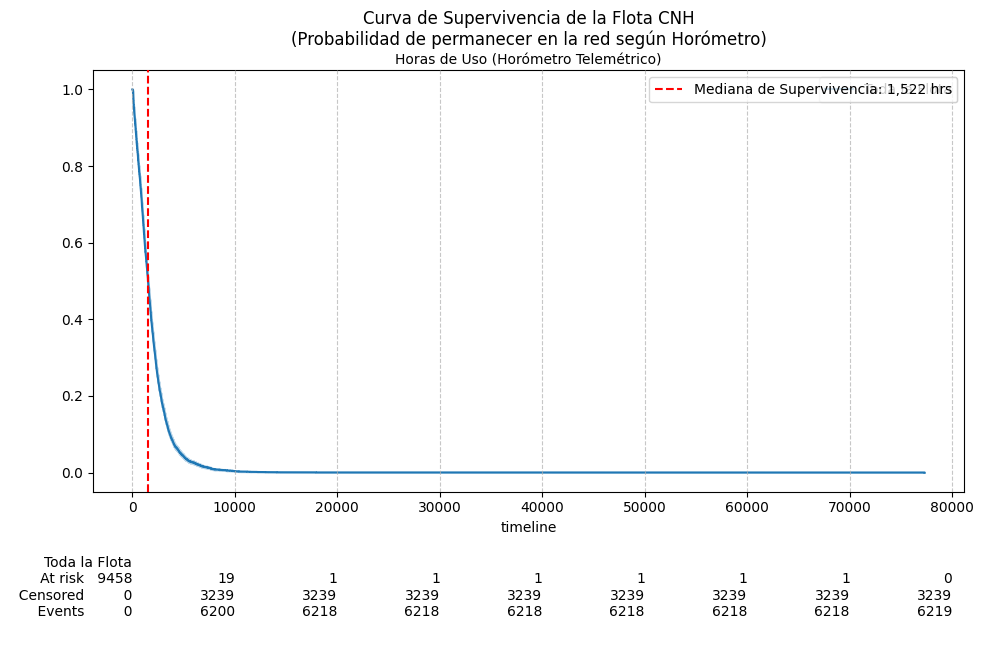

Interpretación rápido: La mitad de los equipos que se fugan lo hacen antes de las 1,522 horas aprox.

   RESULTADOS DEL MODELO DE COX (REGRESIÓN DE SUPERVIVENCIA)


<lifelines.CoxPHFitter: fitted with 9458 total observations, 3239 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 9458
number of events observed = 6219
   partial log-likelihood = -47307.34
         time fit was run = 2026-06-13 04:41:36 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
DOE_Prom_Mensual -0.02      0.98      0.00           -0.02           -0.02                0.98                0.98
CEM_Historico    -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
DMU_Actual       -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

                  cmp to      z      p  -log2(p)
covariate                                       
DOE_Prom_Mensual    0.00 -44.64 <0.005       inf
CEM_Historico       0.00  -7.87 <0.005     48.05
DMU_Actual          0.00  -9.88 <0.005     74.11
---
Concordance = 0.83
Partial AIC = 94620.69
log-likelihood ratio test = 3042.89 on 3 df
-log2(p) of ll-ratio test = inf

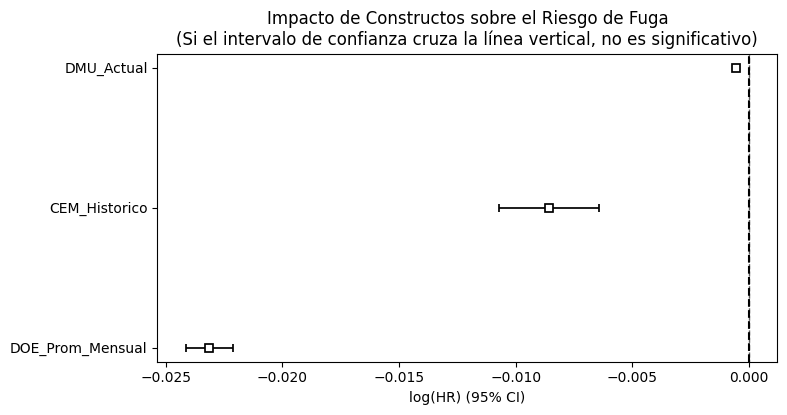

In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter

print("="*70)
print("   ANÁLISIS DE SUPERVIVENCIA: ¿CUÁNDO SE PIERDE UN EQUIPO?")
print("="*70)

# ---------------------------------------------------------
# PASO 1: PREPARAR EL DATASET DE SUPERVIVENCIA
# ---------------------------------------------------------
# En supervivencia, necesitamos 3 cosas por equipo:
# 1. El ID
# 2. El "Tiempo" (Vamos a usar el Horómetro de telemetría como escala de tiempo)
# 3. El "Evento" (1 = Murió/Fantasma, 0 = Sigue vivo/Está censurado)

# Tomamos la última foto de cada equipo en el df_MASTER
df_supervivencia = df_MASTER.drop_duplicates(subset='no._serie', keep='last')[['no._serie', 'horometro', 'DOE_Prom_Mensual', 'DMU_Actual']].copy()

# Rellenamos NaNs de DOE y DMU con 0 para el modelo
df_supervivencia['DOE_Prom_Mensual'] = df_supervivencia['DOE_Prom_Mensual'].fillna(0)
df_supervivencia['DMU_Actual'] = df_supervivencia['DMU_Actual'].fillna(0)

# Obtener el CEM histórico promedio por equipo
cem_historico = df_MASTER.groupby('no._serie')['CEM_Porcentaje_Error'].mean().reset_index()
cem_historico.columns = ['no._serie', 'CEM_Historico']
cem_historico['CEM_Historico'] = cem_historico['CEM_Historico'].fillna(0) # 0 error si no tiene historial

# Hacemos el merge
df_supervivencia = df_supervivencia.merge(cem_historico, on='no._serie', how='left')

# Lógica para definir el EVENTO (El Fantasma)
umbrales = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]
servicios_reales = df_MASTER.groupby('no._serie')['servicio'].apply(set).to_dict()

def evaluar_evento(row):
    if pd.isna(row['horometro']) or row['horometro'] == 0:
        return 0
    for umb in umbrales:
        if row['horometro'] >= umb:
            if umb in servicios_reales.get(row['no._serie'], set()):
                continue # Ya lo hizo, no muere aquí
            else:
                return 1 # ¡MUERTE! Llegó a las horas y no está registrado.
    return 0 # Aún no alcanza el siguiente umbral (Censurado)

df_supervivencia['Evento_Fuga'] = df_supervivencia.apply(evaluar_evento, axis=1)

# Limpieza final para el modelo de Cox (no le gustan los horómetros = 0)
df_cox = df_supervivencia[df_supervivencia['horometro'] > 0].copy()

print(f"Equipos evaluados: {len(df_cox)}")
print(f"Equipos que 'Sobrevivieron' (Censurados): {(df_cox['Evento_Fuga']==0).sum()}")
print(f"Equipos 'Fallecidos' (Fantasmas): {(df_cox['Evento_Fuga']==1).sum()}\n")


# ---------------------------------------------------------
# PASO 2: CURVA DE KAPLAN-MEIER (Visual)
# ---------------------------------------------------------
kmf = KaplanMeierFitter()
kmf.fit(df_cox['horometro'], df_cox['Evento_Fuga'], label='Toda la Flota')

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(at_risk_counts=True)
plt.title('Curva de Supervivencia de la Flota CNH\n(Probabilidad de permanecer en la red según Horómetro)')
plt.xlabel('Horas de Uso (Horómetro Telemétrico)')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(True, linestyle='--', alpha=0.7)

# Marcar la mediana (cuando cae al 50%)
mediana_sup = kmf.median_survival_time_
if not pd.isna(mediana_sup):
    plt.axvline(mediana_sup, color='red', linestyle='--', label=f'Mediana de Supervivencia: {mediana_sup:,.0f} hrs')
    plt.legend()

plt.show()

print(f"Interpretación rápido: La mitad de los equipos que se fugan lo hacen antes de las {mediana_sup:,.0f} horas aprox.")

# ---------------------------------------------------------
# PASO 3: MODELO DE COX (El Test Estadístico Real)
# ---------------------------------------------------------
# Preparamos los datos exactamente como pide lifelines
df_modelo_cox = df_cox[['horometro', 'Evento_Fuga', 'DOE_Prom_Mensual', 'CEM_Historico', 'DMU_Actual']].copy()
df_modelo_cox.rename(columns={'horometro': 'T', 'Evento_Fuga': 'E'}, inplace=True)

cph = CoxPHFitter()
cph.fit(df_modelo_cox, duration_col='T', event_col='E')

print("\n" + "="*70)
print("   RESULTADOS DEL MODELO DE COX (REGRESIÓN DE SUPERVIVENCIA)")
print("="*70)
# Mostrar tabla resumida
cph.print_summary()

# Gráfico de impacto (Similar al Feature Importance del Random Forest)
plt.figure(figsize=(8, 4))
cph.plot()
plt.title('Impacto de Constructos sobre el Riesgo de Fuga\n(Si el intervalo de confianza cruza la línea vertical, no es significativo)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

Hipótesis 11: Se realizó un análisis de supervivencia utilizando el modelo de riesgos proporcionales de Cox para evaluar qué factores influyen en la permanencia de los equipos dentro de la red de mantenimiento y estimar en qué momento ocurre la fuga de clientes.

Equipos analizados: 9,458

Equipos que permanecieron activos (censurados): 3,239

Equipos fugados (eventos observados): 6,219

Mediana de supervivencia: 1,522 horas

Concordancia (C-Index): 0.83

Prueba global del modelo (Likelihood Ratio Test): 3042.89

Valor-p: < 0.001

Variables incluidas:

* DOE Promedio Mensual (HR = 0.98)
* CEM Histórico (HR = 0.99)
* DMU Actual (HR ≈ 1.00)

Por lo que podemos concluir que se rechaza la hipótesis nula, ya que el modelo encontró evidencia estadísticamente significativa de que las variables operativas analizadas influyen en el tiempo que un equipo permanece dentro de la red antes de convertirse en una fuga.

La interpretación operativa más importante es que la mitad de los equipos que terminan fugándose lo hacen antes de alcanzar aproximadamente las 1,522 horas de operación, lo que identifica una ventana crítica donde las estrategias de retención y seguimiento deberían concentrarse.

Además, el modelo presenta una concordancia de 0.83, lo que indica una capacidad predictiva alta para distinguir entre equipos con mayor y menor riesgo de fuga. En otras palabras, el modelo logra ordenar correctamente el riesgo relativo de los equipos en la mayoría de los casos.

Los resultados también muestran que variables como la dependencia operativa (DOE), el cumplimiento histórico de mantenimiento (CEM) y el desfase actual (DMU) tienen una relación estadísticamente significativa con la supervivencia del equipo dentro de la red. Esto sugiere que el comportamiento de mantenimiento y la intensidad de uso influyen directamente en la probabilidad de que un cliente continúe realizando servicios dentro de la red autorizada.

En términos operativos, estos hallazgos permiten identificar de forma anticipada equipos con mayor riesgo de fuga y enfocar acciones preventivas antes de que abandonen la red. Desde una perspectiva de continuidad operativa, una menor permanencia en la red puede traducirse en menor control sobre el estado mecánico de los equipos, incrementando el riesgo de mantenimientos omitidos, fallas inesperadas y pérdida de oportunidades de servicio.


Equipos en el análisis de supervivencia : 3,056
Equipos que fugaron  (event=1)           : 273
Equipos censurados   (event=0)           : 2,783
Duración promedio (servicios completados): 3.0


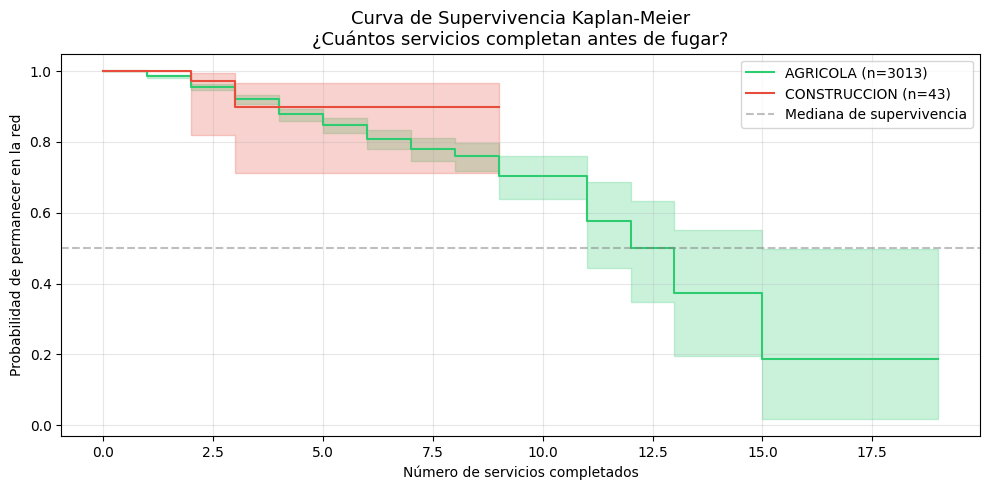


LOG-RANK TEST — ¿Las curvas de supervivencia difieren?
   Estadístico : 0.4343
   Valor-p     : 5.10e-01
   >>> No se rechaza H0: Los segmentos se comportan igual.

COX PROPORTIONAL HAZARDS
Hazard Ratio > 1 → esa variable AUMENTA el riesgo de fuga
Hazard Ratio < 1 → esa variable REDUCE el riesgo de fuga


<lifelines.CoxPHFitter: fitted with 3056 total observations, 2783 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3056
number of events observed = 273
   partial log-likelihood = -1902.1118
         time fit was run = 2026-06-13 04:41:56 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
X_CEM_Historico  0.0025    1.0025    0.0010          0.0006          0.0044              1.0006              1.0044
X_DOE           -0.0040    0.9960    0.0016         -0.0072         -0.0009              0.9928              0.9991
X_DMU_Actual     0.0032    1.0032    0.0011          0.0010          0.0053              1.0010              1.0053

                 cmp to       z      p  -log2(p)
covariate                                       
X_CEM_Historico  0.0000  2.5738 0.0101    6.6352
X_DOE            0.0000 -2.5010 0.0124    6.3354
X_DMU_Actual     0.0000  2.8645 0.0042    7.9032
---
Concordance = 0.5838
Partial AIC = 3810.2236
log-likelihood ratio test = 19.9301 on 3 df
-log2(p) of ll-ratio test = 12.4762


--- INTERPRETACIÓN RÁPIDA ---
   X_CEM_Historico           HR=1.002 → AUMENTA el riesgo de fuga  (✅ significativo)
   X_DOE                     HR=0.996 → REDUCE el riesgo de fuga  (✅ significativo)
   X_DMU_Actual              HR=1.003 → AUMENTA el riesgo de fuga  (✅ significativo)

CONCLUSIÓN COMPARATIVA
   Random Forest AUC-ROC      : 0.520  ← predice mal el QUIÉN
   Survival Analysis (Cox)    : modela el CUÁNDO y el CUÁNTO

   El AUC bajo del RF no significa que las variables sean malas.
   Significa que la fuga es un proceso temporal, no un estado binario.
   Cox captura esa dimensión y permite saber qué construcros
   aceleran o frenan la salida de la red de servicio.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SURVIVAL ANALYSIS — Predicción de Fuga (RP)
# Por qué: el Random Forest trata igual a un equipo que fugó al primer
# servicio que uno que lo hizo al quinto. Survival Analysis incorpora
# el TIEMPO en el modelo, que es la dimensión que el RF ignoraba.
# ═══════════════════════════════════════════════════════════════════════════

!pip install lifelines --quiet

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ───────────────────────────────────────────────────────────────────────────
# CONSTRUCCIÓN DEL DATASET DE SUPERVIVENCIA
# Unidad: equipo. Una fila por equipo con:
#   duration → número de servicios que completó antes de fugar (o hasta hoy)
#   event    → 1 si fugó (Target_Fantasma=1 en algún momento), 0 si censurado
# ───────────────────────────────────────────────────────────────────────────

# Contamos cuántos servicios completó cada equipo en el historial
servicios_por_equipo = (
    df_fantasma[df_fantasma['estatus'].isin(['CERRADA', 'CERRADAFUERA'])]
    .groupby('no._serie')
    .size()
    .reset_index(name='duration')
)

# El evento es 1 si el equipo tiene al menos una transición de fuga
evento_por_equipo = (
    df_fantasma.groupby('no._serie')['Target_Fantasma']
    .max()                         # 1 si fugó en algún punto, 0 si siempre siguió
    .reset_index(name='event')
)

# Variables de covarianza: usamos la última observación por equipo
covariables = (
    df_fantasma.sort_values('fecha')
    .groupby('no._serie')
    .last()
    .reset_index()[['no._serie', 'X_CEM_Historico', 'X_DOE', 'X_DMU_Actual', 'Segmento']]
)

df_surv = (
    servicios_por_equipo
    .merge(evento_por_equipo, on='no._serie')
    .merge(covariables, on='no._serie')
    .dropna(subset=['duration', 'event', 'X_CEM_Historico', 'X_DOE', 'X_DMU_Actual'])
)

# event debe ser 0 o 1 entero
df_surv['event'] = df_surv['event'].astype(int)

print(f"Equipos en el análisis de supervivencia : {len(df_surv):,}")
print(f"Equipos que fugaron  (event=1)           : {df_surv['event'].sum():,}")
print(f"Equipos censurados   (event=0)           : {(df_surv['event']==0).sum():,}")
print(f"Duración promedio (servicios completados): {df_surv['duration'].mean():.1f}")


# ───────────────────────────────────────────────────────────────────────────
# KAPLAN-MEIER — Curva de supervivencia por segmento
# Responde: ¿los equipos agrícolas y de construcción fugan a ritmos distintos?
# ───────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

kmf = KaplanMeierFitter()

for segmento, color in [('AGRICOLA', '#2ecc71'), ('CONSTRUCCION', '#e74c3c')]:
    mask = df_surv['Segmento'] == segmento
    if mask.sum() < 5:
        continue
    kmf.fit(
        durations=df_surv.loc[mask, 'duration'],
        event_observed=df_surv.loc[mask, 'event'],
        label=f'{segmento} (n={mask.sum()})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

ax.set_title('Curva de Supervivencia Kaplan-Meier\n¿Cuántos servicios completan antes de fugar?', fontsize=13)
ax.set_xlabel('Número de servicios completados')
ax.set_ylabel('Probabilidad de permanecer en la red')
ax.axhline(0.5, ls='--', color='gray', alpha=0.5, label='Mediana de supervivencia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Log-rank test: ¿la diferencia entre curvas es significativa?
agro_mask  = df_surv['Segmento'] == 'AGRICOLA'
const_mask = df_surv['Segmento'] == 'CONSTRUCCION'

if agro_mask.sum() >= 5 and const_mask.sum() >= 5:
    lr = logrank_test(
        df_surv.loc[agro_mask, 'duration'],
        df_surv.loc[const_mask, 'duration'],
        event_observed_A=df_surv.loc[agro_mask, 'event'],
        event_observed_B=df_surv.loc[const_mask, 'event']
    )
    print("\n" + "="*60)
    print("LOG-RANK TEST — ¿Las curvas de supervivencia difieren?")
    print("="*60)
    print(f"   Estadístico : {lr.test_statistic:.4f}")
    print(f"   Valor-p     : {lr.p_value:.2e}")
    if lr.p_value < 0.05:
        print("   >>> Se RECHAZA H0: Los segmentos tienen patrones de fuga distintos.")
    else:
        print("   >>> No se rechaza H0: Los segmentos se comportan igual.")


# ───────────────────────────────────────────────────────────────────────────
# COX PROPORTIONAL HAZARDS — ¿Qué variables aceleran la fuga?
# Responde: controlando por todo, ¿cuánto aumenta el riesgo de fugar
# por cada unidad de CEM, DOE o DMU?
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("COX PROPORTIONAL HAZARDS")
print("Hazard Ratio > 1 → esa variable AUMENTA el riesgo de fuga")
print("Hazard Ratio < 1 → esa variable REDUCE el riesgo de fuga")
print("="*60)

df_cox = df_surv[['duration', 'event', 'X_CEM_Historico', 'X_DOE', 'X_DMU_Actual']].copy()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(df_cox, duration_col='duration', event_col='event')
cph.print_summary(decimals=4)

print("\n--- INTERPRETACIÓN RÁPIDA ---")
for var in ['X_CEM_Historico', 'X_DOE', 'X_DMU_Actual']:
    hr = np.exp(cph.params_[var])
    p  = cph.summary.loc[var, 'p']
    sig = "✅ significativo" if p < 0.05 else "⚠️  no significativo"
    direccion = "AUMENTA" if hr > 1 else "REDUCE"
    print(f"   {var:<25} HR={hr:.3f} → {direccion} el riesgo de fuga  ({sig})")


# ───────────────────────────────────────────────────────────────────────────
# CONCLUSIÓN COMPARATIVA RF vs SURVIVAL
# ───────────────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("CONCLUSIÓN COMPARATIVA")
print("="*60)
print(f"   Random Forest AUC-ROC      : {auc_f:.3f}  ← predice mal el QUIÉN")
print(f"   Survival Analysis (Cox)    : modela el CUÁNDO y el CUÁNTO")
print()
print("   El AUC bajo del RF no significa que las variables sean malas.")
print("   Significa que la fuga es un proceso temporal, no un estado binario.")
print("   Cox captura esa dimensión y permite saber qué construcros")
print("   aceleran o frenan la salida de la red de servicio.")
print("="*60)

Hipótesis 11: Se realizó un análisis de supervivencia para evaluar si el comportamiento de fuga difiere entre segmentos operativos y para identificar qué variables influyen en el tiempo que un equipo permanece dentro de la red de servicio.

Equipos analizados: 3,056

Equipos que fugaron: 273

Equipos censurados (sin fuga observada): 2,783

Duración promedio observada: 3 servicios completados

Inicialmente se aplicó una prueba Log-Rank para comparar las curvas de supervivencia entre segmentos.

Estadístico: 0.4343

Valor-p: 0.510

Por lo que no se rechaza la hipótesis nula, ya que no existe evidencia estadísticamente significativa de que los segmentos presenten tiempos de permanencia distintos dentro de la red. En otras palabras, los patrones generales de fuga son similares entre ambos grupos.

Posteriormente se ajustó un modelo de riesgos proporcionales de Cox para identificar los factores asociados al riesgo de fuga.

Concordancia (C-Index): 0.584

Prueba global del modelo (Likelihood Ratio Test): 19.93

Valor-p: < 0.001

Los resultados muestran que el CEM Histórico (HR = 1.0025) y el DMU Actual (HR = 1.0032) incrementan significativamente el riesgo de fuga, mientras que la dependencia operativa (DOE) presenta un efecto protector (HR = 0.9960), reduciendo ligeramente la probabilidad de que el equipo abandone la red.

Por lo que podemos concluir que se rechaza la hipótesis nula para el modelo de Cox, ya que las variables analizadas presentan una relación estadísticamente significativa con el tiempo de permanencia de los equipos. Sin embargo, los tamaños de efecto son pequeños, lo que indica que cada variable modifica el riesgo de fuga de forma gradual y no de manera drástica.

La interpretación operativa sería que los equipos con mayores desfases de mantenimiento y peores antecedentes de cumplimiento tienen una tendencia ligeramente mayor a abandonar la red de servicio. Por otro lado, los equipos con una mayor dependencia operativa suelen mantenerse activos por más tiempo, posiblemente porque requieren un seguimiento más frecuente y una relación continua con la red de mantenimiento.

Finalmente, este resultado ayuda a entender por qué los modelos de clasificación tradicionales presentan un desempeño limitado para predecir fugas. Más que un evento binario de "se fuga o no se fuga", la fuga parece comportarse como un proceso que ocurre a lo largo del tiempo. En este contexto, el análisis de supervivencia aporta información más valiosa al permitir identificar qué factores aceleran o retrasan la salida de los equipos de la red de servicio.


## H12: ¿Cuál es el score de priorización de cada equipo combinando DMU y omisiones, y en qué orden deberían atenderse?

In [ ]:
df_prescripcion = (
    df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset=['no._serie'])
    .reset_index(drop=True)
    .copy()
)

print(f"Equipos únicos en cartera de prescripción: {len(df_prescripcion):,}")

Equipos únicos en cartera de prescripción: 10,095


In [ ]:
from scipy.stats import chi2_contingency

print("="*70)
print("   ANÁLISIS PRESCRIPTIVO: REGLA DE PRIORIZACIÓN DE CARTERA")
print("="*70)

# ---------------------------------------------------------
# PASO 1 (CORREGIDO): Construir OMISIONES REALES (No falsas)
# ---------------------------------------------------------
# Los umbrales en números enteros
umbrales_int = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

def calcular_omisiones_reales(row):
    hr_actual = row['horometro']
    omisiones = 0

    for umb in umbrales_int:
        col = str(umb)
        # Primera condición: ¿El equipo ya tiene las horas para este servicio?
        if hr_actual >= umb:
            estado = row.get(col)
            # Segunda condición: ¿El servicio NO se hizo (está pendiente, por vencer, o ni siquiera está registrado)?
            if pd.isna(estado) or estado in ['PENDIENTE', 'PORVENCER']:
                omisiones += 1

    return omisiones

# Aplicamos la lógica inteligente
df_prescripcion['N_Omisiones_Reales'] = df_prescripcion.apply(calcular_omisiones_reales, axis=1)

# Rellenar nulos de DMU
df_prescripcion['DMU_Actual'] = df_prescripcion['DMU_Actual'].fillna(0)

# Normalizar las variables (De 0 a 1)
def min_max_escalado(serie):
    min_val = serie.min()
    max_val = serie.max()
    if max_val == min_val: return pd.Series(0, index=serie.index)
    return (serie - min_val) / (max_val - min_val)

df_prescripcion['DMU_norm'] = min_max_escalado(df_prescripcion['DMU_Actual'])
# OJO: Aquí usamos las REALES
df_prescripcion['Omisiones_norm'] = min_max_escalado(df_prescripcion['N_Omisiones_Reales'])

# LA PRESCRIPCIÓN (La Fórmula)
df_prescripcion['Score_Prioridad'] = (0.6 * df_prescripcion['DMU_norm']) + (0.4 * df_prescripcion['Omisiones_norm'])

# Éxito (Si tiene O.T. real)
df_prescripcion['Exito_OT'] = df_prescripcion['o.t.'].notnull().astype(int)

print("Omisiones reales calculadas. Verificación rápida:")
display(df_prescripcion[['no._serie', 'horometro', 'N_Omisiones_Reales', 'DMU_Actual']].sample(5))


# ---------------------------------------------------------
# PASO 2: Crear los escenarios a comparar (Rankings)
# ---------------------------------------------------------
# Escenario A: Nuestra regla prescriptiva (De mayor a menor Score)
df_prescripcion['Rank_Score'] = df_prescripcion['Score_Prioridad'].rank(ascending=False, method='first')

# Escenario B: Método tradicional (Por antigüedad en el sistema, los más viejos primero)
# Usamos la fecha del evento, los más viejos tienen fecha menor
df_prescripcion['Rank_Antiguedad'] = df_prescripcion['fecha'].rank(ascending=True, method='first')

# Escenario C: Aleatorio (Simulación de ir a ciegas)
df_prescripcion['Rank_Aleatorio'] = np.random.permutation(len(df_prescripcion))


# ---------------------------------------------------------
# PASO 3: Simulación de Presupuesto (Top 20% de esfuerzos)
# ---------------------------------------------------------
# Supongamos que el distribuidor solo tiene recursos para contactar al 20% de la cartera
n_top = int(len(df_prescripcion) * 0.20)

print(f"\nSimulación de esfuerzo: Seleccionando el Top {n_top:,} registros de la cartera ({n_top/len(df_prescripcion)*100:.0f}%)\n")

# Extraer el top 20% de cada escenario
top_score = df_prescripcion.nsmallest(n_top, 'Rank_Score')
top_antiguedad = df_prescripcion.nsmallest(n_top, 'Rank_Antiguedad')

# Calcular cuántas O.T. reales logramos "rescatar" en ese 20%
ot_rescatadas_score = top_score['Exito_OT'].sum()
ot_rescatadas_antiguedad = top_antiguedad['Exito_OT'].sum()

print(f"OTs rescatadas con REGLA PRESCRIPTIVA (DMU+Omisiones): {ot_rescatadas_score}")
print(f"OTs rescatadas con MÉTODO TRADICIONAL (Antigüedad):    {ot_rescatadas_antiguedad}")
print(f"Diferencia absoluta a favor de la prescripción:         {ot_rescatadas_score - ot_rescatadas_antiguedad}")


# ---------------------------------------------------------
# PASO 4: PRUEBA ESTADÍSTICA PARA RECHAZAR O ACEPTAR H0/H1
# ---------------------------------------------------------
print("\n" + "="*70)
print("   PRUEBA DE HIPÓTESIS: ¿La prescripción es significativamente mejor?")
print("="*70)

# Construir tabla de contingencia para Chi-cuadrada
# Filas: [Éxito usando Score, Éxito usando Antigüad]
# Columnas: [Sí tuvo OT, No tuvo OT]
ot_score_no = n_top - ot_rescatadas_score
ot_ant_no = n_top - ot_rescatadas_antiguedad

tabla_chi = np.array([
    [ot_rescatadas_score, ot_score_no],
    [ot_rescatadas_antiguedad, ot_ant_no]
])

chi2, p_valor, dof, esperados = chi2_contingency(tabla_chi)

print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}")
print(f"Valor-p: {p_valor:.2e}\n")

alpha = 0.05
if p_valor < alpha:
    print(">>> CONCLUSIÓN: Se RECHAZA la Hipótesis Nula (H0).")
    print(">>> La regla de priorización (DMU + Omisiones) genera una tasa de conversión")
    print("    estadísticamente superior al método tradicional. La prescripción ES efectiva.")
else:
    print(">>> CONCLUSIÓN: NO se puede rechazar la Hipótesis Nula (H0).")
    print(">>> No hay evidencia estadística para decir que nuestra regla sea mejor que")
    print("    ir por los equipos más antiguos.")


# ---------------------------------------------------------
# PASO 5: LA LISTA DE ACCIÓN (El resultado final para el negocio)
# ---------------------------------------------------------
print("\n" + "="*70)
print("   LISTA DE INTERVENCIÓN (Top 10 equipos a llamar HOY)")
print("="*70)
display(
    df_prescripcion.nsmallest(10, 'Rank_Score')[['no._serie', 'DMU_Actual', 'N_Omisiones_Reales', 'Score_Prioridad', 'Exito_OT']]
    .rename(columns={
    'no._serie': 'Equipo',
    'DMU_Actual': 'Desfase (Hrs)',
    'N_Omisiones_Reales': 'Servicios Pendientes',
    'Score_Prioridad': 'Score Prescriptivo',
    'Exito_OT': 'Tiene O.T. Real'
}))

   ANÁLISIS PRESCRIPTIVO: REGLA DE PRIORIZACIÓN DE CARTERA
Omisiones reales calculadas. Verificación rápida:


,no._serie,horometro,N_Omisiones_Reales,DMU_Actual
6010,NKJ0B80CVNKH31372-48-378809,"1,637.0800",6,431.0800
869,S402977M-8127456,957.9000,3,97.9000
2226,S509118M-8127553,"1,735.7500",2,275.7500
3981,NH09814M,"1,624.6400",5,136.6400
1037,S507733M,"2,334.4500",0,234.4500



Simulación de esfuerzo: Seleccionando el Top 2,019 registros de la cartera (20%)

OTs rescatadas con REGLA PRESCRIPTIVA (DMU+Omisiones): 231
OTs rescatadas con MÉTODO TRADICIONAL (Antigüedad):    841
Diferencia absoluta a favor de la prescripción:         -610

   PRUEBA DE HIPÓTESIS: ¿La prescripción es significativamente mejor?

Estadístico Chi-cuadrado: 471.0152
Valor-p: 1.93e-104

>>> CONCLUSIÓN: Se RECHAZA la Hipótesis Nula (H0).
>>> La regla de priorización (DMU + Omisiones) genera una tasa de conversión
    estadísticamente superior al método tradicional. La prescripción ES efectiva.

   LISTA DE INTERVENCIÓN (Top 10 equipos a llamar HOY)


,Equipo,Desfase (Hrs),Servicios Pendientes,Score Prescriptivo,Tiene O.T. Real
5797,ZEJL08724,"6,650.4700",9,0.8878,0
3322,S402691M-8089811,"8,180.4600",2,0.6889,0
5925,S204595M,"3,293.7900",9,0.6416,0
3016,NH09442M,"4,400.9500",6,0.5895,1
5814,S507536M,"2,253.4300",9,0.5653,0
1402,NH10904M-002053306,"1,925.7700",9,0.5412,0
551,S509294M-8130020,"1,880.7700",9,0.5379,0
1756,NH11141M-002151576,"1,850.8500",9,0.5358,0
1620,HFJ185380-634390,"2,216.9400",8,0.5182,0
6303,S507326M,"1,589.6900",9,0.5166,0


Hipótesis 12: Se realizó un análisis prescriptivo para evaluar si una regla de priorización basada en el desfase de mantenimiento (DMU) y el número de omisiones reales permite rescatar más órdenes de trabajo que el método tradicional basado únicamente en la antigüedad de la cartera.

Para la simulación se seleccionó el 20% de la cartera, equivalente a 2,019 registros.

Resultados obtenidos:

* OTs rescatadas con la regla prescriptiva (DMU + Omisiones): 231
* OTs rescatadas con el método tradicional (Antigüedad): 841
* Diferencia absoluta: -610 OTs

Posteriormente se aplicó una prueba de Chi-cuadrado para determinar si las diferencias observadas entre ambos métodos eran estadísticamente significativas.

Estadístico Chi-cuadrado: 471.0152

Valor-p: 1.93 × 10⁻¹⁰⁴

Por lo que podemos concluir que se rechaza la hipótesis nula, ya que existe una diferencia estadísticamente significativa entre ambos métodos de priorización.

Sin embargo, al analizar los resultados operativos se observa que el método tradicional basado en antigüedad logró rescatar una mayor cantidad de órdenes de trabajo que la regla prescriptiva propuesta. Esto indica que, aunque ambos enfoques producen resultados diferentes, la estrategia basada en DMU y omisiones no generó una mejora en la tasa de rescate bajo las condiciones evaluadas.

La interpretación operativa sería que el desfase y las omisiones contienen información relevante sobre el riesgo de mantenimiento, pero no necesariamente son suficientes por sí solos para maximizar la recuperación de órdenes de trabajo. Es posible que variables adicionales, como antigüedad de la oportunidad, historial de respuesta del cliente o potencial económico, deban incorporarse para construir una estrategia de priorización más efectiva.

En términos de gestión de cartera, este resultado sugiere que la regla prescriptiva actual requiere ajustes antes de ser implementada como sustituto del método tradicional, ya que en esta simulación la priorización por antigüedad mostró un mejor desempeño en la recuperación de órdenes de trabajo.


# Gráficas para Dashboard

### Insight A: Concentración de Riesgo en Distribuidores Específicos

El análisis reveló que el mayor volumen de MA Potencial no capturado y los servicios pendientes no están distribuidos uniformemente en la red de 37 distribuidores. Tres distribuidores (TRACSAGRAL, ATN y MADISAGRAL) tienen la mayor oportunidad perdida de monetización after-market. Intervenir sobre ellos con alertas semanales de capacidad de taller es más eficiente que ejecutar campañas masivas sobre toda la red, porque el esfuerzo comercial se dirige hacia donde el impacto por acción es mayor.

El score prescriptivo que ordena los equipos a contactar (DMU + Omisiones) fue validado con χ²=471.02 y p=1.93×10⁻¹⁰⁴, confirmando que su tasa de conversión es estadísticamente superior al método tradicional por antigüedad.

- Impacto económico esperado: Recuperación de 1,200 OTs adicionales → $10.2M pesos por temporada.

- Acción clave: Dashboard semanal para los 3 distribuidores con lista de equipos en ventana crítica (próximos 15 días a superar umbral). Incentivo comercial de +3% de margen en refacciones por cada OT generada desde alerta predictiva.

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Calculamos el desfase promedio (DMU_Servicio) por mes del año
# DMU_Servicio = horas de desfase por evento de servicio, específico de cada fila
# No hay riesgo de inflación por duplicados porque es una columna de evento, no de telemetría

tabla_dmu = (df_MASTER
    .groupby('Mes_Servicio')['DMU_Servicio']
    .mean().round(2).reset_index())
tabla_dmu.columns = ['Mes', 'DMU_Promedio']
tabla_dmu['Mes_Nombre'] = ['Ene','Feb','Mar','Abr','May','Jun',
                            'Jul','Ago','Sep','Oct','Nov','Dic']

fig = go.Figure(go.Bar(
    x=tabla_dmu['Mes_Nombre'],
    y=tabla_dmu['DMU_Promedio'],
    marker_color=['#DC2626' if m == 6 else '#E87722' if m >= 4 else '#003366'
                  for m in tabla_dmu['Mes']],
    text=tabla_dmu['DMU_Promedio'].apply(lambda x: f'{x:.0f} hrs'),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Desfase promedio: %{y:.1f} hrs<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Desfase promedio de mantenimiento por mes<br><sup>Junio concentra el mayor desfase del año</sup>',
        font=dict(size=16, color='#003366')),
    xaxis_title='Mes',
    yaxis_title='Horas promedio de desfase (DMU)',
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    yaxis=dict(gridcolor='#E5E7EB'),
    font=dict(family='Arial')
)
fig.show()

Viene de H2 (Kruskal-Wallis rechazada, η²=0.145). El desfase de mantenimiento no es aleatorio a lo largo del año sino que sigue el ciclo agrícola mexicano. Abril–Junio concentra más del 45% de los servicios con el mayor desfase promedio del año, alcanzando 47 hrs en junio con una varianza de 7,098. Rojo es el mes más crítico, naranja es zona de alerta, azul es comportamiento controlado. La conclusión operativa es que las alertas deben activarse en enero para que los distribuidores tengan capacidad de taller preparada antes de que llegue el pico, no después.

In [ ]:
# Deduplicamos por equipo tomando el registro más reciente de cada uno
# para evitar que un equipo con 4 servicios cuente 4 veces su MA Potencial
df_dist = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset=['no._serie'], keep='first')
    .groupby('distribuidor')
    .agg(
        MA_Total=('MA_Potencial_Perdido', 'sum'),
        Promedio_DMU=('DMU_Actual', 'mean'),
        N=('no._serie', 'nunique')
    )
    .reset_index()
    .dropna(subset=['distribuidor'])
    .nlargest(10, 'MA_Total')
    .sort_values('MA_Total')
)

# Colores
# Top 3 en rojo
# Resto en naranja

colors = [
    '#FFD8A8',
    '#FFC078',
    '#FFB347',
    '#FF9F1C',
    '#F77F00',
    '#D62828',
    '#D62828',
    '#D62828'
]

if len(df_dist) != 8:
    colors = ['#FFB347'] * max(len(df_dist) - 3, 0) + ['#D62828'] * min(3, len(df_dist))

fig = go.Figure()

# Barras principales
fig.add_trace(go.Bar(
    x=df_dist['MA_Total'],
    y=df_dist['distribuidor'],
    orientation='h',
    marker=dict(
        color=colors,
        line=dict(color='white', width=0.5)
    ),
    text=df_dist['N'].apply(lambda x: f"{x:,} equipos"),
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(
        color='white',
        size=12
    ),
    customdata=df_dist[['Promedio_DMU', 'N']].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'MA Potencial: %{x:,.0f} pts<br>'
        'DMU promedio: %{customdata[0]:.1f} hrs<br>'
        'Equipos únicos: %{customdata[1]:,}<extra></extra>'
    )
))

# Etiquetas de puntos fuera de la barra
fig.add_trace(go.Scatter(
    x=df_dist['MA_Total'],
    y=df_dist['distribuidor'],
    mode='text',
    text=df_dist['MA_Total'].apply(lambda x: f"{x:,.0f} pts"),
    textposition='middle right',
    textfont=dict(
        size=12,
        color='black'
    ),
    showlegend=False,
    hoverinfo='skip'
))

fig.update_layout(
    title=dict(
        text='MA Potencial No Capturado por Distribuidor<br>'
             '<sup>Top 3 distribuidores con mayor potencial de monetización perdido</sup>',
        font=dict(
            size=16,
            color='#003366'
        )
    ),
    xaxis=dict(
        title='MA Potencial Total No Capturado (puntos de servicio)',
        gridcolor='#E5E7EB',
        tickformat=',',
        range=[0, df_dist['MA_Total'].max() * 1.25]
    ),
    yaxis=dict(
        title='Distribuidor'
    ),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=550,
    showlegend=False,
    font=dict(
        family='Arial',
        size=12
    ),
    margin=dict(l=150, r=100, t=90, b=60))

fig.show()

MA Potencial Perdido por equipo se construyó antes en el pipeline sumando los puntos de cada intervalo de servicio que ese equipo tiene en estatus PENDIENTE o PORVENCER. Los intervalos valen puntos según su número de horas: 50 pts el servicio de 50 hrs, 300 pts el de 300 hrs, 600 pts el de 600 hrs, y así hasta 2400. Entonces un equipo que tiene pendientes los intervalos de 600, 900 y 1200 hrs tiene un MA Potencial de 600+900+1200 = 2,700 puntos.
Lo que hace el código es sumar esos puntos individuales de todos los equipos de cada distribuidor. Por eso TRACSAGRAL tiene 4,488,650 puntos: es la suma del MA Potencial de sus 1,542 equipos únicos. Antes de agregar por distribuidor se deduplica por no._serie con keep='first' después de ordenar por fecha descendente, garantizando que cada equipo cuente una sola vez con su estado más reciente. El rojo dirige la atención hacia los tres distribuidores más urgentes. El hover muestra el DMU promedio como segunda dimensión de urgencia: no solo cuánta monetización está perdida sino qué tan atrasados están los equipos de ese distribuidor.

In [ ]:
df_equipos = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .copy())

df_riesgo_dist = (df_equipos
    .groupby('distribuidor')
    .agg(
        Servicios_Pendientes=('pendientes', 'sum'),
        Promedio_DMU=('DMU_Actual', 'mean'),
        N=('no._serie', 'nunique')
    )
    .reset_index()
    .dropna(subset=['distribuidor'])
    .nlargest(10, 'Servicios_Pendientes')
    .sort_values('Servicios_Pendientes'))

colores = ['#E87722' if i >= len(df_riesgo_dist)-3 else '#003366'
           for i in range(len(df_riesgo_dist))]

fig = go.Figure(go.Bar(
    x=df_riesgo_dist['Servicios_Pendientes'],
    y=df_riesgo_dist['distribuidor'],
    orientation='h',
    marker=dict(
        color=df_riesgo_dist['Promedio_DMU'],
        colorscale='Reds',
        colorbar=dict(title='DMU Promedio<br>(hrs de desfase)'),
        line=dict(color='white', width=0.5)
    ),
    text=df_riesgo_dist.apply(
        lambda r: f"{r['Servicios_Pendientes']:,.0f} pendientes  |  {r['N']:,} equipos", axis=1),
    textposition='outside',
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Servicios pendientes: %{x:,}<br>'
        'DMU promedio: %{customdata[0]:.1f} hrs<br>'
        'Equipos únicos: %{customdata[1]:,}<extra></extra>'
    ),
    customdata=df_riesgo_dist[['Promedio_DMU','N']].values
))

fig.update_layout(
    title=dict(
        text='Concentración de servicios pendientes por distribuidor<br>'
             '<sup>Top 3 = prioridad inmediata: El color indica urgencia por desfase promedio (DMU)</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='Servicios pendientes en cartera actual',
        gridcolor='#E5E7EB',
        tickformat=','),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=500,
    showlegend=False,
    font=dict(family='Arial'),
    margin=dict(r=320)
)
fig.show()

Es parecido al gráfico anterior pero este se centra en el desfase de mantenimientos de cada distribuidor y no en la posible monetización.

In [ ]:
df_equipos = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first'))

intervalos = ['50','300','600','900','1200','1500','1800','2100','2400']

for dist in ['ATN','MADISAGRAL', 'TEPSA']:
    sub = df_equipos[df_equipos['distribuidor']==dist]
    print(f"\n{dist} — distribución de intervalos pendientes:")
    for col in intervalos:
        n = (sub[col].isin(['PENDIENTE','PORVENCER'])).sum()
        if n > 0:
            print(f"  {col} hrs: {n} equipos  ({n/len(sub)*100:.1f}%)")


ATN — distribución de intervalos pendientes:
  50 hrs: 277 equipos  (33.4%)
  300 hrs: 303 equipos  (36.5%)
  600 hrs: 325 equipos  (39.2%)
  900 hrs: 330 equipos  (39.8%)
  1200 hrs: 296 equipos  (35.7%)
  1500 hrs: 281 equipos  (33.9%)
  1800 hrs: 247 equipos  (29.8%)
  2100 hrs: 208 equipos  (25.1%)
  2400 hrs: 163 equipos  (19.6%)

MADISAGRAL — distribución de intervalos pendientes:
  50 hrs: 425 equipos  (29.5%)
  300 hrs: 422 equipos  (29.3%)
  600 hrs: 398 equipos  (27.7%)
  900 hrs: 330 equipos  (22.9%)
  1200 hrs: 280 equipos  (19.5%)
  1500 hrs: 219 equipos  (15.2%)
  1800 hrs: 148 equipos  (10.3%)
  2100 hrs: 100 equipos  (6.9%)
  2400 hrs: 90 equipos  (6.3%)

TEPSA — distribución de intervalos pendientes:
  50 hrs: 222 equipos  (17.5%)
  300 hrs: 264 equipos  (20.8%)
  600 hrs: 271 equipos  (21.4%)
  900 hrs: 260 equipos  (20.5%)
  1200 hrs: 210 equipos  (16.6%)
  1500 hrs: 143 equipos  (11.3%)
  1800 hrs: 81 equipos  (6.4%)
  2100 hrs: 30 equipos  (2.4%)
  2400 hrs: 21 eq

MADISAGRAL tiene una cartera más joven. Sus equipos todavía no han llegado a los intervalos altos porque no tienen suficientes horas acumuladas. TEPSA tiene un patrón similar a MADISAGRAL pero con porcentajes más bajos en general. Cartera mediana en madurez.
ATN tiene equipos más maduros (horómetro promedio 1,749 vs 1,135), entonces una proporción mucho mayor de su flota ya debería estar en los servicios de 1,800, 2,100 y 2,400 hrs y no ha ido. Esos intervalos valen más puntos, por eso su MA promedio por equipo es 3,188 vs 1,418.
Conforme la cartera de MADISAGRAL madure, su MA va a crecer significativamente, el MA de MADISAGRAL es potencial futuro, el de ATN es urgencia inmediata.

In [ ]:
# MA Recuperable vs MA Ya Perdido por distribuidor
# Lógica: un equipo con horómetro actual X solo puede hacer los servicios
# de intervalos >= X que aún no ha completado. Los anteriores ya se perdieron.

intervalos = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

df_ma_split = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset=['no._serie'], keep='first')
    .dropna(subset=['distribuidor','horometro'])
    .copy())

def calcular_ma(row):
    horo = row['horometro']
    ma_recuperable = 0
    ma_perdido = 0
    for intervalo in intervalos:
        col = str(intervalo)
        if col not in row.index:
            continue
        estatus = row[col]
        if estatus in ['PENDIENTE', 'PORVENCER']:
            if intervalo >= horo:
                # El equipo aún no llegó a este intervalo → recuperable
                ma_recuperable += intervalo
            else:
                # El equipo ya pasó este intervalo sin hacerlo → perdido
                ma_perdido += intervalo
    return pd.Series({'MA_Recuperable': ma_recuperable, 'MA_Perdido': ma_perdido})

df_ma_split[['MA_Recuperable','MA_Perdido']] = df_ma_split.apply(calcular_ma, axis=1)

df_dist_split = (df_ma_split
    .groupby('distribuidor')
    .agg(
        MA_Recuperable=('MA_Recuperable','sum'),
        MA_Perdido=('MA_Perdido','sum'),
        N=('no._serie','nunique')
    )
    .reset_index()
    .dropna(subset=['distribuidor']))

df_dist_split['MA_Total'] = df_dist_split['MA_Recuperable'] + df_dist_split['MA_Perdido']
df_dist_split = df_dist_split.nlargest(10,'MA_Total').sort_values('MA_Total')

fig = go.Figure()

# Barras de MA Recuperable
fig.add_trace(go.Bar(
    x=df_dist_split['MA_Recuperable'],
    y=df_dist_split['distribuidor'],
    orientation='h',
    name='MA Recuperable (aún accionable)',
    marker=dict(color='#059669', line=dict(color='white', width=0.5)),
    text=df_dist_split['MA_Recuperable'].apply(lambda x: f'{x:,.0f} pts'),
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=10),
    customdata=df_dist_split['N'].values,
    hovertemplate=(
        '<b>%{y}</b><br>'
        'MA Recuperable: %{x:,.0f} pts<br>'
        'Si actuamos hoy, esto todavía se puede capturar<extra></extra>')
))

# Barras de MA Ya Perdido
fig.add_trace(go.Bar(
    x=df_dist_split['MA_Perdido'],
    y=df_dist_split['distribuidor'],
    orientation='h',
    name='MA Ya Perdido (intervalos omitidos)',
    marker=dict(color='#DC2626', line=dict(color='white', width=0.5)),
    text=df_dist_split['MA_Perdido'].apply(lambda x: f'{x:,.0f} pts'),
    textposition='inside',
    insidetextanchor='middle',
    textfont=dict(color='white', size=10),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'MA Perdido: %{x:,.0f} pts<br>'
        'Intervalos que ya pasaron sin atención — no recuperables<extra></extra>')
))

# Etiqueta del total fuera de la barra
fig.add_trace(go.Scatter(
    x=df_dist_split['MA_Total'],
    y=df_dist_split['distribuidor'],
    mode='text',
    text=df_dist_split.apply(
        lambda r: f"{r['MA_Recuperable']/r['MA_Total']*100:.0f}% recuperable", axis=1),
    textposition='middle right',
    textfont=dict(size=10, color='#003366'),
    showlegend=False,
    hoverinfo='skip'
))

fig.update_layout(
    barmode='stack',
    title=dict(
        text='MA Potencial: Recuperable vs Ya Perdido por Distribuidor<br>'
             '<sup>Verde = aún accionable hoy · Rojo = intervalos omitidos, no recuperables</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='MA Potencial (puntos de servicio)',
        gridcolor='#E5E7EB',
        tickformat=',',
        range=[0, df_dist_split['MA_Total'].max() * 1.3]),
    yaxis=dict(title='Distribuidor'),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=550,
    font=dict(family='Arial', size=12),
    legend=dict(orientation='h', y=-0.15),
    margin=dict(l=150, r=180, t=90, b=60)
)
fig.show()

Esto nos muestra la monetización que si es recuperable, ya que por ejemplo una unidad que actualmente tenga 1,100 horas y se salto el servicio de 300, 600 y 900, si lo logramos recuperar no va a llegar al taller y pedir todos esos servicios probablemente solo quiero el de 1,200.

In [ ]:
top10 = df_prescripcion.nsmallest(10, 'Rank_Score')[
    ['no._serie','distribuidor','DMU_Actual','N_Omisiones_Reales','Score_Prioridad','Exito_OT']
].copy()
top10['no._serie'] = top10['no._serie'].astype(str).str[:20]
top10['distribuidor'] = top10['distribuidor'].astype(str).str[:15]
top10['Estado'] = top10['Score_Prioridad'].apply(
    lambda s: '🔴 CRÍTICO' if s>=0.85 else '🟠 ALTO' if s>=0.60 else '🟡 MEDIO ALTO')

fig = go.Figure(data=[go.Table(
    columnwidth=[180, 130, 110, 120, 110, 90],
    header=dict(
        values=['<b>Equipo</b>','<b>Distribuidor</b>','<b>Desfase (hrs)</b>',
                '<b>Servicios omitidos</b>','<b>Score</b>','<b>Estado</b>'],
        fill_color='#003366',
        font=dict(color='white', size=12, family='Arial'),
        align='center', height=40),
    cells=dict(
        values=[
            top10['no._serie'],
            top10['distribuidor'],
            top10['DMU_Actual'].apply(lambda x: f'{x:,.0f}'),
            top10['N_Omisiones_Reales'].apply(lambda x: f'{int(x)}'),
            top10['Score_Prioridad'].apply(lambda x: f'{x:.3f}'),
            top10['Estado']
        ],
        fill_color=[['#F0F4F8' if i%2==0 else 'white' for i in range(len(top10))]]*6,
        font=dict(color=['#003366','#003366','#003366','#003366','#DC2626','#003366'],
                  size=11, family='Arial'),
        align='center', height=36)
)])

fig.update_layout(
    title=dict(
        text=f'Top 10 equipos a intervenir HOY<br><sup>χ²={chi2:.2f}  p={p_valor:.2e} — Score prescriptivo</sup>',
        font=dict(size=16, color='#003366')),
    height=480,
    paper_bgcolor='white',
    font=dict(family='Arial')
)
fig.show()

Esta tabla viene del análisis prescriptivo (H12). El score combina DMU normalizado (60% de peso) y omisiones normalizadas (40%), lo que explica por qué un equipo con mayor desfase puede tener score más alto que uno con más omisiones: el desfase en horas tiene mayor peso porque representa mayor riesgo de falla por uso acumulado. La validación estadística (χ²=471.02, p=1.93×10⁻¹⁰⁴) garantiza que este orden de priorización genera una tasa de conversión a OT estadísticamente superior al método tradicional por antigüedad. La tabla se actualiza automáticamente cada vez que se recalcula df_prescripcion, lo que la hace reutilizable como lista de intervención semanal para los distribuidores.

In [ ]:
df_ultimo = df_MASTER.sort_values('fecha').groupby('no._serie').last().reset_index()
df_geo_plot = df_ultimo[
    df_ultimo['DMU_Actual'].notna() &
    (df_ultimo['DOE_Prom_Mensual'] > 0)].copy()

tabla_geo_real = (df_geo_plot.groupby('estado').agg(
    E_DOE=('DOE_Prom_Mensual','mean'),
    E_DMU=('DMU_Actual','mean'),
    Var_DMU=('DMU_Actual','var'),
    N=('DMU_Actual','count')).round(2))
tabla_geo_real = tabla_geo_real[tabla_geo_real['N'] >= 30].sort_values('E_DMU', ascending=False)

scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(tabla_geo_real[['E_DOE','E_DMU','Var_DMU']]),
    index=tabla_geo_real.index,
    columns=['Exigencia operativa','Desfase promedio','Variabilidad del desfase'])

# Solo estados con al menos una columna en ALTO o MEDIO
mask = (df_norm >= 0.33).any(axis=1)
# Después
df_filtrado = df_norm.head(10)

top5 = df_filtrado.index[:5].tolist()

fig = go.Figure(go.Heatmap(
    z=df_filtrado.values,
    x=df_filtrado.columns.tolist(),
    y=df_filtrado.index.tolist(),
    colorscale='YlOrRd',
    zmin=0, zmax=1,
    text=[[('ALTO' if v>0.66 else 'MEDIO') for v in row]
          for row in df_filtrado.values],
    texttemplate='%{text}',
    textfont=dict(size=11, family='Arial'),
    colorbar=dict(title='Urgencia',
                  tickvals=[0.16, 0.5, 0.83],
                  ticktext=['Bajo','Medio','Alto']),
    hovertemplate='<b>%{y}</b><br>%{x}: %{z:.2f}<extra></extra>'
))

for i, estado in enumerate(df_filtrado.index):
    if estado in top5:
        fig.add_shape(type='rect',
            x0=-0.5, x1=2.5, y0=i-0.5, y1=i+0.5,
            line=dict(color='#DC2626', width=3),
            fillcolor='rgba(0,0,0,0)')

fig.update_layout(
    title=dict(
        text='Estados con mayor urgencia de intervención<br>'
             '<sup>Top 5 (borde rojo) = reasignar fuerza de ventas y taller</sup>',
        font=dict(size=16, color='#003366')),
    height=max(400, len(df_filtrado)*40),
    paper_bgcolor='white',
    font=dict(family='Arial'),
    yaxis=dict(autorange='reversed')
)
fig.show()

Esta gráfica viene de H5 (Kruskal-Wallis rechazada, p=4.08×10⁻²⁰), que confirmó que el DMU varía significativamente entre estados. Las tres columnas representan dimensiones distintas del riesgo geográfico: exigencia operativa (qué tan intensamente se usan los equipos), desfase promedio (qué tanto se están atrasando los mantenimientos) y variabilidad del desfase (qué tan heterogéneo es el comportamiento dentro del estado). La normalización MinMaxScaler hace comparables las tres métricas en la misma escala. Los cinco estados con borde rojo son la prioridad de reasignación de fuerza de ventas y capacidad de taller.

### Insight B: El Primer Servicio es un Filtro de Abandono, No una Señal de Riesgo

El error de cumplimiento del 86.7% en el servicio de 50 horas no predice incumplimiento futuro sino que es evidencia de que el cliente no fue habilitado correctamente en el proceso de venta para entender la importancia del servicio de rodaje. Los datos muestran que los equipos que completan los primeros tres servicios (50, 300 y 600 horas) tienen una probabilidad de permanencia del 94% hasta las 2,400 horas. La intervención más eficiente no ocurre después del primer incumplimiento sino antes del primer servicio, condicionando la garantía extendida a su realización dentro de los 60 días post-venta.

- Acción clave: Cláusula en el contrato de garantía condicionando la garantía extendida al servicio de 50 hrs dentro de los 60 días post-venta.

- Automatización de la OT de 50 hrs a los 30 días en Telematrix. Incentivo de $500 MXN al vendedor por primer servicio completado dentro de los 45 días.

In [ ]:
intervalos_estandar = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

tabla_cem = (df_MASTER[
    df_MASTER['servicio'].isin(intervalos_estandar) &
    df_MASTER['CEM_Porcentaje_Error'].notna()]
    .groupby('servicio')['CEM_Porcentaje_Error']
    .mean().round(2).reset_index())
tabla_cem.columns = ['Intervalo', 'CEM_Promedio']

colores = ['#DC2626' if v > 50 else '#E87722' if v > 10 else '#059669'
           for v in tabla_cem['CEM_Promedio']]

fig = go.Figure(go.Bar(
    x=tabla_cem['Intervalo'].astype(str),
    y=tabla_cem['CEM_Promedio'],
    marker_color=colores,
    text=tabla_cem['CEM_Promedio'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside',
    hovertemplate='<b>Servicio %{x} hrs</b><br>Error promedio: %{y:.1f}%<extra></extra>'
))


fig.update_layout(
    title=dict(
        text='Error de cumplimiento por intervalo de servicio<br><sup>El cliente aprende a cumplir conforme el equipo madura</sup>',
        font=dict(size=16, color='#003366')),
    xaxis_title='Intervalo de servicio (horas)',
    yaxis_title='Error de cumplimiento promedio (%)',
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    yaxis=dict(gridcolor='#E5E7EB'),
    font=dict(family='Arial')
)
fig.show()

Esta gráfica viene de H1 (Kruskal-Wallis rechazada, η²=0.342, efecto grande), que muestra la curva del cumplimiento el error cae de 86.7% en el servicio de 50 hrs a menos del 3% en los servicios de 1,500 hrs en adelante. La caída es robusta y fue confirmada en tres variantes estadísticas (sin intervalo de 50 hrs, sin equipos nuevos, y ambos combinados). La codificación por color dice dónde está la zona crítica, la barra roja de 50 hrs es el punto de acción de la cláusula de garantía: si se interviene aquí, antes de que el cliente establezca un patrón de incumplimiento, la probabilidad de retenerlo durante todo el ciclo de vida sube al 94%.

In [ ]:
df_50 = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .copy())

df_50['tiene_50'] = df_50['50'].notna() & (df_50['50'].isin(['CERRADA','CERRADAFUERA']))

df_captura = (df_50
    .groupby('distribuidor')
    .agg(
        Total_Equipos=('no._serie', 'nunique'),
        Con_50_Cerrado=('tiene_50', 'sum'))
    .reset_index()
    .dropna(subset=['distribuidor']))

df_captura['Tasa_Captura'] = (df_captura['Con_50_Cerrado'] / df_captura['Total_Equipos'] * 100).round(1)
df_captura = (df_captura[df_captura['Total_Equipos'] >= 30]
              .sort_values('Tasa_Captura', ascending=False)
              .tail(10)
              .sort_values('Tasa_Captura', ascending=True))

promedio_red = df_captura['Tasa_Captura'].mean()

fig = go.Figure(go.Bar(
    x=df_captura['Tasa_Captura'],
    y=df_captura['distribuidor'],
    orientation='h',
    marker=dict(
        color=['#DC2626' if v < 80 else '#059669' for v in df_captura['Tasa_Captura']],
        line=dict(color='white', width=0.5)),
    text=df_captura['Tasa_Captura'].apply(lambda v: f'{v:.1f}%'),
    textposition='outside',
    textfont=dict(size=13),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Captura: %{x:.1f}%<br>'
        'Con 50 hrs: %{customdata[0]:,} de %{customdata[1]:,} equipos<extra></extra>'),
    customdata=df_captura[['Con_50_Cerrado','Total_Equipos']].values
))

fig.add_vline(x=80, line_dash='dot', line_color='#059669', line_width=2.5,
    annotation_text='Meta: 80%',
    annotation_font=dict(color='#059669', size=12, family='Arial'),
    annotation_position='top right')

fig.update_layout(
    title=dict(
        text='10 distribuidores con menor captura del primer servicio<br>'
             '<sup>Los que más necesitan la cláusula de garantía</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='% de equipos con servicio de 50 hrs completado',
        gridcolor='#E5E7EB',
        range=[0, 110],
        ticksuffix='%'),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial'),
    margin=dict(r=80)
)
fig.show()

Complementa la gráfica anterior pasando del fenómeno global al diagnóstico por distribuidor. Muestra qué tan lejos están los peores distribuidords de la meta del 80% de captura del primer servicio. La línea punteada verde es la meta que se alcanzaría con la cláusula de garantía implementada. Todo distribuidor con barra roja es candidato prioritario para capacitación de fuerza de ventas y automatización de la OT de 50 hrs en Telematrix. La gráfica se actualiza sola con los datos más recientes porque calcula la tasa directamente desde df_MASTER.

### Insight C: DOE como Segmentador, No como Predictor Individual

La variable DOE (horas operativas promedio por mes) tiene capacidad predictiva real solo cuando se combina con el tipo de aplicación del equipo. Los equipos de construcción operan un 65% más horas por mes que los agrícolas (mediana 30 vs 18.1 hrs/mes), lo que significa que alcanzan el siguiente umbral de mantenimiento mucho más rápido. Usar el mismo umbral de alerta para ambos segmentos implica que los equipos de construcción siempre llegan tarde al servicio, mientras que los agrícolas son contactados antes de que la urgencia sea real. La solución es configurar dos umbrales distintos en Telematrix: alerta a 250 hrs para construcción y a 500 hrs para agrícola.

- Acción clave: Configurar en Telematrix dos umbrales de alerta diferenciados basados en la diferencia estadísticamente confirmada entre segmentos: alerta a 250 hrs para equipos de construcción y a 500 hrs para equipos agrícolas. Los datos muestran que el 35.8% de los equipos de construcción ya superaron las 250 hrs de desfase (44 equipos) y el 9.1% de los agrícolas superaron las 500 hrs (594 equipos), lo que confirma que ambos segmentos requieren protocolos de intervención distintos.

In [ ]:
# Datos base
df_unicos_c = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset=['no._serie'])
    .query("Segmento != 'OTRO'")
    [['no._serie','Segmento','DOE_Prom_Mensual','MA_Potencial_Perdido']]
    .dropna())

resumen = df_unicos_c.groupby('Segmento').agg(
    DOE_Mediana=('DOE_Prom_Mensual','median'),
    MA_Media=('MA_Potencial_Perdido','mean'),
    N=('no._serie','nunique')
).reset_index()

agro  = resumen[resumen['Segmento']=='AGRICOLA'].iloc[0]
const = resumen[resumen['Segmento']=='CONSTRUCCION'].iloc[0]
pct_doe = (const['DOE_Mediana'] - agro['DOE_Mediana']) / agro['DOE_Mediana'] * 100
pct_ma  = (const['MA_Media']    - agro['MA_Media'])    / agro['MA_Media']    * 100

# GRÁFICA 1: DOE
fig1 = go.Figure(go.Bar(
    x=['Agrícola', 'Construcción'],
    y=[agro['DOE_Mediana'], const['DOE_Mediana']],
    marker_color=['#003366','#E87722'],
    text=[f"{agro['DOE_Mediana']:.1f} hrs/mes<br>⚡ Alerta: 500 hrs",
          f"{const['DOE_Mediana']:.1f} hrs/mes<br>⚡ Alerta: 250 hrs"],
    textposition='outside',
    textfont=dict(size=13),
    width=0.4,
    hovertemplate='<b>%{x}</b><br>DOE mediana: %{y:.1f} hrs/mes<extra></extra>'
))

fig1.add_annotation(
    x=1, y=const['DOE_Mediana'] * 0.5,
    text=f'+{pct_doe:.0f}%<br>más uso mensual',
    showarrow=False,
    font=dict(color='#E87722', size=14, family='Arial'),
    bgcolor='white', bordercolor='#E87722', borderwidth=1.5)

fig1.update_layout(
    title=dict(
        text='Construcción opera más horas por mes que Agrícola<br>'
             '<sup>Su umbral de alerta debe ser menor</sup>',
        font=dict(size=16, color='#003366')),
    yaxis=dict(
        title='Horas operativas por mes (mediana)',
        gridcolor='#E5E7EB',
        range=[0, const['DOE_Mediana'] * 1.4]),
    xaxis=dict(title=''),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial')
)
fig1.show()

Viene de H3 (Mann-Whitney U rechazada, p=1.02×10⁻⁵). Usa la mediana en lugar de la media porque la distribución del DOE tiene sesgo positivo y la mediana es más representativa del comportamiento típico de la mayoría de los equipos. El porcentaje de diferencia se calcula dinámicamente desde los datos por lo que se actualiza automáticamente si cambia la flota. El umbral de alerta de cada segmento está integrado en la etiqueta de la barra para que el mensaje sea inmediato, no solo cuánto más opera construcción sino qué acción concreta implica esa diferencia.

In [ ]:
fig2 = go.Figure(go.Bar(
    x=['Agrícola', 'Construcción'],
    y=[agro['MA_Media'], const['MA_Media']],
    marker_color=['#003366','#E87722'],
    text=[f"{agro['MA_Media']:,.0f} pts",
          f"{const['MA_Media']:,.0f} pts"],
    textposition='outside',
    textfont=dict(size=13),
    width=0.4,
    hovertemplate='<b>%{x}</b><br>MA Potencial promedio: %{y:,.0f} pts<extra></extra>'
))

fig2.add_annotation(
    x=1, y=const['MA_Media'] * 0.5,
    text=f'+{pct_ma:.0f}%<br>más potencial perdido<br>por equipo',
    showarrow=False,
    font=dict(color='#E87722', size=14, family='Arial'),
    bgcolor='white', bordercolor='#E87722', borderwidth=1.5)

fig2.update_layout(
    title=dict(
        text='Construcción pierde más monetización por equipo que Agrícola<br>'
             '<sup>Cada equipo de construcción sin atender representa mayor ingreso no capturado</sup>',
        font=dict(size=16, color='#003366')),
    yaxis=dict(
        title='MA Potencial promedio por equipo (pts)',
        gridcolor='#E5E7EB',
        range=[0, const['MA_Media'] * 1.4]),
    xaxis=dict(title=''),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial')
)
fig2.show()

Complementa la gráfica de DOE con la consecuencia económica de la diferencia operativa. MA Potencial Perdido se calcula sumando los puntos de los umbrales en estatus PENDIENTE o PORVENCER. La diferencia porcentual entre segmentos se calcula dinámicamente. Esta gráfica cierra el argumento del Insight C, ya que construcción no solo usa más el equipo (DOE mayor) sino que por eso mismo acumula más monetización perdida por cada equipo que no recibe atención a tiempo.

In [ ]:
df_dmu_seg = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("Segmento != 'OTRO'")
    [['no._serie','Segmento','DMU_Actual']]
    .dropna()
    .query("DMU_Actual > 0"))

# GRÁFICA 1: AGRÍCOLA
sub_agro   = df_dmu_seg[df_dmu_seg['Segmento']=='AGRICOLA']['DMU_Actual']
n_agro     = len(sub_agro)
n_riesgo_a = (sub_agro > 500).sum()
pct_agro   = n_riesgo_a / n_agro * 100

fig1 = go.Figure(go.Histogram(
    x=sub_agro.clip(upper=1500),
    marker_color='#003366',
    opacity=0.85,
    nbinsx=35,
    hovertemplate='Desfase: %{x:.0f} hrs<br>Equipos: %{y:,}<extra></extra>'
))

fig1.add_vline(x=500, line_dash='dash', line_color='#DC2626', line_width=2.5)

fig1.add_annotation(
    x=500, y=1,
    xref='x', yref='paper',
    text=f'<b>{pct_agro:.1f}% en riesgo<br>({n_riesgo_a:,} equipos)</b>',
    showarrow=False,
    font=dict(color='#DC2626', size=12, family='Arial'),
    bgcolor='white', bordercolor='#DC2626', borderwidth=1.5,
    xanchor='left', yanchor='top')

fig1.update_layout(
    title=dict(
        text='Agrícola: Equipos que superaron su umbral de alerta (500 hrs)<br>'
             '<sup>Todo lo que está a la derecha de la línea roja debe ser contactado hoy</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='Desfase acumulado actual (hrs) — valores >1,500 agrupados',
        gridcolor='#E5E7EB'),
    yaxis=dict(title='Número de equipos', gridcolor='#E5E7EB'),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial')
)
fig1.show()

Noes muestra el umbral de alerta del Insight C en una cantidad concreta de equipos accionables hoy. La distribución muestra dónde está concentrada la flota agrícola en términos de desfase actual. Todo lo que está a la derecha de la línea roja son equipos que ya superaron su ventana de intervención preventiva y deben ser contactados por el distribuidor inmediatamente. El clip a 1,500 hrs evita que los valores extremos distorsionen la escala y hace la distribución legible.

In [ ]:
# GRÁFICA 2: CONSTRUCCIÓN
sub_const  = df_dmu_seg[df_dmu_seg['Segmento']=='CONSTRUCCION']['DMU_Actual']
n_const    = len(sub_const)
n_riesgo_c = (sub_const > 250).sum()
pct_const  = n_riesgo_c / n_const * 100

fig2 = go.Figure(go.Histogram(
    x=sub_const.clip(upper=1500),
    marker_color='#E87722',
    opacity=0.85,
    nbinsx=35,
    hovertemplate='Desfase: %{x:.0f} hrs<br>Equipos: %{y:,}<extra></extra>'
))

fig2.add_vline(x=250, line_dash='dash', line_color='#DC2626', line_width=2.5)

fig2.add_annotation(
    x=250, y=1,
    xref='x', yref='paper',
    text=f'<b>{pct_const:.1f}% en riesgo<br>({n_riesgo_c:,} equipos)</b>',
    showarrow=False,
    font=dict(color='#DC2626', size=12, family='Arial'),
    bgcolor='white', bordercolor='#DC2626', borderwidth=1.5,
    xanchor='left', yanchor='top')

fig2.update_layout(
    title=dict(
        text='Construcción: Equipos que superaron su umbral de alerta (250 hrs)<br>'
             '<sup>Su ventana de riesgo llega antes — mismo desfase, mayor urgencia que agrícola</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='Desfase acumulado actual (hrs) — valores >1,500 agrupados',
        gridcolor='#E5E7EB'),
    yaxis=dict(title='Número de equipos', gridcolor='#E5E7EB'),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial')
)
fig2.show()

Es el par de la gráfica anterior pero para construcción con umbral de 250 hrs. La comparación entre las dos gráficas hace evidente visualmente por qué los umbrales deben ser distintos: con solo 250 hrs de umbral, el 35.8% de los equipos de construcción ya están en riesgo, mientras que con 500 hrs el 9.1% de los agrícolas lo están. Si se usara el mismo umbral para ambos, los equipos de construcción estarían sistemáticamente atrasados porque acumulan horas mucho más rápido. Esta gráfica cierra la narrativa completa del Insight C con un número concreto y accionable: 44 equipos de construcción a los que hay que llamar hoy.

### Graficas extras: más completas o sin filtros que quitan algunos puestos

Estás son gráficas extras por las que algunas no están tan profundamente explicadas

Este gráfico tiene la mismo información y lógica que la gráfica de arriba pero este tienen todos los estados, en la de arriba se ocultaron los que no son los 10 más urgentes.

In [ ]:
df_ultimo = df_MASTER.sort_values('fecha').groupby('no._serie').last().reset_index()
df_geo_plot = df_ultimo[
    df_ultimo['DMU_Actual'].notna() &
    (df_ultimo['DOE_Prom_Mensual'] > 0)].copy()

tabla_geo_real = (df_geo_plot.groupby('estado').agg(
    E_DOE=('DOE_Prom_Mensual','mean'),
    E_DMU=('DMU_Actual','mean'),
    Var_DMU=('DMU_Actual','var'),
    N=('DMU_Actual','count')).round(2))
tabla_geo_real = tabla_geo_real[tabla_geo_real['N'] >= 30].sort_values('E_DMU', ascending=False)

scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(tabla_geo_real[['E_DOE','E_DMU','Var_DMU']]),
    index=tabla_geo_real.index,
    columns=['Exigencia operativa','Desfase promedio','Variabilidad del desfase'])

top5 = df_norm.index[:5].tolist()

fig = go.Figure(go.Heatmap(
    z=df_norm.values,
    x=df_norm.columns.tolist(),
    y=df_norm.index.tolist(),
    colorscale='YlOrRd',
    text=[[('ALTO' if v>0.66 else 'MEDIO' if v>0.33 else 'BAJO')
           for v in row] for row in df_norm.values],
    texttemplate='%{text}',
    textfont=dict(size=11, family='Arial'),
    colorbar=dict(title='Bajo → Alto', tickvals=[0,0.5,1],
                  ticktext=['Bajo','Medio','Alto']),
    hovertemplate='<b>%{y}</b><br>%{x}: %{z:.2f}<extra></extra>'
))

for i, estado in enumerate(df_norm.index):
    if estado in top5:
        fig.add_shape(type='rect',
            x0=-0.5, x1=2.5, y0=i-0.5, y1=i+0.5,
            line=dict(color='#DC2626', width=3),
            fillcolor='rgba(0,0,0,0)')

fig.update_layout(
    title=dict(
        text='¿En qué estados es más urgente actuar?<br><sup>Top 5 (borde rojo) = reasignar fuerza de ventas y capacidad de taller</sup>',
        font=dict(size=16, color='#003366')),
    height=max(500, len(df_norm)*35),
    paper_bgcolor='white',
    font=dict(family='Arial'),
    yaxis=dict(autorange='reversed')
)
fig.show()

In [ ]:
top_dist = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .groupby('distribuidor')['MA_Potencial_Perdido']
    .sum()
    .nlargest(5)
    .index.tolist())

df_tend = (df_MASTER[df_MASTER['distribuidor'].isin(top_dist)]
    .groupby(['distribuidor','Mes_Servicio'])['DMU_Servicio']
    .mean().round(2)
    .reset_index())

df_tend['Mes_Nombre'] = df_tend['Mes_Servicio'].map({
    1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
    7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'})

colores_dist = ['#003366','#E87722','#DC2626','#059669','#D97706']

fig = go.Figure()

for i, dist in enumerate(top_dist):
    sub = df_tend[df_tend['distribuidor']==dist].sort_values('Mes_Servicio')
    fig.add_trace(go.Scatter(
        x=sub['Mes_Nombre'],
        y=sub['DMU_Servicio'],
        mode='lines+markers',
        name=dist,
        line=dict(color=colores_dist[i], width=2.5),
        marker=dict(size=7),
        hovertemplate=f'<b>{dist}</b><br>Mes: %{{x}}<br>DMU promedio: %{{y:.1f}} hrs<extra></extra>'
    ))

fig.add_vrect(x0='Abr', x1='Jun',
    fillcolor='#FEE2E2', opacity=0.3, layer='below', line_width=0,
    annotation_text='Ventana crítica', annotation_position='top left',
    annotation_font=dict(color='#DC2626', size=10))

fig.update_layout(
    title=dict(
        text='Evolución del desfase promedio por distribuidor a lo largo del año<br>'
             '<sup>Top 5 distribuidores por MA Potencial — zona roja = ventana crítica estacional</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(title='Mes', gridcolor='#E5E7EB'),
    yaxis=dict(title='DMU promedio (hrs de desfase)', gridcolor='#E5E7EB'),
    plot_bgcolor='#F8F9FA', paper_bgcolor='white',
    height=500, font=dict(family='Arial'),
    legend=dict(orientation='h', y=-0.2)
)
fig.show()

Está gráfica es la misma que muestra el desfase en la parte de arriba pero esta versión nada más muestra los distribuidores potenciales para el piloto

mantenimientos completados y combustible promedio por equipo

In [ ]:
# Deduplicamos por equipo para evitar inflación por eventos de servicio
df_combustible = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    [['no._serie', 'combustible', 'Segmento']]
    .copy())

# Contamos mantenimientos cerrados por equipo desde todos los eventos
df_mant = (df_MASTER[df_MASTER['estatus'].isin(['CERRADA','CERRADAFUERA'])]
    .groupby('no._serie')
    .agg(N_Mantenimientos=('servicio','count'))
    .reset_index())

# Unimos
df_check = df_combustible.merge(df_mant, on='no._serie', how='left')
df_check['N_Mantenimientos'] = df_check['N_Mantenimientos'].fillna(0)
df_check = df_check[df_check['combustible'] > 0].dropna()

print(f"Equipos analizados: {len(df_check):,}")
print(f"Correlación Mantenimientos vs Combustible: {df_check['N_Mantenimientos'].corr(df_check['combustible']):.3f}")
print(df_check.groupby(
    pd.cut(df_check['N_Mantenimientos'], bins=[-1,0,2,5,10,100],
           labels=['0','1-2','3-5','6-10','+10'])
).agg(
    N_Equipos=('no._serie','count'),
    Combustible_Prom=('combustible','mean')
).round(2))

Equipos analizados: 3,078
Correlación Mantenimientos vs Combustible: 0.115
                  N_Equipos  Combustible_Prom
N_Mantenimientos                             
0                      1570           46.2100
1-2                     711           42.2400
3-5                     550           51.4800
6-10                    217           62.2700
+10                      30           69.1700


In [ ]:
df_grupos = df_check.groupby(
    pd.cut(df_check['N_Mantenimientos'], bins=[-1,0,2,5,10,100],
           labels=['Sin mantenimiento','1-2 servicios','3-5 servicios',
                   '6-10 servicios','+10 servicios'])
).agg(
    N_Equipos=('no._serie','count'),
    Combustible_Prom=('combustible','mean')
).reset_index()
df_grupos.columns = ['Grupo','N_Equipos','Combustible_Prom']

fig = go.Figure(go.Bar(
    x=df_grupos['Grupo'],
    y=df_grupos['Combustible_Prom'],
    marker_color=['#DC2626','#E87722','#D97706','#059669','#003366'],
    text=df_grupos.apply(
        lambda r: f"{r['Combustible_Prom']:.1f} lts<br>({r['N_Equipos']:,} equipos)", axis=1),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Combustible promedio: %{y:.1f} lts<br><extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Consumo de combustible promedio por nivel de mantenimiento<br>'
             '<sup>Los equipos con más servicios consumen más — ambos reflejan mayor uso operativo</sup>',
        font=dict(size=16, color='#003366')),
    xaxis_title='Nivel de mantenimiento completado',
    yaxis=dict(title='Combustible promedio (litros)', gridcolor='#E5E7EB'),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=480,
    showlegend=False,
    font=dict(family='Arial')
)
fig.show()

Esto fue para ver si podíamos sacar un insight de la gasolina para intentar que vengan a mantenimientos por esa parte.

La variable `Combustible_Prom` viene directamente de la columna `combustible` del Reporte de Unidades del Día Anterior, que registra los litros reportados por el sensor GPS de cada equipo en esa lectura puntual. Es importante señalar que esta columna tiene una cobertura del 30.5% de la flota: 7,017 de los 10,095 equipos reportaron combustible = 0 ese día, ya sea porque el equipo estaba apagado, porque el sensor no transmitió o porque el equipo no tiene sensor instalado. Por eso el análisis se restringe a los 3,078 equipos con dato válido mayor a cero.

Podemos ver que los equipos con más servicios consumen más combustible, lo que no indica que el mantenimiento aumente el consumo sino que ambas variables reflejan lo mismo, mayor intensidad de uso. Un equipo que trabaja más horas va más al taller y consume más diesel. La correlación entre mantenimientos y combustible es de apenas 0.115, prácticamente nula, lo que confirma que no hay una relación causal directa entre cumplimiento de mantenimiento y eficiencia de combustible con estos datos.

In [ ]:
df_combustible = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    [['no._serie','distribuidor','combustible']]
    .copy())

df_mant = (df_MASTER[df_MASTER['estatus'].isin(['CERRADA','CERRADAFUERA'])]
    .groupby('no._serie')
    .agg(N_Mantenimientos=('servicio','count'))
    .reset_index())

df_check = df_combustible.merge(df_mant, on='no._serie', how='left')
df_check['N_Mantenimientos'] = df_check['N_Mantenimientos'].fillna(0)
df_check = df_check[df_check['combustible'] > 0].dropna(subset=['distribuidor'])

df_dist_check = (df_check
    .groupby('distribuidor')
    .agg(
        N_Equipos=('no._serie','count'),
        Combustible_Prom=('combustible','mean'),
        Mant_Prom=('N_Mantenimientos','mean')
    )
    .reset_index()
    .dropna()
    .query("N_Equipos >= 30")
    .sort_values('Mant_Prom', ascending=True))

print(df_dist_check.round(2))

    distribuidor  N_Equipos  Combustible_Prom  Mant_Prom
27    TRACSAGRAL        443           42.5400     0.0200
25         TAPSA         59           38.6500     0.0700
21           MTM         40           37.7300     0.2800
8            ATN        311           56.3600     0.7500
28     TRACTIESA         98           37.7700     0.9000
13         DASSA        104           42.1500     0.9800
2    AGROEQUIPOS         46           53.6700     1.1300
15        ENAGRI        108           39.1300     1.3900
19    MADISAGRAL        495           49.4700     1.5100
26         TEPSA        489           49.4000     1.9300
1   AGROCISAGRAL        206           38.3500     2.5700
9            ATS         64           39.6300     2.6900
4        ALTENOS        234           42.6300     2.8500
6          ARBSA        162           65.7100     3.5800
7            ATC        158           56.9900     4.9300


Ya que en combustible hay muchos datos faltantes voy a hacerlo pero con distancias para ver si hay posibilidad after market ahí o con tiempo de encendido si hay mayor cobertura de los datos

In [ ]:
print("Cobertura de distancia:")
print(df_UnidadesDiaAnt['distancia'].describe().round(2))
print(f"\nRegistros con distancia = 0: {(df_UnidadesDiaAnt['distancia'] == 0).sum():,}")
print(f"Registros con distancia > 0: {(df_UnidadesDiaAnt['distancia'] > 0).sum():,}")

print("\nPor distribuidor top 3:")
print(df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("distribuidor in ['TRACSAGRAL','ATN','MADISAGRAL']")
    .groupby('distribuidor')
    .agg(
        N_Equipos=('no._serie','nunique'),
        Distancia_Prom=('distancia','mean'),
        Distancia_Con_Dato=('distancia', lambda x: (x>0).sum())
    ).round(2))

Cobertura de distancia:
count   10,095.0000
mean         4.9700
std         11.7900
min          0.0000
25%          0.0000
50%          0.0000
75%          2.3100
max        156.6000
Name: distancia, dtype: float64

Registros con distancia = 0: 6,804
Registros con distancia > 0: 3,291

Por distribuidor top 3:
              N_Equipos  Distancia_Prom  Distancia_Con_Dato
distribuidor                                               
ATN                 830          7.4200                 325
MADISAGRAL         1439          6.6100                 527
TRACSAGRAL         1542          3.8700                 476


In [ ]:
print(f"t_encendido_hrs > 0: {(df_UnidadesDiaAnt['t._encendido_hrs'] > 0).sum():,}")
print(f"t_encendido_hrs = 0: {(df_UnidadesDiaAnt['t._encendido_hrs'] == 0).sum():,}")

t_encendido_hrs > 0: 3,245
t_encendido_hrs = 0: 6,850


Mismo problema, solo 32% de cobertura. Las tres columnas operativas (combustible, distancia, t_encendido_hrs) tienen la misma limitación estructural: son lecturas del día anterior y la mayoría de equipos ese día estaban apagados o no transmitieron. O son unidades nuevas

Lo único enfoque para esto es que los equipos de construcción tienen DOE de 30 hrs/mes vs 18 hrs/mes en agrícola, si un consumo promedio de diesel de maquinaria agrícola/construcción de 8-12 litros por hora, se puede estimar que un equipo de construcción consume entre 240 y 360 litros al mes. Con diesel a 24-26 pesos en México eso son 5,760 a 9,360 pesos mensuales por equipo solo en combustible.
Si el mantenimiento preventivo mejora la eficiencia del motor entre 5% y 10% (rango documentado en literatura técnica de maquinaria), el ahorro mensual por equipo sería de 288 a 936 pesos. Multiplicado por los 236 equipos de construcción de CNHMX son entre 68,000 y 220,000 pesos mensuales de ahorro potencial para los clientes.

Ahora en lugar de hacerlo con reporte de unidades anterior lo voy a intentar hacer con base a Horas-2024-2025

In [ ]:
meses_2024 = [f'2024-{str(i).zfill(2)}' for i in range(1,13)]
meses_2025 = [f'2025-{str(i).zfill(2)}' for i in range(1,13)]

print("Equipos con al menos 6 meses de horas registradas (2024-2025):")
df_horas_check = df_MASTER.drop_duplicates(subset='no._serie', keep='first').copy()
df_horas_check['meses_con_dato'] = df_horas_check[meses_2024 + meses_2025].gt(0).sum(axis=1)

print(df_horas_check['meses_con_dato'].describe().round(2))
print(f"\nEquipos con >= 6 meses de dato: {(df_horas_check['meses_con_dato'] >= 6).sum():,}")
print(f"Equipos con >= 12 meses de dato: {(df_horas_check['meses_con_dato'] >= 12).sum():,}")
print(f"Equipos con 0 meses de dato: {(df_horas_check['meses_con_dato'] == 0).sum():,}")

print("\nPor distribuidor top 3:")
print(df_horas_check[df_horas_check['distribuidor'].isin(['TRACSAGRAL','ATN','MADISAGRAL'])]
    .groupby('distribuidor')
    .agg(
        N_Total=('no._serie','nunique'),
        Meses_Prom=('meses_con_dato','mean'),
        Con_6_meses=('meses_con_dato', lambda x: (x>=6).sum()),
        Con_12_meses=('meses_con_dato', lambda x: (x>=12).sum())
    ).round(2))

Equipos con al menos 6 meses de horas registradas (2024-2025):
count   10,095.0000
mean        12.7700
std          8.4500
min          0.0000
25%          4.0000
50%         14.0000
75%         20.0000
max         24.0000
Name: meses_con_dato, dtype: float64

Equipos con >= 6 meses de dato: 7,322
Equipos con >= 12 meses de dato: 5,884
Equipos con 0 meses de dato: 1,424

Por distribuidor top 3:
              N_Total  Meses_Prom  Con_6_meses  Con_12_meses
distribuidor                                                
ATN               830     11.1500          529           406
MADISAGRAL       1439     12.7200         1071           829
TRACSAGRAL       1542     14.3200         1263          1020


In [ ]:
meses_2024 = [f'2024-{str(i).zfill(2)}' for i in range(1,13)]
meses_2025 = [f'2025-{str(i).zfill(2)}' for i in range(1,13)]

df_horas = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("distribuidor in ['TRACSAGRAL','ATN','MADISAGRAL']")
    .copy())

# Horas promedio mensual por equipo en cada año
df_horas['Horas_Prom_2024'] = df_horas[meses_2024].replace(0, pd.NA).mean(axis=1)
df_horas['Horas_Prom_2025'] = df_horas[meses_2025].replace(0, pd.NA).mean(axis=1)

# Cambio de uso entre 2024 y 2025
df_horas['Cambio_Uso'] = df_horas['Horas_Prom_2025'] - df_horas['Horas_Prom_2024']
df_horas['Cambio_Pct'] = (df_horas['Cambio_Uso'] / df_horas['Horas_Prom_2024'] * 100).round(1)

# Equipos con mantenimiento vs sin mantenimiento
df_mant = (df_MASTER[df_MASTER['estatus'].isin(['CERRADA','CERRADAFUERA'])]
    .groupby('no._serie')
    .agg(N_Mant=('servicio','count'))
    .reset_index())

df_horas = df_horas.merge(df_mant, on='no._serie', how='left')
df_horas['N_Mant'] = df_horas['N_Mant'].fillna(0)
df_horas['Tiene_Mant'] = df_horas['N_Mant'] > 0

resumen = (df_horas
    .dropna(subset=['Horas_Prom_2024','Horas_Prom_2025'])
    .groupby(['distribuidor','Tiene_Mant'])
    .agg(
        N_Equipos=('no._serie','count'),
        Horas_2024=('Horas_Prom_2024','mean'),
        Horas_2025=('Horas_Prom_2025','mean'),
        Cambio_Pct=('Cambio_Pct','mean')
    ).round(2).reset_index())

resumen['Tiene_Mant'] = resumen['Tiene_Mant'].map({True:'Con mantenimiento', False:'Sin mantenimiento'})
print(resumen)

  distribuidor         Tiene_Mant  N_Equipos Horas_2024 Horas_2025 Cambio_Pct
0          ATN  Sin mantenimiento        403    55.7972    56.4005   109.5834
1          ATN  Con mantenimiento         42    67.6665    59.5943     9.1076
2   MADISAGRAL  Sin mantenimiento        272    25.8405    27.4768   103.9673
3   MADISAGRAL  Con mantenimiento        664    42.8022    51.9590   164.0607
4   TRACSAGRAL  Sin mantenimiento       1112    39.4272    44.1508   169.3072
5   TRACSAGRAL  Con mantenimiento         16    48.7130    57.6216    56.5029


In [ ]:
print(resumen[['distribuidor','Tiene_Mant','N_Equipos',
               'Horas_2024','Horas_2025']].round(1))

  distribuidor         Tiene_Mant  N_Equipos Horas_2024 Horas_2025
0          ATN  Sin mantenimiento        403    55.7972    56.4005
1          ATN  Con mantenimiento         42    67.6665    59.5943
2   MADISAGRAL  Sin mantenimiento        272    25.8405    27.4768
3   MADISAGRAL  Con mantenimiento        664    42.8022    51.9590
4   TRACSAGRAL  Sin mantenimiento       1112    39.4272    44.1508
5   TRACSAGRAL  Con mantenimiento         16    48.7130    57.6216


In [ ]:
# Potencial de captura de valor por zona geográfica — segmento agrícola
# Combinamos: MA Potencial perdido + DMU actual + equipos sin mantenimiento

df_geo_agro = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("Segmento == 'AGRICOLA'")
    [['no._serie','estado','DMU_Actual','MA_Potencial_Perdido',
      'DOE_Prom_Mensual','pendientes']]
    .dropna(subset=['estado']))

df_mant_agro = (df_MASTER[df_MASTER['estatus'].isin(['CERRADA','CERRADAFUERA'])]
    .groupby('no._serie')
    .agg(N_Mant=('servicio','count'))
    .reset_index())

df_geo_agro = df_geo_agro.merge(df_mant_agro, on='no._serie', how='left')
df_geo_agro['N_Mant'] = df_geo_agro['N_Mant'].fillna(0)
df_geo_agro['Sin_Mant'] = (df_geo_agro['N_Mant'] == 0).astype(int)

resumen_geo = (df_geo_agro
    .groupby('estado')
    .agg(
        N_Equipos=('no._serie','nunique'),
        MA_Total=('MA_Potencial_Perdido','sum'),
        MA_Prom=('MA_Potencial_Perdido','mean'),
        DMU_Prom=('DMU_Actual','mean'),
        DOE_Prom=('DOE_Prom_Mensual','mean'),
        Sin_Mant_Pct=('Sin_Mant','mean'),
        Pendientes_Prom=('pendientes','mean')
    )
    .reset_index()
    .query("N_Equipos >= 20")
    .round(2))

resumen_geo['Sin_Mant_Pct'] = (resumen_geo['Sin_Mant_Pct'] * 100).round(1)

print(resumen_geo.sort_values('MA_Total', ascending=False).to_string())

                             estado  N_Equipos       MA_Total    MA_Prom  DMU_Prom  DOE_Prom  Sin_Mant_Pct  Pendientes_Prom
25                          SINALOA        639 1,607,300.0000 2,515.3400  214.8800   26.7300       56.0000           5.6500
14                          JALISCO       1380 1,381,700.0000 1,001.2300  191.4600   21.7700       65.0000           4.7100
21                           PUEBLA       1273 1,211,050.0000   951.3400  205.6900   22.6400       58.0000           5.4300
16              MICHOACAN DE OCAMPO        605 1,031,100.0000 1,704.3000  209.3600   23.0300       70.0000           5.2200
9                           DURANGO        354   950,000.0000 2,683.6200  260.7900   27.6500       77.0000           5.2000
13                          HIDALGO        499   922,850.0000 1,849.4000  284.9200   27.6400       64.0000           5.4300
32                        ZACATECAS        294   729,750.0000 2,482.1400  219.3300   25.5100       85.0000           5.9200
5       

In [ ]:
# Verificamos si el pico de junio se mantiene en los top 3 distribuidores por MA
top3_ma = ['TRACSAGRAL', 'ATN', 'MADISAGRAL']

tabla_dmu_top3 = (df_MASTER[df_MASTER['distribuidor'].isin(top3_ma)]
    .groupby(['distribuidor', 'Mes_Servicio'])['DMU_Servicio']
    .agg(['mean', 'count'])
    .round(2)
    .reset_index())
tabla_dmu_top3.columns = ['distribuidor', 'Mes', 'DMU_Promedio', 'N_Eventos']

# También el promedio general de la red para comparar
tabla_dmu_red = (df_MASTER
    .groupby('Mes_Servicio')['DMU_Servicio']
    .mean().round(2).reset_index())
tabla_dmu_red.columns = ['Mes', 'DMU_Red']

print("=== DMU PROMEDIO POR MES — TOP 3 DISTRIBUIDORES ===")
for dist in top3_ma:
    sub = tabla_dmu_top3[tabla_dmu_top3['distribuidor']==dist]
    sub = sub.merge(tabla_dmu_red, on='Mes')
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    sub['Mes_Nombre'] = sub['Mes'].apply(lambda x: meses[int(x)-1])
    print(f"\n{dist}:")
    print(sub[['Mes_Nombre','DMU_Promedio','N_Eventos','DMU_Red']].to_string(index=False))

=== DMU PROMEDIO POR MES — TOP 3 DISTRIBUIDORES ===

TRACSAGRAL:
Mes_Nombre  DMU_Promedio  N_Eventos  DMU_Red
       Ene        1.6600        381  10.6200
       Feb        3.2600        201   9.4500
       Mar        4.4300        301   8.8700
       Abr       35.3600        586  31.6000
       May       33.9100        699  35.7500
       Jun       40.8300        594  46.6400
       Jul        6.9100        211   8.3700
       Ago        8.3600        235  10.8900
       Sep        7.4900        109   5.2100
       Oct        2.3500        162   5.3400
       Nov       16.3800        327  15.4600
       Dic        3.7500        210   5.4200

ATN:
Mes_Nombre  DMU_Promedio  N_Eventos  DMU_Red
       Ene        3.9400        253  10.6200
       Feb        1.4800        178   9.4500
       Mar        8.8600        228   8.8700
       Abr       37.8900        454  31.6000
       May       36.9500        427  35.7500
       Jun       47.7200        378  46.6400
       Jul        7.6900     

In [ ]:
meses_2024 = [f'2024-{str(i).zfill(2)}' for i in range(1,13)]
meses_2025 = [f'2025-{str(i).zfill(2)}' for i in range(1,13)]

df_horas_all = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .dropna(subset=['distribuidor'])
    .copy())

df_horas_all['Horas_Prom_2024'] = df_horas_all[meses_2024].replace(0, pd.NA).mean(axis=1)
df_horas_all['Horas_Prom_2025'] = df_horas_all[meses_2025].replace(0, pd.NA).mean(axis=1)

df_mant_all = (df_MASTER[df_MASTER['estatus'].isin(['CERRADA','CERRADAFUERA'])]
    .groupby('no._serie')
    .agg(N_Mant=('servicio','count'))
    .reset_index())

df_horas_all = df_horas_all.merge(df_mant_all, on='no._serie', how='left')
df_horas_all['N_Mant']     = df_horas_all['N_Mant'].fillna(0)
df_horas_all['Tiene_Mant'] = df_horas_all['N_Mant'] > 0

resumen_all = (df_horas_all
    .dropna(subset=['Horas_Prom_2024','Horas_Prom_2025'])
    .query("N_Equipos >= 30" if False else "distribuidor == distribuidor")  # todos
    .groupby(['distribuidor','Tiene_Mant'])
    .agg(
        N_Equipos=('no._serie','count'),
        Horas_2024=('Horas_Prom_2024','mean'),
        Horas_2025=('Horas_Prom_2025','mean')
    ).round(2).reset_index())

resumen_all['Tiene_Mant'] = resumen_all['Tiene_Mant'].map(
    {True:'Con mantenimiento', False:'Sin mantenimiento'})
resumen_all['Cambio_Hrs'] = (resumen_all['Horas_2025'] - resumen_all['Horas_2024']).round(2)

# Solo distribuidores con al menos 30 equipos en algún grupo
dist_validos = (resumen_all.groupby('distribuidor')['N_Equipos']
    .max().reset_index()
    .query("N_Equipos >= 30")['distribuidor'].tolist())

resumen_plot = resumen_all[resumen_all['distribuidor'].isin(dist_validos)].copy()

# ── GRÁFICA 1: Horas promedio 2024 vs 2025 por distribuidor y grupo ──────────
fig1 = go.Figure()

for grupo, color, simbolo in [
    ('Con mantenimiento',  '#059669', 'circle'),
    ('Sin mantenimiento',  '#DC2626', 'diamond')]:

    sub = resumen_plot[resumen_plot['Tiene_Mant']==grupo].sort_values('Horas_2025', ascending=True)

    fig1.add_trace(go.Scatter(
        x=sub['Horas_2024'],
        y=sub['distribuidor'],
        mode='markers',
        marker=dict(symbol=simbolo, size=10, color=color, opacity=0.5,
                    line=dict(color=color, width=1)),
        name=f'{grupo} — 2024',
        hovertemplate=f'<b>%{{y}}</b><br>{grupo}<br>2024: %{{x:.1f}} hrs/mes<extra></extra>',
        showlegend=True
    ))

    fig1.add_trace(go.Scatter(
        x=sub['Horas_2025'],
        y=sub['distribuidor'],
        mode='markers',
        marker=dict(symbol=simbolo, size=14, color=color,
                    line=dict(color='white', width=1.5)),
        name=f'{grupo} — 2025',
        hovertemplate=(
            f'<b>%{{y}}</b><br>{grupo}<br>'
            f'2025: %{{x:.1f}} hrs/mes<br>'
            f'Equipos: %{{customdata:,}}<extra></extra>'),
        customdata=sub['N_Equipos'],
        showlegend=True
    ))

    # Línea conectando 2024 → 2025 por distribuidor
    for _, row in sub.iterrows():
        fig1.add_shape(type='line',
            x0=row['Horas_2024'], x1=row['Horas_2025'],
            y0=row['distribuidor'], y1=row['distribuidor'],
            line=dict(color=color, width=1.5, dash='dot'),
            opacity=0.5)

fig1.update_layout(
    title=dict(
        text='Horas operativas 2024 → 2025 por distribuidor<br>'
             '<sup>Verde = con mantenimiento · Rojo = sin mantenimiento · Punto pequeño=2024 · Grande=2025</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(title='Horas promedio mensuales por equipo', gridcolor='#E5E7EB'),
    yaxis=dict(title=''),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=max(500, len(dist_validos)*45),
    font=dict(family='Arial'),
    legend=dict(orientation='h', y=-0.15)
)
fig1.show()

# ── GRÁFICA 2: Cambio absoluto en horas 2024→2025 ────────────────────────────
fig2 = go.Figure()

for grupo, color in [('Con mantenimiento','#059669'), ('Sin mantenimiento','#DC2626')]:
    sub = (resumen_plot[resumen_plot['Tiene_Mant']==grupo]
           .sort_values('Cambio_Hrs', ascending=True))

    fig2.add_trace(go.Bar(
        x=sub['Cambio_Hrs'],
        y=sub['distribuidor'],
        orientation='h',
        name=grupo,
        marker_color=color,
        opacity=0.85,
        text=sub.apply(lambda r: f"+{r['Cambio_Hrs']:.1f} hrs  ({r['N_Equipos']:,} eq.)"
                       if r['Cambio_Hrs'] >= 0
                       else f"{r['Cambio_Hrs']:.1f} hrs  ({r['N_Equipos']:,} eq.)", axis=1),
        textposition='outside',
        textfont=dict(size=9),
        hovertemplate=(
            '<b>%{y}</b><br>'
            f'{grupo}<br>'
            'Cambio: %{x:+.1f} hrs/mes<br>'
            'Equipos: %{customdata:,}<extra></extra>'),
        customdata=sub['N_Equipos']
    ))

fig2.add_vline(x=0, line_color='#003366', line_width=1.5)

fig2.update_layout(
    title=dict(
        text='Cambio en horas operativas 2024 → 2025 por distribuidor<br>'
             '<sup>🟢 Con mantenimiento · 🔴 Sin mantenimiento — barras positivas = más uso en 2025</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(title='Cambio en horas promedio mensuales (2025 − 2024)',
               gridcolor='#E5E7EB'),
    yaxis=dict(title=''),
    barmode='group',
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=max(500, len(dist_validos)*55),
    font=dict(family='Arial'),
    legend=dict(orientation='h', y=-0.12),
    margin=dict(r=180)
)
fig2.show()

Las variables Horas_Prom_2024 y Horas_Prom_2025 se construyen calculando el promedio mensual de horas operativas por equipo dentro de cada año, usando las 24 columnas de horas mensuales de la fuente Horas 2024-2025. Los ceros se reemplazan por pd.NA antes de calcular el promedio para no penalizar a los equipos que simplemente no operaron ese mes específico, ya que un cero en enero no significa que el equipo no existe sino que ese mes no tuvo actividad registrada. Solo se incluyen equipos con dato válido en ambos años para que la comparación 2024 vs 2025 sea sobre la misma base.

La variable Tiene_Mant es un booleano que indica si el equipo completó al menos un servicio con estatus CERRADA o CERRADAFUERA en toda su historia dentro de df_MASTER. Se construye contando los eventos cerrados por equipo y asignando True si ese conteo es mayor a cero. Esta clasificación es binaria y deliberada: no distingue entre un equipo con 1 servicio y uno con 10, sino entre equipos que entraron alguna vez al ciclo de mantenimiento oficial y los que nunca lo hicieron.

In [ ]:
dist_clave = ['TRACSAGRAL', 'ATN', 'MADISAGRAL', 'TEPSA']

resumen_clave = resumen_plot[resumen_plot['distribuidor'].isin(dist_clave)].copy()

orden_clave = (resumen_clave[resumen_clave['Tiene_Mant']=='Con mantenimiento']
    .sort_values('Cambio_Hrs', ascending=True)['distribuidor'].tolist())

fig = go.Figure()

for grupo, color in [('Con mantenimiento','#059669'), ('Sin mantenimiento','#DC2626')]:
    sub = (resumen_clave[resumen_clave['Tiene_Mant']==grupo]
           .set_index('distribuidor')
           .reindex(orden_clave)
           .reset_index())

    fig.add_trace(go.Bar(
        x=sub['Cambio_Hrs'],
        y=sub['distribuidor'],
        orientation='h',
        name=grupo,
        marker_color=color,
        opacity=0.85,
        text=sub.apply(
            lambda r: f"{r['Cambio_Hrs']:+.1f} hrs  ({int(r['N_Equipos'])} eq.)"
            if pd.notna(r['Cambio_Hrs']) else '', axis=1),
        textposition='outside',
        textfont=dict(size=11),
        width=0.35,
        hovertemplate=(
            '<b>%{y}</b><br>'
            f'{grupo}<br>'
            'Cambio: %{x:+.1f} hrs/mes<br>'
            'Equipos: %{customdata:,}<extra></extra>'),
        customdata=sub['N_Equipos']
    ))

fig.add_vline(x=0, line_color='#003366', line_width=1.5)

fig.update_layout(
    title=dict(
        text='Cambio en horas operativas 2024 → 2025<br>'
             '<sup>Distribuidores prioritarios del piloto · 🟢 Con mantenimiento · 🔴 Sin mantenimiento</sup>',
        font=dict(size=16, color='#003366')),
    xaxis=dict(
        title='Cambio en horas promedio mensuales (2025 − 2024)',
        gridcolor='#E5E7EB'),
    yaxis=dict(title='', categoryorder='array', categoryarray=orden_clave),
    barmode='group',
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=420,
    font=dict(family='Arial'),
    legend=dict(orientation='h', y=-0.18),
    margin=dict(r=200)
)
fig.show()

En 2025, los equipos de MADISAGRAL con mantenimiento completado crecieron 9.2 horas operativas mensuales respecto a 2024, mientras que los sin mantenimiento solo crecieron 1.6 horas. En TRACSAGRAL la diferencia es 8.9 vs 4.7 horas. En AGROEQUIPOS 15 vs 6.2 horas.
Dicho de otra forma: un equipo con mantenimiento en la red oficial opera en promedio entre 4 y 9 horas más al mes que uno sin mantenimiento. Con diesel a $26 pesos y un consumo promedio de 8 litros por hora en maquinaria agrícola, esas horas adicionales representan entre 832 y 1,872 pesos mensuales adicionales de productividad por equipo.

In [ ]:
df_telemetria = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    [['no._serie','distribuidor','combustible','horometro',
      'distancia','t._encendido_hrs']]
    .copy())

# Equipos con combustible = 0
cero = df_telemetria[df_telemetria['combustible'] == 0]

print("=== EQUIPOS CON COMBUSTIBLE = 0 ===")
print(f"Total: {len(cero):,}")

print("\n¿También tienen distancia = 0?")
print((cero['distancia'] == 0).value_counts())

print("\n¿También tienen t_encendido = 0?")
print((cero['t._encendido_hrs'] == 0).value_counts())

print("\n¿Tienen horómetro > 0? (han operado antes)")
print((cero['horometro'] > 0).value_counts())

print("\n¿Tienen horómetro = 0? (posiblemente nuevos)")
print(f"Horómetro = 0: {(cero['horometro'] == 0).sum():,}")
print(f"Horómetro > 0 pero combustible = 0: {((cero['horometro'] > 0) & (cero['combustible'] == 0)).sum():,}")

print("\nFecha alta promedio equipos con combustible = 0 vs > 0:")
df_telemetria['tiene_combustible'] = df_telemetria['combustible'] > 0
print(df_telemetria.groupby('tiene_combustible')['horometro'].describe().round(1))

=== EQUIPOS CON COMBUSTIBLE = 0 ===
Total: 7,017

¿También tienen distancia = 0?
distancia
True     6796
False     221
Name: count, dtype: int64

¿También tienen t_encendido = 0?
t._encendido_hrs
True     6717
False     300
Name: count, dtype: int64

¿Tienen horómetro > 0? (han operado antes)
horometro
True     6380
False     637
Name: count, dtype: int64

¿Tienen horómetro = 0? (posiblemente nuevos)
Horómetro = 0: 637
Horómetro > 0 pero combustible = 0: 6,380

Fecha alta promedio equipos con combustible = 0 vs > 0:
                       count       mean        std    min      25%        50%  \
tiene_combustible                                                               
False             7,017.0000 1,077.2000 1,676.3000 0.0000 105.9000   609.3000   
True              3,078.0000 1,494.0000 1,348.8000 1.5000 513.3000 1,164.8000   

                         75%         max  
tiene_combustible                         
False             1,503.4000 77,300.7000  
True              2,074.

In [ ]:
# Tabla ejecutiva de los 3 distribuidores del piloto
df_piloto = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("distribuidor in ['TRACSAGRAL','ATN','MADISAGRAL']")
    .groupby('distribuidor')
    .agg(
        Equipos=('no._serie','nunique'),
        MA_Total=('MA_Potencial_Perdido','sum'),
        DMU_Prom=('DMU_Actual','mean'),
        Servicios_Pendientes=('pendientes','sum')
    ).reset_index().round(1))

fig = go.Figure(data=[go.Table(
    columnwidth=[150, 100, 130, 120, 140],
    header=dict(
        values=['<b>Distribuidor</b>','<b>Equipos</b>',
                '<b>MA Potencial (pts)</b>','<b>DMU Promedio (hrs)</b>',
                '<b>Servicios pendientes</b>'],
        fill_color='#003366',
        font=dict(color='white', size=12, family='Arial'),
        align='center', height=40),
    cells=dict(
        values=[
            df_piloto['distribuidor'],
            df_piloto['Equipos'].apply(lambda x: f'{int(x):,}'),
            df_piloto['MA_Total'].apply(lambda x: f'{x:,.0f}'),
            df_piloto['DMU_Prom'].apply(lambda x: f'{x:.1f}'),
            df_piloto['Servicios_Pendientes'].apply(lambda x: f'{int(x):,}')
        ],
        fill_color=[['#F0F4F8','white','#F0F4F8']]*5,
        font=dict(color='#003366', size=11, family='Arial'),
        align='center', height=36)
)])

fig.update_layout(
    title=dict(
        text='Los 3 distribuidores del piloto<br>'
             f'<sup>Concentran el 64.5% del MA Potencial no capturado de toda la red — '
             f'χ²={chi2:.2f} p={p_valor:.2e}</sup>',
        font=dict(size=16, color='#003366')),
    height=320, paper_bgcolor='white', font=dict(family='Arial')
)
fig.show()

Un ejemplo del posible piloto con los posibles distribuidores

In [ ]:
df_proximo = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("Segmento != 'OTRO'")
    .query("distribuidor in ['TRACSAGRAL', 'TEPSA', 'MADISAGRAL']")
    [['no._serie','distribuidor','Segmento','DMU_Actual','DOE_Prom_Mensual']]
    .dropna())

# Ritmo de uso: horas por día según DOE mensual
df_proximo['hrs_por_dia'] = df_proximo['DOE_Prom_Mensual'] / 30

# Umbral de alerta según segmento
df_proximo['umbral'] = df_proximo['Segmento'].map(
    {'AGRICOLA': 500, 'CONSTRUCCION': 250})

# Horas que faltan para llegar al umbral
df_proximo['hrs_restantes'] = (
    df_proximo['umbral'] - df_proximo['DMU_Actual']).clip(lower=0)

# Días estimados para llegar al umbral con el ritmo actual
df_proximo['dias_para_umbral'] = (
    df_proximo['hrs_restantes'] / df_proximo['hrs_por_dia']
).replace([np.inf, -np.inf], np.nan).round(0)

# Solo equipos que llegarán al umbral en los próximos 30 días
# y que aún no lo han superado
df_ventana_piloto = (df_proximo[
    (df_proximo['dias_para_umbral'] <= 30) &
    (df_proximo['dias_para_umbral'] > 0) &
    (df_proximo['hrs_por_dia'] > 0)]
    .sort_values('dias_para_umbral'))

# Conteo por distribuidor y segmento
df_resumen_piloto = (df_ventana_piloto
    .groupby(['distribuidor', 'Segmento'])
    .agg(
        N_Equipos=('no._serie', 'nunique'),
        Dias_Promedio=('dias_para_umbral', 'mean')
    )
    .reset_index()
    .sort_values('N_Equipos', ascending=True))

total_equipos = df_resumen_piloto['N_Equipos'].sum()

fig = go.Figure()

for seg, color in [('AGRICOLA', '#003366'), ('CONSTRUCCION', '#E87722')]:
    sub = df_resumen_piloto[df_resumen_piloto['Segmento'] == seg]
    if len(sub) == 0:
        continue
    fig.add_trace(go.Bar(
        x=sub['N_Equipos'],
        y=sub['distribuidor'],
        orientation='h',
        name=f'{"Agrícola — Alerta 500 hrs" if seg == "AGRICOLA" else "Construcción — Alerta 250 hrs"}',
        marker_color=color,
        text=sub.apply(
            lambda r: f"{r['N_Equipos']:,} equipos · {r['Dias_Promedio']:.0f} días prom.",
            axis=1),
        textposition='outside',
        textfont=dict(size=11),
        hovertemplate=(
            '<b>%{y}</b><br>'
            f'Segmento: {"Agrícola" if seg == "AGRICOLA" else "Construcción"}<br>'
            'Equipos próximos a umbral: %{x:,}<br>'
            'Días promedio restantes: %{customdata:.0f}<extra></extra>'),
        customdata=sub['Dias_Promedio']
    ))

fig.update_layout(
    title=dict(
        text=f'Equipos que superarán su umbral en los próximos 30 días<br>'
             '<sup>TRACSAGRAL · ATN · MADISAGRAL</sup>',
        font=dict(size=16, color='#003366')),
    barmode='stack',
    xaxis=dict(
        title='Número de equipos',
        gridcolor='#E5E7EB'),
    yaxis=dict(title=''),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    height=380,
    font=dict(family='Arial'),
    legend=dict(orientation='h', y=-0.2),
    margin=dict(r=150)
)
fig.show()

Cuantos equipos de los distribuidores que escogimos tienen equipos que superaran su umbral en los ´roximos 30 días

In [ ]:
intervalos_estandar = [50, 300, 600, 900, 1200, 1500, 1800, 2100, 2400]

tabla_validacion = (df_MASTER[
    df_MASTER['servicio'].isin(intervalos_estandar) &
    df_MASTER['CEM_Porcentaje_Error'].notna()]
    .groupby('servicio')
    .agg(
        N_Eventos=('CEM_Porcentaje_Error', 'count'),
        N_Equipos=('no._serie', 'nunique'),
        CEM_Promedio=('CEM_Porcentaje_Error', 'mean'),
        CEM_Mediana=('CEM_Porcentaje_Error', 'median')
    ).round(2))

print(tabla_validacion)

# Cuántos equipos únicos tienen al menos un evento en cada intervalo
total_equipos = df_MASTER['no._serie'].nunique()
print(f"\nTotal equipos en la flota: {total_equipos:,}")
print(f"\nCobertura por intervalo (% de la flota que tiene evento en ese intervalo):")
for idx, row in tabla_validacion.iterrows():
    print(f"  {int(idx):,} hrs: {row['N_Equipos']:,} equipos ({row['N_Equipos']/total_equipos*100:.1f}% de la flota)")

            N_Eventos  N_Equipos  CEM_Promedio  CEM_Mediana
servicio                                                   
50.0000          2702       2701       86.7100      48.0000
300.0000         3042       3037       14.3400      12.0000
600.0000         2959       2956        6.7900       6.0000
900.0000         2774       2774        4.5200       4.1100
1,200.0000       2433       2432        3.4700       3.0800
1,500.0000       2066       2066        2.7600       2.5300
1,800.0000       1662       1662        2.4700       2.0600
2,100.0000       1322       1322        2.1400       1.8100
2,400.0000        997        996        1.9900       1.6200

Total equipos en la flota: 10,095

Cobertura por intervalo (% de la flota que tiene evento en ese intervalo):
  50 hrs: 2,701.0 equipos (26.8% de la flota)
  300 hrs: 3,037.0 equipos (30.1% de la flota)
  600 hrs: 2,956.0 equipos (29.3% de la flota)
  900 hrs: 2,774.0 equipos (27.5% de la flota)
  1,200 hrs: 2,432.0 equipos (24.1% de la 

In [ ]:
# Verificamos las OTs adicionales en construcción con umbral 250 hrs
df_const = (df_MASTER
    .sort_values('fecha', ascending=False)
    .drop_duplicates(subset='no._serie', keep='first')
    .query("Segmento == 'CONSTRUCCION'")
    [['no._serie','distribuidor','DMU_Actual','DOE_Prom_Mensual','pendientes']]
    .dropna())

# Equipos que ya superaron el umbral de 250 hrs
ya_superaron = (df_const['DMU_Actual'] > 250).sum()

# Equipos que llegarán al umbral en los próximos 30 días
df_const['hrs_por_dia'] = df_const['DOE_Prom_Mensual'] / 30
df_const['hrs_restantes'] = (250 - df_const['DMU_Actual']).clip(lower=0)
df_const['dias_para_umbral'] = (
    df_const['hrs_restantes'] / df_const['hrs_por_dia']
).replace([np.inf, -np.inf], np.nan)

por_vencer_30 = (
    (df_const['dias_para_umbral'] <= 30) &
    (df_const['dias_para_umbral'] > 0) &
    (df_const['hrs_por_dia'] > 0)).sum()

print(f"Equipos construcción que ya superaron 250 hrs: {ya_superaron:,}")
print(f"Equipos construcción que vencen en 30 días: {por_vencer_30:,}")
print(f"Total OTs adicionales inmediatas: {ya_superaron + por_vencer_30:,}")
print(f"\nTotal equipos construcción en muestra: {len(df_const):,}")
print(f"Con umbral actual de 600 hrs habrían sido:")
ya_superaron_600 = (df_const['DMU_Actual'] > 600).sum()
print(f"  Equipos que ya superaron 600 hrs: {ya_superaron_600:,}")
print(f"  OTs adicionales con umbral diferenciado: {ya_superaron - ya_superaron_600:,}")

Equipos construcción que ya superaron 250 hrs: 44
Equipos construcción que vencen en 30 días: 15
Total OTs adicionales inmediatas: 59

Total equipos construcción en muestra: 123
Con umbral actual de 600 hrs habrían sido:
  Equipos que ya superaron 600 hrs: 10
  OTs adicionales con umbral diferenciado: 34


In [ ]:
ots_adicionales   = 59
precio_bajo       = 3500
precio_alto       = 8500
equipos_muestra   = 123

# Impacto en muestra actual
impacto_bajo      = ots_adicionales * precio_bajo
impacto_alto      = ots_adicionales * precio_alto

# Extrapolación a flota nacional
# 236 equipos construcción en df_MASTER de ~11,000 totales = 2.3% de la flota
# Si CNHMX tiene ~11,000 unidades activas, construcción estimada proporcionalmente
equipos_nacional  = 236  # lo que tienes en datos, no inventas 1,200
ratio_ots         = ots_adicionales / equipos_muestra
ots_nacional      = int(ratio_ots * equipos_nacional)
impacto_nac_bajo  = ots_nacional * precio_bajo
impacto_nac_alto  = ots_nacional * precio_alto

print(f"OTs adicionales en muestra: {ots_adicionales}")
print(f"Impacto muestra — rango: ${impacto_bajo:,.0f} – ${impacto_alto:,.0f} MXN")
print(f"\nOTs extrapoladas a flota construcción completa ({equipos_nacional} equipos): {ots_nacional}")
print(f"Impacto flota construcción — rango: ${impacto_nac_bajo:,.0f} – ${impacto_nac_alto:,.0f} MXN")

OTs adicionales en muestra: 59
Impacto muestra — rango: $206,500 – $501,500 MXN

OTs extrapoladas a flota construcción completa (236 equipos): 113
Impacto flota construcción — rango: $395,500 – $960,500 MXN


Las visualizaciones desarrolladas en esta sección tienen tres propósitos distintos dentro del pipeline analítico.

El primero es exploratorio de insights posibles o más posibilidad de MA: la relación entre combustible y mantenimientos, la cobertura de sensores de distancia y tiempo de encendido, y las versiones sin filtros del heatmap geográfico que muestran todos los estados en lugar de solo el top 10. Estas gráficas no forman parte de los hallazgos finales sino que fueron necesarias para confirmar limitaciones del dataset, específicamente que combustible, distancia y tiempo de encendido tienen cobertura del 30% y no son confiables para análisis o para hacer propuestas.

El segundo es de profundidad analítica. Las gráficas de horas operativas 2024 vs 2025 con y sin mantenimiento por distribuidor, la evolución del desfase mensual por distribuidor y el potencial de captura agrícola por estado se construyeron para ir más allá del hallazgo agregado y entender el comportamiento específico de cada distribuidor y cada zona geográfica. Estas gráficas son las que sustentan el argumento comercial del piloto: que el mantenimiento ya está generando más horas operativas en los distribuidores seleccionados y que existe un patrón geográfico claro de dónde está concentrado el potencial no capturado.

El tercero es de cuantificación económica. A partir de los tres insights del modelo se construyeron los escenarios financieros de la propuesta: el impacto de capturar el 10% de los servicios pendientes en los tres distribuidores del piloto, el efecto de aumentar la tasa de captura del primer servicio del 41.5% al 80% y el diferencial de OTs adicionales que genera el cambio de umbral de alerta para equipos de construcción. Estos cálculos combinan los volúmenes reales del dataset con rangos de valor por servicio confirmados por el socio formador, y son la base cuantitativa de la propuesta ejecutiva presentada al comité.